### Shared figure style

This notebook uses `publication_plot_style.py`, shared by figure notebooks 1–6.
The final styling pass standardizes readable English labels, outward ticks, trimmed
left/bottom spines, line weights, font sizes, and legends. It changes presentation
only and leaves the data transformations and statistical analyses unchanged.


In [1]:
# Shared publication style for all six figure notebooks
# Presentation settings only; data processing and statistical analyses are unchanged.
from importlib import reload
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "figure2" / "code"))
import publication_plot_style as _publication_plot_style
reload(_publication_plot_style)
from publication_plot_style import (
    TASK1_LABELS, TASK1_COLORS, TASK2_LABELS, TASK2_COLORS,
    MODEL_COLORS, FDS_COLORS,
    PHASE_LABELS,
    HUMAN_COLOR, RT_COLORS, FDS_OBSERVATION_COLORS,
    SURVEY_COLORS, SURVEY_COLORS_2, SURVEY_COLORS_3, NEUTRAL_COLORS,
    apply_publication_defaults,
    style_axis,
    style_figure,
    save_figure,
)
apply_publication_defaults()


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
import os
from glob import glob
import warnings
from scipy.stats import ttest_ind

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("white")

# Phase colors definition
phase_colors = TASK1_COLORS.copy()

# task 2 colors
phase_colors_task2 = TASK2_COLORS.copy()

# Phase label display mapping for axis labels and legends
label_map = TASK1_LABELS.copy()

def replace_phase_labels(phases, label_map=None):
    return [label_map.get(p, p) for p in phases]

def apply_phase_labels(ax, label_map):
    current_labels = [tick.get_text() for tick in ax.get_xticklabels()]
    ax.set_xticklabels([label_map.get(label, label) for label in current_labels])

# Model colors definition for consistency across all plots
model_colors = MODEL_COLORS.copy()

# Unified colors for Sys/Non-sys plots
FDS_colors = FDS_COLORS.copy()


# Data Preprocessing

## Survey data

In [3]:
import pandas as pd
import numpy as np

# =============================
# 1) 读取数据（都在 data/ 文件夹）
# =============================
behavior_df = pd.read_csv("data/choice_category_uniform_105_with_FDS_pattern_within_dms.csv")

corpus_file_paths = [
    "data/p1p2-endsurvey-sumup.xlsx",
    "data/p2-only-endsurvey-sumup.xlsx",
    "data/p1p2-endsurvey-sumup_2025participants.xlsx",
    "data/p2-only-endsurvey-sumup_2025participants.xlsx",
]

corpus_dfs = []
for file_path in corpus_file_paths:
    df = pd.read_excel(file_path, engine="openpyxl")
    corpus_dfs.append((file_path, df))

# =============================
# 2) 清洗 subject
#    - 去空格
#    - 去掉 Excel 数值格式带来的 .0
#    - 真空值保留为 NaN
# =============================
def clean_subject(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return np.nan
    if s.endswith(".0"):
        s = s[:-2]
    return s

behavior_df["subject"] = behavior_df["subject"].apply(clean_subject)

cleaned_corpus_dfs = []
for file_path, df in corpus_dfs:
    if "subject" not in df.columns:
        raise ValueError(f"{file_path} 缺少 subject 列")
    df = df.copy()
    df["subject"] = df["subject"].apply(clean_subject)
    cleaned_corpus_dfs.append((file_path, df))

# =============================
# 3) 保留语料里需要的列
# =============================
target_cols = [
    "4D_ground_truth",
    "4D_dimensions_recognized",
    "4D_dimensions_relevant_answer",
    "4D_features_relevant_answer",
    "DR_on_dimensions",
    "DR_on_features",
    "initial_hypothesis",   # 新增
]

cols_to_keep = ["subject"] + target_cols

# 检查列是否存在
for file_path, df in cleaned_corpus_dfs:
    missing_cols = [c for c in cols_to_keep if c not in df.columns]
    if missing_cols:
        raise ValueError(f"{file_path} 缺少这些列: {missing_cols}")

if "subject" not in behavior_df.columns:
    raise ValueError("data/choice_category_uniform_105_with_FDS_pattern_within_dms.csv 缺少 subject 列")

# 只保留需要列
cleaned_corpus_dfs = [
    (file_path, df[cols_to_keep].copy())
    for file_path, df in cleaned_corpus_dfs
]

# =============================
# 3.5) 统一 binary 列格式
#     把 0/1 列尽量转为数值
# =============================
binary_cols = [
    "DR_on_dimensions",
    "DR_on_features",
    "initial_hypothesis",
]

for file_path, df in cleaned_corpus_dfs:
    for col in binary_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# =============================
# 4) 合并四个语料文件
# =============================
corpus_df = pd.concat(
    [df for _, df in cleaned_corpus_dfs],
    ignore_index=True
)

# 去掉 subject 为空的行
corpus_df = corpus_df.dropna(subset=["subject"]).copy()

# 如果有重复 subject，这里保留第一条，并打印提醒
dup_subjects = corpus_df.loc[corpus_df["subject"].duplicated(), "subject"].unique()
if len(dup_subjects) > 0:
    print("警告：语料文件合并后发现重复 subject：", dup_subjects)
    corpus_df = corpus_df.drop_duplicates(subset=["subject"], keep="first").copy()
else:
    print("语料文件合并后 subject 无重复。")

# =============================
# 5) merge 到行为数据
#    行为数据一行一个 trial；
#    merge 后，同一被试的所有 trial 行都会带上语料列
# =============================
merged_df = behavior_df.merge(corpus_df, on="subject", how="left")

print("\n合并完成。")
print("行为数据行数：", len(behavior_df))
print("合并后行数：", len(merged_df))
print("行为数据被试数：", behavior_df["subject"].nunique())
print("语料数据被试数：", corpus_df["subject"].nunique())

# =============================
# 6) 按被试层面检查匹配情况
# =============================
behavior_subjects = set(behavior_df["subject"].dropna().unique())
corpus_subjects = set(corpus_df["subject"].dropna().unique())

# 行为中有、语料中没有
missing_subjects_in_corpus = sorted(list(behavior_subjects - corpus_subjects))

# 语料中有、行为中没有
missing_subjects_in_behavior = sorted(list(corpus_subjects - behavior_subjects))

# 两边都有
matched_subjects = sorted(list(behavior_subjects & corpus_subjects))

print("\n行为中有、但语料中完全没有的被试数：", len(missing_subjects_in_corpus))
print("这些被试号如下：")
print(missing_subjects_in_corpus)

print("\n语料中有、但行为中完全没有的被试数：", len(missing_subjects_in_behavior))
print("这些被试号如下：")
print(missing_subjects_in_behavior)

print("\n行为与语料都出现的被试数：", len(matched_subjects))

# =============================
# 9) 如有需要保存
# =============================
merged_df.to_csv("data/choice_category_uniform_105_with_survey_materials.csv", index=False)
print(merged_df.columns.tolist())
# print(merged_df.head(20))

语料文件合并后 subject 无重复。

合并完成。
行为数据行数： 5323
合并后行数： 5323
行为数据被试数： 105
语料数据被试数： 107

行为中有、但语料中完全没有的被试数： 1
这些被试号如下：
['2025031901']

语料中有、但行为中完全没有的被试数： 3
这些被试号如下：
['2025051401', '2025052301', '2025052303']

行为与语料都出现的被试数： 104
['Unnamed: 0', 'score', 'phase', 'subject', 'round', 'block1', 'block2', 'block3', 'dim1', 'dim2', 'dim3', 'dim4', 'gender', 'age', 'academic_qualification', 'reward_relevent_feature', 'X', 'dim1_choice_value', 'dim1_category', 'Y', 'dim2_choice_value', 'dim2_category', 'Z', 'dim3_choice_value', 'dim3_category', 'T', 'dim4_choice_value', 'dim4_category', 'Group', 'selection_time', 'thinking_time', 'FDS_pattern', 'FDS_dim', 'FDS_pattern_within_dms', '4D_ground_truth', '4D_dimensions_recognized', '4D_dimensions_relevant_answer', '4D_features_relevant_answer', 'DR_on_dimensions', 'DR_on_features', 'initial_hypothesis']


cope with 4D_dimensions_relevant_answer

In [4]:
import pandas as pd
import numpy as np
import re

# ========= 配置列名 =========
subject_col = "subject"
gt_col = "4D_ground_truth"
ans_col = "4D_dimensions_relevant_answer"

# ========= 1) 重命名原始作答列 =========
orig_col = f"{ans_col}_original"
if ans_col in merged_df.columns and orig_col not in merged_df.columns:
    merged_df = merged_df.rename(columns={ans_col: orig_col})
elif orig_col not in merged_df.columns:
    raise KeyError(f"列不存在：{ans_col}")

for col in [subject_col, gt_col, orig_col]:
    if col not in merged_df.columns:
        raise KeyError(f"列不存在：{col}")

# ========= 2) 字符串标准化与解析函数 =========
def normalize_cell_to_string(x):
    """
    稳健转字符串，并去掉由浮点格式导致的 .0
    例如：
    12.0 -> '12'
    '1.0, 2.0' -> '1, 2'
    """
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s == "":
        return ""
    s = re.sub(r'(?<=\d)\.0\b', '', s)
    return s

def parse_to_str_set(x):
    """
    默认按单个数字作为一个答案编号：
    '12' -> {'1','2'}
    '1,2' -> {'1','2'}
    '124' -> {'1','2','4'}
    """
    s = normalize_cell_to_string(x)
    if s == "":
        return set()
    tokens = re.findall(r'\d', s)
    return set(tokens)

def set_to_str(s):
    if not s:
        return ""
    return ",".join(sorted(s))

# ========= 3) 三种评分函数 =========
def score_f1(gt, ans):
    gt_set = parse_to_str_set(gt)
    ans_set = parse_to_str_set(ans)

    if len(gt_set) == 0 and len(ans_set) == 0:
        return 1.0
    if len(gt_set) == 0 or len(ans_set) == 0:
        return 0.0

    tp = len(gt_set & ans_set)
    if tp == 0:
        return 0.0

    precision = tp / len(ans_set)
    recall = tp / len(gt_set)
    return 2 * precision * recall / (precision + recall)

def score_hit_minus_false(gt, ans):
    gt_set = parse_to_str_set(gt)
    ans_set = parse_to_str_set(ans)

    if len(gt_set) == 0 and len(ans_set) == 0:
        return 1.0
    if len(gt_set) == 0:
        return 0.0

    tp = len(gt_set & ans_set)
    fp = len(ans_set - gt_set)
    score = (tp - fp) / len(gt_set)
    return max(0.0, min(1.0, score))

def score_strict(gt, ans):
    gt_set = parse_to_str_set(gt)
    ans_set = parse_to_str_set(ans)
    return 1.0 if gt_set == ans_set else 0.0

# ========= 4) 先构造每个 subject 唯一的 GT 和 Answer =========
# 如果同一个被试在多行中这些值重复出现，这里取第一个非空值
def first_nonempty(series):
    for x in series:
        if pd.notna(x) and str(x).strip() != "":
            return x
    return np.nan

subject_summary_df = (
    merged_df
    .groupby(subject_col, dropna=False)
    .agg(
        **{
            gt_col: (gt_col, first_nonempty),
            orig_col: (orig_col, first_nonempty)
        }
    )
    .reset_index()
)

# ========= 5) 清洗、解析、计算 subject-specific 指标 =========
subject_summary_df["ground_truth_clean"] = subject_summary_df[gt_col].apply(normalize_cell_to_string)
subject_summary_df["answer_clean"] = subject_summary_df[orig_col].apply(normalize_cell_to_string)

subject_summary_df["ground_truth_parsed"] = subject_summary_df[gt_col].apply(lambda x: set_to_str(parse_to_str_set(x)))
subject_summary_df["answer_parsed"] = subject_summary_df[orig_col].apply(lambda x: set_to_str(parse_to_str_set(x)))

subject_summary_df["TP_hit"] = subject_summary_df.apply(
    lambda row: len(parse_to_str_set(row[gt_col]) & parse_to_str_set(row[orig_col])), axis=1
)
subject_summary_df["FP_false_alarm"] = subject_summary_df.apply(
    lambda row: len(parse_to_str_set(row[orig_col]) - parse_to_str_set(row[gt_col])), axis=1
)
subject_summary_df["FN_miss"] = subject_summary_df.apply(
    lambda row: len(parse_to_str_set(row[gt_col]) - parse_to_str_set(row[orig_col])), axis=1
)

subject_summary_df[f"{ans_col}_F1"] = subject_summary_df.apply(
    lambda row: score_f1(row[gt_col], row[orig_col]), axis=1
)
subject_summary_df[f"{ans_col}_hit_minus_false"] = subject_summary_df.apply(
    lambda row: score_hit_minus_false(row[gt_col], row[orig_col]), axis=1
)
subject_summary_df[f"{ans_col}_strict"] = subject_summary_df.apply(
    lambda row: score_strict(row[gt_col], row[orig_col]), axis=1
)

# ========= 6) merge 回 merged_df，让同一被试所有行共享同一个分数 =========
subject_score_cols = [
    subject_col,
    f"{ans_col}_F1",
    f"{ans_col}_hit_minus_false",
    f"{ans_col}_strict",
]

# 先避免重复列冲突
cols_to_drop_if_exist = [c for c in subject_score_cols if c != subject_col and c in merged_df.columns]
if cols_to_drop_if_exist:
    merged_df = merged_df.drop(columns=cols_to_drop_if_exist)

merged_df = merged_df.merge(
    subject_summary_df[subject_score_cols],
    on=subject_col,
    how="left"
)

# 如需把主列设成某一种 subject-specific score，可取消下一行注释
merged_df[ans_col] = merged_df[f"{ans_col}_hit_minus_false"]

# ========= 7) 一致性检查：看同一被试是否有多个不同GT或Answer =========
def n_unique_nonempty(series):
    vals = [normalize_cell_to_string(x) for x in series]
    vals = [x for x in vals if x != ""]
    return len(pd.unique(vals))

subject_consistency_check = (
    merged_df
    .groupby(subject_col, dropna=False)
    .agg(
        n_unique_ground_truth=(gt_col, n_unique_nonempty),
        n_unique_answer=(orig_col, n_unique_nonempty),
        n_rows=(subject_col, "size")
    )
    .reset_index()
)

# 找出可疑被试：同一subject下居然有多个不同GT或多个不同Answer
inconsistent_subjects = subject_consistency_check[
    (subject_consistency_check["n_unique_ground_truth"] > 1) |
    (subject_consistency_check["n_unique_answer"] > 1)
].copy()

# ========= 8) 展示 =========
print("=== 每个被试一行的 subject-specific 指标表：subject_summary_df ===")
display(subject_summary_df.head(20))

# print("\n=== 一致性检查表：subject_consistency_check ===")
# display(subject_consistency_check.head(20))

# if len(inconsistent_subjects) > 0:
#     print("\n=== 警告：以下被试在不同row中出现了不同的ground truth或answer ===")
#     display(inconsistent_subjects)

# print("\n=== merged_df 中已回填 subject-specific 分数（同一被试所有行相同） ===")
# display(
#     merged_df[
#         [
#             subject_col,
#             gt_col,
#             orig_col,
#             f"{ans_col}_F1",
#             f"{ans_col}_hit_minus_false",
#             f"{ans_col}_strict",
#             ans_col
#         ]
#     ].head(20)
# )

# 如需导出：
# subject_summary_df.to_csv("subject_summary_df.csv", index=False)
# subject_consistency_check.to_csv("subject_consistency_check.csv", index=False)
# inconsistent_subjects.to_csv("inconsistent_subjects.csv", index=False)

=== 每个被试一行的 subject-specific 指标表：subject_summary_df ===


,subject,4D_ground_truth,4D_dimensions_relevant_answer_original,ground_truth_clean,answer_clean,ground_truth_parsed,answer_parsed,TP_hit,FP_false_alarm,FN_miss,4D_dimensions_relevant_answer_F1,4D_dimensions_relevant_answer_hit_minus_false,4D_dimensions_relevant_answer_strict
0,2024101801,14.0,14.0,14,14,"1,4","1,4",2,0,0,1.000000,1.0,1.0
1,2024101803,14.0,124.0,14,124,"1,4","1,2,4",2,1,0,0.800000,0.5,0.0
2,2024102201,34.0,34.0,34,34,"3,4","3,4",2,0,0,1.000000,1.0,1.0
3,2024102202,24.0,24.0,24,24,"2,4","2,4",2,0,0,1.000000,1.0,1.0
4,2024102203,13.0,234.0,13,234,"1,3","2,3,4",1,2,1,0.400000,0.0,0.0
5,2024102204,34.0,34.0,34,34,"3,4","3,4",2,0,0,1.000000,1.0,1.0
6,2024102301,23.0,3.0,23,3,"2,3",3,1,0,1,0.666667,0.5,0.0
7,2024102302,14.0,0.0,14,0,"1,4",0,0,1,2,0.000000,0.0,0.0
8,2024102303,13.0,1234.0,13,1234,"1,3","1,2,3,4",2,2,0,0.666667,0.0,0.0
9,2024102304,13.0,34.0,13,34,"1,3","3,4",1,1,1,0.500000,0.0,0.0


In [5]:
print(merged_df.head(20))
print(merged_df.columns.tolist())
print(merged_df["phase"].unique())

    Unnamed: 0  score    phase     subject  round              block1  \
0            0     72  P2-only  2024101801      1  [2213, 1111, 1222]   
1            1     61  P2-only  2024101801      2  [3213, 1311, 1222]   
2            2     75  P2-only  2024101801      3  [2213, 2131, 1221]   
3            3     39  P2-only  2024101801      4  [2231, 2113, 1223]   
4            4     54  P2-only  2024101801      5  [1113, 3311, 2212]   
5            5     57  P2-only  2024101801      6  [3333, 2232, 1131]   
6            6     54  P2-only  2024101801      7  [1222, 3121, 2323]   
7            7     74  P2-only  2024101801      8  [1131, 2321, 3211]   
8            8     38  P2-only  2024101801      9  [3313, 1223, 2133]   
9            9     54  P2-only  2024101801     10  [2233, 1221, 3212]   
10          10     56  P2-only  2024101801     11  [2321, 3313, 1332]   
11          11     56  P2-only  2024101801     12  [2111, 3122, 1133]   
12          12     20  P2-only  2024101801     13  

# Accuracy of survey


dms recognized, dms marked as relevant, ftr marked as relevant

## Phases not divided

使用的满分值 perfect_score = 100


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_recognized_bestscore_maxround_fullscorerate.png


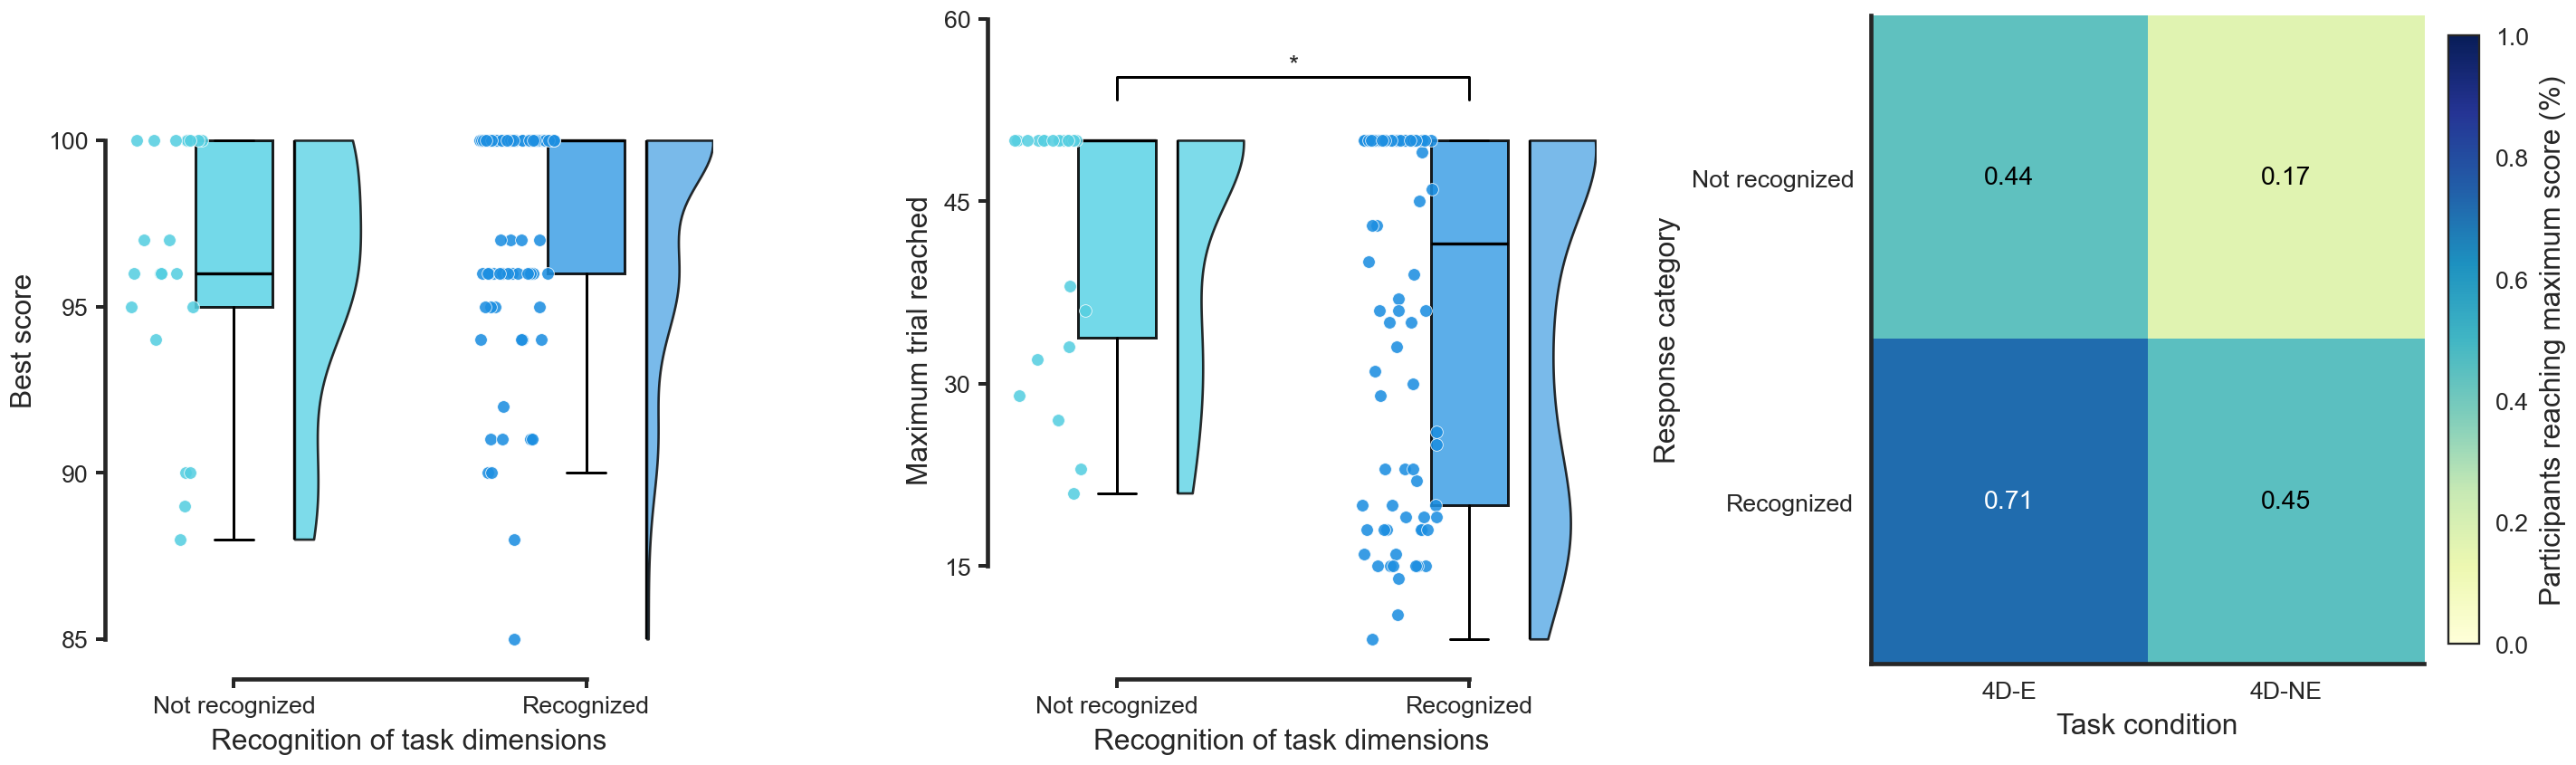


=== 4D_dimensions_recognized | Trimmed Mann–Whitney U ===
Best score, 0 vs 1: p = 0.1666
Max round,  0 vs 1: p = 0.02267


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_features_relevant_answer_bestscore_maxround_fullscorerate.png


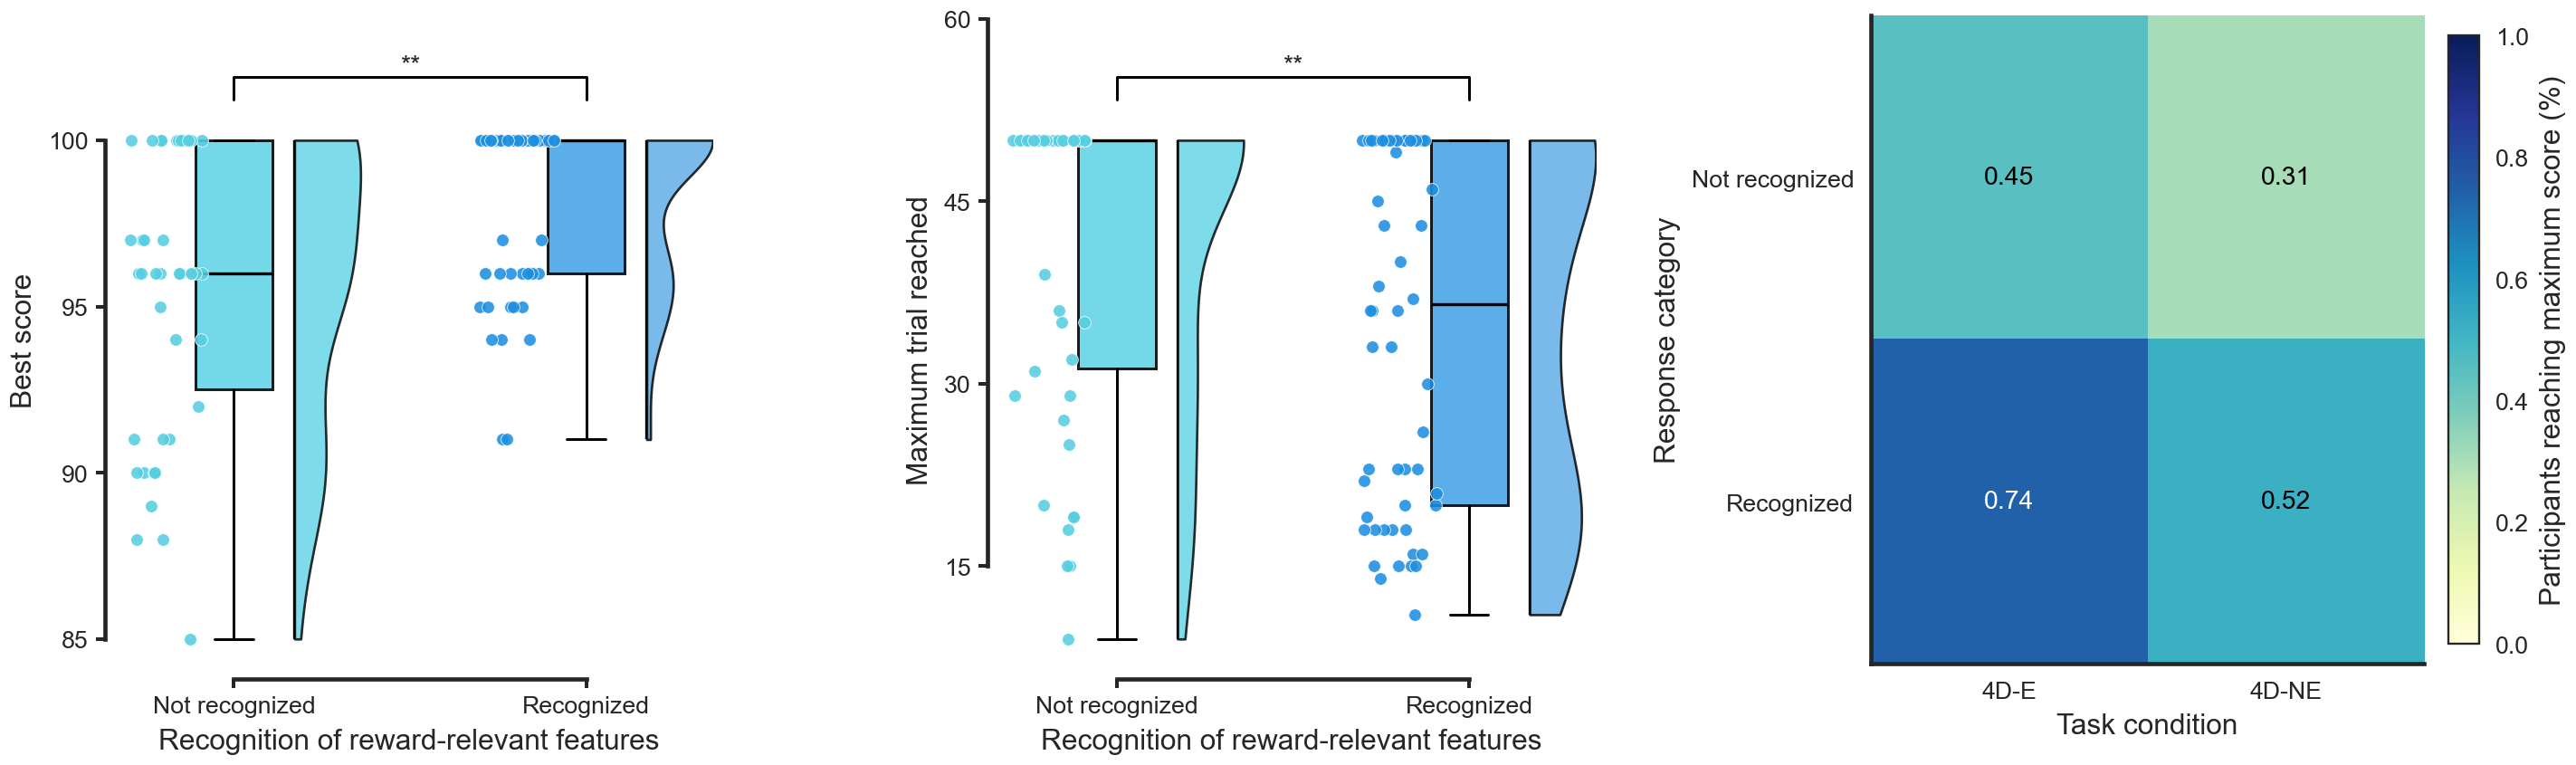


=== 4D_features_relevant_answer | Trimmed Mann–Whitney U ===
Best score, 0 vs 1: p = 0.005218
Max round,  0 vs 1: p = 0.003252


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_strict_bestscore_maxround_fullscorerate.png


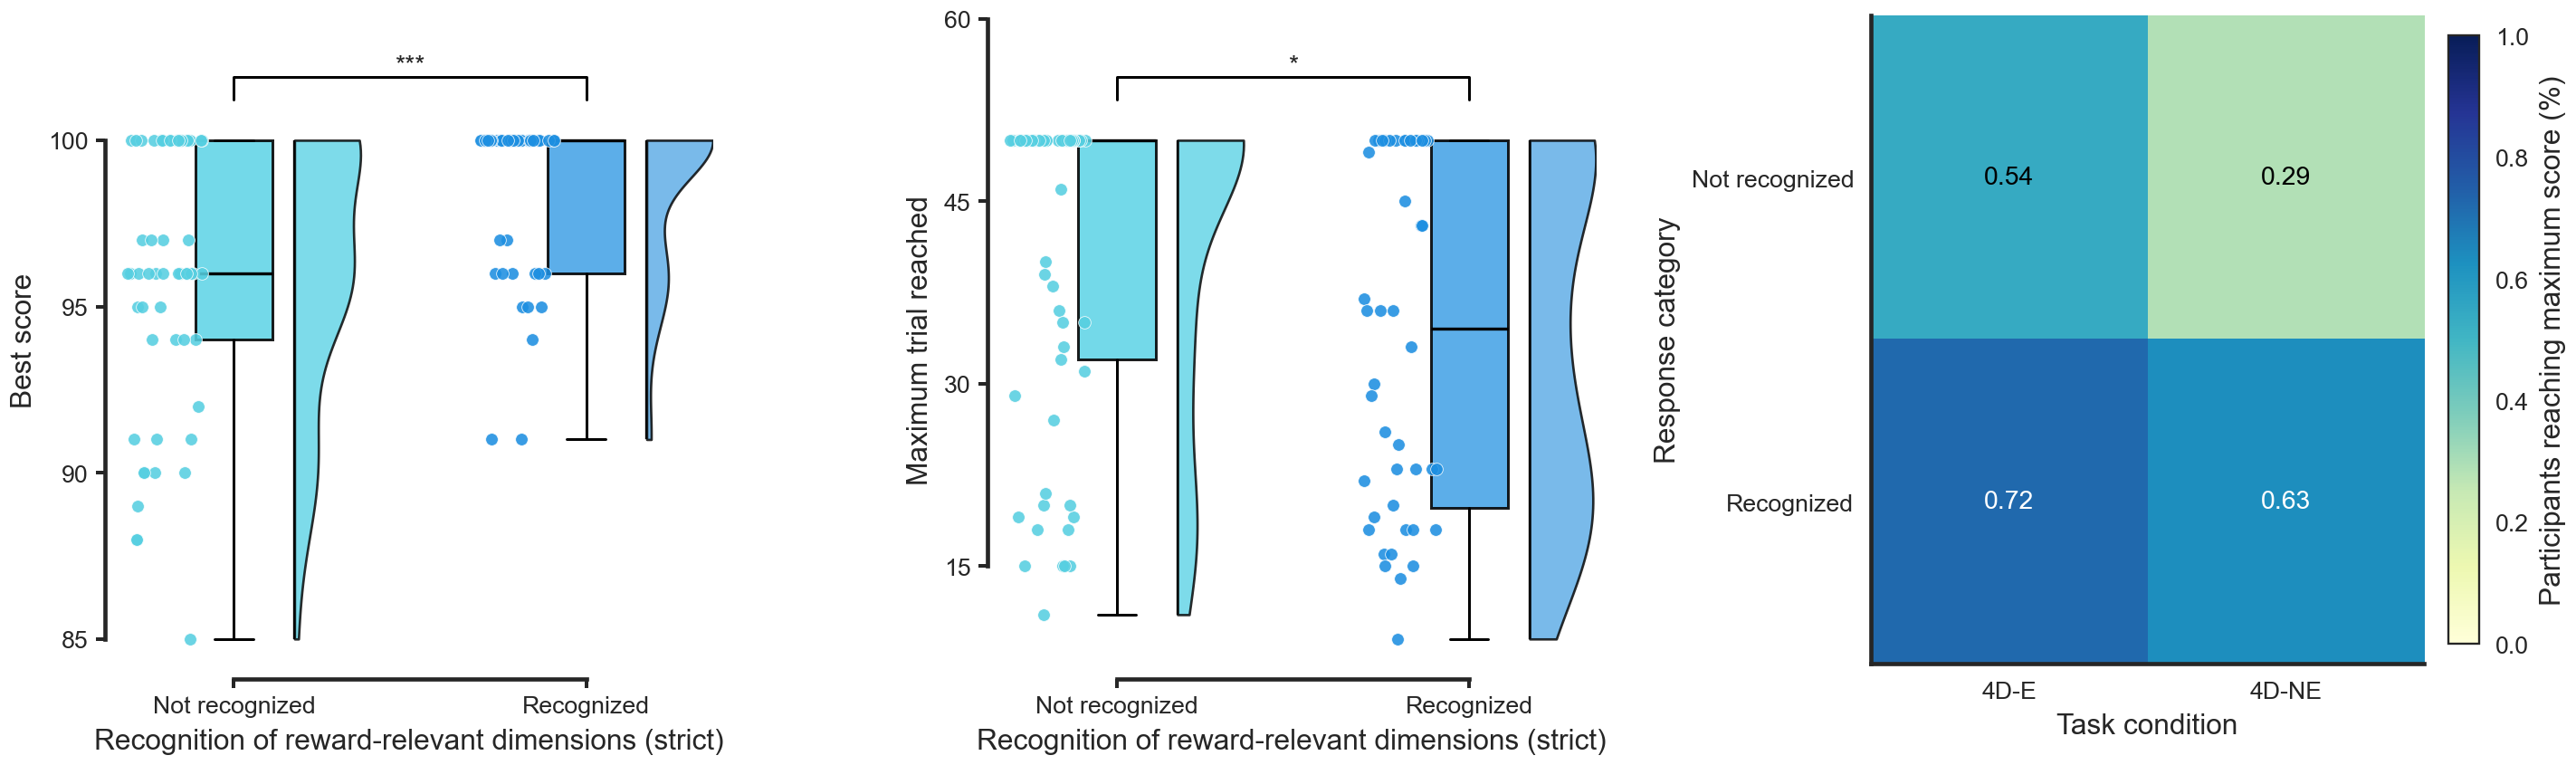


=== 4D_dimensions_relevant_answer_strict | Trimmed Mann–Whitney U ===
Best score, 0 vs 1: p = 0.0006695
Max round,  0 vs 1: p = 0.01116


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_F1_bestscore_maxround_fullscorerate.png


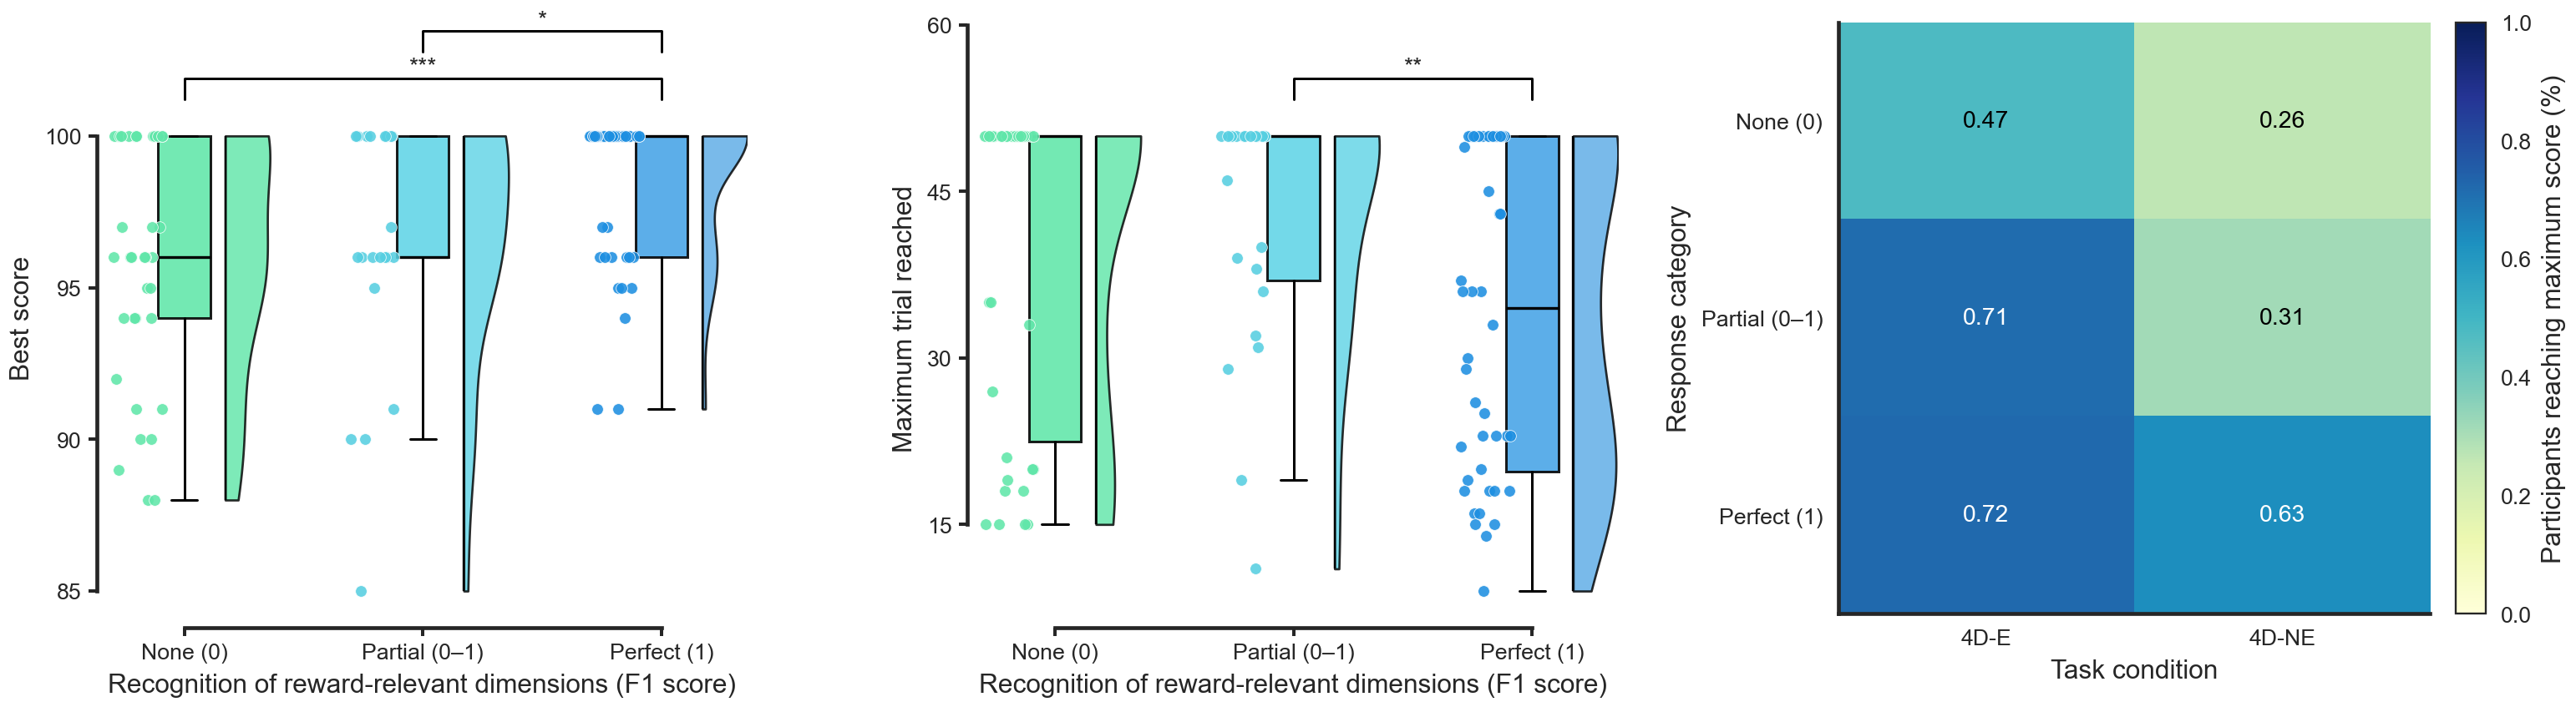


=== 4D_dimensions_relevant_answer_F1 | Spearman correlation ===
With best score : rho = 0.3094, p = 0.001322
With max round  : rho = -0.2255, p = 0.02072

=== 4D_dimensions_relevant_answer_F1 | Trimmed Mann–Whitney U pairwise comparisons ===
Best score, None (0) vs Partial (0–1): p = 0.4867
Best score, None (0) vs Perfect (1): p = 0.0006982
Best score, Partial (0–1) vs Perfect (1): p = 0.02123
Max round,  None (0) vs Partial (0–1): p = 0.449
Max round,  None (0) vs Perfect (1): p = 0.08017
Max round,  Partial (0–1) vs Perfect (1): p = 0.00398


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_hit_minus_false_bestscore_maxround_fullscorerate.png


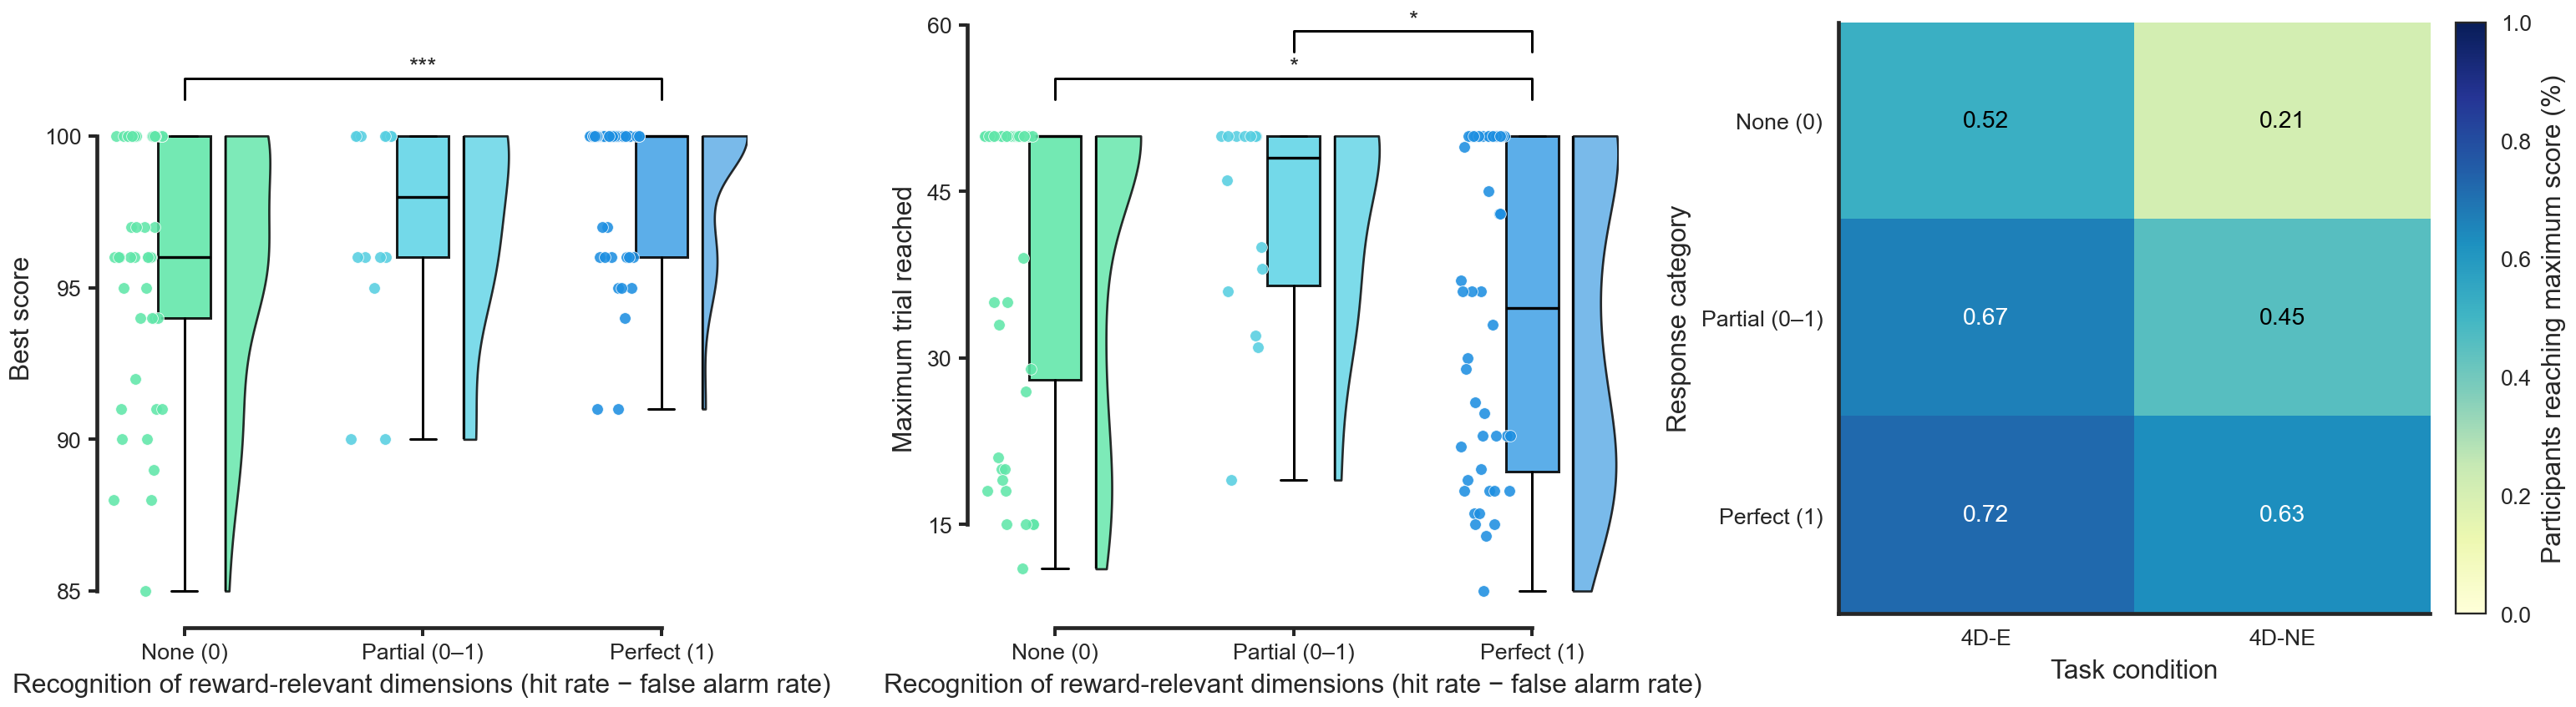


=== 4D_dimensions_relevant_answer_hit_minus_false | Spearman correlation ===
With best score : rho = 0.3151, p = 0.001062
With max round  : rho = -0.2412, p = 0.0132

=== 4D_dimensions_relevant_answer_hit_minus_false | Trimmed Mann–Whitney U pairwise comparisons ===
Best score, None (0) vs Partial (0–1): p = 0.5946
Best score, None (0) vs Perfect (1): p = 0.000551
Best score, Partial (0–1) vs Perfect (1): p = 0.06599
Max round,  None (0) vs Partial (0–1): p = 0.9412
Max round,  None (0) vs Perfect (1): p = 0.02271
Max round,  Partial (0–1) vs Perfect (1): p = 0.0306


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FixedLocator, MaxNLocator
from pathlib import Path
from scipy.stats import mannwhitneyu, spearmanr

# =========================
# 0) 配置
# =========================
subject_col = "subject"
phase_col = "phase"
score_col = "score"
round_col = "round"

phases_keep = ["P2", "P2-only"]
phase_display_map = {
    "P2": "4D-E",
    "P2-only": "4D-NE",
}
phase_order = ["P2", "P2-only"]
phase_order_display = ["4D-E", "4D-NE"]

phase_colors = TASK1_COLORS.copy()
phase_display_colors = {
    "4D-E": phase_colors["P2"],
    "4D-NE": phase_colors["P2-only"]
}

binary_text_metrics = [
    "4D_dimensions_recognized",
    "4D_features_relevant_answer",
    "4D_dimensions_relevant_answer_strict",
]

continuous_text_metrics = [
    "4D_dimensions_relevant_answer_F1",
    "4D_dimensions_relevant_answer_hit_minus_false",
]

perfect_score = None

# =========================
# 标签
# =========================
metric_label_map = {
    "4D_dimensions_recognized": "Recognition of task dimensions",
    "4D_features_relevant_answer": "Recognition of reward-relevant features",
    "4D_dimensions_relevant_answer_strict": "Recognition of reward-relevant dimensions (strict)",
    "4D_dimensions_relevant_answer_F1": "Recognition of reward-relevant dimensions (F1 score)",
    "4D_dimensions_relevant_answer_hit_minus_false": "Recognition of reward-relevant dimensions (hit rate − false alarm rate)",
    "best_score": "Best score",
    "max_round": "Max round reached",
    "is_perfect": "Full score rate",
}

binary_level_label_map = {
    "4D_dimensions_recognized": {
        0: "Not recognized",
        1: "Recognized",
    },
    "4D_features_relevant_answer": {
        0: "Not recognized",
        1: "Recognized",
    },
    "4D_dimensions_relevant_answer_strict": {
        0: "Not recognized",
        1: "Recognized",
    }
}

triple_level_label_map = {
    0: "None (0)",
    1: "Partial (0–1)",
    2: "Perfect (1)"
}

# =========================
# 全局风格
# =========================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["axes.grid"] = False

LABEL_FONTSIZE = 22
TICK_FONTSIZE = 19
TITLE_FONTSIZE = 22
SPINE_WIDTH = 2.4
TICK_WIDTH = 2.0
TICK_LENGTH = 7

# =========================
# 1) 数据准备
# =========================
df = merged_df.copy()
df = df[df[phase_col].isin(phases_keep)].copy()

df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
df[round_col] = pd.to_numeric(df[round_col], errors="coerce")

if perfect_score is None:
    perfect_score = df[score_col].max()

print(f"使用的满分值 perfect_score = {perfect_score}")

# =========================
# 2) subject × phase 汇总
# =========================
def summarize_subject_phase(group):
    g = group.copy().sort_values(by=[round_col], na_position="last")

    best_score = g[score_col].max()

    best_rows = g[g[score_col] == best_score].copy().sort_values(by=[round_col], na_position="last")
    best_round_first_hit = best_rows[round_col].iloc[0] if len(best_rows) > 0 else np.nan

    is_perfect = 1 if pd.notna(best_score) and best_score == perfect_score else 0
    max_round = g[round_col].max()

    return pd.Series({
        "best_score": best_score,
        "is_perfect": is_perfect,
        "best_round_first_hit": best_round_first_hit,
        "max_round": max_round,
        "n_trials_in_phase": len(g),
    })

behavior_summary = (
    df.groupby([subject_col, phase_col], dropna=False)
      .apply(summarize_subject_phase)
      .reset_index()
)

behavior_summary["phase_display"] = behavior_summary[phase_col].map(phase_display_map)

# =========================
# 3) subject-level 文本指标
# =========================
text_metric_cols = binary_text_metrics + continuous_text_metrics

def first_nonempty(series):
    for x in series:
        if pd.notna(x) and str(x).strip() != "":
            return x
    return np.nan

subject_text_summary = (
    merged_df.groupby(subject_col, dropna=False)
    .agg({col: first_nonempty for col in text_metric_cols if col in merged_df.columns})
    .reset_index()
)

for col in binary_text_metrics:
    if col in subject_text_summary.columns:
        subject_text_summary[col] = pd.to_numeric(subject_text_summary[col], errors="coerce")

for col in continuous_text_metrics:
    if col in subject_text_summary.columns:
        subject_text_summary[col] = pd.to_numeric(subject_text_summary[col], errors="coerce")

if "4D_dimensions_relevant_answer_strict" in subject_text_summary.columns:
    subject_text_summary["4D_dimensions_relevant_answer_strict"] = pd.to_numeric(
        subject_text_summary["4D_dimensions_relevant_answer_strict"], errors="coerce"
    )
    subject_text_summary["4D_dimensions_relevant_answer_strict"] = subject_text_summary[
        "4D_dimensions_relevant_answer_strict"
    ].apply(lambda x: np.nan if pd.isna(x) else (1 if x >= 1 else 0))

# =========================
# 4) 合并
# =========================
analysis_df = behavior_summary.merge(
    subject_text_summary,
    on=subject_col,
    how="left"
)

# =========================
# 5) 工具函数
# =========================
def lighten_color(color, amount=0.20):
    rgb = mcolors.to_rgb(color)
    return tuple((1 - amount) * c + amount for c in rgb)

def p_to_star(p):
    if pd.isna(p):
        return None
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return None

def trim_5_percent_each_tail(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) < 6:
        return x.values
    lo = x.quantile(0.05)
    hi = x.quantile(0.95)
    return x[(x >= lo) & (x <= hi)].values

def mannwhitney_between_groups_trimmed(plot_df, group_col, value_col, group_a, group_b):
    tmp = plot_df[[group_col, value_col]].dropna().copy()
    g1 = tmp.loc[tmp[group_col] == group_a, value_col].dropna()
    g2 = tmp.loc[tmp[group_col] == group_b, value_col].dropna()

    g1_trim = trim_5_percent_each_tail(g1)
    g2_trim = trim_5_percent_each_tail(g2)

    if len(g1_trim) == 0 or len(g2_trim) == 0:
        return np.nan

    try:
        _, p = mannwhitneyu(g1_trim, g2_trim, alternative="two-sided")
        return p
    except Exception:
        return np.nan

def pairwise_mwu_three_groups_trimmed(plot_df, group_col, value_col):
    pairs = [(0, 1), (0, 2), (1, 2)]
    results = {}
    for a, b in pairs:
        p = mannwhitney_between_groups_trimmed(plot_df, group_col, value_col, a, b)
        results[(a, b)] = p
    return results

def spearman_xy(df, x_col, y_col):
    tmp = df[[x_col, y_col]].dropna().copy()
    if len(tmp) < 3:
        return np.nan, np.nan
    try:
        rho, p = spearmanr(tmp[x_col], tmp[y_col])
        return rho, p
    except Exception:
        return np.nan, np.nan

def style_axis_like_example(ax, xlabel, ylabel, xtick_positions=None, xtick_labels=None,
                            y_ticks=None, y_lim=None, x_lim=None,
                            left_bound=None, bottom_bound=None):
    ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE)
    ax.set_title("")
    ax.grid(False)

    if xtick_positions is not None:
        ax.set_xticks(xtick_positions)
    if xtick_labels is not None:
        ax.set_xticklabels(xtick_labels, fontsize=TICK_FONTSIZE)

    if y_ticks is not None:
        ax.yaxis.set_major_locator(FixedLocator(y_ticks))
    else:
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    if y_lim is not None:
        ax.set_ylim(*y_lim)
    if x_lim is not None:
        ax.set_xlim(*x_lim)

    ax.yaxis.set_ticks_position('left')
    ax.tick_params(
        axis='y',
        labelsize=TICK_FONTSIZE,
        direction='out',
        left=True,
        right=False,
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        pad=5
    )

    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(
        axis='x',
        labelsize=TICK_FONTSIZE,
        direction='out',
        bottom=True,
        top=False,
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        pad=12
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(SPINE_WIDTH)
    ax.spines['bottom'].set_linewidth(SPINE_WIDTH)

    if left_bound is not None:
        ax.spines['left'].set_bounds(left_bound[0], left_bound[1])

    ax.spines['bottom'].set_position(('outward', 10))
    if bottom_bound is not None:
        ax.spines['bottom'].set_bounds(bottom_bound[0], bottom_bound[1])

def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.8, c='black', clip_on=False)
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom', fontsize=17)

def draw_grouped_scatter_box_halfviolin(ax, values_by_group, group_labels, group_colors,
                                        ylabel, xlabel, pairwise_pvals=None, y_ticks=None, y_lim=None, **kwargs):
    n_group = len(group_labels)

    group_centers = np.arange(n_group) * 1.28 + 1.0
    scatter_positions = group_centers - 0.25
    box_positions = group_centers
    violin_positions = group_centers + 0.22

    rng = np.random.default_rng(42)

    # ---------- scatter ----------
    for i, values in enumerate(values_by_group):
        if len(values) == 0:
            continue
        jitter = rng.uniform(-0.14, 0.14, size=len(values))
        ax.scatter(
            np.full(len(values), scatter_positions[i]) + jitter,
            values,
            s=68,
            alpha=0.88,
            c=group_colors[i],
            edgecolors='white',
            linewidths=0.5,
            zorder=4
        )

    # ---------- box ----------
    box = ax.boxplot(
        values_by_group,
        positions=box_positions,
        widths=0.28,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=2.0),
        whiskerprops=dict(color='black', linewidth=1.8),
        capprops=dict(color='black', linewidth=1.8),
        boxprops=dict(edgecolor='black', linewidth=1.8)
    )

    for patch, color in zip(box['boxes'], group_colors):
        patch.set_facecolor(lighten_color(color, amount=0.18))
        patch.set_alpha(0.80)

    # ---------- violin ----------
    violins = ax.violinplot(
        values_by_group,
        positions=violin_positions,
        widths=0.48,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    for i, body in enumerate(violins['bodies']):
        color = group_colors[i]
        body.set_facecolor(lighten_color(color, amount=0.28))
        body.set_edgecolor('black')
        body.set_linewidth(1.6)
        body.set_alpha(0.45)

        path = body.get_paths()[0]
        vertices = path.vertices
        center = violin_positions[i]
        vertices[:, 0] = np.maximum(vertices[:, 0], center)

    # center line
    for pos, values in zip(violin_positions, values_by_group):
        if len(values) > 0:
            ax.vlines(
                pos,
                np.min(values),
                np.max(values),
                color='black',
                linewidth=1.4,
                zorder=2
            )

    left_lim = scatter_positions[0] - 0.22
    right_lim = violin_positions[-1] + 0.24

    if y_lim is None:
        nonempty = [v for v in values_by_group if len(v) > 0]
        all_values = np.concatenate(nonempty) if len(nonempty) > 0 else np.array([0, 1])
        y_min = np.nanmin(all_values)
        y_max = np.nanmax(all_values)
        if y_min == y_max:
            pad = 1
        else:
            pad = (y_max - y_min) * 0.25
        y_lim = (y_min - pad * 0.20, y_max + pad)

    style_axis_like_example(
        ax=ax,
        xlabel=xlabel,
        ylabel=ylabel,
        xtick_positions=group_centers,
        xtick_labels=group_labels,
        y_ticks=y_ticks,
        y_lim=y_lim,
        x_lim=(left_lim, right_lim),
        left_bound=(y_lim[0], y_lim[1] * 0.96 if y_lim[1] > 0 else y_lim[1]),
        bottom_bound=(group_centers[0], group_centers[-1])
    )

    # ---------- significance bars ----------
    if pairwise_pvals is not None:
        # 只保留合法 pair
        valid_pairs = []
        for pair, p in pairwise_pvals.items():
            a, b = pair
            if a < n_group and b < n_group:
                valid_pairs.append((pair, p))

        # 只画显著的
        sig_pairs = []
        for pair, p in valid_pairs:
            star = p_to_star(p)
            if star is not None:
                sig_pairs.append((pair, p, star))

        if len(sig_pairs) > 0:
            y0, y1 = ax.get_ylim()
            h = (y1 - y0) * 0.035
            base_y = y1 - (y1 - y0) * 0.13
            level_step = (y1 - y0) * 0.08

            for idx, (pair, p, star) in enumerate(sig_pairs):
                a, b = pair
                x1, x2 = box_positions[a], box_positions[b]
                y = base_y + idx * level_step
                add_sig_bar(ax, x1, x2, y, h, star)


def draw_professional_heatmap(ax, rate_matrix, x_labels, y_labels, colorbar_label):
    im = ax.imshow(rate_matrix, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")

    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels, fontsize=TICK_FONTSIZE)
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=TICK_FONTSIZE)

    ax.set_xlabel("Phase", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel("Response category", fontsize=LABEL_FONTSIZE)
    ax.set_title("", fontsize=TITLE_FONTSIZE)

    for i in range(rate_matrix.shape[0]):
        for j in range(rate_matrix.shape[1]):
            val = rate_matrix[i, j]
            if pd.notna(val):
                txt_color = "white" if val >= 0.55 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=17, color=txt_color)

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(SPINE_WIDTH)
    ax.spines['bottom'].set_linewidth(SPINE_WIDTH)

    ax.tick_params(
        axis='both',
        labelsize=TICK_FONTSIZE,
        direction='out',
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        pad=6
    )

    cbar = plt.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
    cbar.set_label(colorbar_label, fontsize=18)
    cbar.ax.tick_params(labelsize=16, width=1.6, length=5)
    cbar.outline.set_linewidth(1.4)

def categorize_continuous_three_levels(x):
    if pd.isna(x):
        return np.nan
    if x == 0:
        return 0
    elif x == 1:
        return 2
    elif 0 < x < 1:
        return 1
    else:
        return np.nan

# =========================
# 6) 二分类指标：两个分布图 + heatmap
# =========================
def plot_binary_metric_full(data, metric_col, save_dir):
    plot_df = data.copy()
    plot_df = plot_df[plot_df["phase_display"].isin(phase_order_display)].copy()
    plot_df = plot_df[plot_df[metric_col].isin([0, 1])].copy()

    if len(plot_df) == 0:
        print(f"[跳过] {metric_col}: 没有有效 0/1 数据")
        return

    metric_levels = binary_level_label_map.get(metric_col, {0: "Not recognized", 1: "Recognized"})
    group_labels = [metric_levels[0], metric_levels[1]]
    group_colors = SURVEY_COLORS_2.copy()

    best_values_by_group = [
        plot_df.loc[plot_df[metric_col] == 0, "best_score"].dropna().values,
        plot_df.loc[plot_df[metric_col] == 1, "best_score"].dropna().values,
    ]
    p_best = mannwhitney_between_groups_trimmed(plot_df, metric_col, "best_score", 0, 1)

    round_values_by_group = [
        plot_df.loc[plot_df[metric_col] == 0, "max_round"].dropna().values,
        plot_df.loc[plot_df[metric_col] == 1, "max_round"].dropna().values,
    ]
    p_round = mannwhitney_between_groups_trimmed(plot_df, metric_col, "max_round", 0, 1)

    rate_df = (
        plot_df.groupby([metric_col, "phase_display"], dropna=False)["is_perfect"]
        .mean()
        .reset_index()
    )

    heat_df = (
        rate_df.assign(response_category=lambda d: d[metric_col].map(metric_levels))
        .pivot(index="response_category", columns="phase_display", values="is_perfect")
        .reindex(index=[metric_levels[0], metric_levels[1]], columns=phase_order_display)
    )

    fig, axes = plt.subplots(1, 3, figsize=(24, 7.5))

    draw_grouped_scatter_box_halfviolin(
        ax=axes[0],
        values_by_group=best_values_by_group,
        group_labels=group_labels,
        group_colors=group_colors,
        ylabel="Best score",
        xlabel=metric_label_map[metric_col],
        pairwise_pvals={(0, 1): p_best}
    )

    draw_grouped_scatter_box_halfviolin(
        ax=axes[1],
        values_by_group=round_values_by_group,
        group_labels=group_labels,
        group_colors=group_colors,
        ylabel="Max round reached",
        xlabel=metric_label_map[metric_col],
        pairwise_pvals={(0, 1): p_round}
    )

    draw_professional_heatmap(
        ax=axes[2],
        rate_matrix=heat_df.values.astype(float),
        x_labels=phase_order_display,
        y_labels=list(heat_df.index),
        colorbar_label="Full score rate"
    )

    plt.tight_layout()

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    filename = f"{metric_col}_bestscore_maxround_fullscorerate.png"
    out = save_dir / filename
    style_figure(fig)
    save_figure(fig, out, dpi=300, bbox_inches='tight')
    print(f"Saved figure to: {out.resolve()}")

    style_figure(plt.gcf())
    plt.show()

    print(f"\n=== {metric_col} | Trimmed Mann–Whitney U ===")
    print(f"Best score, 0 vs 1: p = {p_best:.4g}" if pd.notna(p_best) else "Best score, 0 vs 1: p = NaN")
    print(f"Max round,  0 vs 1: p = {p_round:.4g}" if pd.notna(p_round) else "Max round,  0 vs 1: p = NaN")


# =========================
# 7) 连续指标：三分组分布图 + heatmap + 相关性
# =========================
def plot_continuous_metric_full(data, metric_col, save_dir):
    plot_df = data.copy()
    plot_df = plot_df[plot_df["phase_display"].isin(phase_order_display)].copy()
    plot_df = plot_df[pd.notna(plot_df[metric_col])].copy()

    if len(plot_df) == 0:
        print(f"[跳过] {metric_col}: 没有有效数据")
        return

    level_col = f"{metric_col}_level3"
    plot_df[level_col] = plot_df[metric_col].apply(categorize_continuous_three_levels)
    plot_df = plot_df[pd.notna(plot_df[level_col])].copy()

    group_labels = [
        triple_level_label_map[0],
        triple_level_label_map[1],
        triple_level_label_map[2],
    ]
    group_colors = SURVEY_COLORS_3.copy()

    best_values_by_group = [
        plot_df.loc[plot_df[level_col] == 0, "best_score"].dropna().values,
        plot_df.loc[plot_df[level_col] == 1, "best_score"].dropna().values,
        plot_df.loc[plot_df[level_col] == 2, "best_score"].dropna().values,
    ]
    round_values_by_group = [
        plot_df.loc[plot_df[level_col] == 0, "max_round"].dropna().values,
        plot_df.loc[plot_df[level_col] == 1, "max_round"].dropna().values,
        plot_df.loc[plot_df[level_col] == 2, "max_round"].dropna().values,
    ]

    best_pairwise = pairwise_mwu_three_groups_trimmed(plot_df, level_col, "best_score")
    round_pairwise = pairwise_mwu_three_groups_trimmed(plot_df, level_col, "max_round")

    rho_best, p_best_corr = spearman_xy(plot_df, metric_col, "best_score")
    rho_round, p_round_corr = spearman_xy(plot_df, metric_col, "max_round")

    rate_df = (
        plot_df.groupby([level_col, "phase_display"], dropna=False)["is_perfect"]
        .mean()
        .reset_index()
    )

    heat_df = (
        rate_df.assign(response_category=lambda d: d[level_col].map(triple_level_label_map))
        .pivot(index="response_category", columns="phase_display", values="is_perfect")
        .reindex(
            index=[
                triple_level_label_map[0],
                triple_level_label_map[1],
                triple_level_label_map[2]
            ],
            columns=phase_order_display
        )
    )

    fig, axes = plt.subplots(1, 3, figsize=(26, 7.5))

    draw_grouped_scatter_box_halfviolin(
        ax=axes[0],
        values_by_group=best_values_by_group,
        group_labels=group_labels,
        group_colors=group_colors,
        ylabel="Best score",
        xlabel=metric_label_map[metric_col],
        pairwise_pvals=best_pairwise
    )

    draw_grouped_scatter_box_halfviolin(
        ax=axes[1],
        values_by_group=round_values_by_group,
        group_labels=group_labels,
        group_colors=group_colors,
        ylabel="Max round reached",
        xlabel=metric_label_map[metric_col],
        pairwise_pvals=round_pairwise
    )

    draw_professional_heatmap(
        ax=axes[2],
        rate_matrix=heat_df.values.astype(float),
        x_labels=phase_order_display,
        y_labels=list(heat_df.index),
        colorbar_label="Full score rate"
    )

    plt.tight_layout()

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    filename = f"{metric_col}_bestscore_maxround_fullscorerate.png"
    out = save_dir / filename
    style_figure(fig)
    save_figure(fig, out, dpi=300, bbox_inches='tight')
    print(f"Saved figure to: {out.resolve()}")

    style_figure(plt.gcf())
    plt.show()

    print(f"\n=== {metric_col} | Spearman correlation ===")
    print(f"With best score : rho = {rho_best:.4f}, p = {p_best_corr:.4g}" if pd.notna(rho_best) else "With best score : rho = NaN, p = NaN")
    print(f"With max round  : rho = {rho_round:.4f}, p = {p_round_corr:.4g}" if pd.notna(rho_round) else "With max round  : rho = NaN, p = NaN")

    print(f"\n=== {metric_col} | Trimmed Mann–Whitney U pairwise comparisons ===")
    for pair, p in best_pairwise.items():
        a, b = pair
        print(
            f"Best score, {triple_level_label_map[a]} vs {triple_level_label_map[b]}: p = {p:.4g}"
            if pd.notna(p) else
            f"Best score, {triple_level_label_map[a]} vs {triple_level_label_map[b]}: p = NaN"
        )
    for pair, p in round_pairwise.items():
        a, b = pair
        print(
            f"Max round,  {triple_level_label_map[a]} vs {triple_level_label_map[b]}: p = {p:.4g}"
            if pd.notna(p) else
            f"Max round,  {triple_level_label_map[a]} vs {triple_level_label_map[b]}: p = NaN"
        )

# =========================
# 8) 执行绘图
# =========================
save_dir = "figures_saving_for_layout"

binary_metrics_to_plot = [
    "4D_dimensions_recognized",
    "4D_features_relevant_answer",
    "4D_dimensions_relevant_answer_strict",
]

for metric in binary_metrics_to_plot:
    if metric in analysis_df.columns:
        plot_binary_metric_full(analysis_df, metric, save_dir=save_dir)
    else:
        print(f"[缺少列] {metric}")

continuous_metrics_to_plot = [
    "4D_dimensions_relevant_answer_F1",
    "4D_dimensions_relevant_answer_hit_minus_false",
]

for metric in continuous_metrics_to_plot:
    if metric in analysis_df.columns:
        plot_continuous_metric_full(analysis_df, metric, save_dir=save_dir)
    else:
        print(f"[缺少列] {metric}")

# 可选保存分析表
# analysis_df.to_csv("subject_phase_behavior_text_analysis_refined_style.csv", index=False)

## With Phases divided (which we don't really need in th survey sec)

使用的满分值 perfect_score = 100


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_recognized_PHASED_binary_bestscore_maxround_fullscorerate.png


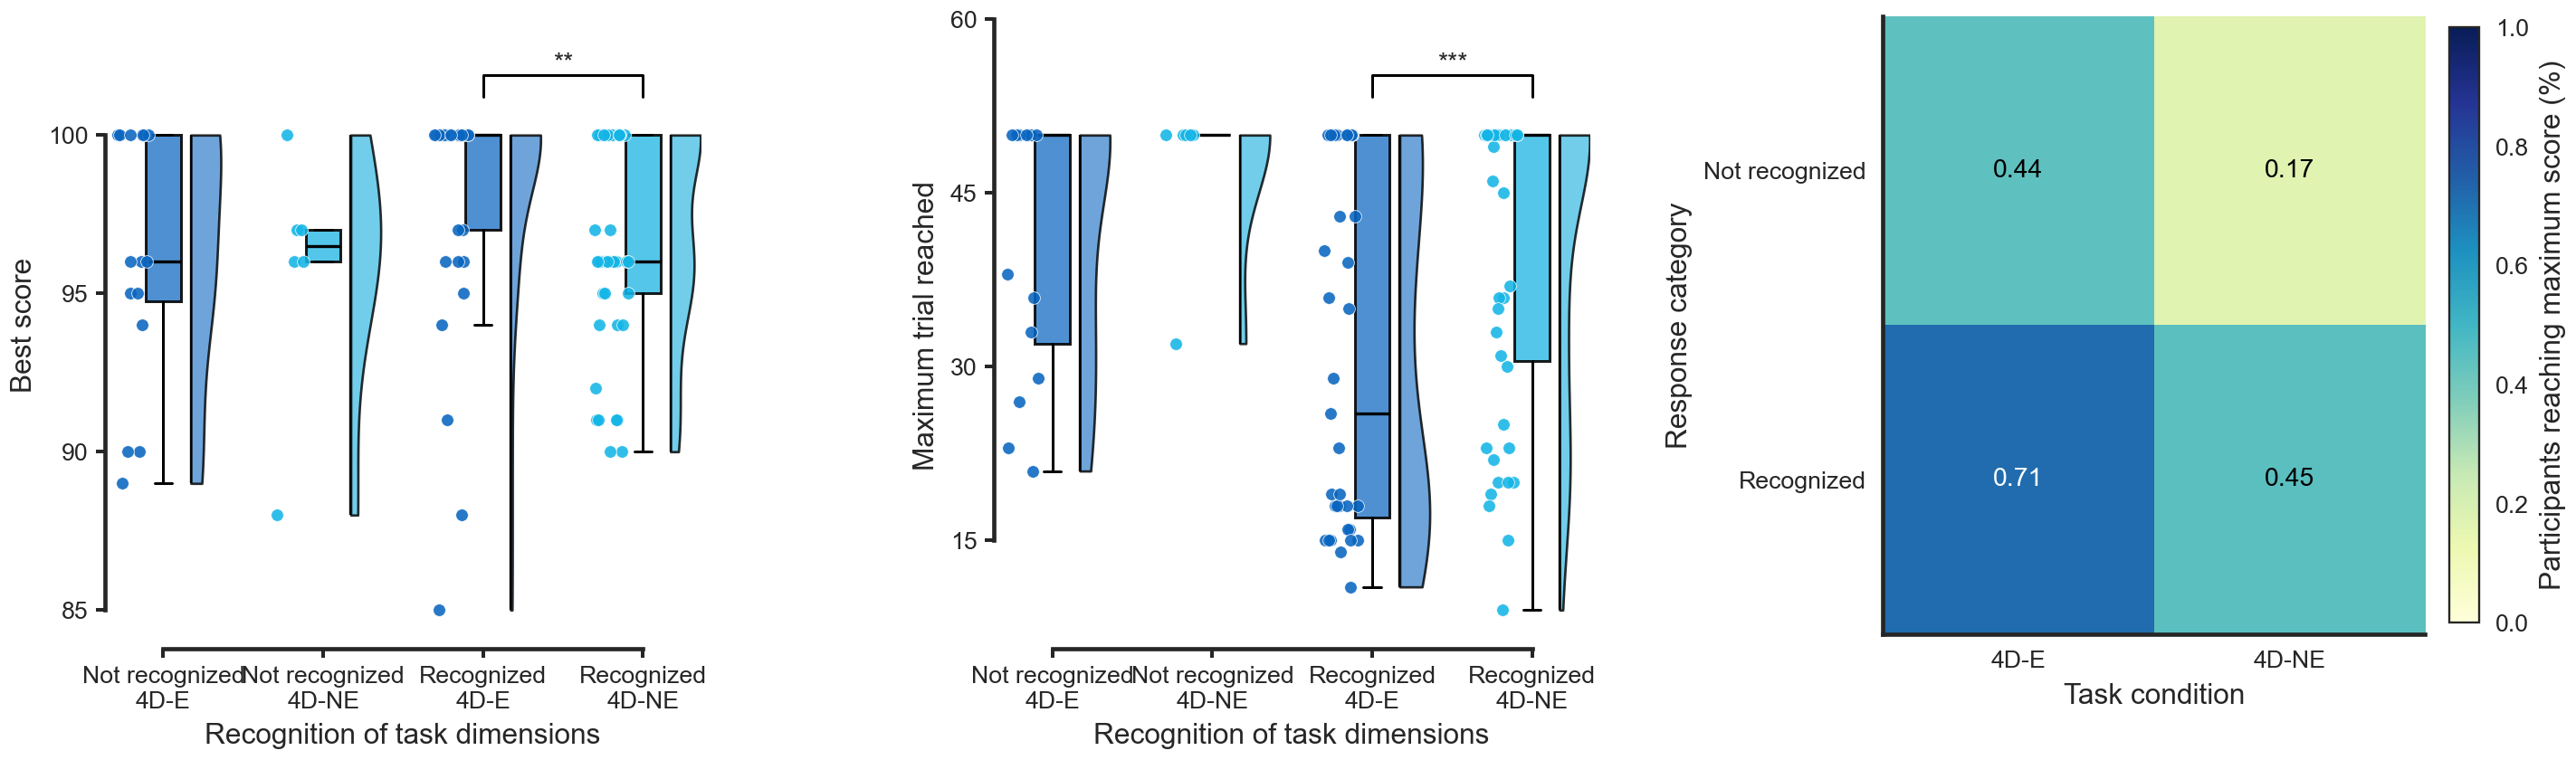


=== 4D_dimensions_recognized | Phase-split comparisons ===
[Best score]
metric=0, 4D-E vs 4D-NE: p = 0.9587, Cliff's delta = -0.0333 (negligible)
metric=1, 4D-E vs 4D-NE: p = 0.007962, Cliff's delta = -0.3145 (small)
[Max round reached]
metric=0, 4D-E vs 4D-NE: p = 0.1187, Cliff's delta = 0.4000 (medium)
metric=1, 4D-E vs 4D-NE: p < 0.001, Cliff's delta = 0.4249 (medium)


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_features_relevant_answer_PHASED_binary_bestscore_maxround_fullscorerate.png


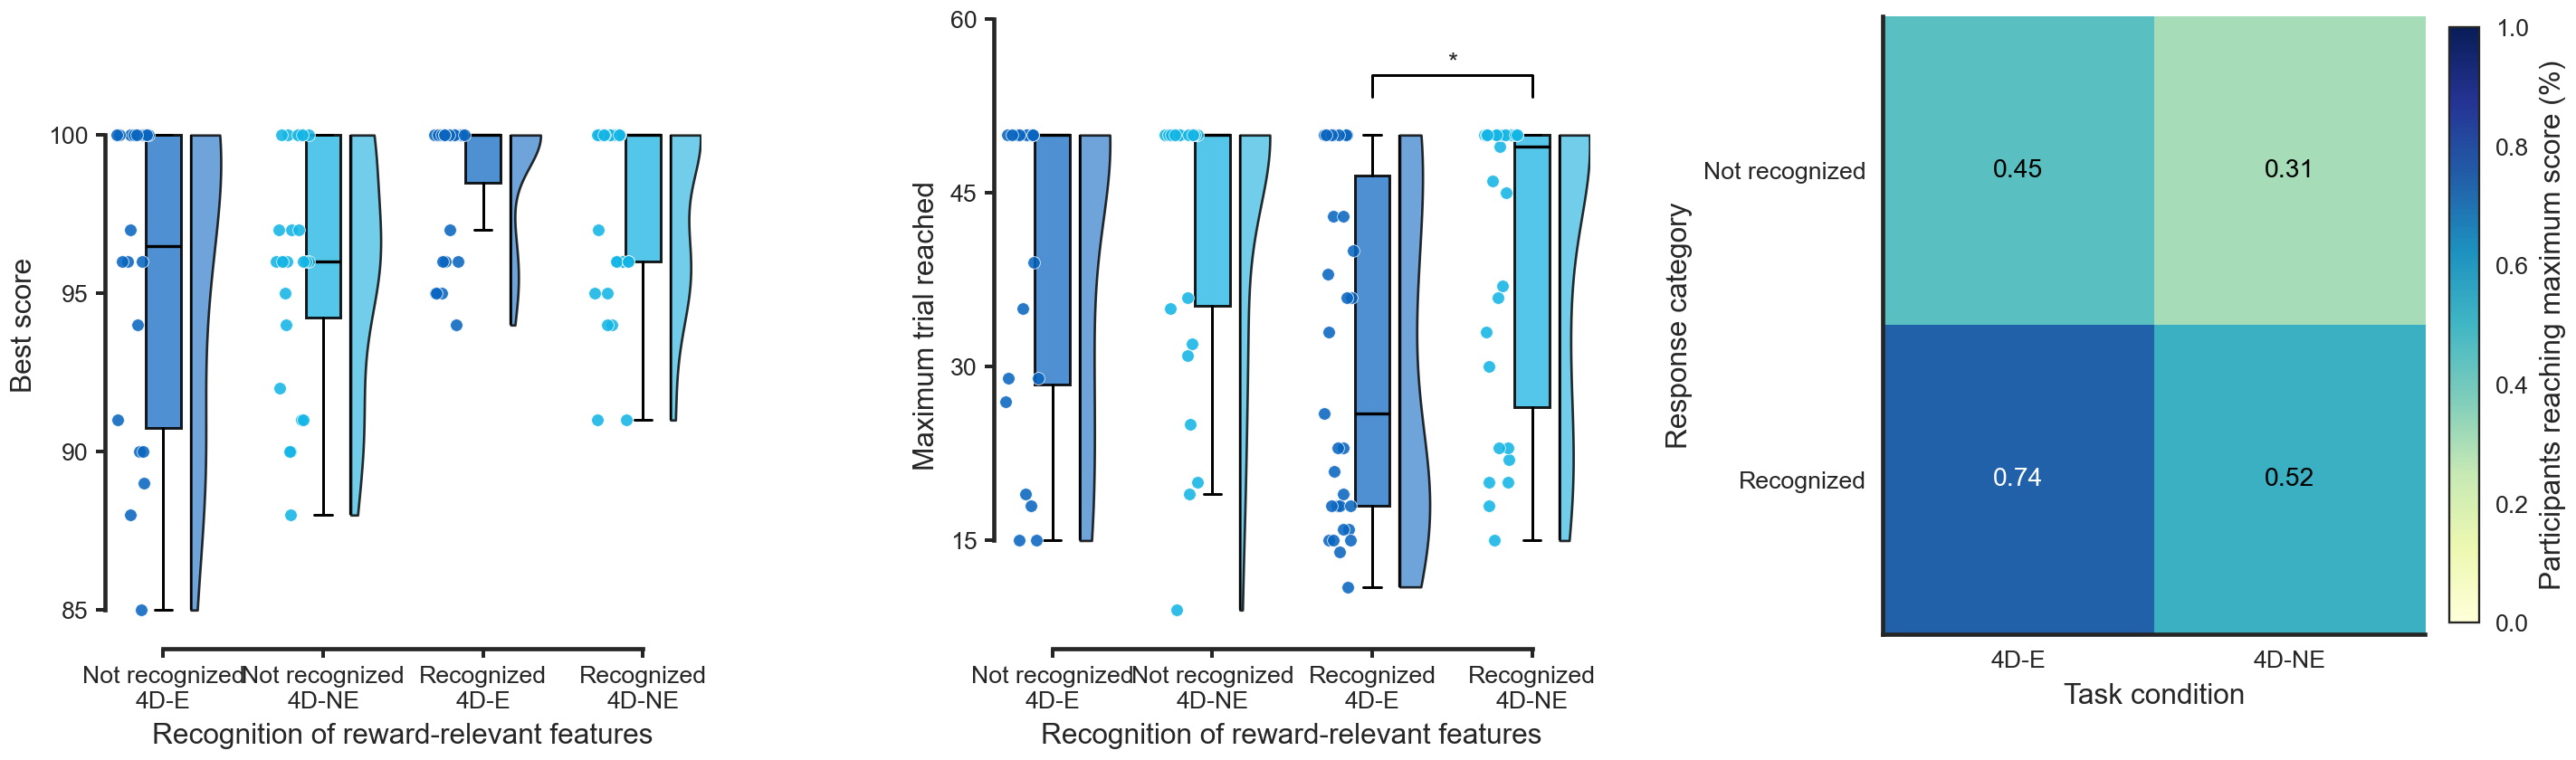


=== 4D_features_relevant_answer | Phase-split comparisons ===
[Best score]
metric=0, 4D-E vs 4D-NE: p = 0.8345, Cliff's delta = -0.0379 (negligible)
metric=1, 4D-E vs 4D-NE: p = 0.1081, Cliff's delta = -0.2120 (small)
[Max round reached]
metric=0, 4D-E vs 4D-NE: p = 0.1056, Cliff's delta = 0.2437 (small)
metric=1, 4D-E vs 4D-NE: p = 0.01135, Cliff's delta = 0.3917 (medium)


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_strict_PHASED_binary_bestscore_maxround_fullscorerate.png


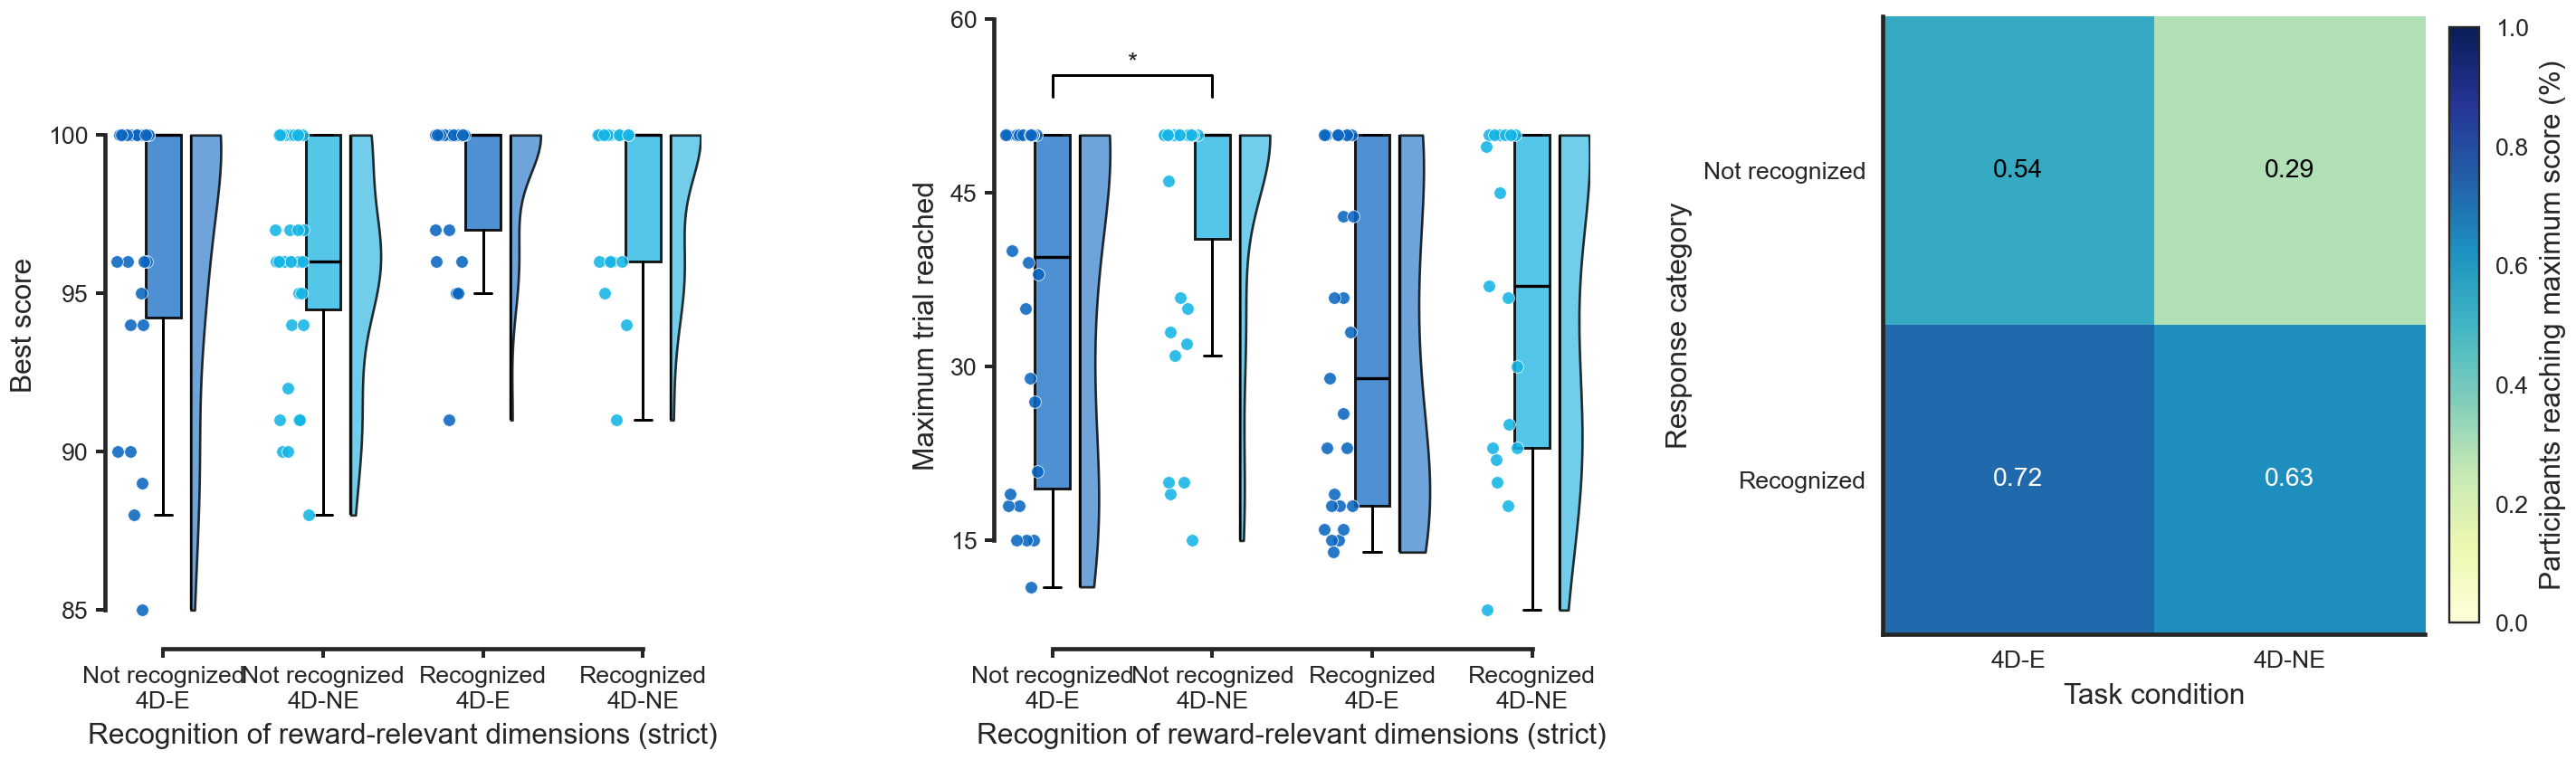


=== 4D_dimensions_relevant_answer_strict | Phase-split comparisons ===
[Best score]
metric=0, 4D-E vs 4D-NE: p = 0.1731, Cliff's delta = -0.2034 (small)
metric=1, 4D-E vs 4D-NE: p = 0.4721, Cliff's delta = -0.1065 (negligible)
[Max round reached]
metric=0, 4D-E vs 4D-NE: p = 0.01484, Cliff's delta = 0.3248 (small)
metric=1, 4D-E vs 4D-NE: p = 0.1818, Cliff's delta = 0.2407 (small)


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_F1_PHASED_continuous_bestscore_maxround_fullscorerate.png


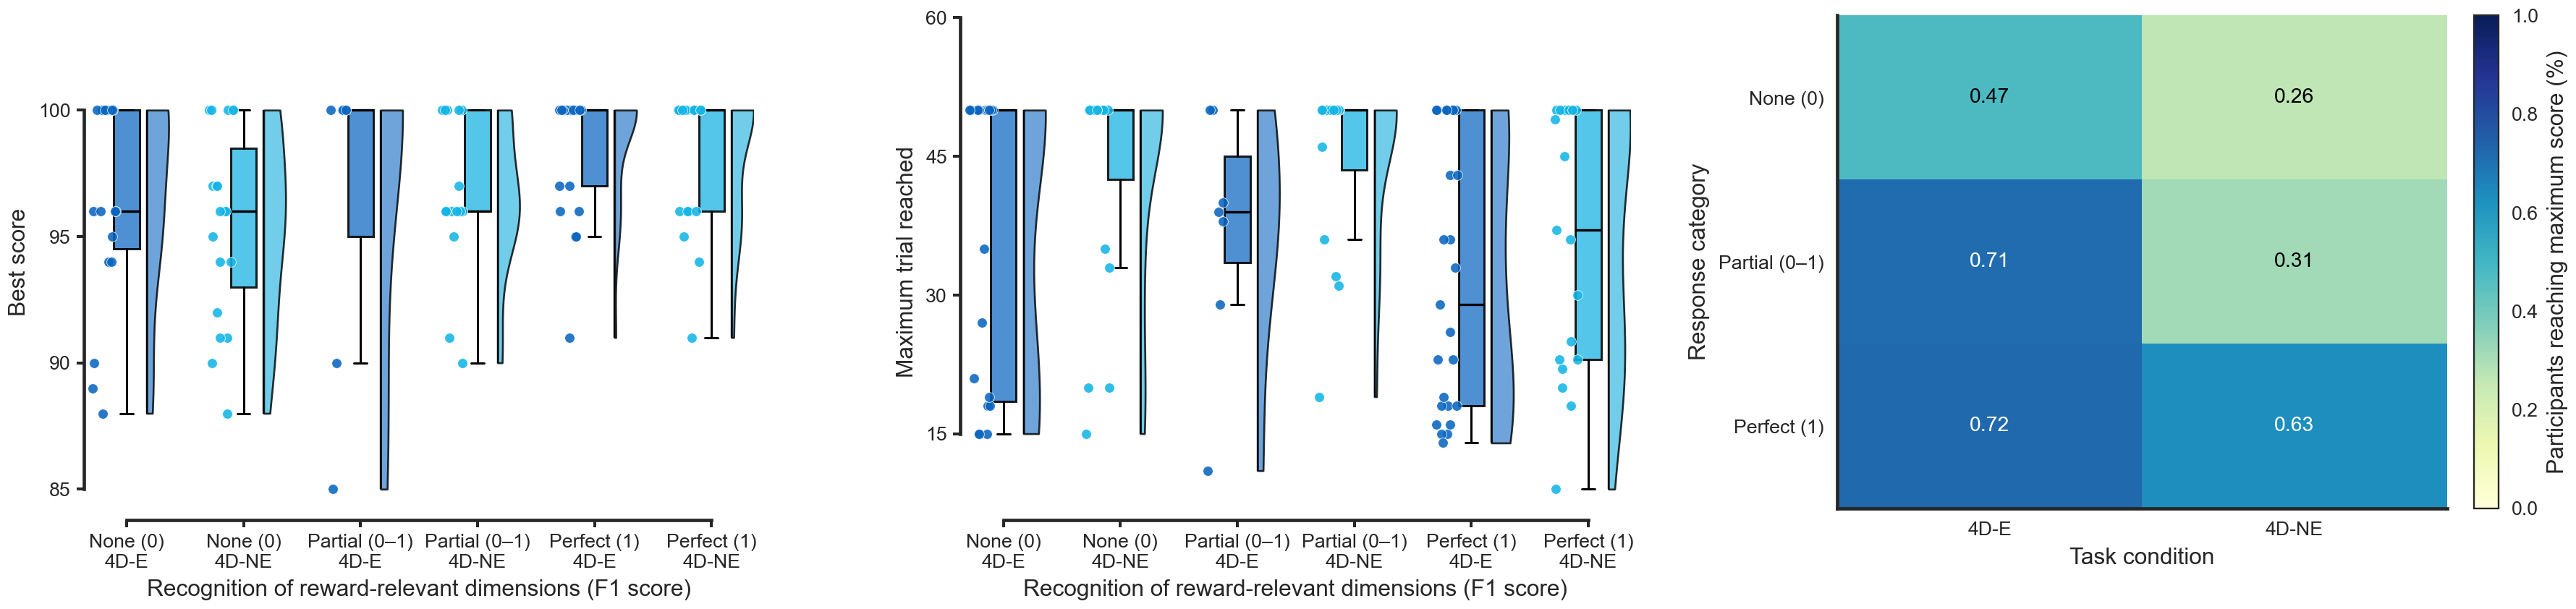


=== 4D_dimensions_relevant_answer_F1 | Spearman correlation ===
With best score : rho = 0.3094, p = 0.001322
With max round  : rho = -0.2255, p = 0.02072

=== 4D_dimensions_relevant_answer_F1 | Phase-split comparisons ===
[Best score]
level=None (0), 4D-E vs 4D-NE: p = 0.3588, Cliff's delta = -0.1759 (small)
level=Partial (0–1), 4D-E vs 4D-NE: p = 0.1527, Cliff's delta = -0.3889 (medium)
level=Perfect (1), 4D-E vs 4D-NE: p = 0.4721, Cliff's delta = -0.1065 (negligible)
[Max round reached]
level=None (0), 4D-E vs 4D-NE: p = 0.05883, Cliff's delta = 0.3129 (small)
level=Partial (0–1), 4D-E vs 4D-NE: p = 0.1416, Cliff's delta = 0.3778 (medium)
level=Perfect (1), 4D-E vs 4D-NE: p = 0.1818, Cliff's delta = 0.2407 (small)


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_hit_minus_false_PHASED_continuous_bestscore_maxround_fullscorerate.png


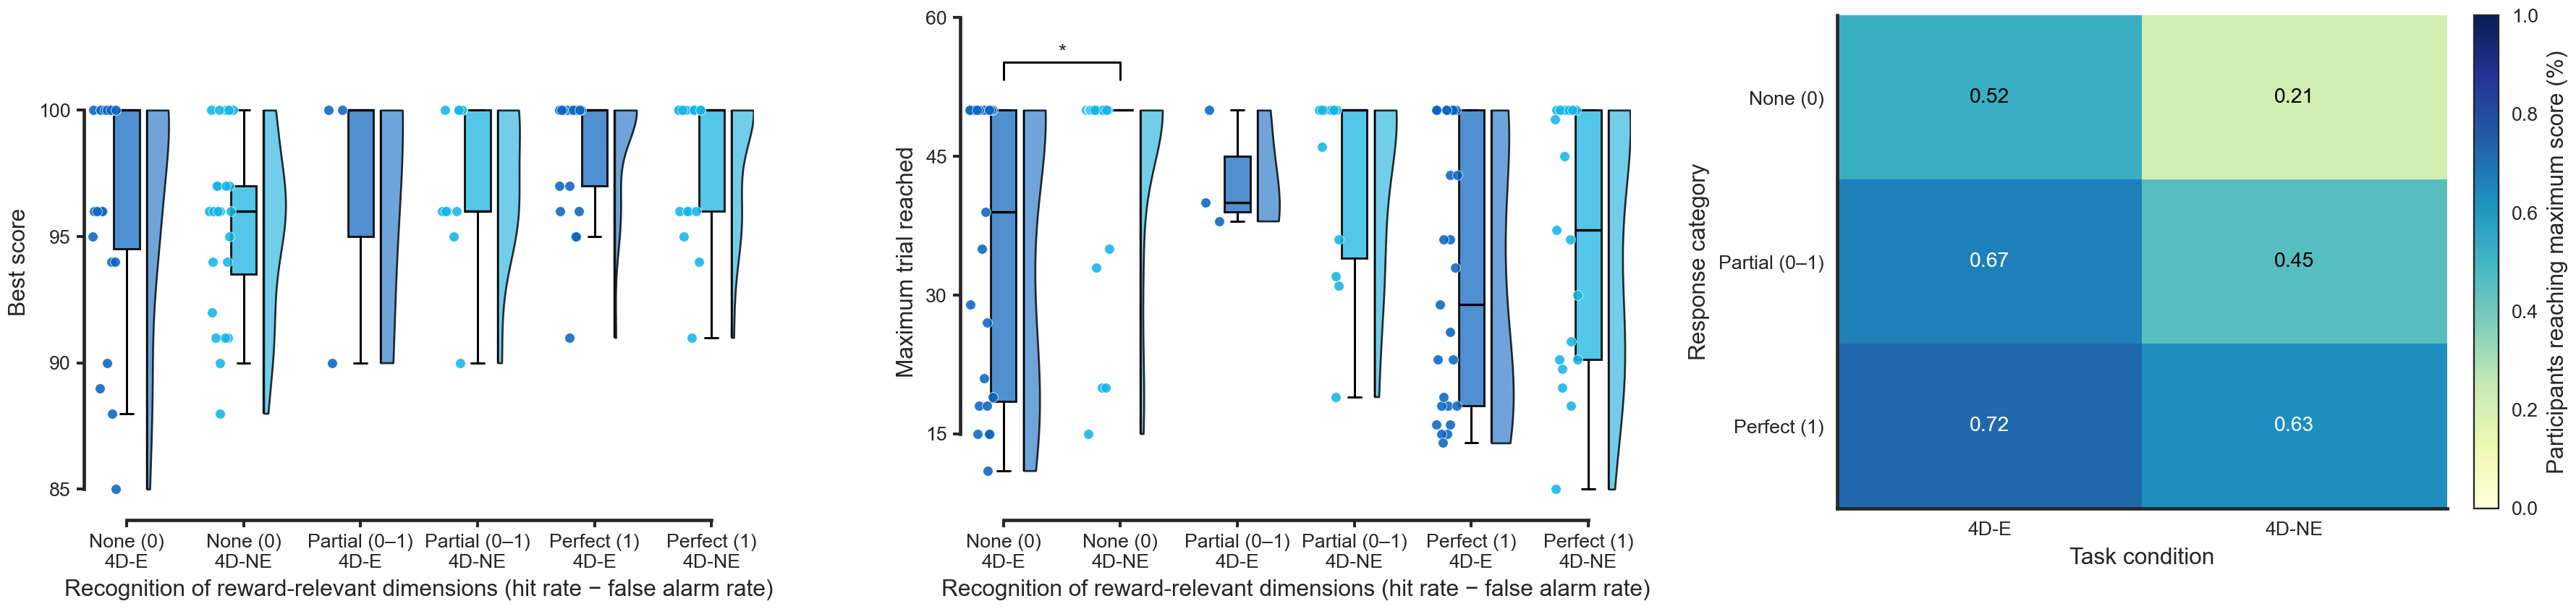


=== 4D_dimensions_relevant_answer_hit_minus_false | Spearman correlation ===
With best score : rho = 0.3151, p = 0.001062
With max round  : rho = -0.2412, p = 0.0132

=== 4D_dimensions_relevant_answer_hit_minus_false | Phase-split comparisons ===
[Best score]
level=None (0), 4D-E vs 4D-NE: p = 0.1359, Cliff's delta = -0.2576 (small)
level=Partial (0–1), 4D-E vs 4D-NE: p = 1, Cliff's delta = 0.0000 (negligible)
level=Perfect (1), 4D-E vs 4D-NE: p = 0.4721, Cliff's delta = -0.1065 (negligible)
[Max round reached]
level=None (0), 4D-E vs 4D-NE: p = 0.01428, Cliff's delta = 0.3597 (medium)
level=Partial (0–1), 4D-E vs 4D-NE: p = 0.7828, Cliff's delta = 0.1333 (negligible)
level=Perfect (1), 4D-E vs 4D-NE: p = 0.1818, Cliff's delta = 0.2407 (small)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FixedLocator, MaxNLocator
from pathlib import Path
from scipy.stats import mannwhitneyu, spearmanr

# =========================
# 0) 配置
# =========================
subject_col = "subject"
phase_col = "phase"
score_col = "score"
round_col = "round"

phases_keep = ["P2", "P2-only"]
phase_display_map = {
    "P2": "4D-E",
    "P2-only": "4D-NE",
}
phase_order = ["P2", "P2-only"]
phase_order_display = ["4D-E", "4D-NE"]

phase_colors = TASK1_COLORS.copy()
phase_display_colors = {
    "4D-E": phase_colors["P2"],
    "4D-NE": phase_colors["P2-only"]
}

binary_text_metrics = [
    "4D_dimensions_recognized",
    "4D_features_relevant_answer",
    "4D_dimensions_relevant_answer_strict",
]

continuous_text_metrics = [
    "4D_dimensions_relevant_answer_F1",
    "4D_dimensions_relevant_answer_hit_minus_false",
]

perfect_score = None

# =========================
# 标签
# =========================
metric_label_map = {
    "4D_dimensions_recognized": "Recognition of task dimensions",
    "4D_features_relevant_answer": "Recognition of reward-relevant features",
    "4D_dimensions_relevant_answer_strict": "Recognition of reward-relevant dimensions (strict)",
    "4D_dimensions_relevant_answer_F1": "Recognition of reward-relevant dimensions (F1 score)",
    "4D_dimensions_relevant_answer_hit_minus_false": "Recognition of reward-relevant dimensions (hit rate − false alarm rate)",
    "best_score": "Best score",
    "max_round": "Max round reached",
    "is_perfect": "Full score rate",
}

binary_level_label_map = {
    "4D_dimensions_recognized": {
        0: "Not recognized",
        1: "Recognized",
    },
    "4D_features_relevant_answer": {
        0: "Not recognized",
        1: "Recognized",
    },
    "4D_dimensions_relevant_answer_strict": {
        0: "Not recognized",
        1: "Recognized",
    }
}

triple_level_label_map = {
    0: "None (0)",
    1: "Partial (0–1)",
    2: "Perfect (1)"
}

# =========================
# 全局风格
# =========================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["axes.grid"] = False

LABEL_FONTSIZE = 22
TICK_FONTSIZE = 19
TITLE_FONTSIZE = 22
SPINE_WIDTH = 2.4
TICK_WIDTH = 2.0
TICK_LENGTH = 7

# =========================
# 1) 数据准备
# =========================
df = merged_df.copy()
df = df[df[phase_col].isin(phases_keep)].copy()

df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
df[round_col] = pd.to_numeric(df[round_col], errors="coerce")

if perfect_score is None:
    perfect_score = df[score_col].max()

print(f"使用的满分值 perfect_score = {perfect_score}")

# =========================
# 2) subject × phase 汇总
# =========================
def summarize_subject_phase(group):
    g = group.copy().sort_values(by=[round_col], na_position="last")

    best_score = g[score_col].max()

    best_rows = g[g[score_col] == best_score].copy().sort_values(by=[round_col], na_position="last")
    best_round_first_hit = best_rows[round_col].iloc[0] if len(best_rows) > 0 else np.nan

    is_perfect = 1 if pd.notna(best_score) and best_score == perfect_score else 0
    max_round = g[round_col].max()

    return pd.Series({
        "best_score": best_score,
        "is_perfect": is_perfect,
        "best_round_first_hit": best_round_first_hit,
        "max_round": max_round,
        "n_trials_in_phase": len(g),
    })

behavior_summary = (
    df.groupby([subject_col, phase_col], dropna=False)
      .apply(summarize_subject_phase)
      .reset_index()
)

behavior_summary["phase_display"] = behavior_summary[phase_col].map(phase_display_map)

# =========================
# 3) subject-level 文本指标
# =========================
text_metric_cols = binary_text_metrics + continuous_text_metrics

def first_nonempty(series):
    for x in series:
        if pd.notna(x) and str(x).strip() != "":
            return x
    return np.nan

subject_text_summary = (
    merged_df.groupby(subject_col, dropna=False)
    .agg({col: first_nonempty for col in text_metric_cols if col in merged_df.columns})
    .reset_index()
)

for col in binary_text_metrics:
    if col in subject_text_summary.columns:
        subject_text_summary[col] = pd.to_numeric(subject_text_summary[col], errors="coerce")

for col in continuous_text_metrics:
    if col in subject_text_summary.columns:
        subject_text_summary[col] = pd.to_numeric(subject_text_summary[col], errors="coerce")

if "4D_dimensions_relevant_answer_strict" in subject_text_summary.columns:
    subject_text_summary["4D_dimensions_relevant_answer_strict"] = pd.to_numeric(
        subject_text_summary["4D_dimensions_relevant_answer_strict"], errors="coerce"
    )
    subject_text_summary["4D_dimensions_relevant_answer_strict"] = subject_text_summary[
        "4D_dimensions_relevant_answer_strict"
    ].apply(lambda x: np.nan if pd.isna(x) else (1 if x >= 1 else 0))

# =========================
# 4) 合并
# =========================
analysis_df = behavior_summary.merge(
    subject_text_summary,
    on=subject_col,
    how="left"
)

# =========================
# 5) 工具函数
# =========================
def lighten_color(color, amount=0.20):
    rgb = mcolors.to_rgb(color)
    return tuple((1 - amount) * c + amount for c in rgb)

def p_to_star(p):
    if pd.isna(p):
        return None
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return None

def trim_5_percent_each_tail(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) < 6:
        return x.values
    lo = x.quantile(0.05)
    hi = x.quantile(0.95)
    return x[(x >= lo) & (x <= hi)].values

def format_p_value(p):
    if pd.isna(p):
        return "p = NaN"
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.4g}"

def cliffs_delta(x, y):
    """
    Positive means x tends to be larger than y.
    """
    x = pd.Series(x).dropna().astype(float).values
    y = pd.Series(y).dropna().astype(float).values

    if len(x) == 0 or len(y) == 0:
        return np.nan

    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    return (gt - lt) / (len(x) * len(y))

def cliffs_delta_magnitude(delta):
    if pd.isna(delta):
        return "NA"
    ad = abs(delta)
    if ad < 0.147:
        return "negligible"
    elif ad < 0.33:
        return "small"
    elif ad < 0.474:
        return "medium"
    return "large"

def mannwhitney_with_effect_trimmed(plot_df, group_col, value_col, group_a, group_b):
    tmp = plot_df[[group_col, value_col]].dropna().copy()
    g1 = tmp.loc[tmp[group_col] == group_a, value_col].dropna()
    g2 = tmp.loc[tmp[group_col] == group_b, value_col].dropna()

    g1_trim = trim_5_percent_each_tail(g1)
    g2_trim = trim_5_percent_each_tail(g2)

    if len(g1_trim) == 0 or len(g2_trim) == 0:
        return {
            "p": np.nan,
            "delta": np.nan,
            "magnitude": "NA",
            "n1": len(g1_trim),
            "n2": len(g2_trim),
        }

    try:
        _, p = mannwhitneyu(g1_trim, g2_trim, alternative="two-sided")
    except Exception:
        p = np.nan

    # delta > 0 表示 group_b > group_a
    delta = cliffs_delta(g2_trim, g1_trim)

    return {
        "p": p,
        "delta": delta,
        "magnitude": cliffs_delta_magnitude(delta),
        "n1": len(g1_trim),
        "n2": len(g2_trim),
    }

def spearman_xy(df, x_col, y_col):
    tmp = df[[x_col, y_col]].dropna().copy()
    if len(tmp) < 3:
        return np.nan, np.nan
    try:
        rho, p = spearmanr(tmp[x_col], tmp[y_col])
        return rho, p
    except Exception:
        return np.nan, np.nan

def style_axis_like_example(ax, xlabel, ylabel, xtick_positions=None, xtick_labels=None,
                            y_ticks=None, y_lim=None, x_lim=None,
                            left_bound=None, bottom_bound=None):
    ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE)
    ax.set_title("")
    ax.grid(False)

    if xtick_positions is not None:
        ax.set_xticks(xtick_positions)
    if xtick_labels is not None:
        ax.set_xticklabels(xtick_labels, fontsize=TICK_FONTSIZE)

    if y_ticks is not None:
        ax.yaxis.set_major_locator(FixedLocator(y_ticks))
    else:
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    if y_lim is not None:
        ax.set_ylim(*y_lim)
    if x_lim is not None:
        ax.set_xlim(*x_lim)

    ax.yaxis.set_ticks_position('left')
    ax.tick_params(
        axis='y',
        labelsize=TICK_FONTSIZE,
        direction='out',
        left=True,
        right=False,
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        pad=5
    )

    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(
        axis='x',
        labelsize=TICK_FONTSIZE,
        direction='out',
        bottom=True,
        top=False,
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        pad=12
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(SPINE_WIDTH)
    ax.spines['bottom'].set_linewidth(SPINE_WIDTH)

    if left_bound is not None:
        ax.spines['left'].set_bounds(left_bound[0], left_bound[1])

    ax.spines['bottom'].set_position(('outward', 10))
    if bottom_bound is not None:
        ax.spines['bottom'].set_bounds(bottom_bound[0], bottom_bound[1])

def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.8, c='black', clip_on=False)
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom', fontsize=17)

def draw_grouped_scatter_box_halfviolin(ax, values_by_group, group_labels, group_colors,
                                        ylabel, xlabel, pairwise_stats=None, y_ticks=None, y_lim=None):
    n_group = len(group_labels)

    group_centers = np.arange(n_group) * 1.28 + 1.0
    scatter_positions = group_centers - 0.25
    box_positions = group_centers
    violin_positions = group_centers + 0.22

    rng = np.random.default_rng(42)

    # ---------- scatter ----------
    for i, values in enumerate(values_by_group):
        if len(values) == 0:
            continue
        jitter = rng.uniform(-0.14, 0.14, size=len(values))
        ax.scatter(
            np.full(len(values), scatter_positions[i]) + jitter,
            values,
            s=68,
            alpha=0.88,
            c=group_colors[i],
            edgecolors='white',
            linewidths=0.5,
            zorder=4
        )

    # ---------- box ----------
    box = ax.boxplot(
        values_by_group,
        positions=box_positions,
        widths=0.28,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=2.0),
        whiskerprops=dict(color='black', linewidth=1.8),
        capprops=dict(color='black', linewidth=1.8),
        boxprops=dict(edgecolor='black', linewidth=1.8)
    )

    for patch, color in zip(box['boxes'], group_colors):
        patch.set_facecolor(lighten_color(color, amount=0.18))
        patch.set_alpha(0.80)

    # ---------- violin ----------
    violins = ax.violinplot(
        values_by_group,
        positions=violin_positions,
        widths=0.48,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    for i, body in enumerate(violins['bodies']):
        color = group_colors[i]
        body.set_facecolor(lighten_color(color, amount=0.28))
        body.set_edgecolor('black')
        body.set_linewidth(1.6)
        body.set_alpha(0.45)

        path = body.get_paths()[0]
        vertices = path.vertices
        center = violin_positions[i]
        vertices[:, 0] = np.maximum(vertices[:, 0], center)

    # center line
    for pos, values in zip(violin_positions, values_by_group):
        if len(values) > 0:
            ax.vlines(
                pos,
                np.min(values),
                np.max(values),
                color='black',
                linewidth=1.4,
                zorder=2
            )

    left_lim = scatter_positions[0] - 0.22
    right_lim = violin_positions[-1] + 0.24

    if y_lim is None:
        nonempty = [v for v in values_by_group if len(v) > 0]
        all_values = np.concatenate(nonempty) if len(nonempty) > 0 else np.array([0, 1])
        y_min = np.nanmin(all_values)
        y_max = np.nanmax(all_values)
        if y_min == y_max:
            pad = 1
        else:
            pad = (y_max - y_min) * 0.25
        y_lim = (y_min - pad * 0.20, y_max + pad)

    style_axis_like_example(
        ax=ax,
        xlabel=xlabel,
        ylabel=ylabel,
        xtick_positions=group_centers,
        xtick_labels=group_labels,
        y_ticks=y_ticks,
        y_lim=y_lim,
        x_lim=(left_lim, right_lim),
        left_bound=(y_lim[0], y_lim[1] * 0.96 if y_lim[1] > 0 else y_lim[1]),
        bottom_bound=(group_centers[0], group_centers[-1])
    )

    # ---------- significance bars: only stars ----------
    if pairwise_stats is not None:
        sig_pairs = []
        for pair, stat in pairwise_stats.items():
            a, b = pair
            if a < n_group and b < n_group:
                p = stat["p"] if isinstance(stat, dict) else stat
                star = p_to_star(p)
                if star is not None:
                    sig_pairs.append((pair, star))

        if len(sig_pairs) > 0:
            y0, y1 = ax.get_ylim()
            h = (y1 - y0) * 0.035
            base_y = y1 - (y1 - y0) * 0.13
            level_step = (y1 - y0) * 0.08

            for idx, (pair, star) in enumerate(sig_pairs):
                a, b = pair
                x1, x2 = box_positions[a], box_positions[b]
                y = base_y + idx * level_step
                add_sig_bar(ax, x1, x2, y, h, star)



def draw_professional_heatmap(ax, rate_matrix, x_labels, y_labels, colorbar_label):
    im = ax.imshow(rate_matrix, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")

    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels, fontsize=TICK_FONTSIZE)
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=TICK_FONTSIZE)

    ax.set_xlabel("Phase", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel("Response category", fontsize=LABEL_FONTSIZE)
    ax.set_title("", fontsize=TITLE_FONTSIZE)

    for i in range(rate_matrix.shape[0]):
        for j in range(rate_matrix.shape[1]):
            val = rate_matrix[i, j]
            if pd.notna(val):
                txt_color = "white" if val >= 0.55 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=17, color=txt_color)

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(SPINE_WIDTH)
    ax.spines['bottom'].set_linewidth(SPINE_WIDTH)

    ax.tick_params(
        axis='both',
        labelsize=TICK_FONTSIZE,
        direction='out',
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        pad=6
    )

    cbar = plt.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
    cbar.set_label(colorbar_label, fontsize=18)
    cbar.ax.tick_params(labelsize=16, width=1.6, length=5)
    cbar.outline.set_linewidth(1.4)

def categorize_continuous_three_levels(x):
    if pd.isna(x):
        return np.nan
    if x == 0:
        return 0
    elif x == 1:
        return 2
    elif 0 < x < 1:
        return 1
    else:
        return np.nan

# =========================
# 6) 二分类指标：phase split 后两个分布图 + heatmap
# =========================
def plot_binary_metric_full(data, metric_col, save_dir):
    plot_df = data.copy()
    plot_df = plot_df[plot_df["phase_display"].isin(phase_order_display)].copy()
    plot_df = plot_df[plot_df[metric_col].isin([0, 1])].copy()

    if len(plot_df) == 0:
        print(f"[跳过] {metric_col}: 没有有效 0/1 数据")
        return

    metric_levels = binary_level_label_map.get(metric_col, {0: "Not recognized", 1: "Recognized"})

    combo_order = [
        (0, "4D-E"),
        (0, "4D-NE"),
        (1, "4D-E"),
        (1, "4D-NE"),
    ]

    group_labels = [
        f"{metric_levels[0]}\n4D-E",
        f"{metric_levels[0]}\n4D-NE",
        f"{metric_levels[1]}\n4D-E",
        f"{metric_levels[1]}\n4D-NE",
    ]

    group_colors = [
        phase_display_colors["4D-E"],
        phase_display_colors["4D-NE"],
        phase_display_colors["4D-E"],
        phase_display_colors["4D-NE"],
    ]

    # best score
    best_values_by_group = [
        plot_df.loc[
            (plot_df[metric_col] == metric_val) & (plot_df["phase_display"] == phase),
            "best_score"
        ].dropna().values
        for metric_val, phase in combo_order
    ]

    best_pairwise = {
        (0, 1): mannwhitney_with_effect_trimmed(
            plot_df.loc[plot_df[metric_col] == 0].copy(),
            "phase_display", "best_score", "4D-E", "4D-NE"
        ),
        (2, 3): mannwhitney_with_effect_trimmed(
            plot_df.loc[plot_df[metric_col] == 1].copy(),
            "phase_display", "best_score", "4D-E", "4D-NE"
        ),
    }

    # max round
    round_values_by_group = [
        plot_df.loc[
            (plot_df[metric_col] == metric_val) & (plot_df["phase_display"] == phase),
            "max_round"
        ].dropna().values
        for metric_val, phase in combo_order
    ]

    round_pairwise = {
        (0, 1): mannwhitney_with_effect_trimmed(
            plot_df.loc[plot_df[metric_col] == 0].copy(),
            "phase_display", "max_round", "4D-E", "4D-NE"
        ),
        (2, 3): mannwhitney_with_effect_trimmed(
            plot_df.loc[plot_df[metric_col] == 1].copy(),
            "phase_display", "max_round", "4D-E", "4D-NE"
        ),
    }

    # heatmap
    rate_df = (
        plot_df.groupby([metric_col, "phase_display"], dropna=False)["is_perfect"]
        .mean()
        .reset_index()
    )

    heat_df = (
        rate_df.assign(response_category=lambda d: d[metric_col].map(metric_levels))
        .pivot(index="response_category", columns="phase_display", values="is_perfect")
        .reindex(index=[metric_levels[0], metric_levels[1]], columns=phase_order_display)
    )

    fig, axes = plt.subplots(1, 3, figsize=(24, 7.5))

    draw_grouped_scatter_box_halfviolin(
        ax=axes[0],
        values_by_group=best_values_by_group,
        group_labels=group_labels,
        group_colors=group_colors,
        ylabel="Best score",
        xlabel=metric_label_map[metric_col],
        pairwise_stats=best_pairwise
    )

    draw_grouped_scatter_box_halfviolin(
        ax=axes[1],
        values_by_group=round_values_by_group,
        group_labels=group_labels,
        group_colors=group_colors,
        ylabel="Max round reached",
        xlabel=metric_label_map[metric_col],
        pairwise_stats=round_pairwise
    )

    draw_professional_heatmap(
        ax=axes[2],
        rate_matrix=heat_df.values.astype(float),
        x_labels=phase_order_display,
        y_labels=list(heat_df.index),
        colorbar_label="Full score rate"
    )

    plt.tight_layout()

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    filename = f"{metric_col}_PHASED_binary_bestscore_maxround_fullscorerate.png"
    out = save_dir / filename
    style_figure(fig)
    save_figure(fig, out, dpi=300, bbox_inches='tight')
    print(f"Saved figure to: {out.resolve()}")

    style_figure(plt.gcf())
    plt.show()

    print(f"\n=== {metric_col} | Phase-split comparisons ===")
    print("[Best score]")
    for pair, stat in best_pairwise.items():
        metric_level = 0 if pair == (0, 1) else 1
        print(
            f"metric={metric_level}, 4D-E vs 4D-NE: "
            f"{format_p_value(stat['p'])}, "
            f"Cliff's delta = {stat['delta']:.4f} ({stat['magnitude']})"
        )

    print("[Max round reached]")
    for pair, stat in round_pairwise.items():
        metric_level = 0 if pair == (0, 1) else 1
        print(
            f"metric={metric_level}, 4D-E vs 4D-NE: "
            f"{format_p_value(stat['p'])}, "
            f"Cliff's delta = {stat['delta']:.4f} ({stat['magnitude']})"
        )

# =========================
# 7) 连续指标：三分组 × phase 分布图 + heatmap + 相关性
# =========================
def plot_continuous_metric_full(data, metric_col, save_dir):
    plot_df = data.copy()
    plot_df = plot_df[plot_df["phase_display"].isin(phase_order_display)].copy()
    plot_df = plot_df[pd.notna(plot_df[metric_col])].copy()

    if len(plot_df) == 0:
        print(f"[跳过] {metric_col}: 没有有效数据")
        return

    level_col = f"{metric_col}_level3"
    plot_df[level_col] = plot_df[metric_col].apply(categorize_continuous_three_levels)
    plot_df = plot_df[pd.notna(plot_df[level_col])].copy()

    combo_order = [
        (0, "4D-E"),
        (0, "4D-NE"),
        (1, "4D-E"),
        (1, "4D-NE"),
        (2, "4D-E"),
        (2, "4D-NE"),
    ]

    group_labels = [
        f"{triple_level_label_map[0]}\n4D-E",
        f"{triple_level_label_map[0]}\n4D-NE",
        f"{triple_level_label_map[1]}\n4D-E",
        f"{triple_level_label_map[1]}\n4D-NE",
        f"{triple_level_label_map[2]}\n4D-E",
        f"{triple_level_label_map[2]}\n4D-NE",
    ]

    group_colors = [
        phase_display_colors["4D-E"], phase_display_colors["4D-NE"],
        phase_display_colors["4D-E"], phase_display_colors["4D-NE"],
        phase_display_colors["4D-E"], phase_display_colors["4D-NE"],
    ]

    # best score
    best_values_by_group = [
        plot_df.loc[
            (plot_df[level_col] == level) & (plot_df["phase_display"] == phase),
            "best_score"
        ].dropna().values
        for level, phase in combo_order
    ]

    best_pairwise = {
        (0, 1): mannwhitney_with_effect_trimmed(
            plot_df.loc[plot_df[level_col] == 0].copy(),
            "phase_display", "best_score", "4D-E", "4D-NE"
        ),
        (2, 3): mannwhitney_with_effect_trimmed(
            plot_df.loc[plot_df[level_col] == 1].copy(),
            "phase_display", "best_score", "4D-E", "4D-NE"
        ),
        (4, 5): mannwhitney_with_effect_trimmed(
            plot_df.loc[plot_df[level_col] == 2].copy(),
            "phase_display", "best_score", "4D-E", "4D-NE"
        ),
    }

    # max round
    round_values_by_group = [
        plot_df.loc[
            (plot_df[level_col] == level) & (plot_df["phase_display"] == phase),
            "max_round"
        ].dropna().values
        for level, phase in combo_order
    ]

    round_pairwise = {
        (0, 1): mannwhitney_with_effect_trimmed(
            plot_df.loc[plot_df[level_col] == 0].copy(),
            "phase_display", "max_round", "4D-E", "4D-NE"
        ),
        (2, 3): mannwhitney_with_effect_trimmed(
            plot_df.loc[plot_df[level_col] == 1].copy(),
            "phase_display", "max_round", "4D-E", "4D-NE"
        ),
        (4, 5): mannwhitney_with_effect_trimmed(
            plot_df.loc[plot_df[level_col] == 2].copy(),
            "phase_display", "max_round", "4D-E", "4D-NE"
        ),
    }

    rho_best, p_best_corr = spearman_xy(plot_df, metric_col, "best_score")
    rho_round, p_round_corr = spearman_xy(plot_df, metric_col, "max_round")

    rate_df = (
        plot_df.groupby([level_col, "phase_display"], dropna=False)["is_perfect"]
        .mean()
        .reset_index()
    )

    heat_df = (
        rate_df.assign(response_category=lambda d: d[level_col].map(triple_level_label_map))
        .pivot(index="response_category", columns="phase_display", values="is_perfect")
        .reindex(
            index=[
                triple_level_label_map[0],
                triple_level_label_map[1],
                triple_level_label_map[2]
            ],
            columns=phase_order_display
        )
    )

    fig, axes = plt.subplots(1, 3, figsize=(30, 7.5))

    draw_grouped_scatter_box_halfviolin(
        ax=axes[0],
        values_by_group=best_values_by_group,
        group_labels=group_labels,
        group_colors=group_colors,
        ylabel="Best score",
        xlabel=metric_label_map[metric_col],
        pairwise_stats=best_pairwise
    )

    draw_grouped_scatter_box_halfviolin(
        ax=axes[1],
        values_by_group=round_values_by_group,
        group_labels=group_labels,
        group_colors=group_colors,
        ylabel="Max round reached",
        xlabel=metric_label_map[metric_col],
        pairwise_stats=round_pairwise
    )

    draw_professional_heatmap(
        ax=axes[2],
        rate_matrix=heat_df.values.astype(float),
        x_labels=phase_order_display,
        y_labels=list(heat_df.index),
        colorbar_label="Full score rate"
    )

    plt.tight_layout()

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    filename = f"{metric_col}_PHASED_continuous_bestscore_maxround_fullscorerate.png"
    out = save_dir / filename
    style_figure(fig)
    save_figure(fig, out, dpi=300, bbox_inches='tight')
    print(f"Saved figure to: {out.resolve()}")

    style_figure(plt.gcf())
    plt.show()

    print(f"\n=== {metric_col} | Spearman correlation ===")
    print(f"With best score : rho = {rho_best:.4f}, p = {p_best_corr:.4g}" if pd.notna(rho_best) else "With best score : rho = NaN, p = NaN")
    print(f"With max round  : rho = {rho_round:.4f}, p = {p_round_corr:.4g}" if pd.notna(rho_round) else "With max round  : rho = NaN, p = NaN")

    print(f"\n=== {metric_col} | Phase-split comparisons ===")
    print("[Best score]")
    for pair, stat in best_pairwise.items():
        level = { (0,1):0, (2,3):1, (4,5):2 }[pair]
        print(
            f"level={triple_level_label_map[level]}, 4D-E vs 4D-NE: "
            f"{format_p_value(stat['p'])}, "
            f"Cliff's delta = {stat['delta']:.4f} ({stat['magnitude']})"
        )

    print("[Max round reached]")
    for pair, stat in round_pairwise.items():
        level = { (0,1):0, (2,3):1, (4,5):2 }[pair]
        print(
            f"level={triple_level_label_map[level]}, 4D-E vs 4D-NE: "
            f"{format_p_value(stat['p'])}, "
            f"Cliff's delta = {stat['delta']:.4f} ({stat['magnitude']})"
        )

# =========================
# 8) 执行绘图
# =========================
save_dir = "figures_saving_for_layout"

binary_metrics_to_plot = [
    "4D_dimensions_recognized",
    "4D_features_relevant_answer",
    "4D_dimensions_relevant_answer_strict",
]

for metric in binary_metrics_to_plot:
    if metric in analysis_df.columns:
        plot_binary_metric_full(analysis_df, metric, save_dir=save_dir)
    else:
        print(f"[缺少列] {metric}")

continuous_metrics_to_plot = [
    "4D_dimensions_relevant_answer_F1",
    "4D_dimensions_relevant_answer_hit_minus_false",
]

for metric in continuous_metrics_to_plot:
    if metric in analysis_df.columns:
        plot_continuous_metric_full(analysis_df, metric, save_dir=save_dir)
    else:
        print(f"[缺少列] {metric}")

# 可选保存分析表
# analysis_df.to_csv("subject_phase_behavior_text_analysis_refined_style.csv", index=False)

# DIS metrics under different accuracy groups

## Preprocessing DIS metric and Checking

In [8]:
import pandas as pd
import numpy as np

# =========================
# 0) 配置
# =========================
subject_col = "subject"
phase_col = "phase"
round_col = "round"

fds_pattern_col = "FDS_pattern"
fds_dim_col = "FDS_dim"
fds_pattern_within_dms_col = "FDS_pattern_within_dms"

phases_keep = ["P2", "P2-only"]
phase_display_map = {
    "P2": "4D-E",
    "P2-only": "4D-NE",
}

binary_text_metrics = [
    "4D_dimensions_recognized",
    "4D_features_relevant_answer",
    "4D_dimensions_relevant_answer_strict",
]

continuous_text_metrics = [
    "4D_dimensions_relevant_answer_F1",
    "4D_dimensions_relevant_answer_hit_minus_false",
]

text_metric_cols = binary_text_metrics + continuous_text_metrics

# =========================
# 1) DIS: phase 内 subject 汇总
# =========================
df = merged_df.copy()
df = df[df[phase_col].isin(phases_keep)].copy()

df[round_col] = pd.to_numeric(df[round_col], errors="coerce")
df[fds_dim_col] = pd.to_numeric(df[fds_dim_col], errors="coerce")

if fds_pattern_col in df.columns:
    df[fds_pattern_col] = df[fds_pattern_col].astype("string")
if fds_pattern_within_dms_col in df.columns:
    df[fds_pattern_within_dms_col] = df[fds_pattern_within_dms_col].astype("string")

def summarize_fds_subject_phase(group):
    g = group.copy().sort_values(by=[round_col], na_position="last")

    max_round = g[round_col].max()

    # 1) DIS ratio
    fds_n = (g[fds_pattern_col] == "FDS").sum() if fds_pattern_col in g.columns else np.nan
    if pd.isna(max_round) or max_round <= 0:
        fds_ratio = np.nan
    else:
        fds_ratio = fds_n / max_round

    # 2) 有效维度（排除 -1）
    valid_fds = g[g[fds_dim_col].notna() & (g[fds_dim_col] != -1)].copy()
    fds_dimensions = valid_fds[fds_dim_col].nunique() if len(valid_fds) > 0 else 0

    # 3) average DIS counts per dimension
    if fds_dimensions > 0:
        fds_counts_per_dms = len(valid_fds) / fds_dimensions
    else:
        fds_counts_per_dms = np.nan

    # 4) average DIS patterns per dimension
    if fds_dimensions > 0 and fds_pattern_within_dms_col in valid_fds.columns:
        tmp = valid_fds.dropna(subset=[fds_pattern_within_dms_col]).copy()
        pattern_count_by_dim = (
            tmp.groupby(fds_dim_col)[fds_pattern_within_dms_col].nunique()
            if len(tmp) > 0 else pd.Series(dtype=float)
        )
        if len(pattern_count_by_dim) > 0:
            fds_patterns_per_dms = pattern_count_by_dim.mean()
        else:
            fds_patterns_per_dms = np.nan
    else:
        fds_patterns_per_dms = np.nan

    return pd.Series({
        "FDS_n": fds_n,
        "FDS_ratio": fds_ratio,
        "FDS_dimensions": fds_dimensions,
        "FDS_counts_per_dms": fds_counts_per_dms,
        "FDS_patterns_per_dms": fds_patterns_per_dms,
        "max_round": max_round,
        "n_trials_in_phase": len(g),
    })

fds_summary_df = (
    df.groupby([subject_col, phase_col], dropna=False)
      .apply(summarize_fds_subject_phase)
      .reset_index()
)

fds_summary_df["phase_display"] = fds_summary_df[phase_col].map(phase_display_map)

print("fds_summary_df shape:", fds_summary_df.shape)
display(fds_summary_df.head())

# =========================
# 2) subject-level 文本指标
# =========================
def first_nonempty(series):
    for x in series:
        if pd.notna(x) and str(x).strip() != "":
            return x
    return np.nan

subject_text_summary = (
    merged_df.groupby(subject_col, dropna=False)
    .agg({col: first_nonempty for col in text_metric_cols if col in merged_df.columns})
    .reset_index()
)

for col in binary_text_metrics:
    if col in subject_text_summary.columns:
        subject_text_summary[col] = pd.to_numeric(subject_text_summary[col], errors="coerce")

for col in continuous_text_metrics:
    if col in subject_text_summary.columns:
        subject_text_summary[col] = pd.to_numeric(subject_text_summary[col], errors="coerce")

if "4D_dimensions_relevant_answer_strict" in subject_text_summary.columns:
    subject_text_summary["4D_dimensions_relevant_answer_strict"] = pd.to_numeric(
        subject_text_summary["4D_dimensions_relevant_answer_strict"], errors="coerce"
    )
    subject_text_summary["4D_dimensions_relevant_answer_strict"] = subject_text_summary[
        "4D_dimensions_relevant_answer_strict"
    ].apply(lambda x: np.nan if pd.isna(x) else (1 if x >= 1 else 0))

# =========================
# 3) 合并
# =========================
analysis_fds_df = fds_summary_df.merge(
    subject_text_summary,
    on=subject_col,
    how="left"
)

print("analysis_fds_df shape:", analysis_fds_df.shape)
display(analysis_fds_df.head())

# 可选保存
# analysis_fds_df.to_csv("subject_phase_fds_text_analysis.csv", index=False)

fds_summary_df shape: (105, 10)


,subject,phase,FDS_n,FDS_ratio,FDS_dimensions,FDS_counts_per_dms,FDS_patterns_per_dms,max_round,n_trials_in_phase,phase_display
0,2024101801,P2-only,12.0,0.480000,4.0,3.00,2.50,25.0,25.0,4D-NE
1,2024101803,P2-only,6.0,0.120000,3.0,2.00,1.00,50.0,50.0,4D-NE
2,2024102201,P2,13.0,0.722222,4.0,3.25,3.25,18.0,18.0,4D-E
3,2024102202,P2,20.0,0.465116,4.0,5.00,3.50,43.0,43.0,4D-E
4,2024102203,P2,8.0,0.727273,4.0,2.00,2.00,11.0,11.0,4D-E


analysis_fds_df shape: (105, 15)


,subject,phase,FDS_n,FDS_ratio,FDS_dimensions,FDS_counts_per_dms,FDS_patterns_per_dms,max_round,n_trials_in_phase,phase_display,4D_dimensions_recognized,4D_features_relevant_answer,4D_dimensions_relevant_answer_strict,4D_dimensions_relevant_answer_F1,4D_dimensions_relevant_answer_hit_minus_false
0,2024101801,P2-only,12.0,0.480000,4.0,3.00,2.50,25.0,25.0,4D-NE,1.0,0.0,1,1.0,1.0
1,2024101803,P2-only,6.0,0.120000,3.0,2.00,1.00,50.0,50.0,4D-NE,1.0,0.0,0,0.8,0.5
2,2024102201,P2,13.0,0.722222,4.0,3.25,3.25,18.0,18.0,4D-E,1.0,1.0,1,1.0,1.0
3,2024102202,P2,20.0,0.465116,4.0,5.00,3.50,43.0,43.0,4D-E,1.0,1.0,1,1.0,1.0
4,2024102203,P2,8.0,0.727273,4.0,2.00,2.00,11.0,11.0,4D-E,1.0,1.0,0,0.4,0.0


## Plot 1: Comparing distribution of DIS (y var) under different recognition group (x var)

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_recognized_FDS_ratio.png


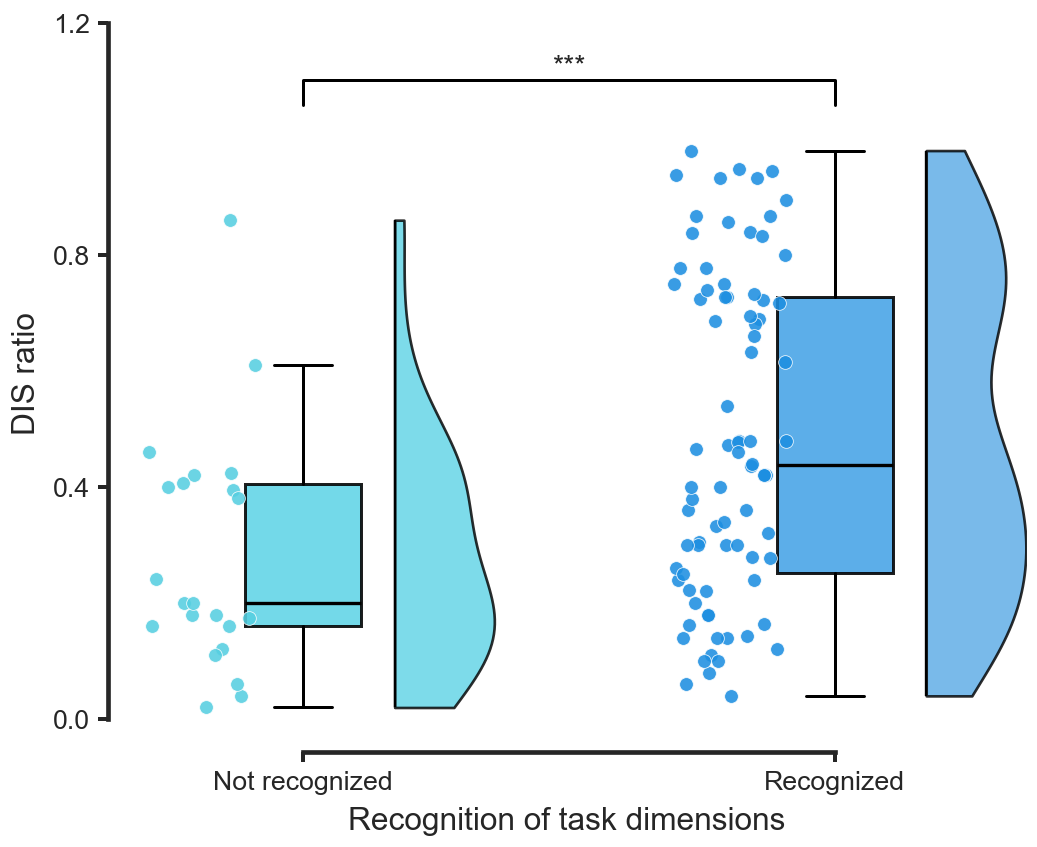


=== 4D_dimensions_recognized × FDS_ratio | Trimmed Mann–Whitney U ===
0 vs 1: p = 0.0004519
=== 4D_dimensions_recognized × FDS_ratio | Effect size ===
0 vs 1: rank-biserial r = 0.4296 (medium), U = 514.5000, n0 = 22, n1 = 82


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_recognized_FDS_dimensions.png


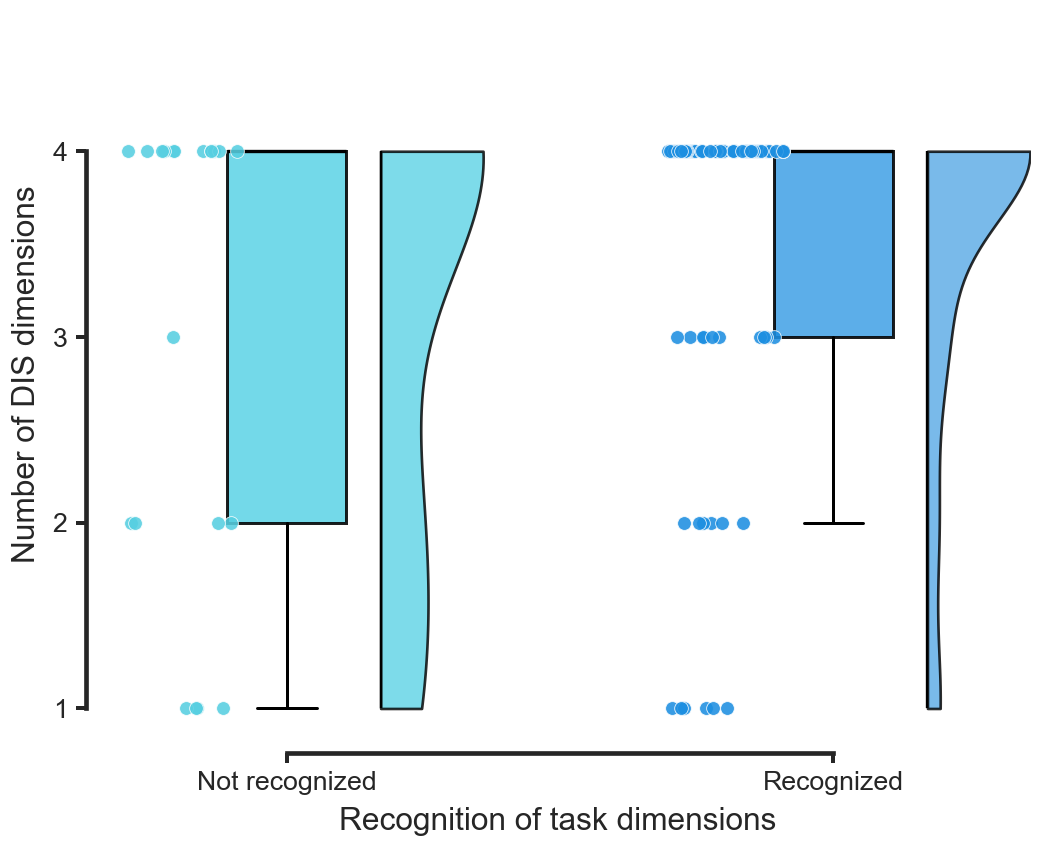


=== 4D_dimensions_recognized × FDS_dimensions | Trimmed Mann–Whitney U ===
0 vs 1: p = 0.176
=== 4D_dimensions_recognized × FDS_dimensions | Effect size ===
0 vs 1: rank-biserial r = 0.1558 (small), U = 761.5000, n0 = 22, n1 = 82


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_recognized_FDS_counts_per_dms.png


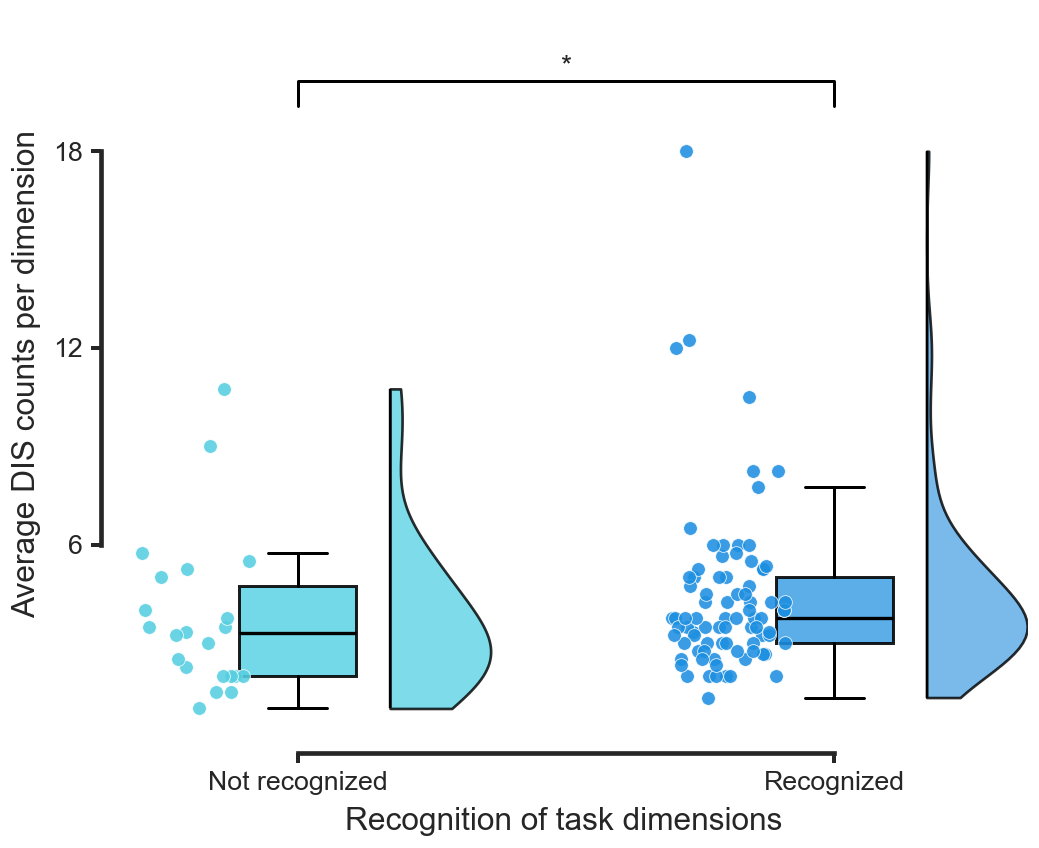


=== 4D_dimensions_recognized × FDS_counts_per_dms | Trimmed Mann–Whitney U ===
0 vs 1: p = 0.04863
=== 4D_dimensions_recognized × FDS_counts_per_dms | Effect size ===
0 vs 1: rank-biserial r = 0.2317 (small), U = 693.0000, n0 = 22, n1 = 82


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_recognized_FDS_patterns_per_dms.png


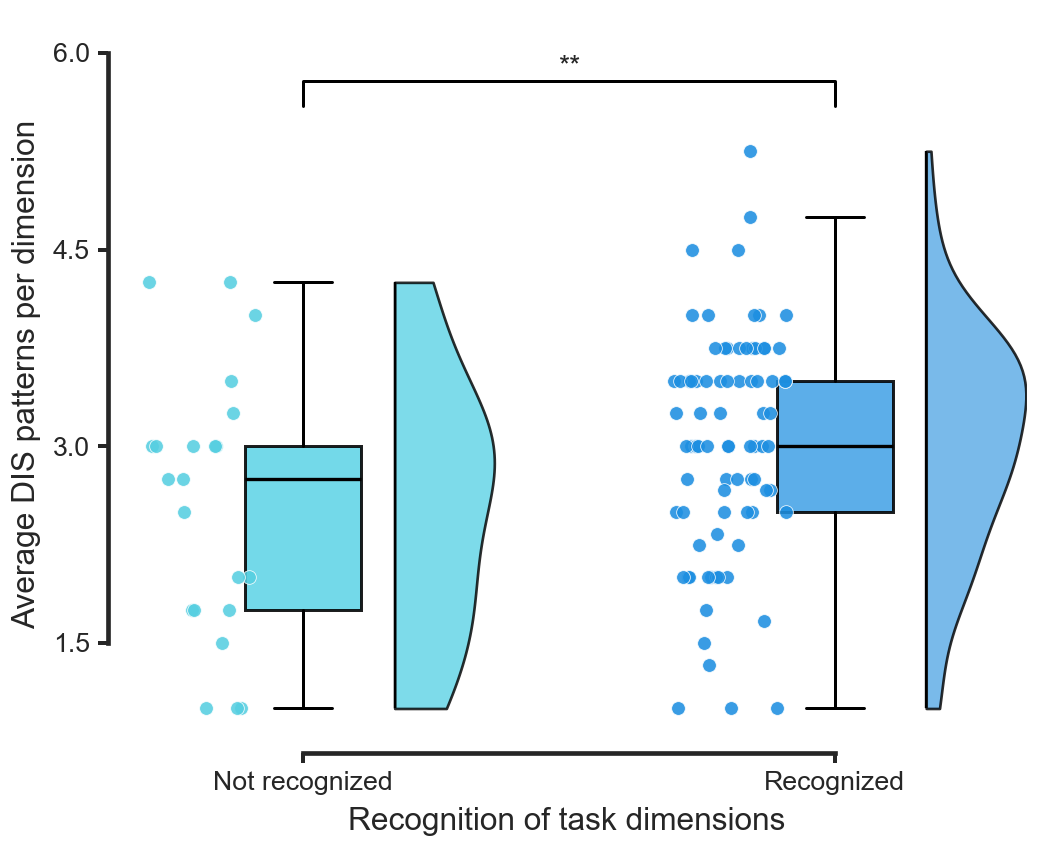


=== 4D_dimensions_recognized × FDS_patterns_per_dms | Trimmed Mann–Whitney U ===
0 vs 1: p = 0.00258
=== 4D_dimensions_recognized × FDS_patterns_per_dms | Effect size ===
0 vs 1: rank-biserial r = 0.2744 (small), U = 654.5000, n0 = 22, n1 = 82


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_features_relevant_answer_FDS_ratio.png


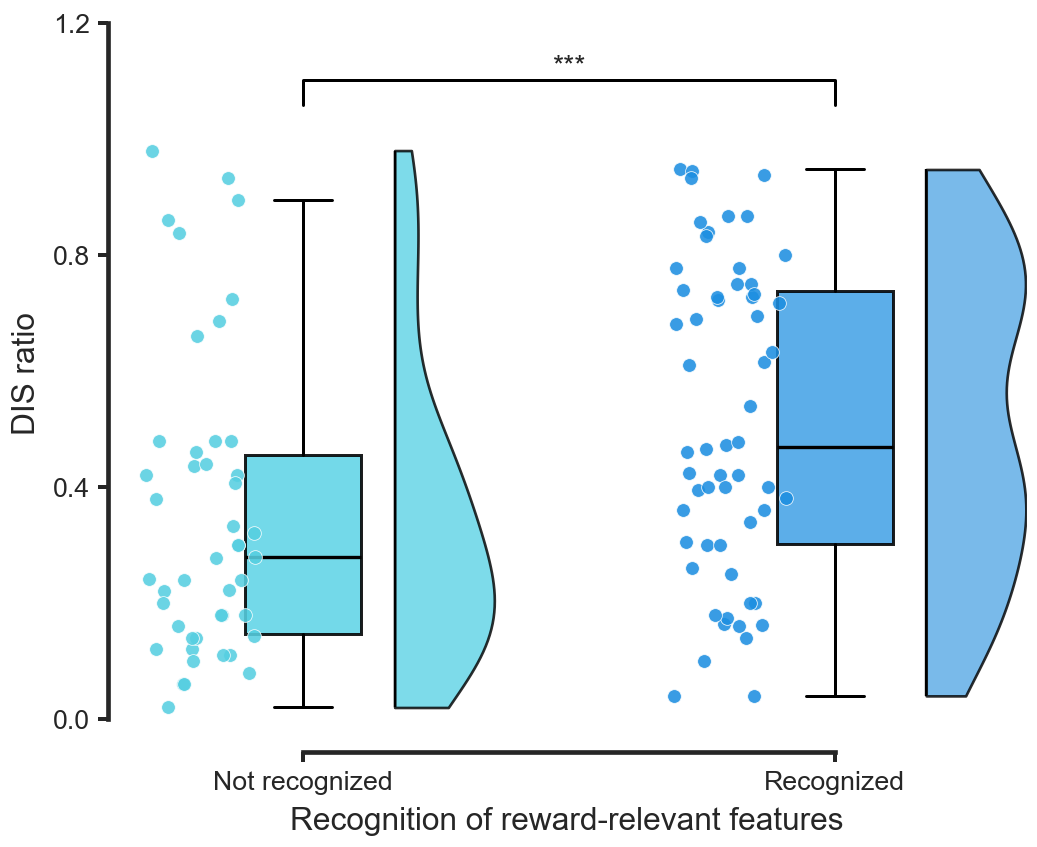


=== 4D_features_relevant_answer × FDS_ratio | Trimmed Mann–Whitney U ===
0 vs 1: p = 0.0002271
=== 4D_features_relevant_answer × FDS_ratio | Effect size ===
0 vs 1: rank-biserial r = 0.3549 (medium), U = 860.5000, n0 = 46, n1 = 58


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_features_relevant_answer_FDS_dimensions.png


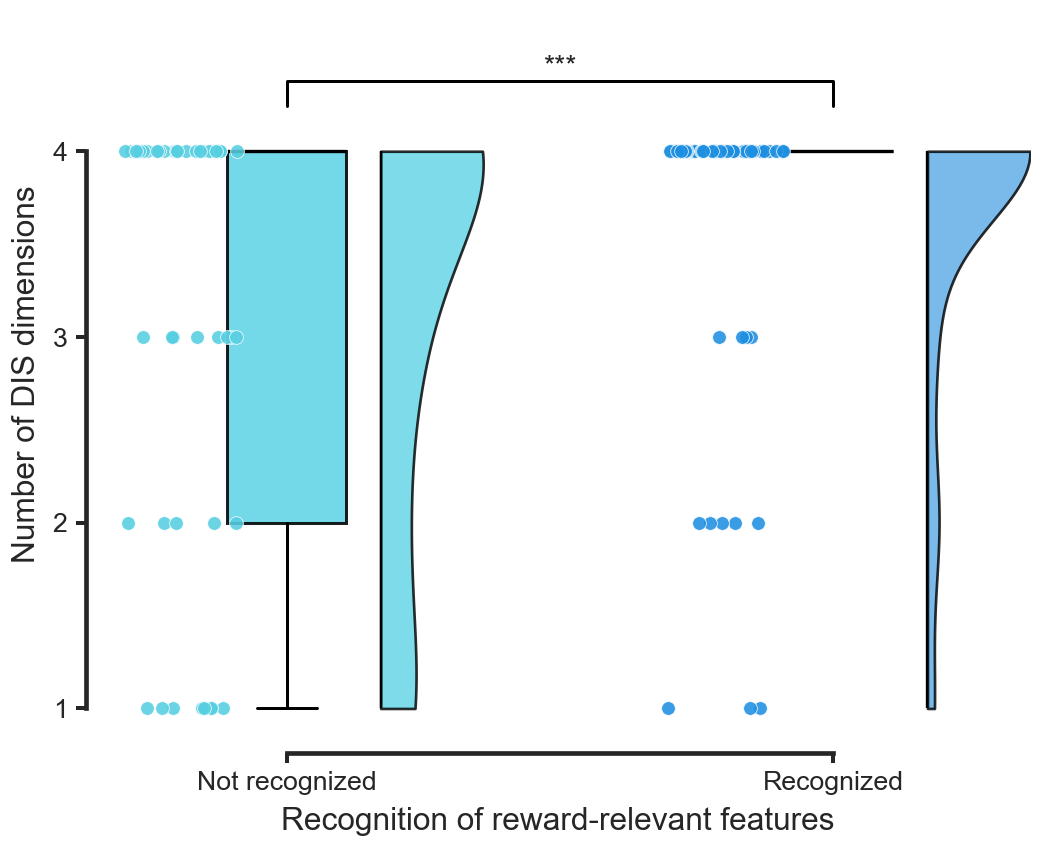


=== 4D_features_relevant_answer × FDS_dimensions | Trimmed Mann–Whitney U ===
0 vs 1: p = 0.0008063
=== 4D_features_relevant_answer × FDS_dimensions | Effect size ===
0 vs 1: rank-biserial r = 0.2545 (small), U = 994.5000, n0 = 46, n1 = 58


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_features_relevant_answer_FDS_counts_per_dms.png


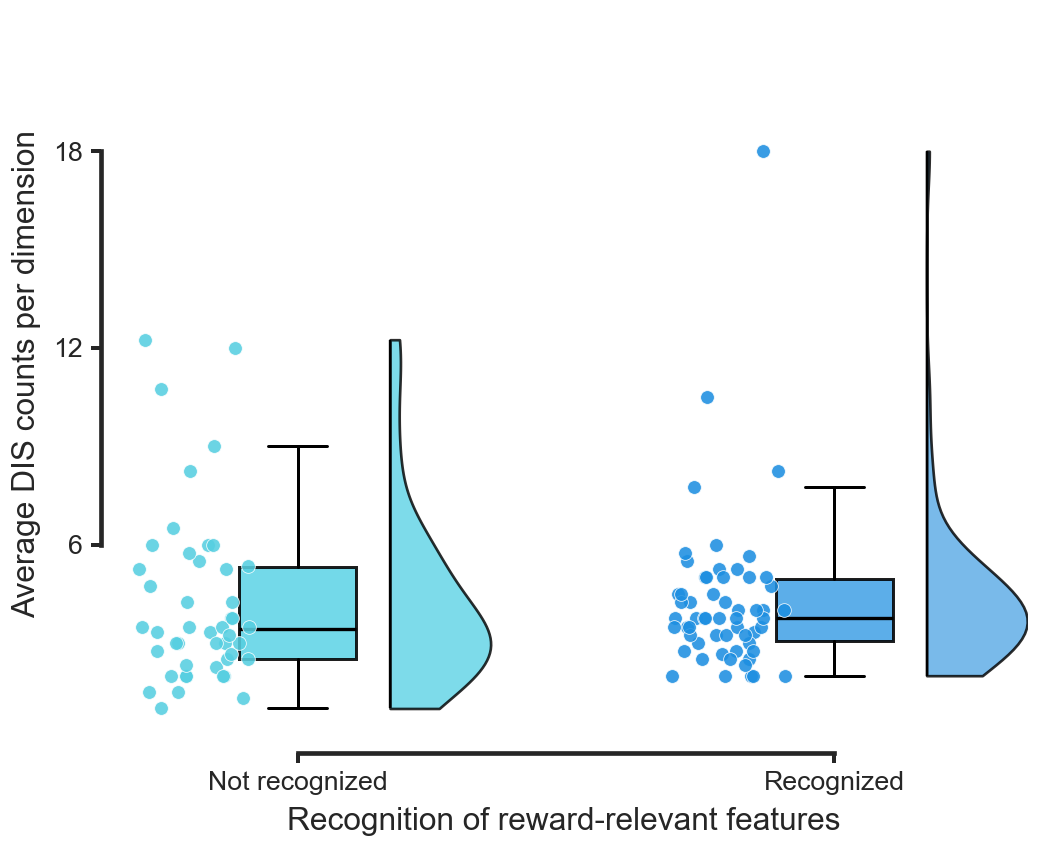


=== 4D_features_relevant_answer × FDS_counts_per_dms | Trimmed Mann–Whitney U ===
0 vs 1: p = 0.449
=== 4D_features_relevant_answer × FDS_counts_per_dms | Effect size ===
0 vs 1: rank-biserial r = 0.1023 (small), U = 1197.5000, n0 = 46, n1 = 58


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_features_relevant_answer_FDS_patterns_per_dms.png


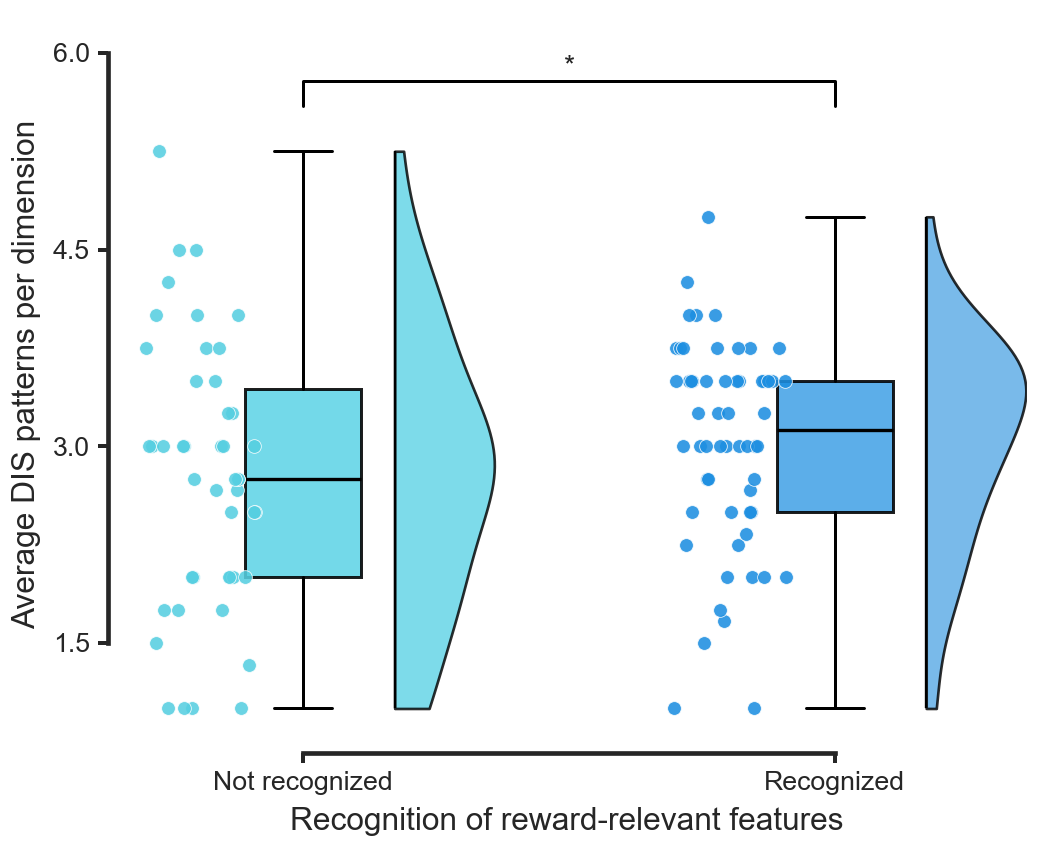


=== 4D_features_relevant_answer × FDS_patterns_per_dms | Trimmed Mann–Whitney U ===
0 vs 1: p = 0.01157
=== 4D_features_relevant_answer × FDS_patterns_per_dms | Effect size ===
0 vs 1: rank-biserial r = 0.1825 (small), U = 1090.5000, n0 = 46, n1 = 58


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_strict_FDS_ratio.png


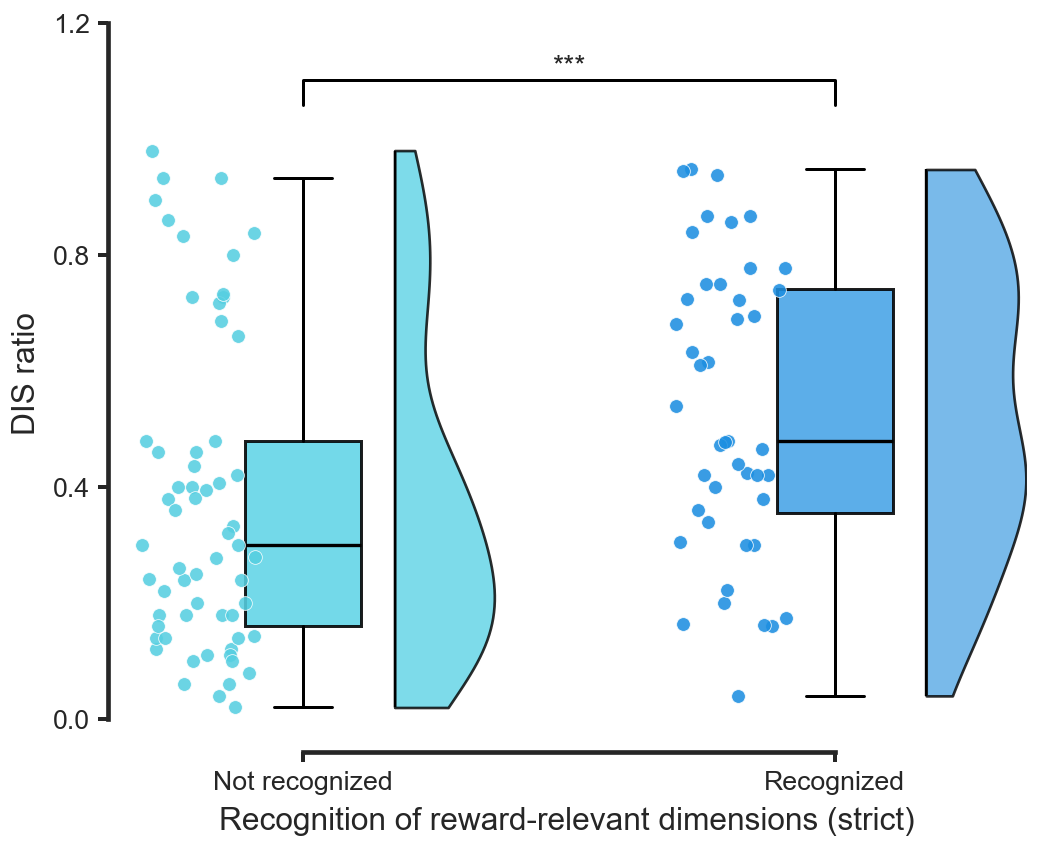


=== 4D_dimensions_relevant_answer_strict × FDS_ratio | Trimmed Mann–Whitney U ===
0 vs 1: p = 0.0001776
=== 4D_dimensions_relevant_answer_strict × FDS_ratio | Effect size ===
0 vs 1: rank-biserial r = 0.3711 (medium), U = 844.0000, n0 = 61, n1 = 44


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_strict_FDS_dimensions.png


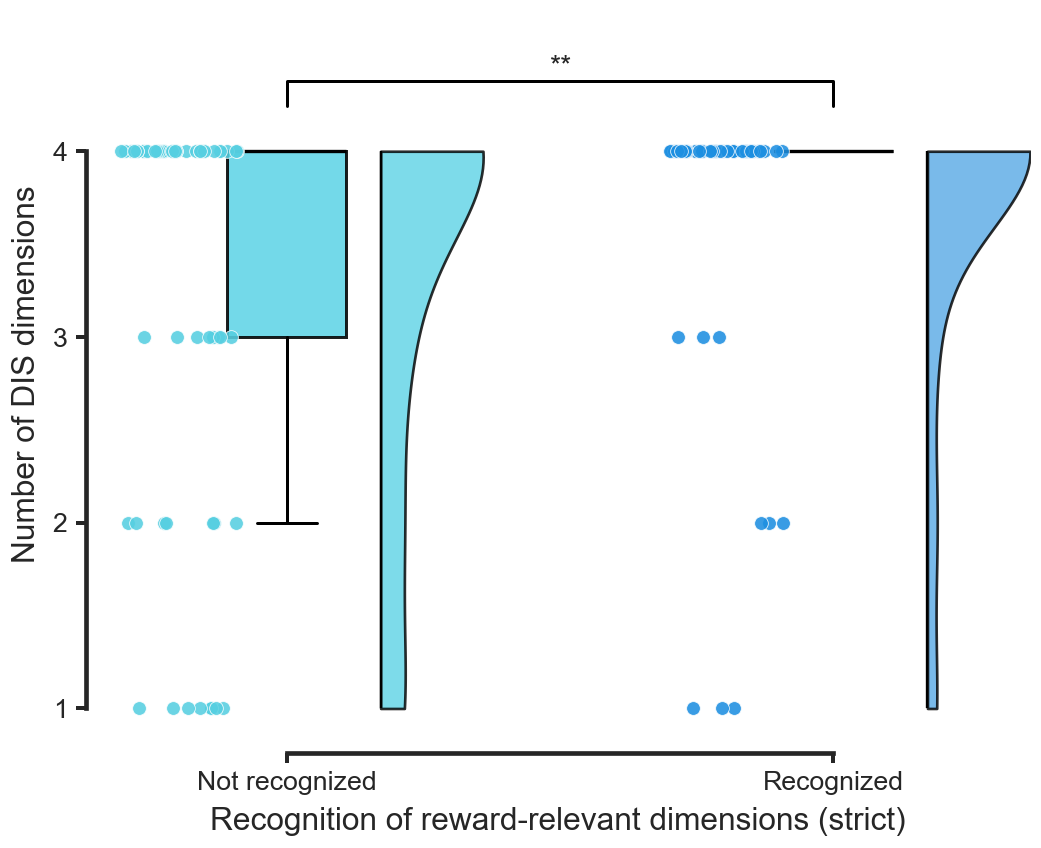


=== 4D_dimensions_relevant_answer_strict × FDS_dimensions | Trimmed Mann–Whitney U ===
0 vs 1: p = 0.005117
=== 4D_dimensions_relevant_answer_strict × FDS_dimensions | Effect size ===
0 vs 1: rank-biserial r = 0.1867 (small), U = 1091.5000, n0 = 61, n1 = 44


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_strict_FDS_counts_per_dms.png


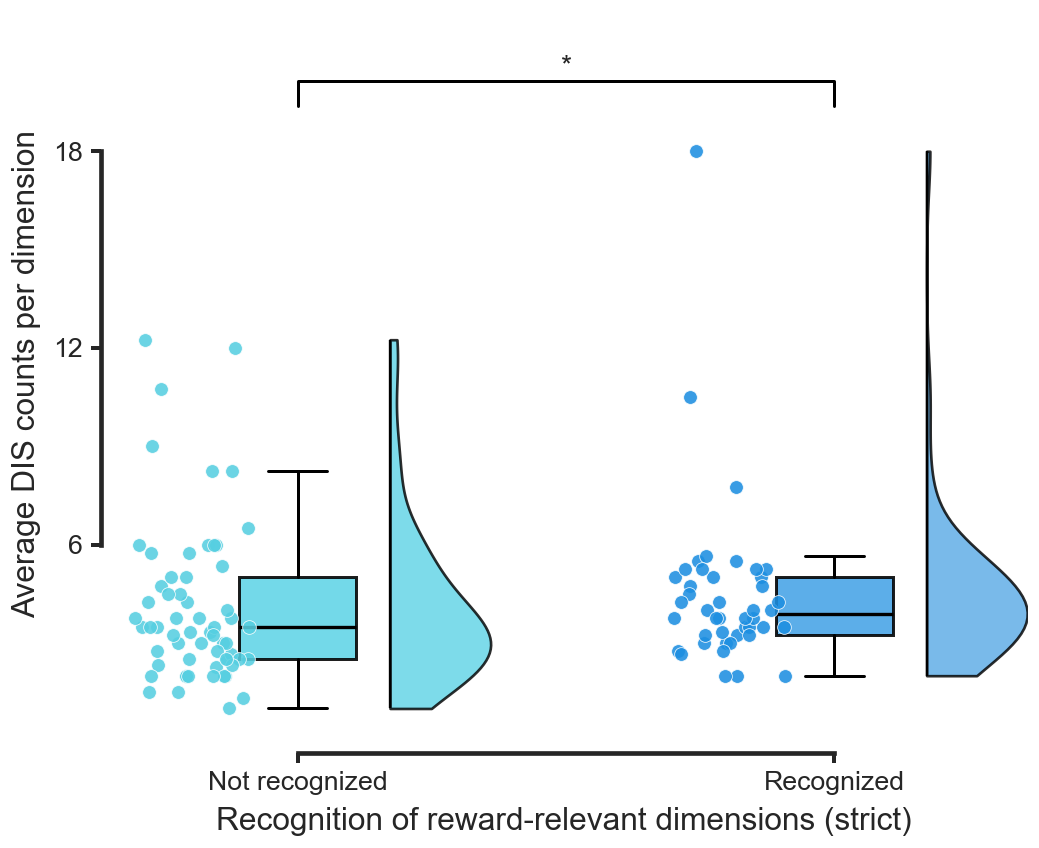


=== 4D_dimensions_relevant_answer_strict × FDS_counts_per_dms | Trimmed Mann–Whitney U ===
0 vs 1: p = 0.04356
=== 4D_dimensions_relevant_answer_strict × FDS_counts_per_dms | Effect size ===
0 vs 1: rank-biserial r = 0.1911 (small), U = 1085.5000, n0 = 61, n1 = 44


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_strict_FDS_patterns_per_dms.png


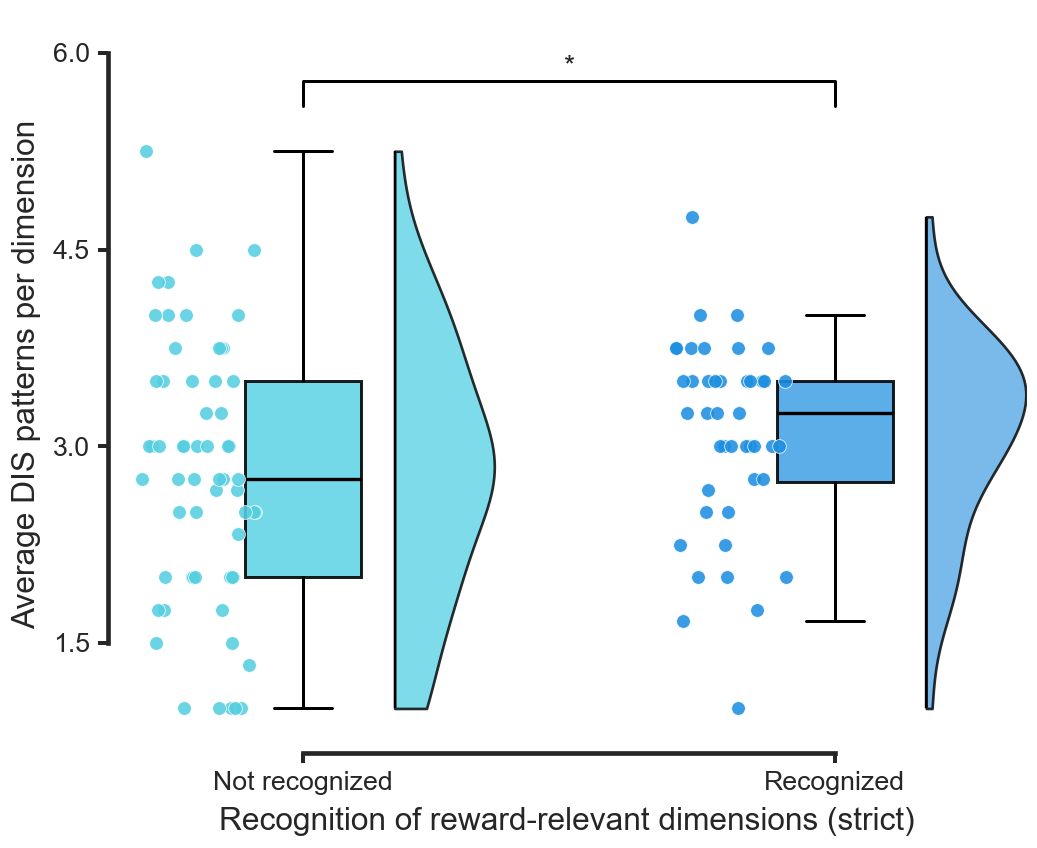


=== 4D_dimensions_relevant_answer_strict × FDS_patterns_per_dms | Trimmed Mann–Whitney U ===
0 vs 1: p = 0.01648
=== 4D_dimensions_relevant_answer_strict × FDS_patterns_per_dms | Effect size ===
0 vs 1: rank-biserial r = 0.1986 (small), U = 1075.5000, n0 = 61, n1 = 44


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_F1_FDS_ratio.png


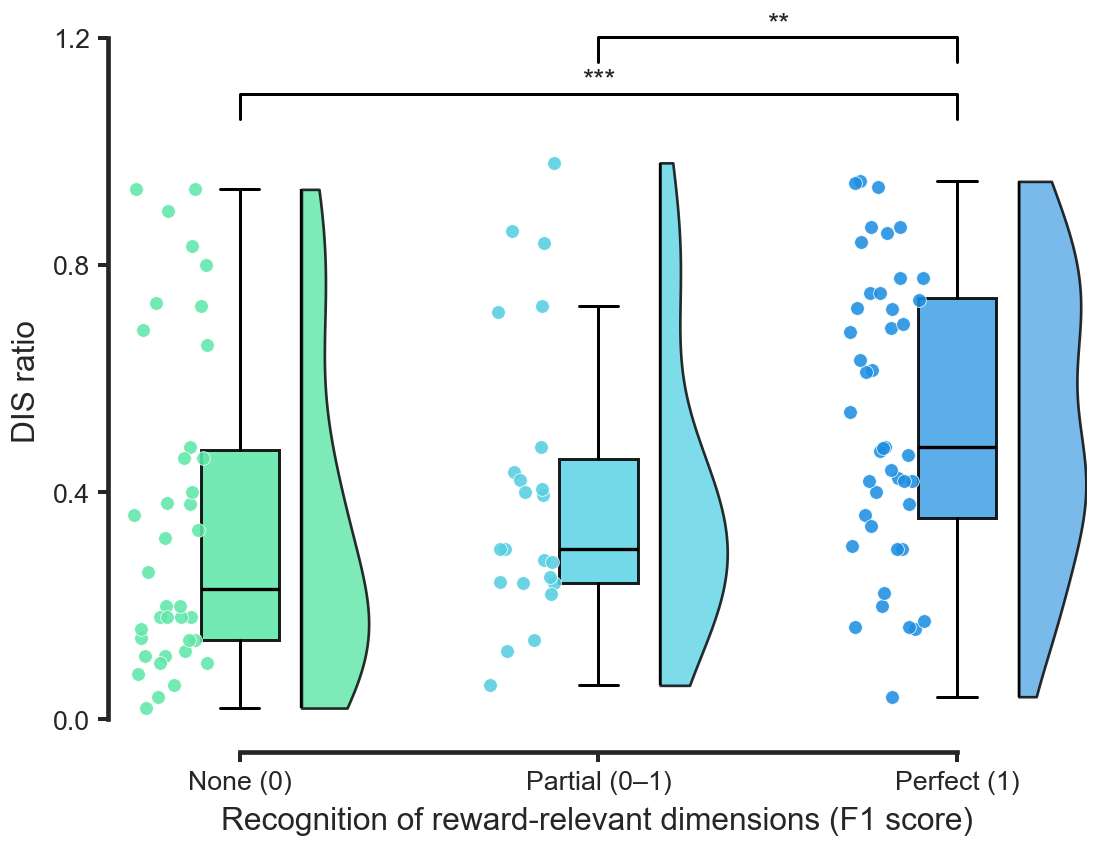


=== 4D_dimensions_relevant_answer_F1 × FDS_ratio | Spearman correlation ===
rho = 0.3281, p = 0.0006335, effect size = medium

=== 4D_dimensions_relevant_answer_F1 × FDS_ratio | Trimmed Mann–Whitney U pairwise comparisons ===
None (0) vs Partial (0–1): p = 0.1478
None (0) vs Perfect (1): p = 0.0004406
Partial (0–1) vs Perfect (1): p = 0.009341

=== 4D_dimensions_relevant_answer_F1 × FDS_ratio | Pairwise effect sizes ===
None (0) vs Partial (0–1): rank-biserial r = 0.1979 (small), U = 350.5000, n = 38 vs 23
None (0) vs Perfect (1): rank-biserial r = 0.4055 (medium), U = 497.0000, n = 38 vs 44
Partial (0–1) vs Perfect (1): rank-biserial r = 0.3142 (medium), U = 347.0000, n = 23 vs 44


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_F1_FDS_dimensions.png


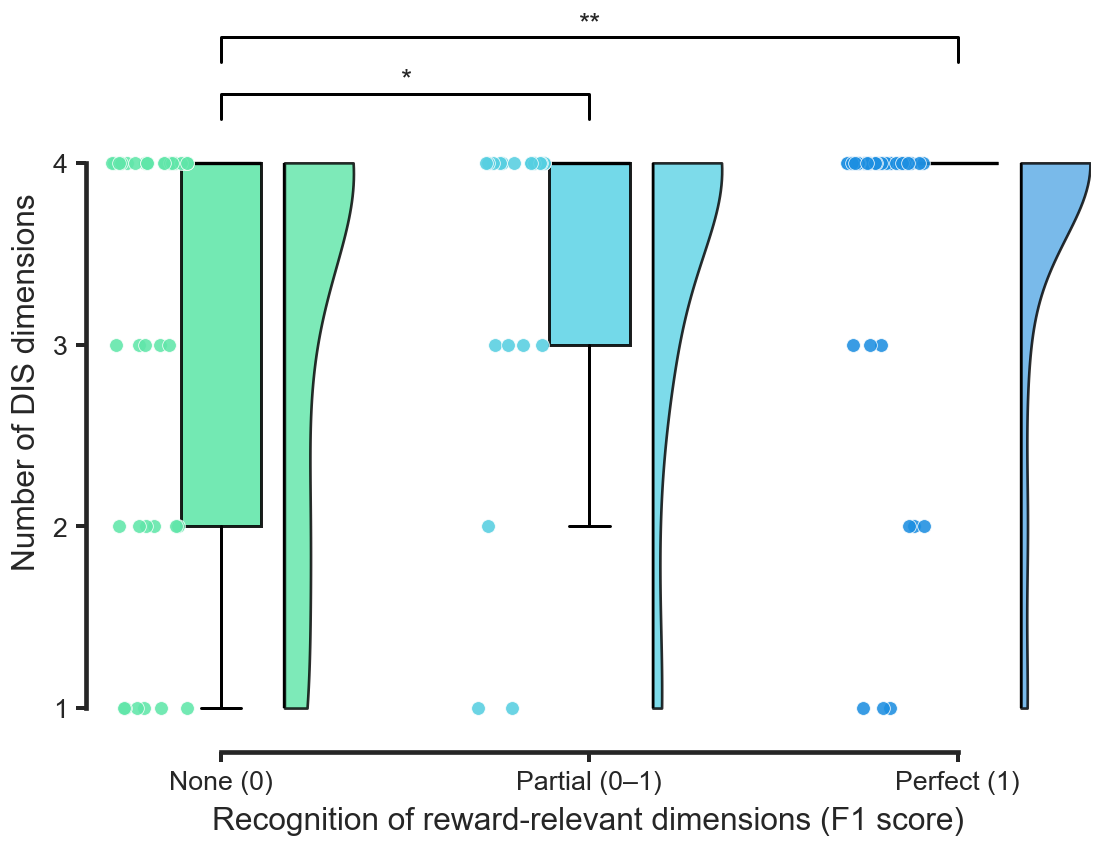


=== 4D_dimensions_relevant_answer_F1 × FDS_dimensions | Spearman correlation ===
rho = 0.2145, p = 0.02802, effect size = small

=== 4D_dimensions_relevant_answer_F1 × FDS_dimensions | Trimmed Mann–Whitney U pairwise comparisons ===
None (0) vs Partial (0–1): p = 0.04899
None (0) vs Perfect (1): p = 0.001891
Partial (0–1) vs Perfect (1): p = 0.4401

=== 4D_dimensions_relevant_answer_F1 × FDS_dimensions | Pairwise effect sizes ===
None (0) vs Partial (0–1): rank-biserial r = 0.1739 (small), U = 361.0000, n = 38 vs 23
None (0) vs Perfect (1): rank-biserial r = 0.2464 (small), U = 630.0000, n = 38 vs 44
Partial (0–1) vs Perfect (1): rank-biserial r = 0.0879 (negligible), U = 461.5000, n = 23 vs 44


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_F1_FDS_counts_per_dms.png


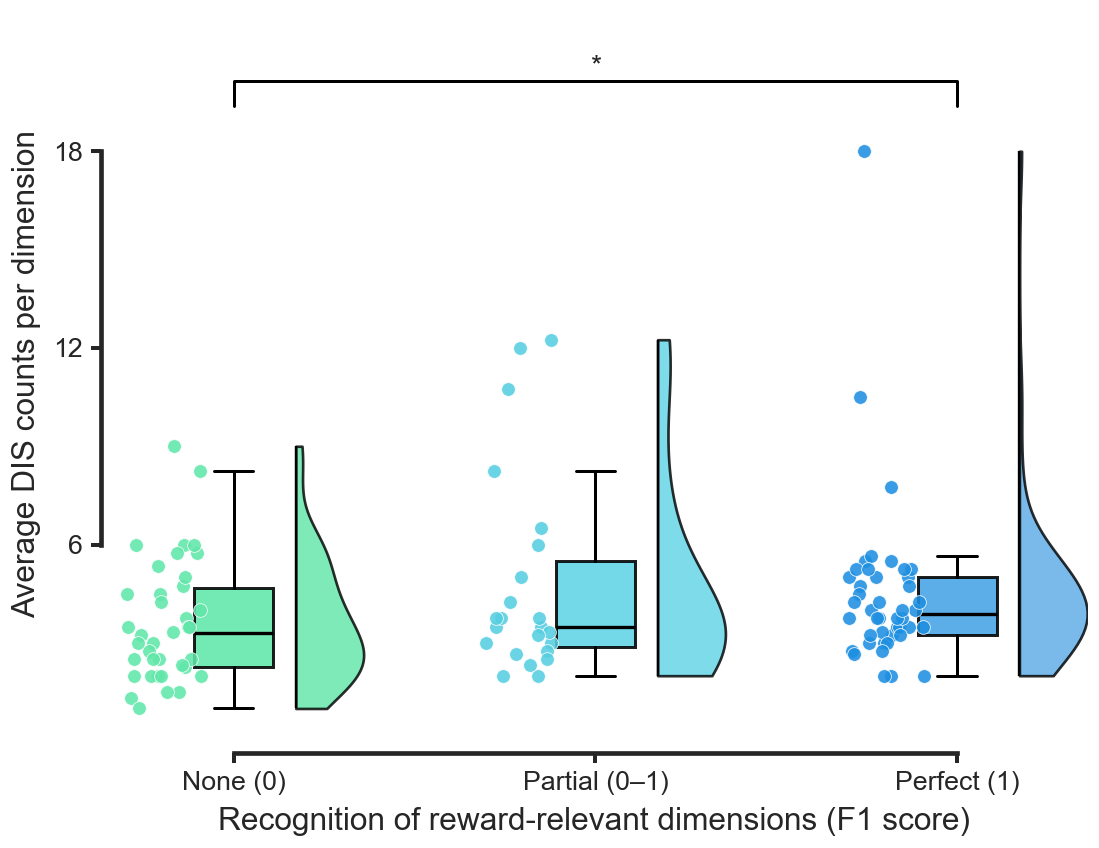


=== 4D_dimensions_relevant_answer_F1 × FDS_counts_per_dms | Spearman correlation ===
rho = 0.2005, p = 0.04026, effect size = small

=== 4D_dimensions_relevant_answer_F1 × FDS_counts_per_dms | Trimmed Mann–Whitney U pairwise comparisons ===
None (0) vs Partial (0–1): p = 0.1606
None (0) vs Perfect (1): p = 0.03318
Partial (0–1) vs Perfect (1): p = 0.3636

=== 4D_dimensions_relevant_answer_F1 × FDS_counts_per_dms | Pairwise effect sizes ===
None (0) vs Partial (0–1): rank-biserial r = 0.2094 (small), U = 345.5000, n = 38 vs 23
None (0) vs Perfect (1): rank-biserial r = 0.2470 (small), U = 629.5000, n = 38 vs 44
Partial (0–1) vs Perfect (1): rank-biserial r = 0.0988 (negligible), U = 456.0000, n = 23 vs 44


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_F1_FDS_patterns_per_dms.png


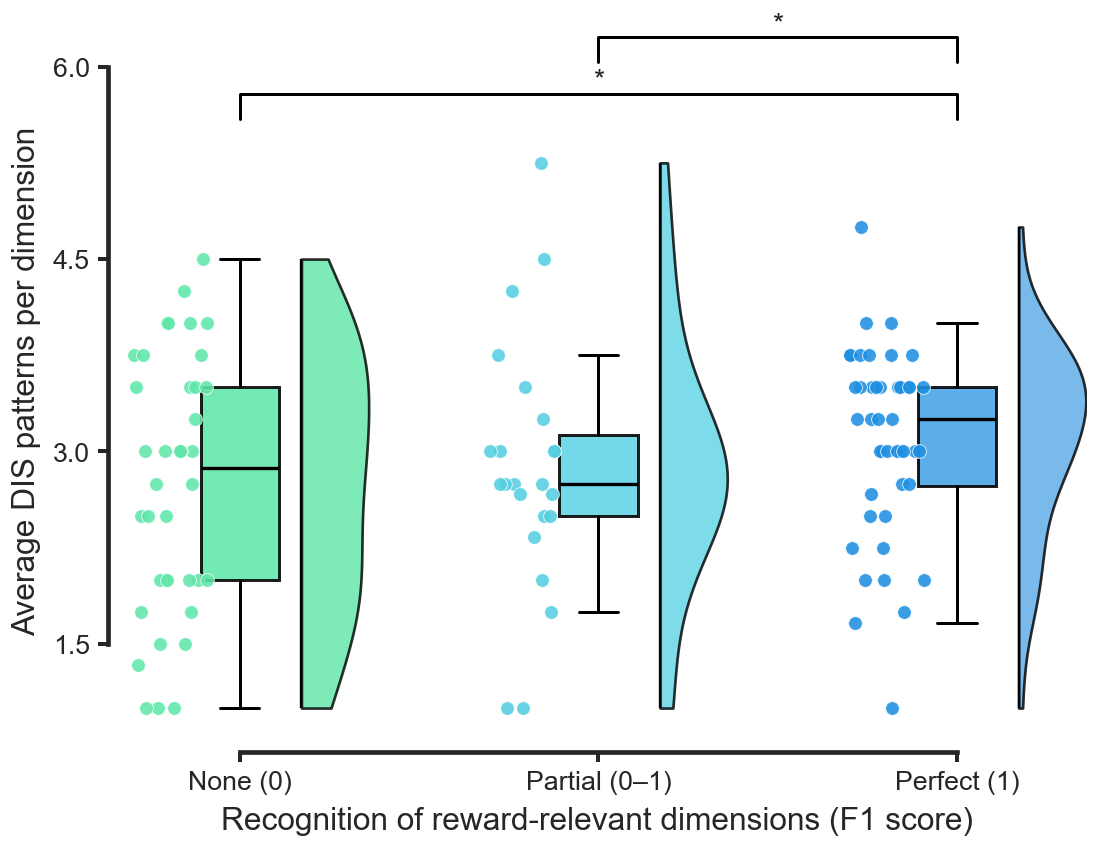


=== 4D_dimensions_relevant_answer_F1 × FDS_patterns_per_dms | Spearman correlation ===
rho = 0.1589, p = 0.1053, effect size = small

=== 4D_dimensions_relevant_answer_F1 × FDS_patterns_per_dms | Trimmed Mann–Whitney U pairwise comparisons ===
None (0) vs Partial (0–1): p = 0.5874
None (0) vs Perfect (1): p = 0.04536
Partial (0–1) vs Perfect (1): p = 0.04915

=== 4D_dimensions_relevant_answer_F1 × FDS_patterns_per_dms | Pairwise effect sizes ===
None (0) vs Partial (0–1): rank-biserial r = 0.0343 (negligible), U = 422.0000, n = 38 vs 23
None (0) vs Perfect (1): rank-biserial r = 0.1824 (small), U = 683.5000, n = 38 vs 44
Partial (0–1) vs Perfect (1): rank-biserial r = 0.2253 (small), U = 392.0000, n = 23 vs 44


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_hit_minus_false_FDS_ratio.png


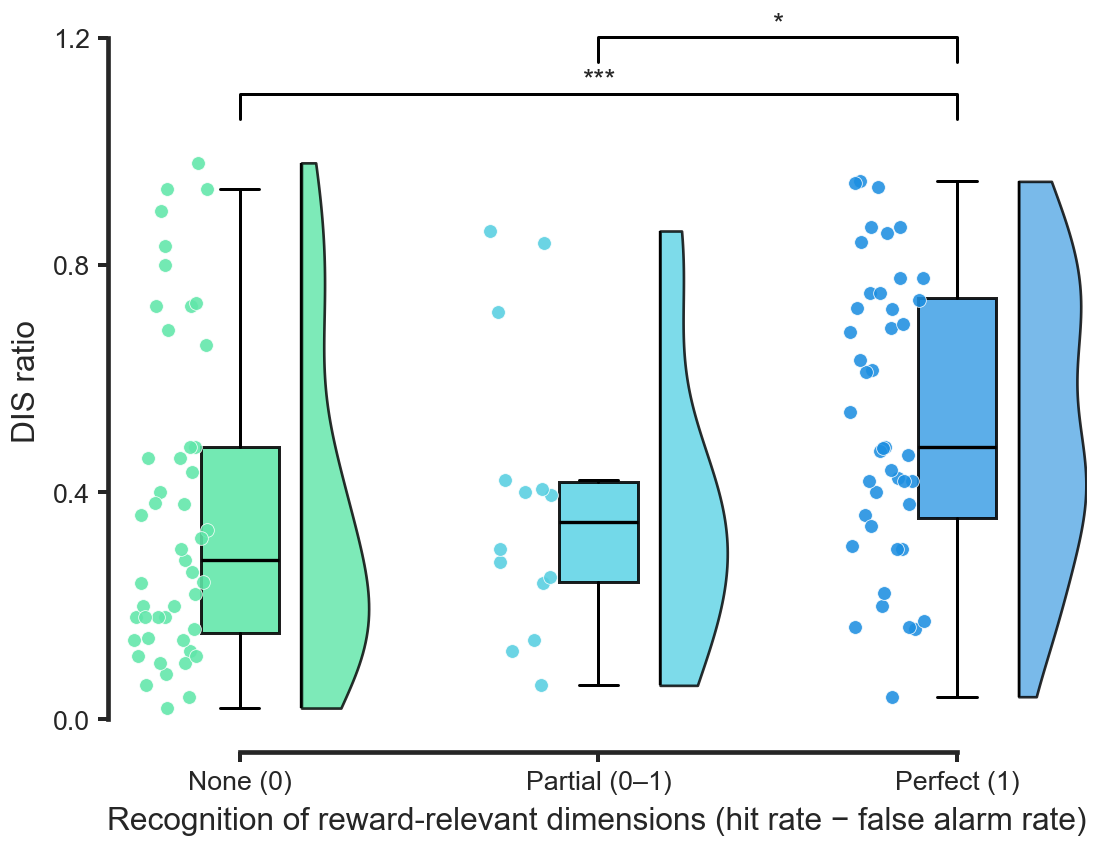


=== 4D_dimensions_relevant_answer_hit_minus_false × FDS_ratio | Spearman correlation ===
rho = 0.3072, p = 0.001432, effect size = medium

=== 4D_dimensions_relevant_answer_hit_minus_false × FDS_ratio | Trimmed Mann–Whitney U pairwise comparisons ===
None (0) vs Partial (0–1): p = 0.5305
None (0) vs Perfect (1): p = 0.0003957
Partial (0–1) vs Perfect (1): p = 0.01812

=== 4D_dimensions_relevant_answer_hit_minus_false × FDS_ratio | Pairwise effect sizes ===
None (0) vs Partial (0–1): rank-biserial r = 0.0866 (negligible), U = 300.5000, n = 47 vs 14
None (0) vs Perfect (1): rank-biserial r = 0.3728 (medium), U = 648.5000, n = 47 vs 44
Partial (0–1) vs Perfect (1): rank-biserial r = 0.3653 (medium), U = 195.5000, n = 14 vs 44


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_hit_minus_false_FDS_dimensions.png


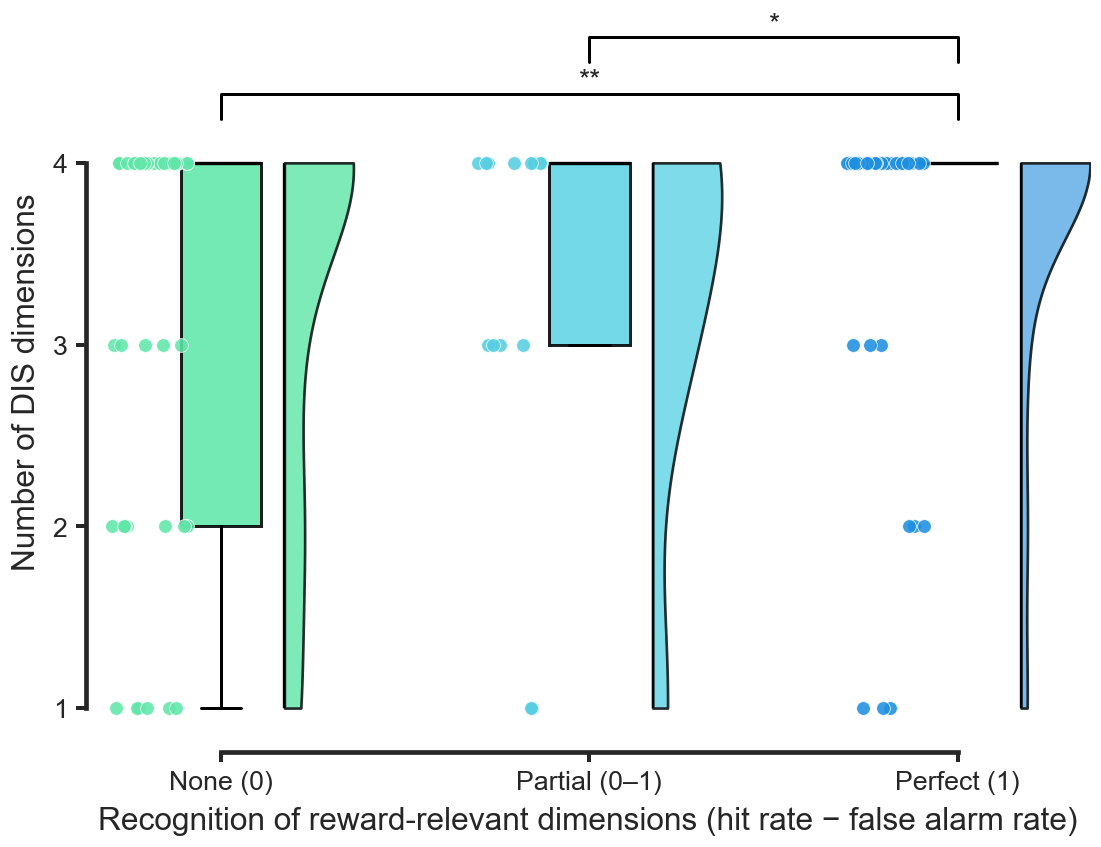


=== 4D_dimensions_relevant_answer_hit_minus_false × FDS_dimensions | Spearman correlation ===
rho = 0.1790, p = 0.06763, effect size = small

=== 4D_dimensions_relevant_answer_hit_minus_false × FDS_dimensions | Trimmed Mann–Whitney U pairwise comparisons ===
None (0) vs Partial (0–1): p = 0.9922
None (0) vs Perfect (1): p = 0.007926
Partial (0–1) vs Perfect (1): p = 0.03102

=== 4D_dimensions_relevant_answer_hit_minus_false × FDS_dimensions | Pairwise effect sizes ===
None (0) vs Partial (0–1): rank-biserial r = -0.0030 (negligible), U = 330.0000, n = 47 vs 14
None (0) vs Perfect (1): rank-biserial r = 0.1813 (small), U = 846.5000, n = 47 vs 44
Partial (0–1) vs Perfect (1): rank-biserial r = 0.2045 (small), U = 245.0000, n = 14 vs 44


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_hit_minus_false_FDS_counts_per_dms.png


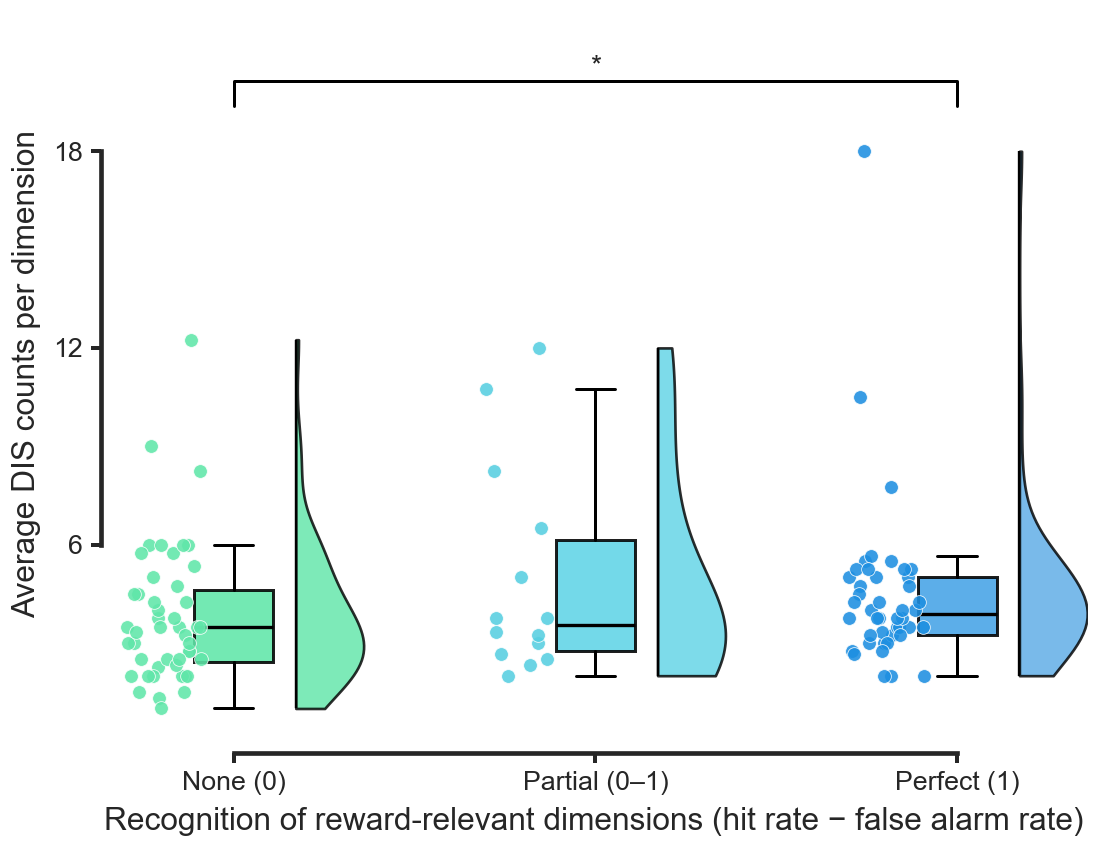


=== 4D_dimensions_relevant_answer_hit_minus_false × FDS_counts_per_dms | Spearman correlation ===
rho = 0.1846, p = 0.05945, effect size = small

=== 4D_dimensions_relevant_answer_hit_minus_false × FDS_counts_per_dms | Trimmed Mann–Whitney U pairwise comparisons ===
None (0) vs Partial (0–1): p = 0.2514
None (0) vs Perfect (1): p = 0.0251
Partial (0–1) vs Perfect (1): p = 0.5088

=== 4D_dimensions_relevant_answer_hit_minus_false × FDS_counts_per_dms | Pairwise effect sizes ===
None (0) vs Partial (0–1): rank-biserial r = 0.1763 (small), U = 271.0000, n = 47 vs 14
None (0) vs Perfect (1): rank-biserial r = 0.2229 (small), U = 803.5000, n = 47 vs 44
Partial (0–1) vs Perfect (1): rank-biserial r = 0.0844 (negligible), U = 282.0000, n = 14 vs 44


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_hit_minus_false_FDS_patterns_per_dms.png


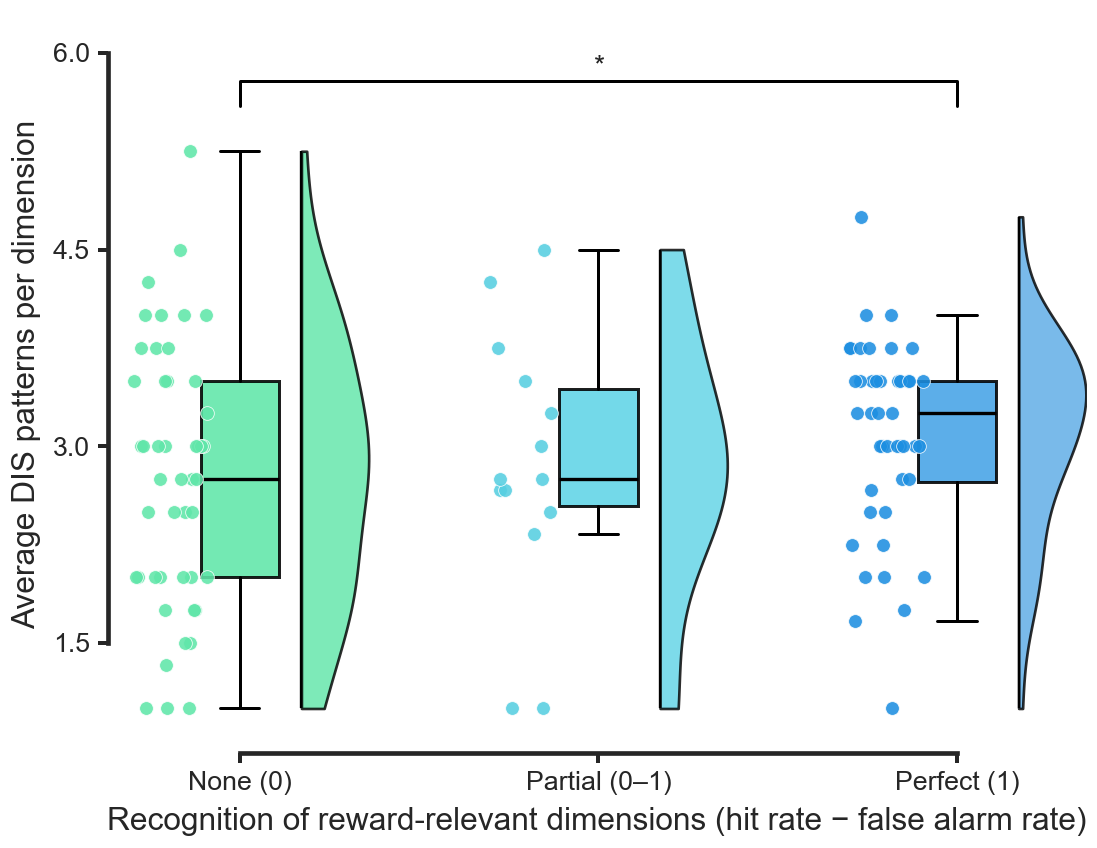


=== 4D_dimensions_relevant_answer_hit_minus_false × FDS_patterns_per_dms | Spearman correlation ===
rho = 0.1687, p = 0.08536, effect size = small

=== 4D_dimensions_relevant_answer_hit_minus_false × FDS_patterns_per_dms | Trimmed Mann–Whitney U pairwise comparisons ===
None (0) vs Partial (0–1): p = 0.9513
None (0) vs Perfect (1): p = 0.03663
Partial (0–1) vs Perfect (1): p = 0.1348

=== 4D_dimensions_relevant_answer_hit_minus_false × FDS_patterns_per_dms | Pairwise effect sizes ===
None (0) vs Partial (0–1): rank-biserial r = 0.0486 (negligible), U = 313.0000, n = 47 vs 14
None (0) vs Perfect (1): rank-biserial r = 0.2084 (small), U = 818.5000, n = 47 vs 44
Partial (0–1) vs Perfect (1): rank-biserial r = 0.1656 (small), U = 257.0000, n = 14 vs 44


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# =========================
# effect size helpers
# =========================
def mannwhitney_effect_size_rbc(x, y):
    """
    Rank-biserial correlation for two independent groups.
    Returns:
        r_rb, u_stat, n1, n2
    """
    x = pd.Series(x).dropna().to_numpy()
    y = pd.Series(y).dropna().to_numpy()

    n1, n2 = len(x), len(y)
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan, n1, n2

    u_stat, _ = mannwhitneyu(x, y, alternative="two-sided")
    r_rb = 1 - (2 * u_stat) / (n1 * n2)
    return r_rb, u_stat, n1, n2


def interpret_rbc(r):
    if pd.isna(r):
        return "NaN"
    ar = abs(r)
    if ar < 0.10:
        return "negligible"
    elif ar < 0.30:
        return "small"
    elif ar < 0.50:
        return "medium"
    else:
        return "large"


def interpret_spearman_rho(rho):
    if pd.isna(rho):
        return "NaN"
    ar = abs(rho)
    if ar < 0.10:
        return "negligible"
    elif ar < 0.30:
        return "small"
    elif ar < 0.50:
        return "medium"
    else:
        return "large"

# =========================
# DIS 指标标签
# =========================
fds_metric_label_map = {
    "FDS_ratio": "DIS ratio",
    "FDS_dimensions": "Number of DIS dimensions",
    "FDS_counts_per_dms": "Average DIS counts per dimension",
    "FDS_patterns_per_dms": "Average DIS patterns per dimension",
}

fds_metrics_to_plot = [
    "FDS_ratio",
    "FDS_dimensions",
    "FDS_counts_per_dms",
    "FDS_patterns_per_dms",
]

# =========================
# 1) binary 文本指标 × DIS指标
# =========================
def plot_binary_metric_with_fds(data, text_metric_col, fds_metric_col, save_dir):
    plot_df = data.copy()
    plot_df = plot_df[plot_df[text_metric_col].isin([0, 1])].copy()
    plot_df = plot_df[pd.notna(plot_df[fds_metric_col])].copy()

    if len(plot_df) == 0:
        print(f"[跳过] {text_metric_col} × {fds_metric_col}: 没有有效数据")
        return

    metric_levels = binary_level_label_map.get(
        text_metric_col,
        {0: "Not recognized", 1: "Recognized"}
    )

    group_labels = [metric_levels[0], metric_levels[1]]
    group_colors = SURVEY_COLORS_2.copy()

    g0 = plot_df.loc[plot_df[text_metric_col] == 0, fds_metric_col].dropna().values
    g1 = plot_df.loc[plot_df[text_metric_col] == 1, fds_metric_col].dropna().values

    values_by_group = [g0, g1]

    p_val = mannwhitney_between_groups_trimmed(
        plot_df, text_metric_col, fds_metric_col, 0, 1
    )

    r_rb, u_stat, n0, n1 = mannwhitney_effect_size_rbc(g0, g1)

    fig, ax = plt.subplots(1, 1, figsize=(9, 7.5))

    draw_grouped_scatter_box_halfviolin(
        ax=ax,
        values_by_group=values_by_group,
        group_labels=group_labels,
        group_colors=group_colors,
        ylabel=fds_metric_label_map.get(fds_metric_col, fds_metric_col),
        xlabel=metric_label_map.get(text_metric_col, text_metric_col),
        pairwise_stats={(0, 1): p_val}
    )

    plt.tight_layout()

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    filename = f"{text_metric_col}_{fds_metric_col}.png"
    out = save_dir / filename
    style_figure(fig)
    save_figure(fig, out, dpi=300, bbox_inches='tight')
    print(f"Saved figure to: {out.resolve()}")

    style_figure(plt.gcf())
    plt.show()

    print(f"\n=== {text_metric_col} × {fds_metric_col} | Trimmed Mann–Whitney U ===")
    print(f"0 vs 1: p = {p_val:.4g}" if pd.notna(p_val) else "0 vs 1: p = NaN")

    print(f"=== {text_metric_col} × {fds_metric_col} | Effect size ===")
    if pd.notna(r_rb):
        print(
            f"0 vs 1: rank-biserial r = {r_rb:.4f} "
            f"({interpret_rbc(r_rb)}), U = {u_stat:.4f}, n0 = {n0}, n1 = {n1}"
        )
    else:
        print("0 vs 1: rank-biserial r = NaN")


# =========================
# 2) continuous 文本指标 × DIS指标
# =========================
def plot_continuous_metric_with_fds(data, text_metric_col, fds_metric_col, save_dir):
    plot_df = data.copy()
    plot_df = plot_df[pd.notna(plot_df[text_metric_col])].copy()
    plot_df = plot_df[pd.notna(plot_df[fds_metric_col])].copy()

    if len(plot_df) == 0:
        print(f"[跳过] {text_metric_col} × {fds_metric_col}: 没有有效数据")
        return

    level_col = f"{text_metric_col}_level3"
    plot_df[level_col] = plot_df[text_metric_col].apply(categorize_continuous_three_levels)
    plot_df = plot_df[pd.notna(plot_df[level_col])].copy()

    if len(plot_df) == 0:
        print(f"[跳过] {text_metric_col} × {fds_metric_col}: 三分组后无有效数据")
        return

    group_labels = [
        triple_level_label_map[0],
        triple_level_label_map[1],
        triple_level_label_map[2],
    ]
    group_colors = SURVEY_COLORS_3.copy()

    g0 = plot_df.loc[plot_df[level_col] == 0, fds_metric_col].dropna().values
    g1 = plot_df.loc[plot_df[level_col] == 1, fds_metric_col].dropna().values
    g2 = plot_df.loc[plot_df[level_col] == 2, fds_metric_col].dropna().values

    values_by_group = [g0, g1, g2]

    pairwise_pvals = pairwise_mwu_three_groups_trimmed(plot_df, level_col, fds_metric_col)
    rho, p_corr = spearman_xy(plot_df, text_metric_col, fds_metric_col)

    # pairwise effect sizes
    pairwise_effects = {
        (0, 1): mannwhitney_effect_size_rbc(g0, g1),
        (0, 2): mannwhitney_effect_size_rbc(g0, g2),
        (1, 2): mannwhitney_effect_size_rbc(g1, g2),
    }

    fig, ax = plt.subplots(1, 1, figsize=(9.5, 7.5))

    draw_grouped_scatter_box_halfviolin(
        ax=ax,
        values_by_group=values_by_group,
        group_labels=group_labels,
        group_colors=group_colors,
        ylabel=fds_metric_label_map.get(fds_metric_col, fds_metric_col),
        xlabel=metric_label_map.get(text_metric_col, text_metric_col),
        pairwise_stats=pairwise_pvals
    )

    plt.tight_layout()

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    filename = f"{text_metric_col}_{fds_metric_col}.png"
    out = save_dir / filename
    style_figure(fig)
    save_figure(fig, out, dpi=300, bbox_inches='tight')
    print(f"Saved figure to: {out.resolve()}")

    style_figure(plt.gcf())
    plt.show()

    print(f"\n=== {text_metric_col} × {fds_metric_col} | Spearman correlation ===")
    if pd.notna(rho):
        print(f"rho = {rho:.4f}, p = {p_corr:.4g}, effect size = {interpret_spearman_rho(rho)}")
    else:
        print("rho = NaN, p = NaN")

    print(f"\n=== {text_metric_col} × {fds_metric_col} | Trimmed Mann–Whitney U pairwise comparisons ===")
    for pair, p in pairwise_pvals.items():
        a, b = pair
        print(
            f"{triple_level_label_map[a]} vs {triple_level_label_map[b]}: p = {p:.4g}"
            if pd.notna(p) else
            f"{triple_level_label_map[a]} vs {triple_level_label_map[b]}: p = NaN"
        )

    print(f"\n=== {text_metric_col} × {fds_metric_col} | Pairwise effect sizes ===")
    for pair, stats_ in pairwise_effects.items():
        a, b = pair
        r_rb, u_stat, na, nb = stats_
        if pd.notna(r_rb):
            print(
                f"{triple_level_label_map[a]} vs {triple_level_label_map[b]}: "
                f"rank-biserial r = {r_rb:.4f} ({interpret_rbc(r_rb)}), "
                f"U = {u_stat:.4f}, n = {na} vs {nb}"
            )
        else:
            print(
                f"{triple_level_label_map[a]} vs {triple_level_label_map[b]}: "
                f"rank-biserial r = NaN"
            )


# =========================
# 3) 执行
# =========================
save_dir = "figures_saving_for_layout"

binary_metrics_to_plot = [
    "4D_dimensions_recognized",
    "4D_features_relevant_answer",
    "4D_dimensions_relevant_answer_strict",
]

continuous_metrics_to_plot = [
    "4D_dimensions_relevant_answer_F1",
    "4D_dimensions_relevant_answer_hit_minus_false",
]

for text_metric in binary_metrics_to_plot:
    if text_metric not in analysis_fds_df.columns:
        print(f"[缺少列] {text_metric}")
        continue

    for fds_metric in fds_metrics_to_plot:
        if fds_metric not in analysis_fds_df.columns:
            print(f"[缺少列] {fds_metric}")
            continue
        plot_binary_metric_with_fds(
            analysis_fds_df,
            text_metric_col=text_metric,
            fds_metric_col=fds_metric,
            save_dir=save_dir
        )

for text_metric in continuous_metrics_to_plot:
    if text_metric not in analysis_fds_df.columns:
        print(f"[缺少列] {text_metric}")
        continue

    for fds_metric in fds_metrics_to_plot:
        if fds_metric not in analysis_fds_df.columns:
            print(f"[缺少列] {fds_metric}")
            continue
        plot_continuous_metric_with_fds(
            analysis_fds_df,
            text_metric_col=text_metric,
            fds_metric_col=fds_metric,
            save_dir=save_dir
        )

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_recognized_FDS_ratio_purple_white_narrow.png


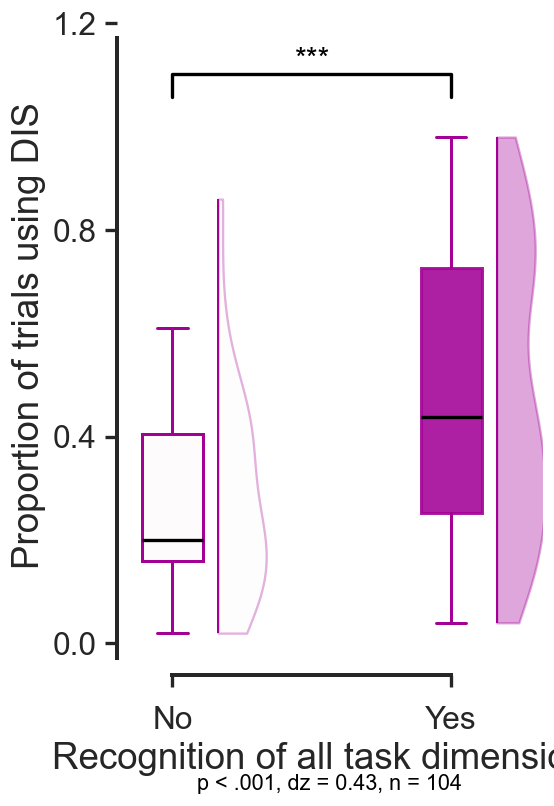

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_recognized_FDS_dimensions_purple_white_narrow.png


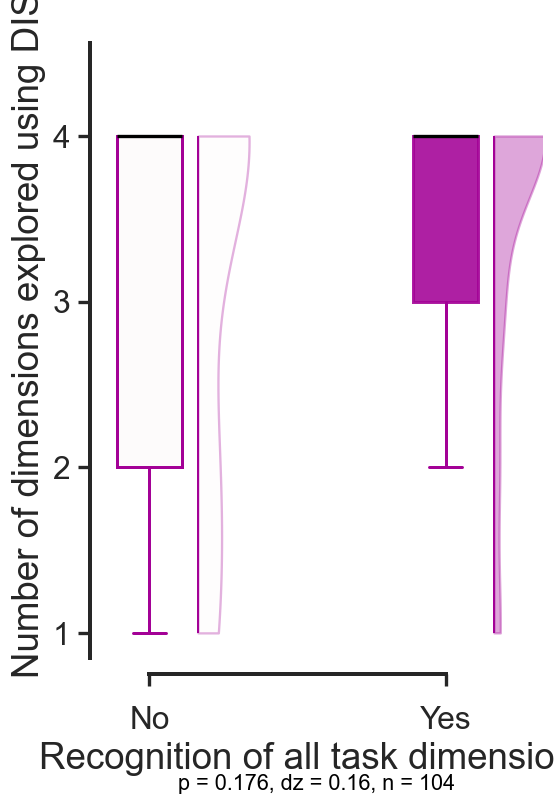

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_recognized_FDS_counts_per_dms_purple_white_narrow.png


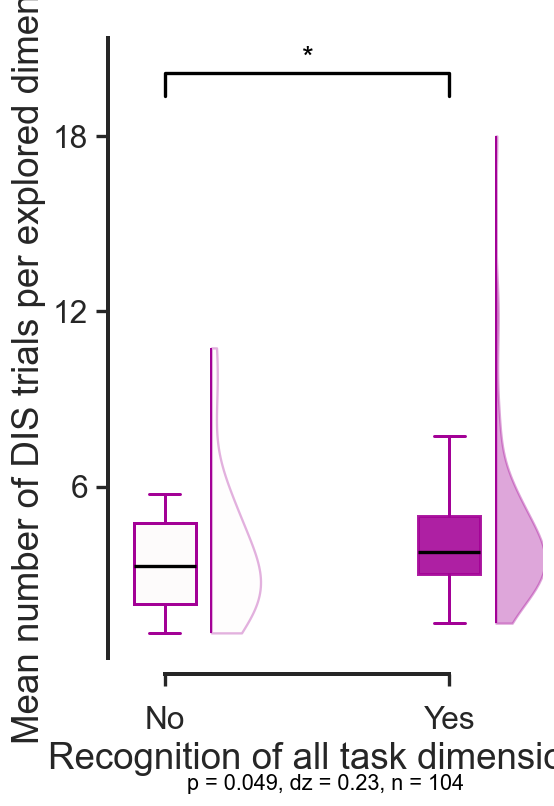

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_recognized_FDS_patterns_per_dms_purple_white_narrow.png


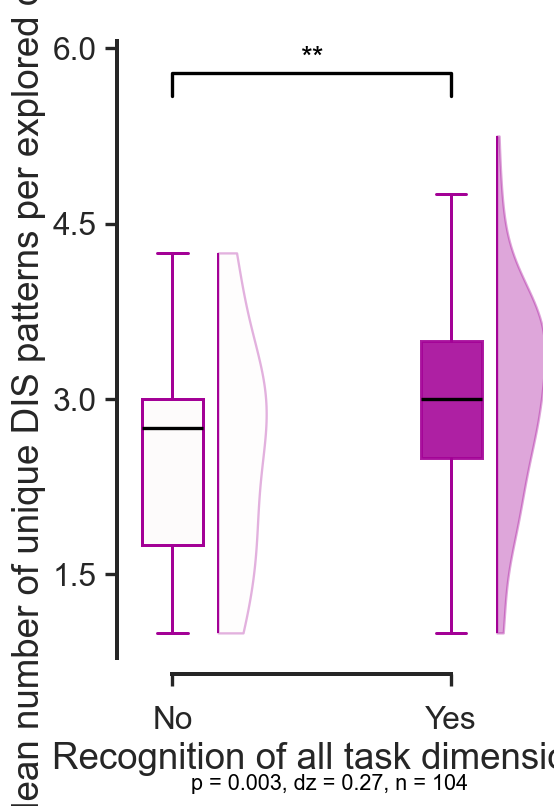

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_features_relevant_answer_FDS_ratio_purple_white_narrow.png


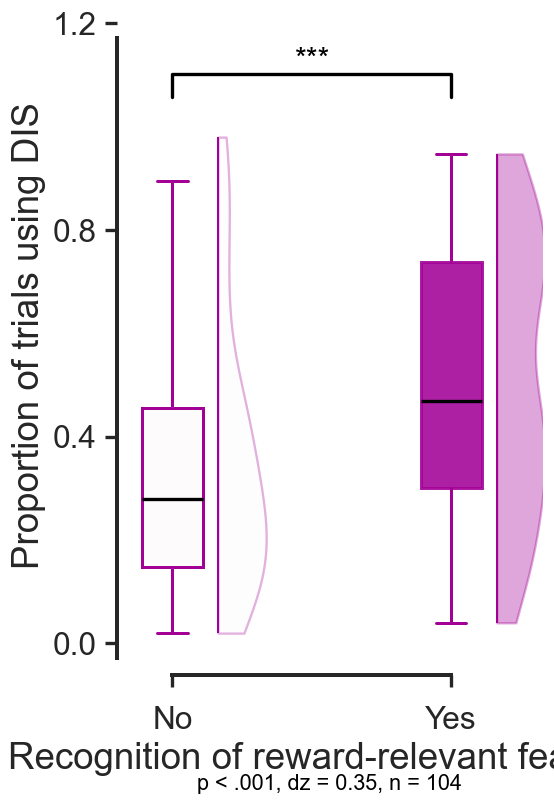

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_features_relevant_answer_FDS_dimensions_purple_white_narrow.png


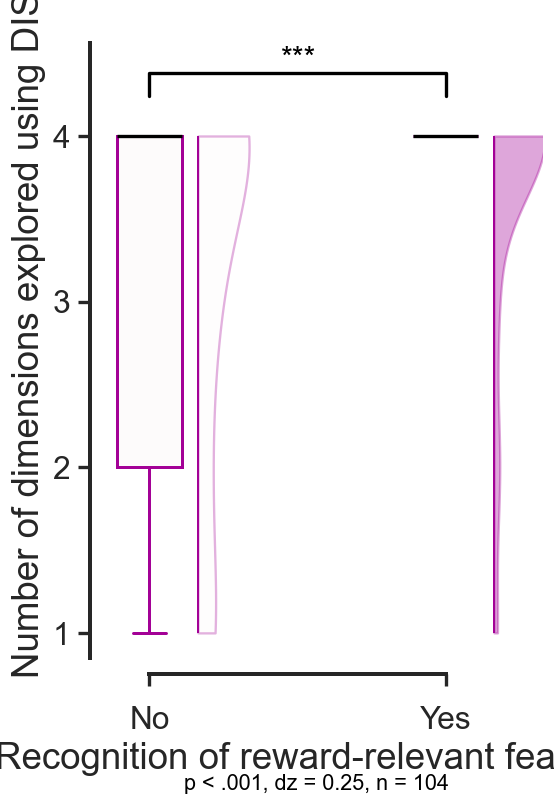

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_features_relevant_answer_FDS_counts_per_dms_purple_white_narrow.png


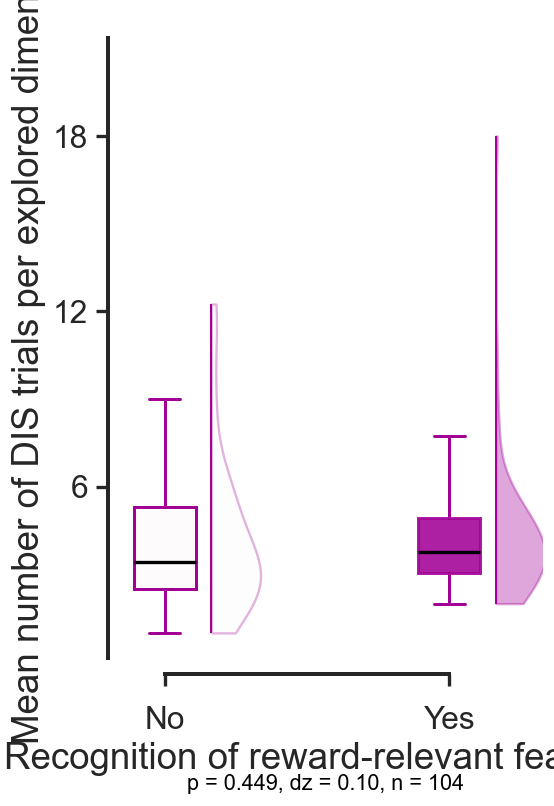

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_features_relevant_answer_FDS_patterns_per_dms_purple_white_narrow.png


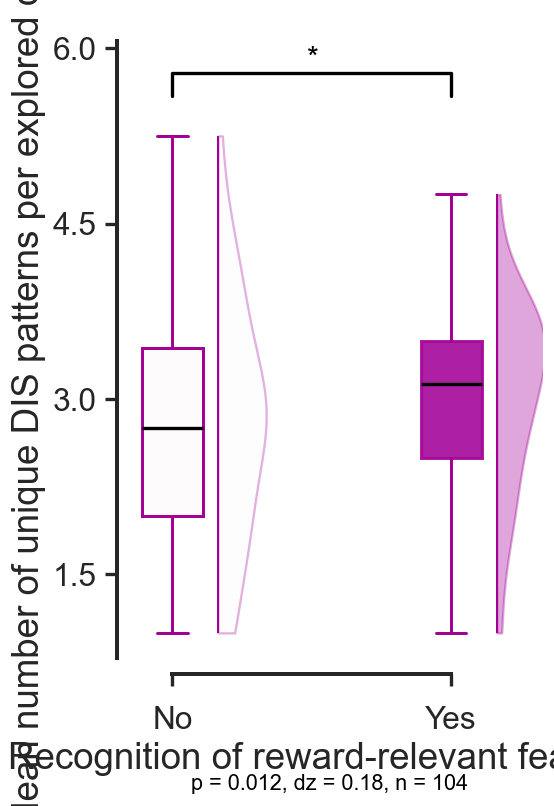

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_strict_FDS_ratio_purple_white_narrow.png


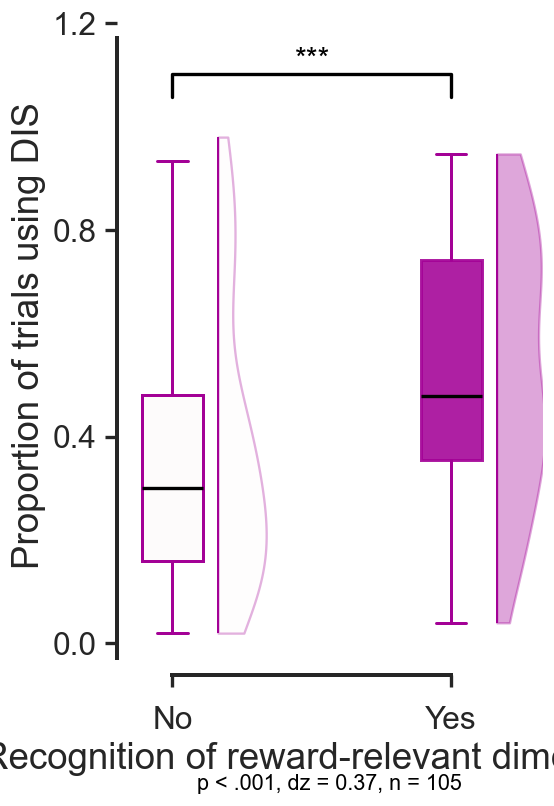

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_strict_FDS_dimensions_purple_white_narrow.png


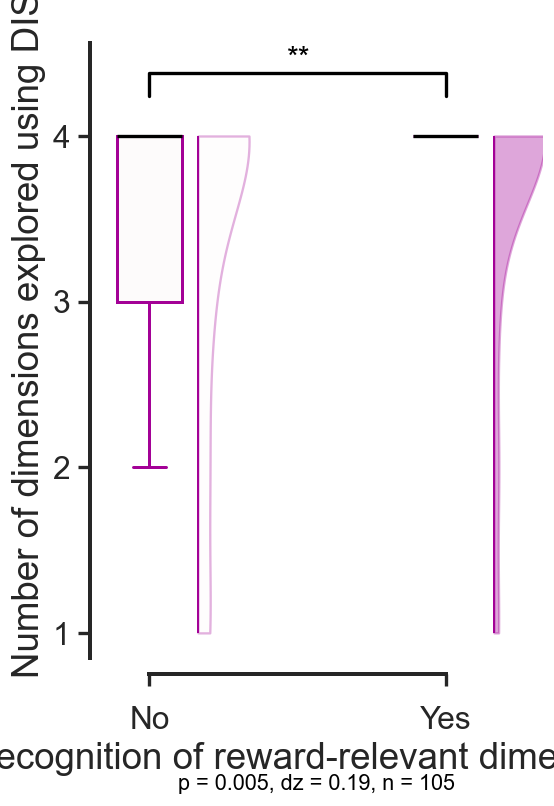

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_strict_FDS_counts_per_dms_purple_white_narrow.png


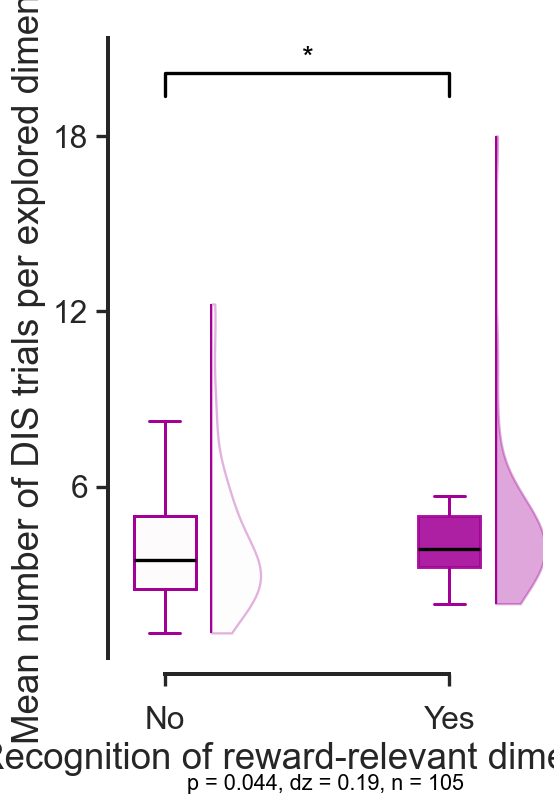

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\4D_dimensions_relevant_answer_strict_FDS_patterns_per_dms_purple_white_narrow.png


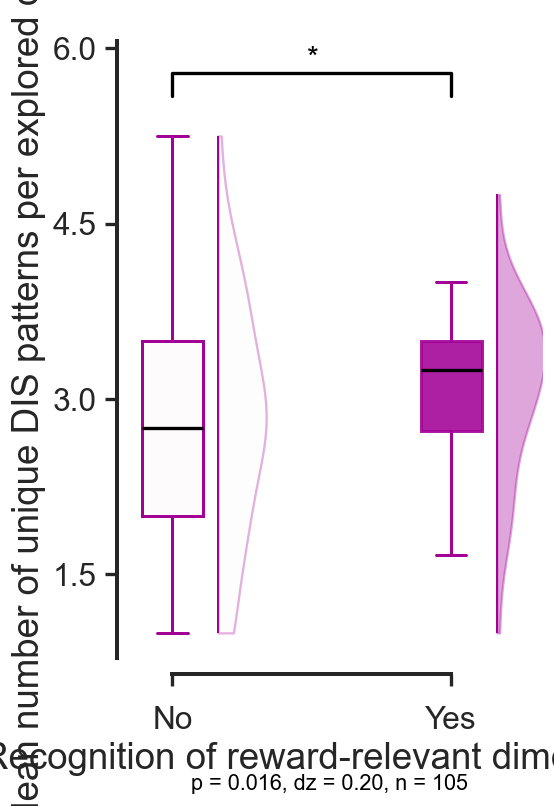

Saved combined figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\reward_relevant_dimensions_fds_combined_purple_white.png


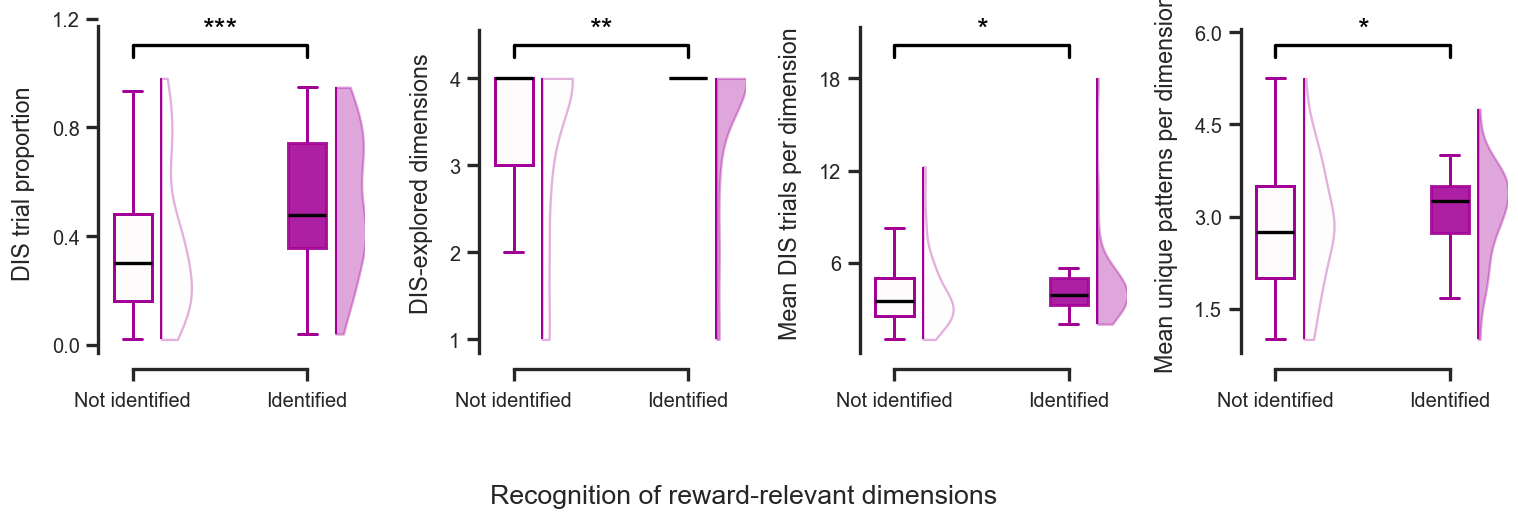

In [10]:
# =========================
# Styled rerun: survey DIS figures (purple/white, narrower, keep half-violin)
# =========================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

PURPLE = "#A30196"
# PURPLE = "#C2830F"
WHITE = "#FDFBFB"

formal_text_label_map = {
    "4D_dimensions_recognized": "Recognition of all task dimensions",
    "4D_features_relevant_answer": "Recognition of reward-relevant features",
    "4D_dimensions_relevant_answer_strict": "Recognition of reward-relevant dimensions",
    "4D_dimensions_relevant_answer_F1": "Recognition of reward-relevant dimensions (F1 score)",
    "4D_dimensions_relevant_answer_hit_minus_false": "Recognition of reward-relevant dimensions (hit rate minus false alarm rate)",
}

formal_fds_metric_label_map = {
    "FDS_ratio": "Proportion of trials using DIS",
    "FDS_dimensions": "Number of dimensions explored using DIS",
    "FDS_counts_per_dms": "Mean number of DIS trials per explored dimension",
    "FDS_patterns_per_dms": "Mean number of unique DIS patterns per explored dimension",
}

formal_binary_level_label_map = {
    "4D_dimensions_recognized": {0: "No", 1: "Yes"},
    "4D_features_relevant_answer": {0: "No", 1: "Yes"},
    "4D_dimensions_relevant_answer_strict": {0: "No", 1: "Yes"},
}


def p_to_stars_local(p):
    if pd.isna(p):
        return None
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return None


def add_sig_bar_local(ax, x1, x2, y, h, text, lw=2.0, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=lw, c='black', clip_on=False)
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom', fontsize=fs, color='black')


def draw_grouped_box_halfviolin_no_scatter(ax, values_by_group, group_labels, group_colors,
                                           ylabel, xlabel, pairwise_stats=None, y_ticks=None, y_lim=None):
    n_group = len(group_labels)

    group_centers = np.arange(n_group) * 1.10 + 1.0
    box_positions = group_centers
    violin_positions = group_centers + 0.18

    box = ax.boxplot(
        values_by_group,
        positions=box_positions,
        widths=0.24,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=2.0),
        whiskerprops=dict(color=PURPLE, linewidth=1.8),
        capprops=dict(color=PURPLE, linewidth=1.8),
        boxprops=dict(edgecolor=PURPLE, linewidth=1.8)
    )

    for i, patch in enumerate(box['boxes']):
        patch.set_facecolor(group_colors[i])
        patch.set_alpha(1.0 if group_colors[i] == WHITE else 0.88)
        if group_colors[i] == WHITE:
            patch.set_edgecolor(PURPLE)

    violins = ax.violinplot(
        values_by_group,
        positions=violin_positions,
        widths=0.38,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    for i, body in enumerate(violins['bodies']):
        color = group_colors[i]
        body.set_facecolor(color)
        body.set_edgecolor(PURPLE)
        body.set_linewidth(1.4)
        body.set_alpha(0.30 if color == WHITE else 0.35)

        path = body.get_paths()[0]
        vertices = path.vertices
        center = violin_positions[i]
        vertices[:, 0] = np.maximum(vertices[:, 0], center)

    for pos, values in zip(violin_positions, values_by_group):
        if len(values) > 0:
            ax.vlines(pos, np.min(values), np.max(values), color=PURPLE, linewidth=1.2, zorder=2)

    left_lim = box_positions[0] - 0.22
    right_lim = violin_positions[-1] + 0.18

    if y_lim is None:
        nonempty = [v for v in values_by_group if len(v) > 0]
        all_values = np.concatenate(nonempty) if len(nonempty) > 0 else np.array([0, 1])
        y_min = np.nanmin(all_values)
        y_max = np.nanmax(all_values)
        if y_min == y_max:
            pad = 1
        else:
            pad = (y_max - y_min) * 0.25
        y_lim = (y_min - pad * 0.20, y_max + pad)

    style_axis_like_example(
        ax=ax,
        xlabel=xlabel,
        ylabel=ylabel,
        xtick_positions=group_centers,
        xtick_labels=group_labels,
        y_ticks=y_ticks,
        y_lim=y_lim,
        x_lim=(left_lim, right_lim),
        left_bound=(y_lim[0], y_lim[1] * 0.96 if y_lim[1] > 0 else y_lim[1]),
        bottom_bound=(group_centers[0], group_centers[-1])
    )

    if pairwise_stats is not None:
        sig_pairs = []
        for pair, stat in pairwise_stats.items():
            a, b = pair
            if a < n_group and b < n_group:
                p = stat["p"] if isinstance(stat, dict) else stat
                star = p_to_stars_local(p)
                if star is not None:
                    sig_pairs.append((pair, star))

        if len(sig_pairs) > 0:
            y0, y1 = ax.get_ylim()
            h = (y1 - y0) * 0.035
            base_y = y1 - (y1 - y0) * 0.13
            level_step = (y1 - y0) * 0.08

            for idx, (pair, star) in enumerate(sig_pairs):
                a, b = pair
                x1, x2 = box_positions[a], box_positions[b]
                y = base_y + idx * level_step
                add_sig_bar_local(ax, x1, x2, y, h, star, lw=2.0, fs=18)


def plot_binary_metric_with_fds_styled(data, text_metric_col, fds_metric_col, save_dir):
    plot_df = data.copy()
    plot_df = plot_df[plot_df[text_metric_col].isin([0, 1])].copy()
    plot_df = plot_df[pd.notna(plot_df[fds_metric_col])].copy()

    if len(plot_df) == 0:
        print(f"[skip] {text_metric_col} x {fds_metric_col}: no valid data")
        return

    metric_levels = formal_binary_level_label_map.get(text_metric_col, {0: 'No', 1: 'Yes'})
    group_labels = [metric_levels[0], metric_levels[1]]
    group_colors = [WHITE, PURPLE]

    g0 = plot_df.loc[plot_df[text_metric_col] == 0, fds_metric_col].dropna().values
    g1 = plot_df.loc[plot_df[text_metric_col] == 1, fds_metric_col].dropna().values
    values_by_group = [g0, g1]

    p_val = mannwhitney_between_groups_trimmed(plot_df, text_metric_col, fds_metric_col, 0, 1)
    r_rb, u_stat, n0, n1 = mannwhitney_effect_size_rbc(g0, g1)

    fig, ax = plt.subplots(1, 1, figsize=(4.9, 7.0))

    draw_grouped_box_halfviolin_no_scatter(
        ax=ax,
        values_by_group=values_by_group,
        group_labels=group_labels,
        group_colors=group_colors,
        ylabel=formal_fds_metric_label_map.get(fds_metric_col, fds_metric_col),
        xlabel=formal_text_label_map.get(text_metric_col, text_metric_col),
        pairwise_stats={(0, 1): p_val}
    )

    if pd.notna(p_val) and p_val < 0.001:
        p_text = 'p < .001'
    elif pd.notna(p_val):
        p_text = f'p = {p_val:.3f}'
    else:
        p_text = 'p = NA'

    dz_text = f'{r_rb:.2f}' if pd.notna(r_rb) else 'NA'
    bottom_text = f"{p_text}, dz = {dz_text}, n = {n0 + n1}"
    ax.text(0.5, -0.18, bottom_text, transform=ax.transAxes, ha='center', va='top', fontsize=13, color='black')

    plt.tight_layout()
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    out = save_dir / f"{text_metric_col}_{fds_metric_col}_purple_white_narrow.png"
    fig.savefig(out, dpi=300, bbox_inches='tight')
    print(f"Saved figure to: {out.resolve()}")
    plt.show()

save_dir = 'figures_saving_for_layout'
for text_metric in binary_metrics_to_plot:
    if text_metric not in analysis_fds_df.columns:
        continue
    for fds_metric in fds_metrics_to_plot:
        if fds_metric not in analysis_fds_df.columns:
            continue
        plot_binary_metric_with_fds_styled(
            analysis_fds_df,
            text_metric_col=text_metric,
            fds_metric_col=fds_metric,
            save_dir=save_dir,
        )


# Combined four-panel figure for reward-relevant dimensions
combined_y_label_map = {
    "FDS_ratio": "DIS trial proportion",
    "FDS_dimensions": "DIS-explored dimensions",
    "FDS_counts_per_dms": "Mean DIS trials per dimension",
    "FDS_patterns_per_dms": "Mean unique patterns per dimension",
}

combined_group_labels = ["Not identified", "Identified"]
combined_text_metric = "4D_dimensions_relevant_answer_strict"
combined_fds_metrics = [
    "FDS_ratio",
    "FDS_dimensions",
    "FDS_counts_per_dms",
    "FDS_patterns_per_dms",
]


def draw_combined_reward_dimension_figure(data, save_dir):
    fig, axes = plt.subplots(1, 4, figsize=(13.2, 4.6))

    for ax, fds_metric_col in zip(axes, combined_fds_metrics):
        plot_df = data.copy()
        plot_df = plot_df[plot_df[combined_text_metric].isin([0, 1])].copy()
        plot_df = plot_df[pd.notna(plot_df[fds_metric_col])].copy()

        g0 = plot_df.loc[plot_df[combined_text_metric] == 0, fds_metric_col].dropna().values
        g1 = plot_df.loc[plot_df[combined_text_metric] == 1, fds_metric_col].dropna().values

        draw_grouped_box_halfviolin_no_scatter(
            ax=ax,
            values_by_group=[g0, g1],
            group_labels=combined_group_labels,
            group_colors=[WHITE, PURPLE],
            ylabel=combined_y_label_map[fds_metric_col],
            xlabel='',
            pairwise_stats={(0, 1): mannwhitney_between_groups_trimmed(plot_df, combined_text_metric, fds_metric_col, 0, 1)}
        )

        ax.set_xlabel('')
        ax.set_ylabel(combined_y_label_map[fds_metric_col], fontsize=14, labelpad=10)
        ax.tick_params(axis='x', labelsize=12, pad=6)
        ax.tick_params(axis='y', labelsize=12, pad=4)
        ax.spines['left'].set_linewidth(2.0)
        ax.spines['bottom'].set_linewidth(2.0)

    fig.supxlabel('Recognition of reward-relevant dimensions', fontsize=16, y=0.05)
    plt.tight_layout(rect=(0.02, 0.08, 1, 1))

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    out = save_dir / 'reward_relevant_dimensions_fds_combined_purple_white.png'
    fig.savefig(out, dpi=300, bbox_inches='tight')
    print(f'Saved combined figure to: {out.resolve()}')
    plt.show()


draw_combined_reward_dimension_figure(analysis_fds_df, save_dir)


In [ ]:
# Updated relationship view for 4D_dimensions_relevant_answer_strict x FDS_ratio
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import gaussian_kde, mannwhitneyu

PURPLE = "#A30196"
PURPLE_FILL = "#C96AC0"
DARK = "#2B2B2B"
LIGHT = "#CFCFCF"
WHITE = "#FFFFFF"

TARGET_TEXT_METRIC = "4D_dimensions_relevant_answer_strict"
TARGET_FDS_METRIC = "FDS_ratio"

FIGSIZE = (12.2, 4.6)
DPI = 300
LABEL_SIZE = 13
TICK_SIZE = 12
LEGEND_SIZE = 11
PANEL_LABEL_SIZE = 13
LINE_WIDTH = 2.6
MARKER_SIZE = 6.8
BIN_EDGES = np.linspace(0, 1, 6)


def mannwhitney_effect_size_rbc(x, y):
    x = pd.Series(x).dropna().to_numpy()
    y = pd.Series(y).dropna().to_numpy()
    n1, n2 = len(x), len(y)
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan, n1, n2
    u_stat, p_val = mannwhitneyu(x, y, alternative="two-sided")
    r_rb = 1 - (2 * u_stat) / (n1 * n2)
    return r_rb, p_val, n1, n2


def reflective_kde_unit(values, grid, bw_method=None):
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    if len(values) < 2 or np.allclose(values, values[0]):
        density = np.zeros_like(grid)
        if len(values) == 1:
            density[np.argmin(np.abs(grid - values[0]))] = 1.0
        return density

    kde = gaussian_kde(values, bw_method=bw_method)
    density = kde(grid) + kde(-grid) + kde(2 - grid)
    area = np.trapz(density, grid)
    if area > 0:
        density = density / area
    return density


def wilson_interval(successes, total, z=1.959963984540054):
    if total == 0:
        return np.nan, np.nan, np.nan
    p = successes / total
    denom = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denom
    half = z * np.sqrt((p * (1 - p) + z**2 / (4 * total)) / total) / denom
    return p, max(0.0, center - half), min(1.0, center + half)


def style_axis(ax):
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.8)
    ax.spines["bottom"].set_linewidth(1.8)
    ax.tick_params(axis="both", labelsize=TICK_SIZE, width=1.6, length=6)


def build_dis_ratio_relationship_df(data, text_metric_col, fds_metric_col):
    plot_df = data[[fds_metric_col, text_metric_col]].copy()
    plot_df = plot_df[plot_df[text_metric_col].isin([0, 1])].copy()
    plot_df = plot_df[pd.notna(plot_df[fds_metric_col])].copy()
    plot_df[text_metric_col] = plot_df[text_metric_col].astype(int)
    return plot_df


def draw_density_panel(ax, plot_df, text_metric_col, fds_metric_col, panel_label=None):
    incorrect = plot_df.loc[plot_df[text_metric_col] == 0, fds_metric_col].to_numpy()
    correct = plot_df.loc[plot_df[text_metric_col] == 1, fds_metric_col].to_numpy()

    grid = np.linspace(0, 1, 512)
    density_incorrect = reflective_kde_unit(incorrect, grid)
    density_correct = reflective_kde_unit(correct, grid)

    ax.plot(grid, density_incorrect, color=DARK, linewidth=LINE_WIDTH, label="Incorrect")
    ax.fill_between(grid, density_incorrect, 0, color=LIGHT, alpha=0.20)
    ax.plot(grid, density_correct, color=PURPLE, linewidth=LINE_WIDTH, label="Correct")
    ax.fill_between(grid, density_correct, 0, color=PURPLE_FILL, alpha=0.28)

    for values, color, linestyle in [(incorrect, DARK, "--"), (correct, PURPLE, "-")]:
        median_value = np.median(values)
        ax.axvline(median_value, ymin=0.02, ymax=0.92, color=color, linewidth=1.4, linestyle=linestyle, alpha=0.9)

    r_rb, p_val, n0, n1 = mannwhitney_effect_size_rbc(incorrect, correct)
    if pd.notna(p_val) and p_val < 0.001:
        p_text = "p < .001"
    elif pd.notna(p_val):
        p_text = f"p = {p_val:.3f}"
    else:
        p_text = "p = NA"

    if pd.notna(r_rb):
        footer = f"{p_text}, rank-biserial r = {r_rb:.2f}, n = {n0 + n1}"
    else:
        footer = f"{p_text}, n = {n0 + n1}"

    ax.set_xlim(0, 1)
    ax.set_xlabel("DIS trial proportion", fontsize=LABEL_SIZE)
    ax.set_ylabel("Density", fontsize=LABEL_SIZE)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.legend(frameon=False, fontsize=LEGEND_SIZE, loc="upper right")
    if panel_label is not None:
        ax.text(0.02, 0.98, panel_label, transform=ax.transAxes, ha="left", va="top", fontsize=PANEL_LABEL_SIZE, fontweight="bold")
    ax.text(0.5, -0.22, footer, transform=ax.transAxes, ha="center", va="top", fontsize=11, color=DARK)


def summarize_binned_accuracy(plot_df, text_metric_col, fds_metric_col, bin_edges):
    tmp = plot_df.copy()
    tmp["ratio_bin"] = pd.cut(tmp[fds_metric_col], bins=bin_edges, include_lowest=True, right=True)
    rows = []
    for interval, group in tmp.groupby("ratio_bin", observed=False):
        if pd.isna(interval) or len(group) == 0:
            continue
        total = len(group)
        correct_n = int(group[text_metric_col].sum())
        incorrect_n = total - correct_n
        correct_p, correct_lo, correct_hi = wilson_interval(correct_n, total)
        incorrect_p, incorrect_lo, incorrect_hi = wilson_interval(incorrect_n, total)
        rows.append({
            "bin": interval,
            "x": float(interval.mid),
            "n": total,
            "correct_p": correct_p,
            "correct_lo": correct_lo,
            "correct_hi": correct_hi,
            "incorrect_p": incorrect_p,
            "incorrect_lo": incorrect_lo,
            "incorrect_hi": incorrect_hi,
        })
    return pd.DataFrame(rows).sort_values("x").reset_index(drop=True)


def draw_binned_panel(ax, summary_df, panel_label=None):
    ax.plot(
        summary_df["x"],
        summary_df["incorrect_p"],
        color=DARK,
        linewidth=2.0,
        linestyle="--",
        marker="o",
        markersize=MARKER_SIZE,
        markerfacecolor=WHITE,
        markeredgecolor=DARK,
        label="Incorrect",
    )
    ax.fill_between(
        summary_df["x"],
        summary_df["incorrect_lo"],
        summary_df["incorrect_hi"],
        color=LIGHT,
        alpha=0.18,
    )

    ax.plot(
        summary_df["x"],
        summary_df["correct_p"],
        color=PURPLE,
        linewidth=2.4,
        marker="o",
        markersize=MARKER_SIZE,
        markerfacecolor=PURPLE,
        markeredgecolor=PURPLE,
        label="Correct",
    )
    ax.fill_between(
        summary_df["x"],
        summary_df["correct_lo"],
        summary_df["correct_hi"],
        color=PURPLE_FILL,
        alpha=0.22,
    )

    tick_labels = [f"{max(0.0, row.bin.left):.1f}-{min(1.0, row.bin.right):.1f}" for row in summary_df.itertuples()]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Binned DIS trial proportion", fontsize=LABEL_SIZE)
    ax.set_ylabel("Proportion of participants", fontsize=LABEL_SIZE)
    ax.set_xticks(summary_df["x"])
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.legend(frameon=False, fontsize=LEGEND_SIZE, loc="upper right")
    if panel_label is not None:
        ax.text(0.02, 0.98, panel_label, transform=ax.transAxes, ha="left", va="top", fontsize=PANEL_LABEL_SIZE, fontweight="bold")


def draw_dis_ratio_relationship_figure(data, save_dir):
    plot_df = build_dis_ratio_relationship_df(data, TARGET_TEXT_METRIC, TARGET_FDS_METRIC)
    if len(plot_df) == 0:
        print(f"[skip] {TARGET_TEXT_METRIC} x {TARGET_FDS_METRIC}: no valid data")
        return

    summary_df = summarize_binned_accuracy(plot_df, TARGET_TEXT_METRIC, TARGET_FDS_METRIC, BIN_EDGES)

    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, dpi=DPI)
    draw_density_panel(axes[0], plot_df, TARGET_TEXT_METRIC, TARGET_FDS_METRIC, panel_label="A")
    draw_binned_panel(axes[1], summary_df, panel_label="B")

    for ax in axes:
        style_axis(ax)

    fig.tight_layout(w_pad=2.2, rect=(0, 0.05, 1, 1))

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    out = save_dir / f"{TARGET_TEXT_METRIC}_{TARGET_FDS_METRIC}_density_and_binned_purple_white_narrow.png"
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"Saved figure to: {out.resolve()}")
    print("Binned summary:")
    print(summary_df[["bin", "n", "correct_p", "incorrect_p"]].to_string(index=False))
    plt.show()


save_dir = globals().get("DIS_RELATIONSHIP_SAVE_DIR", "figures_saving_for_layout")
draw_dis_ratio_relationship_figure(analysis_fds_df, save_dir)


In [ ]:
# Density-only view with reference-style line types
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from scipy.stats import gaussian_kde, mannwhitneyu

PURPLE = "#A30196"
DARK = "#2B2B2B"
WHITE = "#FFFFFF"

TARGET_TEXT_METRIC = "4D_dimensions_relevant_answer_strict"
TARGET_FDS_METRIC = "FDS_ratio"

FIGSIZE = (6.2, 4.6)
DPI = 300
LABEL_SIZE = 13
TICK_SIZE = 12
LEGEND_SIZE = 10
LINE_WIDTH = 2.4
MEAN_MARKER_SIZE = 42
BW_ADJUST = 1.3


def mannwhitney_effect_size_rbc(x, y):
    x = pd.Series(x).dropna().to_numpy()
    y = pd.Series(y).dropna().to_numpy()
    n1, n2 = len(x), len(y)
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan, n1, n2
    u_stat, p_val = mannwhitneyu(x, y, alternative="two-sided")
    r_rb = 1 - (2 * u_stat) / (n1 * n2)
    return r_rb, p_val, n1, n2


def reflective_kde_unit(values, grid, bw_adjust=1.0):
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    if len(values) < 2 or np.allclose(values, values[0]):
        density = np.zeros_like(grid)
        if len(values) == 1:
            density[np.argmin(np.abs(grid - values[0]))] = 1.0
        return density

    base = gaussian_kde(values)
    bandwidth_factor = base.factor * bw_adjust
    kde = gaussian_kde(values, bw_method=bandwidth_factor)
    density = kde(grid) + kde(-grid) + kde(2 - grid)
    area = np.trapz(density, grid)
    if area > 0:
        density = density / area
    return density


def style_axis(ax):
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.8)
    ax.spines["bottom"].set_linewidth(1.8)
    ax.tick_params(axis="both", labelsize=TICK_SIZE, width=1.6, length=6)


def build_dis_ratio_relationship_df(data, text_metric_col, fds_metric_col):
    plot_df = data[[fds_metric_col, text_metric_col]].copy()
    plot_df = plot_df[plot_df[text_metric_col].isin([0, 1])].copy()
    plot_df = plot_df[pd.notna(plot_df[fds_metric_col])].copy()
    plot_df[text_metric_col] = plot_df[text_metric_col].astype(int)
    return plot_df


def draw_density_only_reference_style(data, save_dir):
    plot_df = build_dis_ratio_relationship_df(data, TARGET_TEXT_METRIC, TARGET_FDS_METRIC)
    if len(plot_df) == 0:
        print(f"[skip] {TARGET_TEXT_METRIC} x {TARGET_FDS_METRIC}: no valid data")
        return

    incorrect = plot_df.loc[plot_df[TARGET_TEXT_METRIC] == 0, TARGET_FDS_METRIC].to_numpy()
    correct = plot_df.loc[plot_df[TARGET_TEXT_METRIC] == 1, TARGET_FDS_METRIC].to_numpy()

    x_grid = np.linspace(0, 1, 512)
    density_incorrect = reflective_kde_unit(incorrect, x_grid, bw_adjust=BW_ADJUST)
    density_correct = reflective_kde_unit(correct, x_grid, bw_adjust=BW_ADJUST)

    mean_incorrect = float(np.mean(incorrect))
    mean_correct = float(np.mean(correct))
    y_mean_incorrect = float(np.interp(mean_incorrect, x_grid, density_incorrect))
    y_mean_correct = float(np.interp(mean_correct, x_grid, density_correct))

    r_rb, p_val, n0, n1 = mannwhitney_effect_size_rbc(incorrect, correct)

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, dpi=DPI)
    ax.plot(x_grid, density_incorrect, color=DARK, linewidth=LINE_WIDTH, linestyle="--")
    ax.plot(x_grid, density_correct, color=PURPLE, linewidth=LINE_WIDTH, linestyle="-")
    ax.scatter(
        [mean_incorrect, mean_correct],
        [y_mean_incorrect, y_mean_correct],
        marker="D",
        s=MEAN_MARKER_SIZE,
        facecolor=WHITE,
        edgecolor=DARK,
        linewidth=1.0,
        zorder=4,
    )

    y_max = max(float(np.max(density_incorrect)), float(np.max(density_correct)))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, y_max * 1.08)
    ax.set_xlabel("DIS trial proportion", fontsize=LABEL_SIZE)
    ax.set_ylabel("Density", fontsize=LABEL_SIZE)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    legend_handles = [
        Line2D([0], [0], color=DARK, lw=LINE_WIDTH, linestyle="--", label="Incorrect"),
        Line2D([0], [0], color=PURPLE, lw=LINE_WIDTH, linestyle="-", label="Correct"),
        Line2D([0], [0], marker="D", linestyle="None", markerfacecolor=WHITE, markeredgecolor=DARK, markeredgewidth=1.0, markersize=5, label="Mean"),
    ]
    ax.legend(handles=legend_handles, frameon=False, fontsize=LEGEND_SIZE, loc="upper right")

    if pd.notna(p_val) and p_val < 0.001:
        p_text = "p < .001"
    elif pd.notna(p_val):
        p_text = f"p = {p_val:.3f}"
    else:
        p_text = "p = NA"

    footer = f"{p_text}, rank-biserial r = {r_rb:.2f}, n = {n0 + n1}"
    ax.text(0.5, -0.22, footer, transform=ax.transAxes, ha="center", va="top", fontsize=11, color=DARK)

    style_axis(ax)
    fig.tight_layout(rect=(0, 0.05, 1, 1))

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    out = save_dir / f"{TARGET_TEXT_METRIC}_{TARGET_FDS_METRIC}_density_only_refstyle_purple_white_narrow.png"
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"Saved figure to: {out.resolve()}")
    print({"mean_incorrect": mean_incorrect, "mean_correct": mean_correct, "bw_adjust": BW_ADJUST})
    plt.show()


save_dir = globals().get("DIS_RELATIONSHIP_SAVE_DIR", "figures_saving_for_layout")
draw_density_only_reference_style(analysis_fds_df, save_dir)


In [ ]:
# Binned line view with 0.25-width DIS bins
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

PURPLE = "#A30196"
PURPLE_FILL = "#C96AC0"
DARK = "#2B2B2B"
LIGHT = "#CFCFCF"
WHITE = "#FFFFFF"

TARGET_TEXT_METRIC = "4D_dimensions_relevant_answer_strict"
TARGET_FDS_METRIC = "FDS_ratio"

FIGSIZE = (6.4, 4.8)
DPI = 300
LABEL_SIZE = 13
TICK_SIZE = 12
LEGEND_SIZE = 11
LINE_WIDTH = 2.4
MARKER_SIZE = 6.8
BIN_EDGES = np.arange(0, 1.0001, 0.25)


def wilson_interval(successes, total, z=1.959963984540054):
    if total == 0:
        return np.nan, np.nan, np.nan
    p = successes / total
    denom = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denom
    half = z * np.sqrt((p * (1 - p) + z**2 / (4 * total)) / total) / denom
    return p, max(0.0, center - half), min(1.0, center + half)


def style_axis(ax):
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.8)
    ax.spines["bottom"].set_linewidth(1.8)
    ax.tick_params(axis="both", labelsize=TICK_SIZE, width=1.6, length=6)


def build_dis_ratio_relationship_df(data, text_metric_col, fds_metric_col):
    plot_df = data[[fds_metric_col, text_metric_col]].copy()
    plot_df = plot_df[plot_df[text_metric_col].isin([0, 1])].copy()
    plot_df = plot_df[pd.notna(plot_df[fds_metric_col])].copy()
    plot_df[text_metric_col] = plot_df[text_metric_col].astype(int)
    return plot_df


def summarize_binned_accuracy(plot_df, text_metric_col, fds_metric_col, bin_edges):
    tmp = plot_df.copy()
    tmp["ratio_bin"] = pd.cut(tmp[fds_metric_col], bins=bin_edges, include_lowest=True, right=True)
    rows = []
    for interval, group in tmp.groupby("ratio_bin", observed=False):
        if pd.isna(interval) or len(group) == 0:
            continue
        total = len(group)
        correct_n = int(group[text_metric_col].sum())
        incorrect_n = total - correct_n
        correct_p, correct_lo, correct_hi = wilson_interval(correct_n, total)
        incorrect_p, incorrect_lo, incorrect_hi = wilson_interval(incorrect_n, total)
        rows.append({
            "bin": interval,
            "x": float(interval.mid),
            "n": total,
            "correct_p": correct_p,
            "correct_lo": correct_lo,
            "correct_hi": correct_hi,
            "incorrect_p": incorrect_p,
            "incorrect_lo": incorrect_lo,
            "incorrect_hi": incorrect_hi,
        })
    return pd.DataFrame(rows).sort_values("x").reset_index(drop=True)


def draw_binned_line_figure_025(data, save_dir):
    plot_df = build_dis_ratio_relationship_df(data, TARGET_TEXT_METRIC, TARGET_FDS_METRIC)
    if len(plot_df) == 0:
        print(f"[skip] {TARGET_TEXT_METRIC} x {TARGET_FDS_METRIC}: no valid data")
        return

    summary_df = summarize_binned_accuracy(plot_df, TARGET_TEXT_METRIC, TARGET_FDS_METRIC, BIN_EDGES)

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, dpi=DPI)

    ax.plot(
        summary_df["x"],
        summary_df["incorrect_p"],
        color=DARK,
        linewidth=2.0,
        linestyle="--",
        marker="o",
        markersize=MARKER_SIZE,
        markerfacecolor=WHITE,
        markeredgecolor=DARK,
        label="Incorrect",
    )
    ax.fill_between(
        summary_df["x"],
        summary_df["incorrect_lo"],
        summary_df["incorrect_hi"],
        color=LIGHT,
        alpha=0.18,
    )

    ax.plot(
        summary_df["x"],
        summary_df["correct_p"],
        color=PURPLE,
        linewidth=LINE_WIDTH,
        marker="o",
        markersize=MARKER_SIZE,
        markerfacecolor=PURPLE,
        markeredgecolor=PURPLE,
        label="Correct",
    )
    ax.fill_between(
        summary_df["x"],
        summary_df["correct_lo"],
        summary_df["correct_hi"],
        color=PURPLE_FILL,
        alpha=0.22,
    )

    tick_labels = [f"{max(0.0, row.bin.left):.2f}-{min(1.0, row.bin.right):.2f}" for row in summary_df.itertuples()]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Binned DIS trial proportion", fontsize=LABEL_SIZE)
    ax.set_ylabel("Proportion of participants", fontsize=LABEL_SIZE)
    ax.set_xticks(summary_df["x"])
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.legend(frameon=False, fontsize=LEGEND_SIZE, loc="upper right")
    ax.text(0.5, -0.22, "Bin width = 0.25; ribbons show Wilson 95% CI", transform=ax.transAxes, ha="center", va="top", fontsize=11, color=DARK)

    style_axis(ax)
    fig.tight_layout(rect=(0, 0.05, 1, 1))

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    out = save_dir / f"{TARGET_TEXT_METRIC}_{TARGET_FDS_METRIC}_binned_line_bin025_purple_white_narrow.png"
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"Saved figure to: {out.resolve()}")
    print("Binned summary:")
    print(summary_df[["bin", "n", "correct_p", "incorrect_p"]].to_string(index=False))
    plt.show()


save_dir = globals().get("DIS_RELATIONSHIP_SAVE_DIR", "figures_saving_for_layout")
draw_binned_line_figure_025(analysis_fds_df, save_dir)


In [ ]:
# Binned line view with 3 equal-width DIS bins
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

PURPLE = "#A30196"
PURPLE_FILL = "#C96AC0"
DARK = "#2B2B2B"
LIGHT = "#CFCFCF"
WHITE = "#FFFFFF"

TARGET_TEXT_METRIC = "4D_dimensions_relevant_answer_strict"
TARGET_FDS_METRIC = "FDS_ratio"

FIGSIZE = (6.4, 4.8)
DPI = 300
LABEL_SIZE = 13
TICK_SIZE = 12
LEGEND_SIZE = 11
LINE_WIDTH = 2.4
MARKER_SIZE = 6.8
BIN_EDGES = np.linspace(0, 1, 4)


def wilson_interval(successes, total, z=1.959963984540054):
    if total == 0:
        return np.nan, np.nan, np.nan
    p = successes / total
    denom = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denom
    half = z * np.sqrt((p * (1 - p) + z**2 / (4 * total)) / total) / denom
    return p, max(0.0, center - half), min(1.0, center + half)


def style_axis(ax):
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.8)
    ax.spines["bottom"].set_linewidth(1.8)
    ax.tick_params(axis="both", labelsize=TICK_SIZE, width=1.6, length=6)


def build_dis_ratio_relationship_df(data, text_metric_col, fds_metric_col):
    plot_df = data[[fds_metric_col, text_metric_col]].copy()
    plot_df = plot_df[plot_df[text_metric_col].isin([0, 1])].copy()
    plot_df = plot_df[pd.notna(plot_df[fds_metric_col])].copy()
    plot_df[text_metric_col] = plot_df[text_metric_col].astype(int)
    return plot_df


def summarize_binned_accuracy(plot_df, text_metric_col, fds_metric_col, bin_edges):
    tmp = plot_df.copy()
    tmp["ratio_bin"] = pd.cut(tmp[fds_metric_col], bins=bin_edges, include_lowest=True, right=True)
    rows = []
    for interval, group in tmp.groupby("ratio_bin", observed=False):
        if pd.isna(interval) or len(group) == 0:
            continue
        total = len(group)
        correct_n = int(group[text_metric_col].sum())
        incorrect_n = total - correct_n
        correct_p, correct_lo, correct_hi = wilson_interval(correct_n, total)
        incorrect_p, incorrect_lo, incorrect_hi = wilson_interval(incorrect_n, total)
        rows.append({
            "bin": interval,
            "x": float(interval.mid),
            "n": total,
            "correct_p": correct_p,
            "correct_lo": correct_lo,
            "correct_hi": correct_hi,
            "incorrect_p": incorrect_p,
            "incorrect_lo": incorrect_lo,
            "incorrect_hi": incorrect_hi,
        })
    return pd.DataFrame(rows).sort_values("x").reset_index(drop=True)


def draw_binned_line_figure_3bin(data, save_dir):
    plot_df = build_dis_ratio_relationship_df(data, TARGET_TEXT_METRIC, TARGET_FDS_METRIC)
    if len(plot_df) == 0:
        print(f"[skip] {TARGET_TEXT_METRIC} x {TARGET_FDS_METRIC}: no valid data")
        return

    summary_df = summarize_binned_accuracy(plot_df, TARGET_TEXT_METRIC, TARGET_FDS_METRIC, BIN_EDGES)

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, dpi=DPI)

    ax.plot(
        summary_df["x"],
        summary_df["incorrect_p"],
        color=DARK,
        linewidth=2.0,
        linestyle="--",
        marker="o",
        markersize=MARKER_SIZE,
        markerfacecolor=WHITE,
        markeredgecolor=DARK,
        label="Incorrect",
    )
    ax.fill_between(
        summary_df["x"],
        summary_df["incorrect_lo"],
        summary_df["incorrect_hi"],
        color=LIGHT,
        alpha=0.18,
    )

    ax.plot(
        summary_df["x"],
        summary_df["correct_p"],
        color=PURPLE,
        linewidth=LINE_WIDTH,
        marker="o",
        markersize=MARKER_SIZE,
        markerfacecolor=PURPLE,
        markeredgecolor=PURPLE,
        label="Correct",
    )
    ax.fill_between(
        summary_df["x"],
        summary_df["correct_lo"],
        summary_df["correct_hi"],
        color=PURPLE_FILL,
        alpha=0.22,
    )

    tick_labels = [f"{max(0.0, row.bin.left):.2f}-{min(1.0, row.bin.right):.2f}" for row in summary_df.itertuples()]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Binned DIS trial proportion", fontsize=LABEL_SIZE)
    ax.set_ylabel("Proportion of participants", fontsize=LABEL_SIZE)
    ax.set_xticks(summary_df["x"])
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.legend(frameon=False, fontsize=LEGEND_SIZE, loc="upper right")
    ax.text(0.5, -0.22, "3 equal-width DIS bins; ribbons show Wilson 95% CI", transform=ax.transAxes, ha="center", va="top", fontsize=11, color=DARK)

    style_axis(ax)
    fig.tight_layout(rect=(0, 0.05, 1, 1))

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    out = save_dir / f"{TARGET_TEXT_METRIC}_{TARGET_FDS_METRIC}_binned_line_3bin_purple_white_narrow.png"
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"Saved figure to: {out.resolve()}")
    print("Binned summary:")
    print(summary_df[["bin", "n", "correct_p", "incorrect_p"]].to_string(index=False))
    plt.show()


save_dir = globals().get("DIS_RELATIONSHIP_SAVE_DIR", "figures_saving_for_layout")
draw_binned_line_figure_3bin(analysis_fds_df, save_dir)


In [ ]:
# Five-bin line view with SEM for correct group only
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

PURPLE = "#A30196"
DARK = "#2B2B2B"

TARGET_TEXT_METRIC = "4D_dimensions_relevant_answer_strict"
TARGET_FDS_METRIC = "FDS_ratio"

FIGSIZE = (6.2, 4.6)
DPI = 300
LABEL_SIZE = 13
TICK_SIZE = 12
LINE_WIDTH = 2.4
MARKER_SIZE = 6.8
CAPSIZE = 4
BIN_EDGES = np.linspace(0, 1, 6)
XTICKS = np.arange(0, 1.01, 0.2)
YTICKS = np.array([0.2, 0.4, 0.6, 0.8])
YLIM = (0.10, 0.80)
XLIM = (-0.02, 1.02)


def style_axis(ax):
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.8)
    ax.spines["bottom"].set_linewidth(1.8)
    ax.spines["left"].set_bounds(float(YTICKS[0]), float(YTICKS[-1]))
    ax.spines["bottom"].set_bounds(float(XTICKS[0]), float(XTICKS[-1]))
    ax.tick_params(axis="both", labelsize=TICK_SIZE, width=1.6, length=6)


def build_dis_ratio_relationship_df(data, text_metric_col, fds_metric_col):
    plot_df = data[[fds_metric_col, text_metric_col]].copy()
    plot_df = plot_df[plot_df[text_metric_col].isin([0, 1])].copy()
    plot_df = plot_df[pd.notna(plot_df[fds_metric_col])].copy()
    plot_df[text_metric_col] = plot_df[text_metric_col].astype(int)
    return plot_df


def summarize_binned_correct_sem(plot_df, text_metric_col, fds_metric_col, bin_edges):
    tmp = plot_df.copy()
    tmp["ratio_bin"] = pd.cut(tmp[fds_metric_col], bins=bin_edges, include_lowest=True, right=True)
    rows = []
    for interval, group in tmp.groupby("ratio_bin", observed=False):
        if pd.isna(interval) or len(group) == 0:
            continue
        correct_values = group[text_metric_col].astype(float)
        correct_mean = float(correct_values.mean())
        if len(correct_values) > 1:
            correct_sd = float(np.std(correct_values, ddof=1))
            correct_sem = correct_sd / np.sqrt(len(correct_values))
        else:
            correct_sd = np.nan
            correct_sem = np.nan
        rows.append({
            "bin": interval,
            "x": float(interval.mid),
            "n": int(len(correct_values)),
            "correct_mean": correct_mean,
            "correct_sd": correct_sd,
            "correct_sem": correct_sem,
        })
    return pd.DataFrame(rows).sort_values("x").reset_index(drop=True)


def draw_five_bin_correct_sem_figure(data, save_dir):
    plot_df = build_dis_ratio_relationship_df(data, TARGET_TEXT_METRIC, TARGET_FDS_METRIC)
    if len(plot_df) == 0:
        print(f"[skip] {TARGET_TEXT_METRIC} x {TARGET_FDS_METRIC}: no valid data")
        return

    summary_df = summarize_binned_correct_sem(plot_df, TARGET_TEXT_METRIC, TARGET_FDS_METRIC, BIN_EDGES)

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, dpi=DPI)
    ax.errorbar(
        summary_df["x"],
        summary_df["correct_mean"],
        yerr=summary_df["correct_sem"],
        color=PURPLE,
        linewidth=LINE_WIDTH,
        marker="o",
        markersize=MARKER_SIZE,
        markerfacecolor=PURPLE,
        markeredgecolor=PURPLE,
        capsize=CAPSIZE,
    )

    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)
    ax.set_xlabel("DIS trial proportion", fontsize=LABEL_SIZE)
    ax.set_ylabel("Proportion with correct\nreward-relevant-dimension identification", fontsize=LABEL_SIZE)
    ax.set_xticks(XTICKS)
    ax.set_xticklabels([f"{tick:.1f}" if tick > 0 else "0" for tick in XTICKS], fontsize=10)
    ax.set_yticks(YTICKS)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.text(0.5, -0.22, "Five equal-width DIS bins; error bars show SEM", transform=ax.transAxes, ha="center", va="top", fontsize=11, color=DARK)

    style_axis(ax)
    fig.tight_layout(rect=(0.06, 0.05, 1, 1))

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    out = save_dir / f"{TARGET_TEXT_METRIC}_{TARGET_FDS_METRIC}_binned_line_5bin_correct_sem_purple_white_narrow.png"
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"Saved figure to: {out.resolve()}")
    print("Binned summary:")
    print(summary_df[["bin", "n", "correct_mean", "correct_sem"]].to_string(index=False))
    plt.show()


save_dir = globals().get("DIS_RELATIONSHIP_SAVE_DIR", "figures_saving_for_layout")
draw_five_bin_correct_sem_figure(analysis_fds_df, save_dir)


In [ ]:
# Five-bin box-whisker view for correct-group proportion
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import mannwhitneyu

PURPLE = "#A30196"
DARK = "#2B2B2B"
WHITE = "#FFFFFF"

TARGET_TEXT_METRIC = "4D_dimensions_relevant_answer_strict"
TARGET_FDS_METRIC = "FDS_ratio"

FIGSIZE = (6.2, 4.6)
DPI = 300
LABEL_SIZE = 13
TICK_SIZE = 12
LINE_WIDTH = 1.8
MARKER_SIZE = 5.2
BIN_EDGES = np.linspace(0, 1, 6)
XTICKS = np.arange(0, 1.01, 0.2)
YTICKS = np.array([0.2, 0.4, 0.6, 0.8])
YLIM = (0.08, 0.82)
XLIM = (-0.02, 1.02)
BOOT_N = 5000
BOOT_SEED = 20260810
STAR_PAD = 0.035
STAR_HEADROOM = 0.05
STAR_FONT_SIZE = 18


def style_axis(ax):
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.8)
    ax.spines["bottom"].set_linewidth(1.8)
    ax.spines["left"].set_bounds(float(YTICKS[0]), float(YTICKS[-1]))
    ax.spines["bottom"].set_bounds(float(XTICKS[0]), float(XTICKS[-1]))
    ax.tick_params(axis="both", labelsize=TICK_SIZE, width=1.6, length=6)


def build_dis_ratio_relationship_df(data, text_metric_col, fds_metric_col):
    plot_df = data[[fds_metric_col, text_metric_col]].copy()
    plot_df = plot_df[plot_df[text_metric_col].isin([0, 1])].copy()
    plot_df = plot_df[pd.notna(plot_df[fds_metric_col])].copy()
    plot_df[text_metric_col] = plot_df[text_metric_col].astype(int)
    return plot_df


def bootstrap_proportion(values, n_boot=5000, seed=20260810):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return np.array([])
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(values), size=(n_boot, len(values)))
    return values[idx].mean(axis=1)


def summarize_binned_bootstrap(plot_df, text_metric_col, fds_metric_col, bin_edges):
    tmp = plot_df.copy()
    tmp["ratio_bin"] = pd.cut(tmp[fds_metric_col], bins=bin_edges, include_lowest=True, right=True)
    positions = []
    means = []
    boot_distributions = []
    value_groups = []
    rows = []
    for bin_idx, (interval, group) in enumerate(tmp.groupby("ratio_bin", observed=False)):
        if pd.isna(interval) or len(group) == 0:
            continue
        values = group[text_metric_col].astype(float).to_numpy()
        boot = bootstrap_proportion(values, n_boot=BOOT_N, seed=BOOT_SEED + bin_idx)
        x_pos = float(interval.mid)
        positions.append(x_pos)
        means.append(float(values.mean()))
        boot_distributions.append(boot)
        value_groups.append(values)
        rows.append({
            "bin": interval,
            "x": x_pos,
            "n": int(len(values)),
            "correct_mean": float(values.mean()),
        })
    summary_df = pd.DataFrame(rows).sort_values("x").reset_index(drop=True)
    return summary_df, positions, means, boot_distributions, value_groups


def p_to_stars_local(p_val):
    if pd.isna(p_val):
        return None
    if p_val < 0.001:
        return "***"
    if p_val < 0.01:
        return "**"
    if p_val < 0.05:
        return "*"
    return None


def compare_bins_to_baseline(summary_df, value_groups):
    summary_df = summary_df.copy()
    baseline_ps = [np.nan]
    baseline_stars = [None]

    if len(value_groups) == 0:
        summary_df["baseline_p"] = []
        summary_df["baseline_star"] = []
        return summary_df

    baseline = pd.Series(value_groups[0]).dropna().to_numpy()
    for values in value_groups[1:]:
        group = pd.Series(values).dropna().to_numpy()
        if len(baseline) == 0 or len(group) == 0:
            p_val = np.nan
        else:
            _, p_val = mannwhitneyu(baseline, group, alternative="two-sided")
        baseline_ps.append(float(p_val) if pd.notna(p_val) else np.nan)
        baseline_stars.append(p_to_stars_local(p_val))

    summary_df["baseline_p"] = baseline_ps
    summary_df["baseline_star"] = baseline_stars
    return summary_df


def annotate_baseline_stars(ax, summary_df, positions, boot_distributions):
    star_ys = []
    for idx, stars in enumerate(summary_df["baseline_star"]):
        if idx == 0 or not stars:
            continue
        y = float(np.percentile(boot_distributions[idx], 90)) + STAR_PAD
        star_ys.append(y)
        ax.text(
            positions[idx],
            y,
            stars,
            ha="center",
            va="bottom",
            fontsize=STAR_FONT_SIZE,
            color=DARK,
            clip_on=False,
        )
    return star_ys


def draw_five_bin_boxwhisker_figure(data, save_dir):
    plot_df = build_dis_ratio_relationship_df(data, TARGET_TEXT_METRIC, TARGET_FDS_METRIC)
    if len(plot_df) == 0:
        print(f"[skip] {TARGET_TEXT_METRIC} x {TARGET_FDS_METRIC}: no valid data")
        return

    summary_df, positions, means, boot_distributions, value_groups = summarize_binned_bootstrap(plot_df, TARGET_TEXT_METRIC, TARGET_FDS_METRIC, BIN_EDGES)
    summary_df = compare_bins_to_baseline(summary_df, value_groups)

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, dpi=DPI)
    box = ax.boxplot(
        boot_distributions,
        positions=positions,
        widths=0.072,
        whis=(10, 90),
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color=PURPLE, linewidth=1.6),
        whiskerprops=dict(color=PURPLE, linewidth=1.5),
        capprops=dict(color=PURPLE, linewidth=1.5),
        boxprops=dict(edgecolor=PURPLE, linewidth=1.5),
    )
    for patch in box["boxes"]:
        patch.set_facecolor(WHITE)
        patch.set_alpha(1.0)

    ax.plot(
        positions,
        means,
        color=PURPLE,
        linewidth=LINE_WIDTH,
        marker="o",
        markersize=MARKER_SIZE,
        markerfacecolor=PURPLE,
        markeredgecolor=PURPLE,
    )

    star_ys = annotate_baseline_stars(ax, summary_df, positions, boot_distributions)
    upper_ylim = max(YLIM[1], max(star_ys, default=YLIM[1] - STAR_HEADROOM) + STAR_HEADROOM)

    ax.set_xlim(*XLIM)
    ax.set_ylim(YLIM[0], upper_ylim)
    ax.set_xlabel("DIS trial proportion", fontsize=LABEL_SIZE)
    ax.set_ylabel("Proportion correct on\nreward-relevant dimension", fontsize=LABEL_SIZE)
    ax.set_xticks(XTICKS)
    ax.set_xticklabels([f"{tick:.1f}" if tick > 0 else "0" for tick in XTICKS], fontsize=10)
    ax.set_yticks(YTICKS)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.text(0.5, -0.24, "Five equal-width DIS bins; box-whiskers show bootstrap distributions\nStars: Mann-Whitney U vs first bin", transform=ax.transAxes, ha="center", va="top", fontsize=10.5, color=DARK)

    style_axis(ax)
    fig.tight_layout(rect=(0.11, 0.09, 1, 1))

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    out = save_dir / f"{TARGET_TEXT_METRIC}_{TARGET_FDS_METRIC}_binned_boxwhisker_5bin_correct_purple_white_narrow.png"
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"Saved figure to: {out.resolve()}")
    print("Binned summary:")
    print(summary_df[["bin", "n", "correct_mean"]].to_string(index=False))
    print("Baseline comparisons vs first bin:")
    print(summary_df[["bin", "n", "correct_mean", "baseline_p", "baseline_star"]].to_string(index=False))
    plt.show()


save_dir = globals().get("DIS_RELATIONSHIP_SAVE_DIR", "figures_saving_for_layout")
draw_five_bin_boxwhisker_figure(analysis_fds_df, save_dir)

In [ ]:
# Combined swapped view: DIS metrics as x, recognition accuracy as y
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import mannwhitneyu

PURPLE = "#A30196"
DARK = "#2B2B2B"
WHITE = "#FFFFFF"

TARGET_TEXT_METRIC = "4D_dimensions_relevant_answer_strict"
COMBINED_SWAPPED_METRICS = [
    "FDS_ratio",
    "FDS_dimensions",
    "FDS_counts_per_dms",
    "FDS_patterns_per_dms",
]

COMBINED_SWAPPED_LABELS = {
    "FDS_ratio": "DIS trial proportion",
    "FDS_dimensions": "DIS-explored dimensions",
    "FDS_counts_per_dms": "Mean DIS trials\nper explored dimension",
    "FDS_patterns_per_dms": "Mean unique DIS patterns\nper explored dimension",
}

COMBINED_SWAPPED_SPECS = {
    "FDS_ratio": {
        "mode": "cut",
        "bins": np.linspace(0, 1, 6),
        "decimals": 1,
        "note": "5 equal-width bins",
    },
    "FDS_dimensions": {
        "mode": "exact",
        "levels": [1, 2, 3, 4],
        "decimals": 0,
        "note": "Exact values",
    },
    "FDS_counts_per_dms": {
        "mode": "qcut",
        "q": 5,
        "decimals": 2,
        "note": "5 quantile bins",
    },
    "FDS_patterns_per_dms": {
        "mode": "qcut",
        "q": 5,
        "decimals": 2,
        "note": "5 quantile bins",
    },
}

BOOT_N = 5000
BOOT_SEED = 20260819
STAR_PAD = 0.035
STAR_HEADROOM = 0.05
STAR_FONT_SIZE = 17
YLIM = (0.0, 0.86)
YTICKS = np.array([0.0, 0.25, 0.50, 0.75])


def format_bin_edge(value, decimals=2):
    value = float(value)
    if abs(value - round(value)) < 1e-9:
        return str(int(round(value)))
    return f"{value:.{decimals}f}".rstrip("0").rstrip(".")


def interval_to_multiline_label(interval, decimals=2):
    left = max(float(interval.left), 0.0)
    right = float(interval.right)
    return f"{format_bin_edge(left, decimals)}-{format_bin_edge(right, decimals)}"


def bootstrap_binary_proportion(values, n_boot=5000, seed=20260819):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return np.array([])
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(values), size=(n_boot, len(values)))
    return values[idx].mean(axis=1)


def p_to_stars_local(p_val):
    if pd.isna(p_val):
        return None
    if p_val < 0.001:
        return "***"
    if p_val < 0.01:
        return "**"
    if p_val < 0.05:
        return "*"
    return None


def build_metric_groups(plot_df, metric_col, spec):
    decimals = spec.get("decimals", 2)
    rows = []
    value_groups = []
    boot_distributions = []

    if spec["mode"] == "cut":
        grouped = pd.cut(
            plot_df[metric_col],
            bins=spec["bins"],
            include_lowest=True,
            right=True,
            duplicates="drop",
        )
        keys = [cat for cat in grouped.cat.categories if (grouped == cat).any()]
        for idx, key in enumerate(keys):
            values = plot_df.loc[grouped == key, TARGET_TEXT_METRIC].astype(float).to_numpy()
            if len(values) == 0:
                continue
            value_groups.append(values)
            boot_distributions.append(bootstrap_binary_proportion(values, BOOT_N, BOOT_SEED + idx))
            rows.append({
                "group_label": interval_to_multiline_label(key, decimals),
                "n": int(len(values)),
                "correct_mean": float(values.mean()),
            })

    elif spec["mode"] == "qcut":
        grouped = pd.qcut(plot_df[metric_col], q=spec["q"], duplicates="drop")
        keys = [cat for cat in grouped.cat.categories if (grouped == cat).any()]
        for idx, key in enumerate(keys):
            values = plot_df.loc[grouped == key, TARGET_TEXT_METRIC].astype(float).to_numpy()
            if len(values) == 0:
                continue
            value_groups.append(values)
            boot_distributions.append(bootstrap_binary_proportion(values, BOOT_N, BOOT_SEED + idx))
            rows.append({
                "group_label": interval_to_multiline_label(key, decimals),
                "n": int(len(values)),
                "correct_mean": float(values.mean()),
            })

    elif spec["mode"] == "exact":
        levels = [level for level in spec["levels"] if (plot_df[metric_col] == level).any()]
        for idx, level in enumerate(levels):
            values = plot_df.loc[plot_df[metric_col] == level, TARGET_TEXT_METRIC].astype(float).to_numpy()
            if len(values) == 0:
                continue
            value_groups.append(values)
            boot_distributions.append(bootstrap_binary_proportion(values, BOOT_N, BOOT_SEED + idx))
            rows.append({
                "group_label": format_bin_edge(level, decimals),
                "n": int(len(values)),
                "correct_mean": float(values.mean()),
            })

    else:
        raise ValueError(f"Unsupported mode: {spec['mode']}")

    summary_df = pd.DataFrame(rows)
    baseline_ps = [np.nan]
    baseline_stars = [None]

    if len(value_groups) > 0:
        baseline = pd.Series(value_groups[0]).dropna().to_numpy()
        for values in value_groups[1:]:
            group = pd.Series(values).dropna().to_numpy()
            if len(baseline) == 0 or len(group) == 0:
                p_val = np.nan
            else:
                _, p_val = mannwhitneyu(baseline, group, alternative="two-sided")
            baseline_ps.append(float(p_val) if pd.notna(p_val) else np.nan)
            baseline_stars.append(p_to_stars_local(p_val))

    summary_df["baseline_p"] = baseline_ps
    summary_df["baseline_star"] = baseline_stars
    return summary_df, boot_distributions


def summarize_swapped_metric(data, metric_col):
    spec = COMBINED_SWAPPED_SPECS[metric_col]
    plot_df = data[[metric_col, TARGET_TEXT_METRIC]].copy()
    plot_df = plot_df[plot_df[TARGET_TEXT_METRIC].isin([0, 1])].copy()
    plot_df = plot_df[pd.notna(plot_df[metric_col])].copy()
    plot_df[metric_col] = pd.to_numeric(plot_df[metric_col], errors="coerce")
    plot_df = plot_df[plot_df[metric_col].notna()].copy()
    plot_df[TARGET_TEXT_METRIC] = plot_df[TARGET_TEXT_METRIC].astype(int)

    if len(plot_df) == 0:
        raise ValueError(f"No valid rows for {metric_col}")

    return build_metric_groups(plot_df, metric_col, spec)


def style_swapped_axis(ax, positions, upper_ylim):
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.8)
    ax.spines["bottom"].set_linewidth(1.8)
    ax.spines["left"].set_bounds(float(YTICKS[0]), float(YTICKS[-1]))
    ax.spines["bottom"].set_bounds(float(positions[0]), float(positions[-1]))
    ax.tick_params(axis="both", labelsize=11, width=1.6, length=6)
    ax.set_ylim(YLIM[0], upper_ylim)
    ax.set_yticks(YTICKS)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))


def draw_swapped_metric_panel(ax, data, metric_col, panel_label):
    summary_df, boot_distributions = summarize_swapped_metric(data, metric_col)
    positions = np.arange(1, len(summary_df) + 1, dtype=float)

    box = ax.boxplot(
        boot_distributions,
        positions=positions,
        widths=0.56,
        whis=(10, 90),
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color=PURPLE, linewidth=1.6),
        whiskerprops=dict(color=PURPLE, linewidth=1.5),
        capprops=dict(color=PURPLE, linewidth=1.5),
        boxprops=dict(edgecolor=PURPLE, linewidth=1.5),
    )
    for patch in box["boxes"]:
        patch.set_facecolor(WHITE)
        patch.set_alpha(1.0)

    ax.plot(
        positions,
        summary_df["correct_mean"],
        color=PURPLE,
        linewidth=1.8,
        marker="o",
        markersize=5.2,
        markerfacecolor=PURPLE,
        markeredgecolor=PURPLE,
    )

    star_ys = []
    for idx, stars in enumerate(summary_df["baseline_star"]):
        if idx == 0 or not stars:
            continue
        y = float(np.percentile(boot_distributions[idx], 90)) + STAR_PAD
        star_ys.append(y)
        ax.text(
            positions[idx],
            y,
            stars,
            ha="center",
            va="bottom",
            fontsize=STAR_FONT_SIZE,
            color=DARK,
            clip_on=False,
        )

    upper_ylim = max(YLIM[1], max(star_ys, default=YLIM[1] - STAR_HEADROOM) + STAR_HEADROOM)
    ax.set_xlim(0.5, len(summary_df) + 0.5)
    ax.set_xticks(positions)
    ax.set_xticklabels(summary_df["group_label"], fontsize=9)
    ax.set_title(f"{panel_label}. {COMBINED_SWAPPED_LABELS[metric_col]}", fontsize=13, pad=12, color=DARK)
    ax.text(0.5, -0.28, f"{COMBINED_SWAPPED_SPECS[metric_col]['note']}\nStars: Mann-Whitney U vs first bin", transform=ax.transAxes, ha="center", va="top", fontsize=9.5, color=DARK)
    style_swapped_axis(ax, positions, upper_ylim)
    return summary_df


def draw_combined_reward_dimension_swapped_figure(data, save_dir):
    fig, axes = plt.subplots(2, 2, figsize=(12.8, 9.8), dpi=300)
    summaries = {}
    panel_labels = ["A", "B", "C", "D"]

    for ax, panel_label, metric_col in zip(axes.flat, panel_labels, COMBINED_SWAPPED_METRICS):
        summaries[metric_col] = draw_swapped_metric_panel(ax, data, metric_col, panel_label)

    axes[0, 0].set_ylabel("Proportion correct on\nreward-relevant dimension", fontsize=14)
    axes[1, 0].set_ylabel("Proportion correct on\nreward-relevant dimension", fontsize=14)
    axes[0, 1].set_ylabel("")
    axes[1, 1].set_ylabel("")

    fig.supxlabel("DIS metric bins (low to high)", fontsize=16, y=0.04)
    plt.tight_layout(rect=(0.04, 0.08, 1, 1), h_pad=3.0, w_pad=2.2)

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    out = save_dir / "reward_relevant_dimensions_fds_combined_swapped_boxwhisker_purple_white.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved combined swapped figure to: {out.resolve()}")
    for metric_col in COMBINED_SWAPPED_METRICS:
        print(f"\n=== {metric_col} ===")
        print(summaries[metric_col][["group_label", "n", "correct_mean", "baseline_p", "baseline_star"]].to_string(index=False))
    plt.show()


save_dir = globals().get("DIS_RELATIONSHIP_SAVE_DIR", "figures_saving_for_layout")
draw_combined_reward_dimension_swapped_figure(analysis_fds_df, save_dir)


## Plot 2: Comparing distributions of recognition acc groups from survey (y var) across diff DIS (x var)

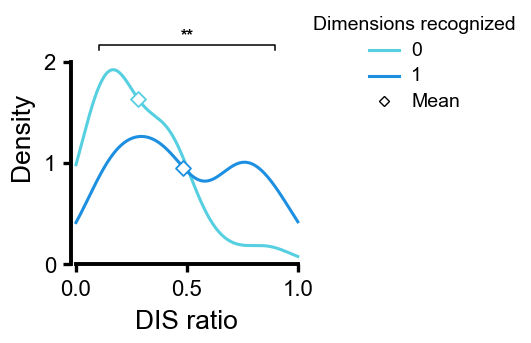

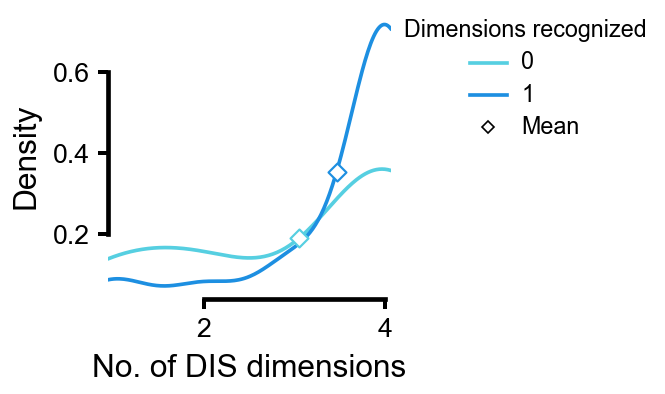

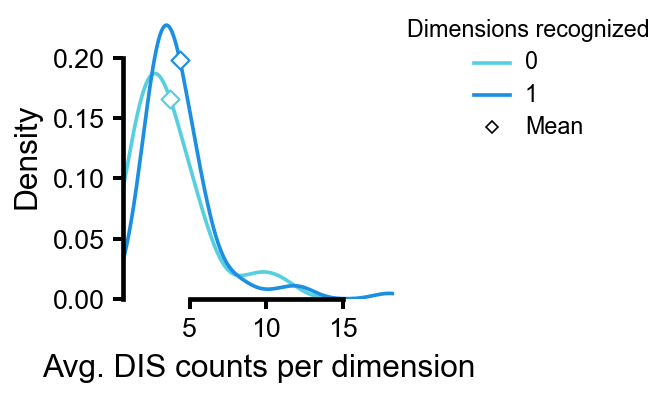

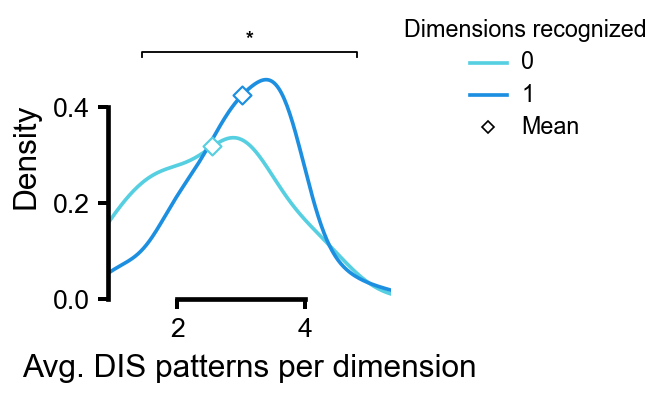

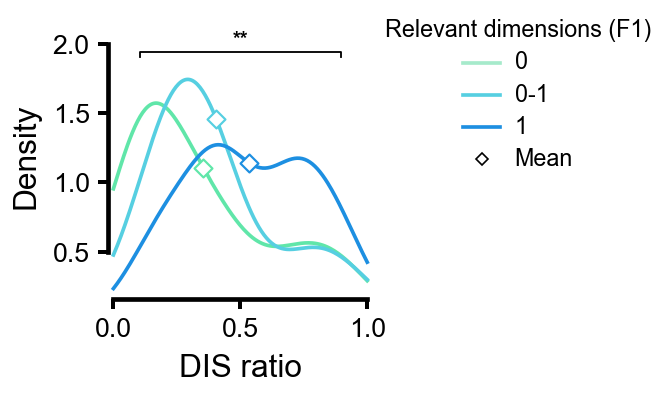

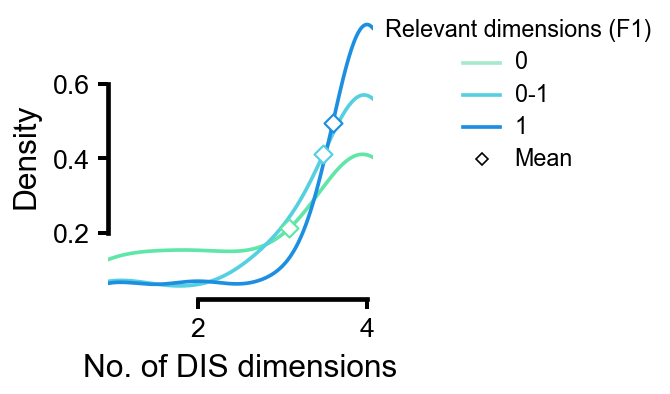

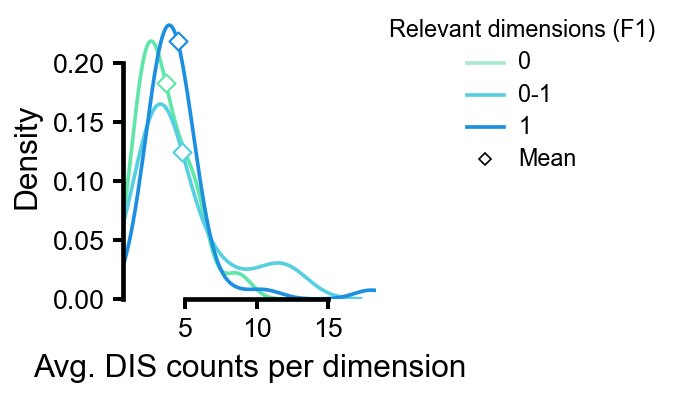

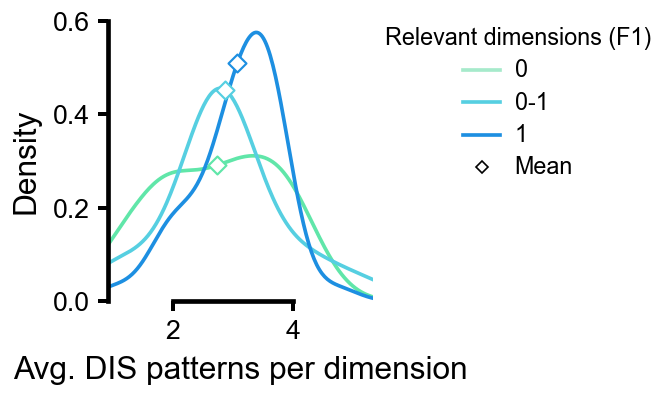

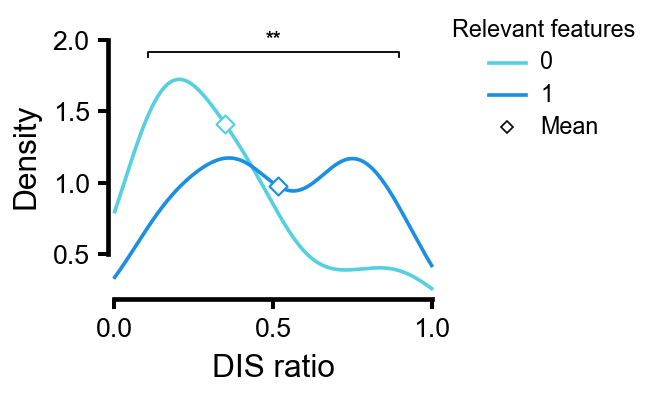

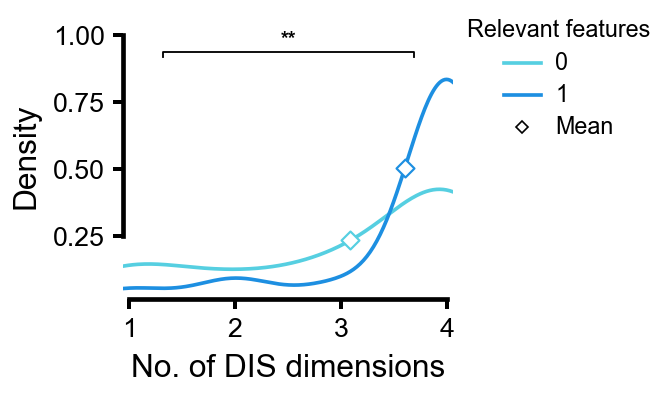

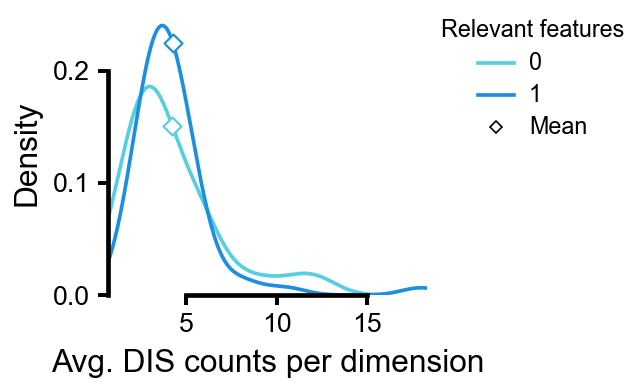

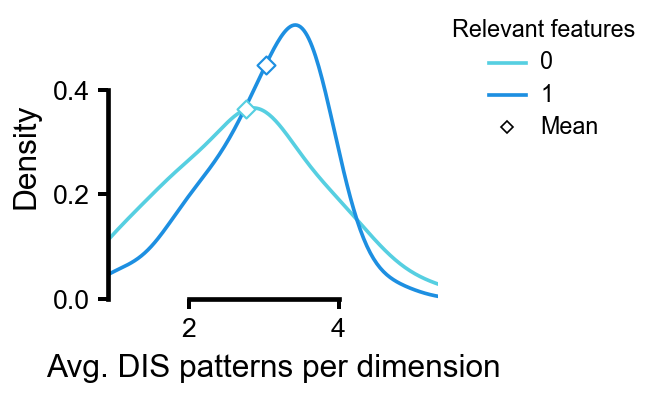

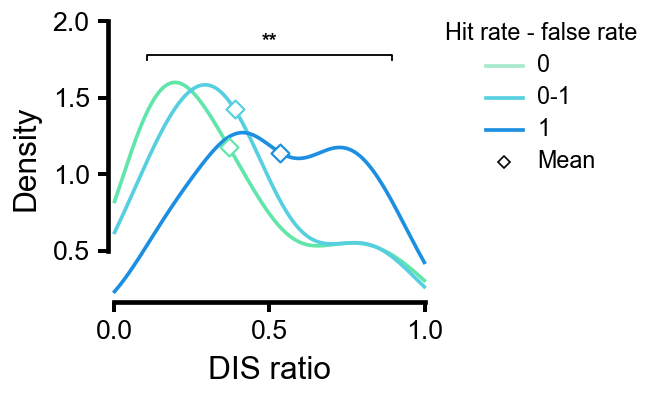

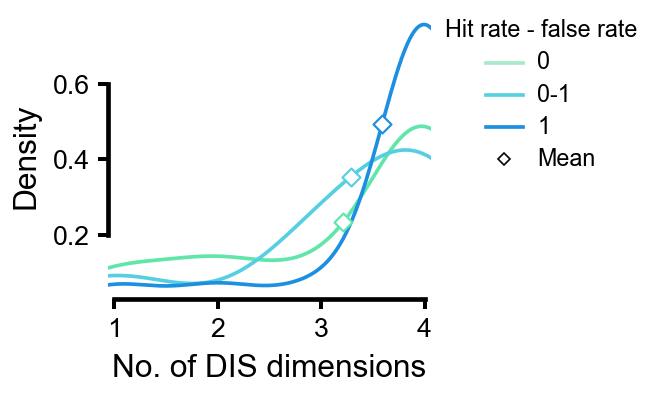

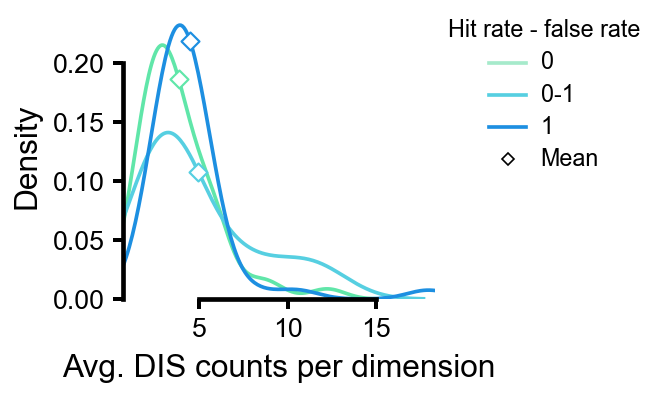

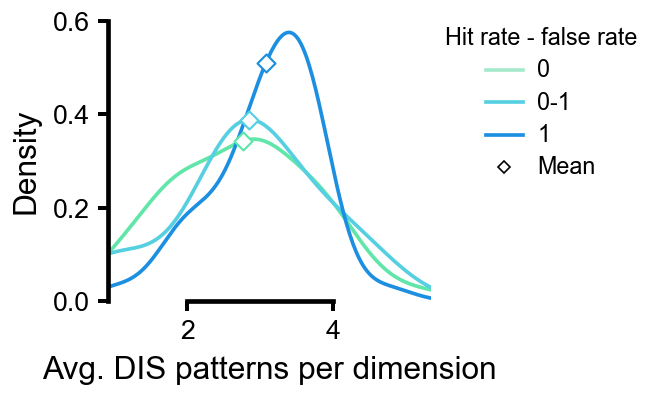

,text_metric,fds_metric,n,groups,global_test,global_p,path
0,4D_dimensions_recognized,FDS_ratio,104,"0, 1",KS,0.008077,figures_saving_for_layout\density_4D_dimension...
1,4D_dimensions_recognized,FDS_dimensions,104,"0, 1",KS,0.399251,figures_saving_for_layout\density_4D_dimension...
2,4D_dimensions_recognized,FDS_counts_per_dms,104,"0, 1",KS,0.109983,figures_saving_for_layout\density_4D_dimension...
3,4D_dimensions_recognized,FDS_patterns_per_dms,104,"0, 1",KS,0.241926,figures_saving_for_layout\density_4D_dimension...
4,4D_dimensions_relevant_answer_F1,FDS_ratio,105,"0, 0-1, 1",Kruskal-Wallis,0.003241,figures_saving_for_layout\density_4D_dimension...
5,4D_dimensions_relevant_answer_F1,FDS_dimensions,105,"0, 0-1, 1",Kruskal-Wallis,0.057934,figures_saving_for_layout\density_4D_dimension...
6,4D_dimensions_relevant_answer_F1,FDS_counts_per_dms,105,"0, 0-1, 1",Kruskal-Wallis,0.120897,figures_saving_for_layout\density_4D_dimension...
7,4D_dimensions_relevant_answer_F1,FDS_patterns_per_dms,105,"0, 0-1, 1",Kruskal-Wallis,0.220173,figures_saving_for_layout\density_4D_dimension...
8,4D_features_relevant_answer,FDS_ratio,104,"0, 1",KS,0.004906,figures_saving_for_layout\density_4D_features_...
9,4D_features_relevant_answer,FDS_dimensions,104,"0, 1",KS,0.065921,figures_saving_for_layout\density_4D_features_...


In [11]:
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

from scipy.stats import ks_2samp, mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests


# =========================
# Reset style
# =========================
sns.reset_orig()
mpl.rcdefaults()


# =========================
# 标签映射：论文里更简洁
# =========================
fds_label_map = {
    "FDS_ratio": "DIS ratio",
    "FDS_dimensions": "No. of DIS dimensions",
    "FDS_counts_per_dms": "Avg. DIS counts per dimension",
    "FDS_patterns_per_dms": "Avg. DIS patterns per dimension",
    "FDS_round_ratio": "DIS round ratio",
}

text_label_map = {
    "4D_dimensions_recognized": "Dimensions recognized",
    "4D_dimensions_relevant_answer_F1": "Relevant dimensions (F1)",
    "4D_features_relevant_answer": "Relevant features",
    "4D_dimensions_relevant_answer_strict": "Relevant dimensions (strict)",
    "4D_dimensions_relevant_answer_hit_minus_false": "Hit rate - false rate",
}


# =========================
# 特殊指标：分成 0 / 0-1 / 1
# =========================
special_trinary_metrics = {
    "4D_dimensions_relevant_answer_F1",
    "4D_dimensions_relevant_answer_hit_minus_false",
}


# =========================
# 颜色：按你的蓝色系
# =========================
group_colors_3 = SURVEY_COLORS_3.copy()
group_colors_2 = SURVEY_COLORS_2.copy()
fallback_colors = SURVEY_COLORS.copy()


def p_to_stars(p):
    if pd.isna(p):
        return "ns"
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


def make_special_trinary_groups(series):
    """
    把 F1 / hit-false 这样的指标分成:
    - 0
    - 0-1   (严格来说是 0 < x < 1)
    - 1
    其他值（如 NaN, <0, >1）直接设为缺失，后续过滤掉
    """
    s = pd.to_numeric(series, errors="coerce")
    out = pd.Series(index=s.index, dtype="object")

    eps = 1e-12
    out[np.isfinite(s) & (np.abs(s - 0) <= eps)] = "0"
    out[np.isfinite(s) & (s > 0 + eps) & (s < 1 - eps)] = "0-1"
    out[np.isfinite(s) & (np.abs(s - 1) <= eps)] = "1"

    return out


def get_group_column(df, metric_name):
    """
    返回用于分组画曲线的列
    """
    if metric_name in special_trinary_metrics:
        return make_special_trinary_groups(df[metric_name])
    else:
        s = df[metric_name]
        if pd.api.types.is_numeric_dtype(s):
            return s.map(
                lambda x: str(int(x))
                if pd.notna(x) and float(x).is_integer()
                else str(x)
            )
        return s.astype(str)


def choose_palette(n_groups):
    if n_groups == 2:
        return group_colors_2
    elif n_groups == 3:
        return group_colors_3
    else:
        return fallback_colors[:n_groups]


def prepare_plot_df(data, text_metric, fds_metric, phase_col="phase"):
    """
    只保留：
    1) phase in {P2, P2-only}
    2) 当前图所需 FDS/text metric 完整
    3) 特殊指标若无法分到合法组，过滤掉
    """
    needed_cols = [text_metric, fds_metric]
    if phase_col in data.columns:
        needed_cols.append(phase_col)

    df = data.copy()

    if phase_col in df.columns:
        df = df[df[phase_col].isin(["P2", "P2-only"])].copy()

    df[fds_metric] = pd.to_numeric(df[fds_metric], errors="coerce")
    df = df.dropna(subset=[text_metric, fds_metric]).copy()

    df["_group_cat_"] = get_group_column(df, text_metric)
    df = df.dropna(subset=["_group_cat_"]).copy()

    return df


def run_distribution_tests(plot_df, group_col, x_col):
    """
    返回不含 nan 的统计结果
    """
    tmp = plot_df[[group_col, x_col]].dropna().copy()

    groups = []
    group_names = []

    for g, sub in tmp.groupby(group_col):
        vals = pd.to_numeric(sub[x_col], errors="coerce").dropna().values
        if len(vals) > 0:
            groups.append(vals)
            group_names.append(g)

    if len(groups) < 2:
        return {
            "global_test": None,
            "global_p": None,
            "pairwise": pd.DataFrame(),
        }

    # 两组
    if len(groups) == 2:
        g1, g2 = groups
        n1, n2 = group_names

        ks_stat, ks_p = ks_2samp(g1, g2)
        mw_stat, mw_p = mannwhitneyu(g1, g2, alternative="two-sided")

        pairwise_df = pd.DataFrame([
            {
                "group1": n1,
                "group2": n2,
                "test": "KS",
                "stat": ks_stat,
                "p": ks_p,
                "p_adj": ks_p,
                "sig": p_to_stars(ks_p),
            },
            {
                "group1": n1,
                "group2": n2,
                "test": "Mann-Whitney U",
                "stat": mw_stat,
                "p": mw_p,
                "p_adj": mw_p,
                "sig": p_to_stars(mw_p),
            }
        ])

        return {
            "global_test": "KS",
            "global_p": ks_p,
            "pairwise": pairwise_df,
        }

    # 三组及以上
    kw_stat, kw_p = kruskal(*groups)

    pair_rows = []
    raw_ps = []

    for (name1, vals1), (name2, vals2) in combinations(zip(group_names, groups), 2):
        stat, p = mannwhitneyu(vals1, vals2, alternative="two-sided")
        pair_rows.append({
            "group1": name1,
            "group2": name2,
            "test": "Mann-Whitney U",
            "stat": stat,
            "p": p,
        })
        raw_ps.append(p)

    if len(raw_ps) > 0:
        _, p_adj, _, _ = multipletests(raw_ps, method="fdr_bh")
        for row, adj_p in zip(pair_rows, p_adj):
            row["p_adj"] = adj_p
            row["sig"] = p_to_stars(adj_p)

    pairwise_df = pd.DataFrame(pair_rows)

    return {
        "global_test": "Kruskal-Wallis",
        "global_p": kw_p,
        "pairwise": pairwise_df,
    }


def add_sig_brackets_on_ax(ax, pairwise_df, group_order, p_col="p_adj", sig_col="sig"):
    """
    在 KDE 图顶部加显著性括号和星号。
    只显示显著结果，不显示 ns。

    说明：
    KDE 图没有像 boxplot 那样天然的离散 x 中心，
    这里采用“在当前 x 轴范围顶部按组等间距摆放”的方式标注。
    """
    if pairwise_df is None or pairwise_df.empty:
        return

    sig_df = pairwise_df.copy()

    # 只保留显著项
    if sig_col in sig_df.columns:
        sig_df = sig_df[sig_df[sig_col].isin(["*", "**", "***"])].copy()
    elif p_col in sig_df.columns:
        sig_df = sig_df[sig_df[p_col] < 0.05].copy()

    if sig_df.empty:
        return

    # 如果是两组时，你的统计里会同时有 KS 和 MWU 两行
    # 为避免同一组对被画两次，这里优先保留 p_adj 更小的一条
    sig_df["_pair_key_"] = sig_df.apply(
        lambda r: tuple(sorted([str(r["group1"]), str(r["group2"])])),
        axis=1
    )
    if p_col in sig_df.columns:
        sig_df = (
            sig_df.sort_values(by=p_col, ascending=True)
                  .drop_duplicates(subset=["_pair_key_"], keep="first")
                  .copy()
        )

    # 按跨度优先、再按 p 值优先，尽量减少重叠观感
    group_rank = {g: i for i, g in enumerate(group_order)}
    sig_df["_span_"] = sig_df.apply(
        lambda r: abs(group_rank.get(r["group1"], 0) - group_rank.get(r["group2"], 0)),
        axis=1
    )
    sort_cols = ["_span_"]
    ascending = [False]
    if p_col in sig_df.columns:
        sort_cols.append(p_col)
        ascending.append(True)
    sig_df = sig_df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)

    x0, x1 = ax.get_xlim()
    n = len(group_order)
    if n < 2:
        return

    # 在 x 轴范围内为每个组分配一个“顶部标注位置”
    xpos = np.linspace(x0 + 0.12 * (x1 - x0), x1 - 0.12 * (x1 - x0), n)
    group_to_x = dict(zip(group_order, xpos))

    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin if ymax > ymin else 1.0

    base_y = ymax + 0.05 * yr
    step_y = 0.09 * yr
    h = 0.025 * yr

    # 简单分层：如果区间有重叠，就放到更高层
    placed_intervals = []

    def overlaps(a1, a2, b1, b2):
        return not (a2 < b1 or b2 < a1)

    bracket_levels = []
    for _, row in sig_df.iterrows():
        g1, g2 = row["group1"], row["group2"]
        if g1 not in group_to_x or g2 not in group_to_x:
            bracket_levels.append(0)
            continue

        xa = group_to_x[g1]
        xb = group_to_x[g2]
        if xa > xb:
            xa, xb = xb, xa

        level = 0
        while True:
            conflict = False
            for (pxa, pxb, plevel) in placed_intervals:
                if plevel == level and overlaps(xa, xb, pxa, pxb):
                    conflict = True
                    level += 1
                    break
            if not conflict:
                placed_intervals.append((xa, xb, level))
                bracket_levels.append(level)
                break

    # 真正画出来
    max_level = 0
    for idx, (_, row) in enumerate(sig_df.iterrows()):
        g1, g2 = row["group1"], row["group2"]
        star = row[sig_col] if sig_col in row else p_to_stars(row[p_col])

        if g1 not in group_to_x or g2 not in group_to_x:
            continue

        xa = group_to_x[g1]
        xb = group_to_x[g2]
        if xa > xb:
            xa, xb = xb, xa

        level = bracket_levels[idx]
        max_level = max(max_level, level)

        y = base_y + level * step_y

        ax.plot(
            [xa, xa, xb, xb],
            [y, y + h, y + h, y],
            color="black",
            linewidth=1.1,
            clip_on=False,
            zorder=10,
        )

        ax.text(
            (xa + xb) / 2,
            y + h + 0.01 * yr,
            star,
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            clip_on=False,
            zorder=11,
        )

    # 顶部抬高，防止被裁剪
    new_ymax = ymax + 0.08 * yr + (max_level + 1) * step_y + 0.08 * yr
    ax.set_ylim(ymin, new_ymax)


def plot_density_publication(
    data,
    text_metric,
    fds_metric,
    output_dir="figures_saving_for_layout",
    phase_col="phase",
    category_order=None,
    bw_adjust=1.0,
    max_categories=8,
    show_global_star=False,
    show_pairwise_sig=True,
):
    if text_metric not in data.columns or fds_metric not in data.columns:
        return None

    plot_df = prepare_plot_df(
        data=data,
        text_metric=text_metric,
        fds_metric=fds_metric,
        phase_col=phase_col,
    )

    if plot_df.empty:
        return None

    # 类别顺序
    if text_metric in special_trinary_metrics:
        cats_present = [c for c in ["0", "0-1", "1"] if c in plot_df["_group_cat_"].unique()]
    elif category_order is not None:
        cats_present = [c for c in category_order if c in plot_df["_group_cat_"].unique()]
    else:
        unique_vals = plot_df["_group_cat_"].dropna().unique().tolist()
        try:
            cats_present = sorted(unique_vals, key=lambda x: float(x))
        except Exception:
            cats_present = sorted(unique_vals)

    if len(cats_present) < 2:
        return None

    if len(cats_present) > max_categories:
        cats_present = cats_present[:max_categories]

    plot_df = plot_df[plot_df["_group_cat_"].isin(cats_present)].copy()

    group_counts = plot_df["_group_cat_"].value_counts()
    cats_present = [c for c in cats_present if c in group_counts.index and group_counts[c] > 0]

    if len(cats_present) < 2:
        return None

    palette = choose_palette(len(cats_present))
    test_results = run_distribution_tests(plot_df, "_group_cat_", fds_metric)

    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    fig, ax = plt.subplots(figsize=(6.4, 3.4))
    legend_handles = []
    single_value_groups = []

    vals_all = plot_df[fds_metric].dropna().values
    x_min_data = np.min(vals_all)
    x_max_data = np.max(vals_all)

    if np.isclose(x_min_data, x_max_data):
        clip = (x_min_data - 0.05, x_max_data + 0.05)
    else:
        span = x_max_data - x_min_data
        clip = (x_min_data - 0.02 * span, x_max_data + 0.02 * span)

    for i, cat in enumerate(cats_present):
        sub_vals = pd.to_numeric(
            plot_df.loc[plot_df["_group_cat_"] == cat, fds_metric],
            errors="coerce"
        ).dropna()

        if len(sub_vals) == 0:
            continue

        color = palette[i]
        mean_val = sub_vals.mean()
        label = str(cat)

        if sub_vals.nunique() > 1:
            n_before = len(ax.lines)

            sns.kdeplot(
                sub_vals,
                ax=ax,
                color=color,
                linewidth=2.2,
                fill=False,
                bw_adjust=bw_adjust,
                linestyle="-",
                clip=clip,
            )

            kde_line = ax.lines[-1] if len(ax.lines) > n_before else None

            if kde_line is not None:
                xdata = np.asarray(kde_line.get_xdata(), dtype=float)
                ydata = np.asarray(kde_line.get_ydata(), dtype=float)

                if len(xdata) > 1:
                    order = np.argsort(xdata)
                    x_sorted = xdata[order]
                    y_sorted = ydata[order]
                    mean_clip = np.clip(mean_val, x_sorted.min(), x_sorted.max())
                    mean_y = np.interp(mean_clip, x_sorted, y_sorted)

                    ax.scatter(
                        mean_clip,
                        mean_y,
                        marker="D",
                        s=58,
                        facecolor="white",
                        edgecolor=color,
                        linewidth=1.3,
                        zorder=5,
                    )
        else:
            single_x = sub_vals.iloc[0]
            ax.axvline(
                single_x,
                color=color,
                linewidth=2.2,
                linestyle="-",
                alpha=0.95,
                zorder=4,
            )
            single_value_groups.append((single_x, color))

        legend_handles.append(
            mlines.Line2D(
                [], [], color=color, linewidth=2.2, linestyle="-", label=label
            )
        )

    # 单值组补均值菱形
    ymax_now = ax.get_ylim()[1]
    for single_x, color_ in single_value_groups:
        ax.scatter(
            single_x,
            ymax_now * 0.58,
            marker="D",
            s=58,
            facecolor="white",
            edgecolor=color_,
            linewidth=1.3,
            zorder=5,
        )

    ax.set_title("")
    ax.set_xlabel(fds_label_map.get(fds_metric, fds_metric), fontsize=14)
    ax.set_ylabel("Density", fontsize=14)

    if "ratio" in fds_metric.lower():
        ax.set_xlim(-0.02, 1.02)
    else:
        ax.set_xlim(clip[0], clip[1])

    ax.tick_params(
        axis="both",
        direction="out",
        length=5,
        width=1.1,
        labelsize=12,
        colors="black"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.grid(False)

    legend_handles.append(
        mlines.Line2D(
            [], [], color="black", marker="D", markersize=5.5,
            linestyle="None", markerfacecolor="white", label="Mean"
        )
    )

    ax.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        frameon=False,
        borderaxespad=0.0,
        fontsize=11,
        title=text_label_map.get(text_metric, text_metric),
        title_fontsize=11,
    )

    # 总体显著性：右上角小星号
    if show_global_star and test_results["global_p"] is not None:
        star = p_to_stars(test_results["global_p"])
        if star != "ns":
            ax.text(
                0.98, 0.98, star,
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=13, fontweight="bold"
            )

    # pairwise 显著性：只显示显著项，不显示 ns
    if show_pairwise_sig:
        add_sig_brackets_on_ax(
            ax=ax,
            pairwise_df=test_results["pairwise"],
            group_order=cats_present,
            p_col="p_adj",
            sig_col="sig",
        )

    plt.tight_layout(rect=[0, 0, 0.82, 1])

    safe_text = str(text_metric).replace("/", "_").replace(" ", "_")
    safe_fds = str(fds_metric).replace("/", "_").replace(" ", "_")
    output_path = Path(output_dir) / f"density_{safe_text}_by_{safe_fds}.png"

    style_figure(fig)
    save_figure(fig, output_path, dpi=300, bbox_inches="tight")
    style_figure(plt.gcf())
    plt.show()

    return {
        "text_metric": text_metric,
        "fds_metric": fds_metric,
        "n": len(plot_df),
        "groups": cats_present,
        "global_test": test_results["global_test"],
        "global_p": test_results["global_p"],
        "pairwise": test_results["pairwise"],
        "path": str(output_path),
    }


# =========================
# 批量运行
# =========================
fds_metrics_to_plot = [
    "FDS_ratio",
    "FDS_dimensions",
    "FDS_counts_per_dms",
    "FDS_patterns_per_dms",
    # "DIS_round_ratio",
]

text_metrics_to_plot = [
    "4D_dimensions_recognized",
    "4D_dimensions_relevant_answer_F1",
    "4D_features_relevant_answer",
    "4D_dimensions_relevant_answer_hit_minus_false",
]

all_reports = []

for text_metric in text_metrics_to_plot:
    for fds_metric in fds_metrics_to_plot:
        res = plot_density_publication(
            data=analysis_fds_df,
            text_metric=text_metric,
            fds_metric=fds_metric,
            output_dir="figures_saving_for_layout",
            phase_col="phase",
            category_order=None,
            bw_adjust=1.0,
            max_categories=8,
            show_global_star=False,
            show_pairwise_sig=True,   # 这里打开：显示所有显著 pairwise
        )
        if res is not None:
            all_reports.append(res)

summary_rows = []
for r in all_reports:
    summary_rows.append({
        "text_metric": r["text_metric"],
        "fds_metric": r["fds_metric"],
        "n": r["n"],
        "groups": ", ".join(map(str, r["groups"])),
        "global_test": r["global_test"],
        "global_p": r["global_p"],
        "path": r["path"],
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

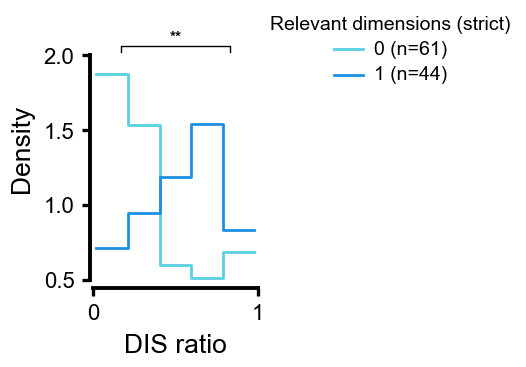

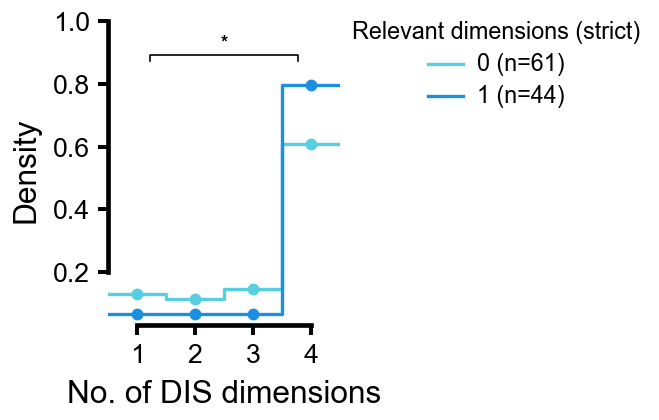

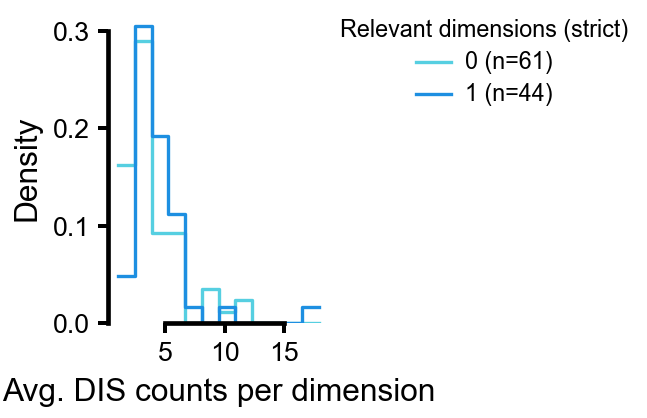

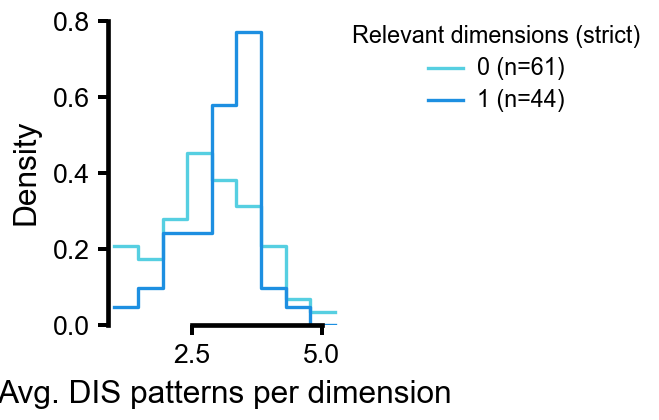

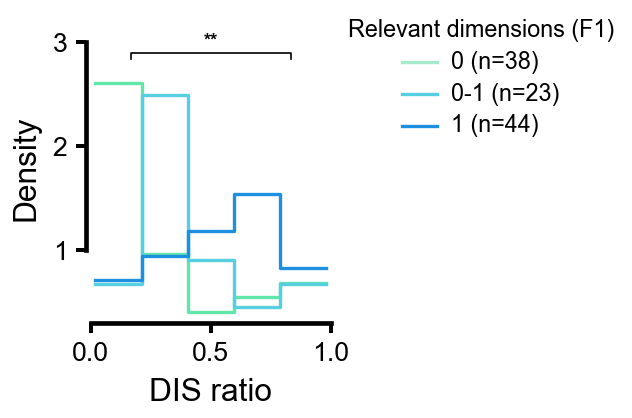

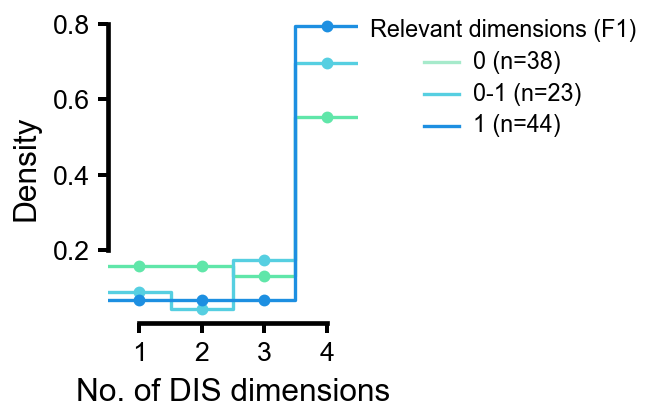

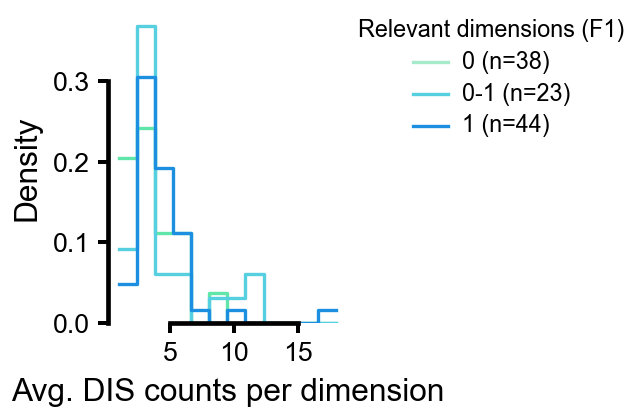

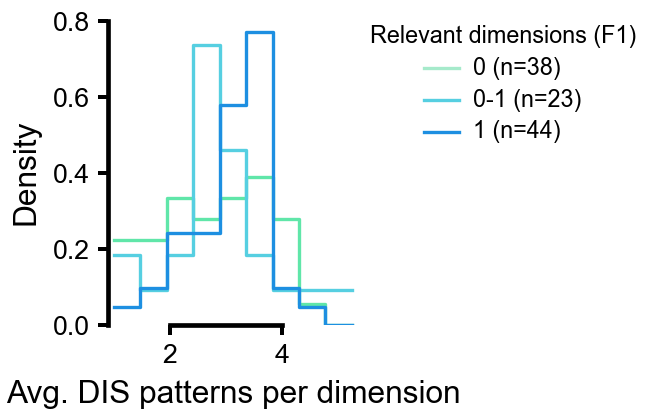

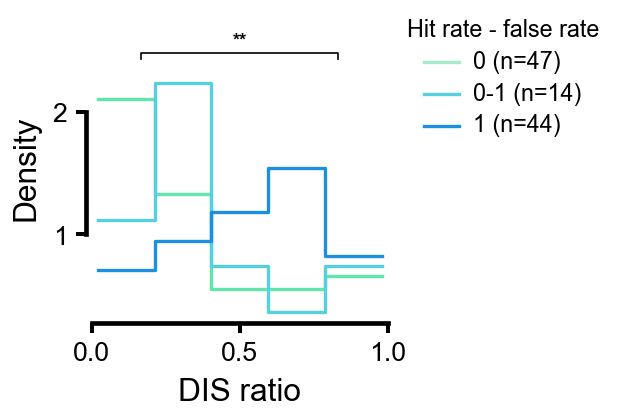

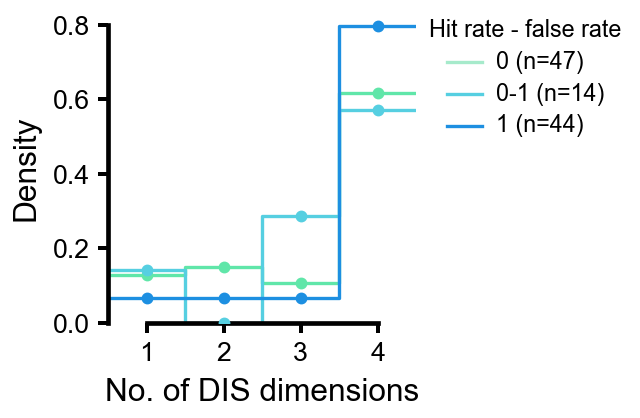

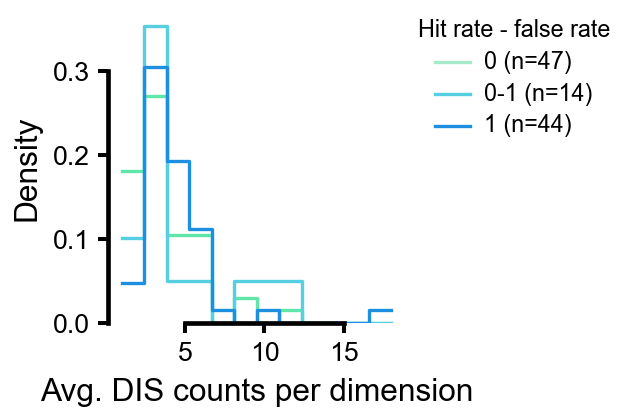

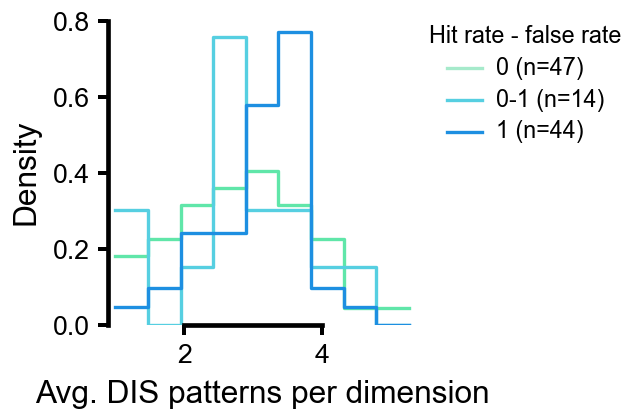

,text_metric,fds_metric,n,groups,discrete_x,global_test,global_p,path
0,4D_dimensions_relevant_answer_strict,FDS_ratio,105,"0, 1",False,KS,0.002283,figures_saving_for_layout\hist_4D_dimensions_r...
1,4D_dimensions_relevant_answer_strict,FDS_dimensions,105,"0, 1",True,KS,0.275492,figures_saving_for_layout\hist_4D_dimensions_r...
2,4D_dimensions_relevant_answer_strict,FDS_counts_per_dms,105,"0, 1",False,KS,0.078156,figures_saving_for_layout\hist_4D_dimensions_r...
3,4D_dimensions_relevant_answer_strict,FDS_patterns_per_dms,105,"0, 1",False,KS,0.112453,figures_saving_for_layout\hist_4D_dimensions_r...
4,4D_dimensions_relevant_answer_F1,FDS_ratio,105,"0, 0-1, 1",False,Kruskal-Wallis,0.003241,figures_saving_for_layout\hist_4D_dimensions_r...
5,4D_dimensions_relevant_answer_F1,FDS_dimensions,105,"0, 0-1, 1",True,Kruskal-Wallis,0.057934,figures_saving_for_layout\hist_4D_dimensions_r...
6,4D_dimensions_relevant_answer_F1,FDS_counts_per_dms,105,"0, 0-1, 1",False,Kruskal-Wallis,0.120897,figures_saving_for_layout\hist_4D_dimensions_r...
7,4D_dimensions_relevant_answer_F1,FDS_patterns_per_dms,105,"0, 0-1, 1",False,Kruskal-Wallis,0.220173,figures_saving_for_layout\hist_4D_dimensions_r...
8,4D_dimensions_relevant_answer_hit_minus_false,FDS_ratio,105,"0, 0-1, 1",False,Kruskal-Wallis,0.005105,figures_saving_for_layout\hist_4D_dimensions_r...
9,4D_dimensions_relevant_answer_hit_minus_false,FDS_dimensions,105,"0, 0-1, 1",True,Kruskal-Wallis,0.139987,figures_saving_for_layout\hist_4D_dimensions_r...


In [12]:
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

from scipy.stats import ks_2samp, mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests

sns.reset_orig()
mpl.rcdefaults()

fds_label_map_hist = {
    "FDS_ratio": "DIS ratio",
    "FDS_dimensions": "No. of DIS dimensions",
    "FDS_counts_per_dms": "Avg. DIS counts per dimension",
    "FDS_patterns_per_dms": "Avg. DIS patterns per dimension",
    "FDS_round_ratio": "DIS round ratio",
}

relevant_dimension_metrics = [
    "4D_dimensions_relevant_answer_strict",
    "4D_dimensions_relevant_answer_F1",
    "4D_dimensions_relevant_answer_hit_minus_false",
]

relevant_dimension_label_map = {
    "4D_dimensions_relevant_answer_strict": "Relevant dimensions (strict)",
    "4D_dimensions_relevant_answer_F1": "Relevant dimensions (F1)",
    "4D_dimensions_relevant_answer_hit_minus_false": "Hit rate - false rate",
}

special_trinary_metrics_hist = {
    "4D_dimensions_relevant_answer_F1",
    "4D_dimensions_relevant_answer_hit_minus_false",
}

group_colors_3_hist = SURVEY_COLORS_3.copy()
group_colors_2_hist = SURVEY_COLORS_2.copy()
fallback_colors_hist = SURVEY_COLORS.copy()


def p_to_stars_hist(p):
    if pd.isna(p):
        return "ns"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def make_special_trinary_groups_hist(series):
    s = pd.to_numeric(series, errors="coerce")
    out = pd.Series(index=s.index, dtype="object")
    eps = 1e-12
    out[np.isfinite(s) & (np.abs(s - 0) <= eps)] = "0"
    out[np.isfinite(s) & (s > 0 + eps) & (s < 1 - eps)] = "0-1"
    out[np.isfinite(s) & (np.abs(s - 1) <= eps)] = "1"
    return out


def get_group_column_hist(df, metric_name):
    if metric_name in special_trinary_metrics_hist:
        return make_special_trinary_groups_hist(df[metric_name])

    s = pd.to_numeric(df[metric_name], errors="coerce")
    out = pd.Series(index=s.index, dtype="object")
    out[np.isfinite(s) & (np.abs(s - 0) <= 1e-12)] = "0"
    out[np.isfinite(s) & (np.abs(s - 1) <= 1e-12)] = "1"
    return out


def choose_palette_hist(n_groups):
    if n_groups == 2:
        return group_colors_2_hist
    if n_groups == 3:
        return group_colors_3_hist
    return fallback_colors_hist[:n_groups]


def prepare_plot_df_hist(data, text_metric, fds_metric, phase_col="phase"):
    df = data.copy()
    if phase_col in df.columns:
        df = df[df[phase_col].isin(["P2", "P2-only"])].copy()

    df[fds_metric] = pd.to_numeric(df[fds_metric], errors="coerce")
    df[text_metric] = pd.to_numeric(df[text_metric], errors="coerce")
    df = df.dropna(subset=[text_metric, fds_metric]).copy()
    df["_group_cat_"] = get_group_column_hist(df, text_metric)
    df = df.dropna(subset=["_group_cat_"]).copy()
    return df


def run_distribution_tests_hist(plot_df, group_col, x_col):
    tmp = plot_df[[group_col, x_col]].dropna().copy()
    groups = []
    group_names = []

    for g, sub in tmp.groupby(group_col):
        vals = pd.to_numeric(sub[x_col], errors="coerce").dropna().values
        if len(vals) > 0:
            groups.append(vals)
            group_names.append(g)

    if len(groups) < 2:
        return {"global_test": None, "global_p": None, "pairwise": pd.DataFrame()}

    if len(groups) == 2:
        g1, g2 = groups
        n1, n2 = group_names
        ks_stat, ks_p = ks_2samp(g1, g2)
        mw_stat, mw_p = mannwhitneyu(g1, g2, alternative="two-sided")
        pairwise_df = pd.DataFrame([
            {"group1": n1, "group2": n2, "test": "KS", "stat": ks_stat, "p": ks_p, "p_adj": ks_p, "sig": p_to_stars_hist(ks_p)},
            {"group1": n1, "group2": n2, "test": "Mann-Whitney U", "stat": mw_stat, "p": mw_p, "p_adj": mw_p, "sig": p_to_stars_hist(mw_p)},
        ])
        return {"global_test": "KS", "global_p": ks_p, "pairwise": pairwise_df}

    kw_stat, kw_p = kruskal(*groups)
    pair_rows = []
    raw_ps = []

    for (name1, vals1), (name2, vals2) in combinations(zip(group_names, groups), 2):
        stat, p = mannwhitneyu(vals1, vals2, alternative="two-sided")
        pair_rows.append({"group1": name1, "group2": name2, "test": "Mann-Whitney U", "stat": stat, "p": p})
        raw_ps.append(p)

    if raw_ps:
        _, p_adj, _, _ = multipletests(raw_ps, method="fdr_bh")
        for row, adj_p in zip(pair_rows, p_adj):
            row["p_adj"] = adj_p
            row["sig"] = p_to_stars_hist(adj_p)

    return {"global_test": "Kruskal-Wallis", "global_p": kw_p, "pairwise": pd.DataFrame(pair_rows)}


def is_discrete_distribution(values):
    vals = pd.Series(values).dropna().astype(float)
    if vals.empty:
        return False
    unique_vals = np.sort(vals.unique())
    if len(unique_vals) <= 8:
        if np.allclose(unique_vals, np.round(unique_vals), atol=1e-12):
            return True
        if len(unique_vals) <= 6:
            return True
    return False


def compute_bins(values, discrete):
    vals = pd.Series(values).dropna().astype(float)
    if vals.empty:
        return np.array([0.0, 1.0]), None

    if discrete:
        unique_vals = np.sort(vals.unique())
        if len(unique_vals) == 1:
            v = unique_vals[0]
            return np.array([v - 0.5, v + 0.5]), unique_vals
        diffs = np.diff(unique_vals)
        step = np.min(diffs[diffs > 0]) if np.any(diffs > 0) else 1.0
        edges = np.concatenate(([unique_vals[0] - step / 2], (unique_vals[:-1] + unique_vals[1:]) / 2, [unique_vals[-1] + step / 2]))
        return edges, unique_vals

    if np.allclose(vals.min(), vals.max()):
        v = vals.iloc[0]
        return np.array([v - 0.05, v + 0.05]), None

    edges = np.histogram_bin_edges(vals, bins="fd")
    if len(edges) < 5:
        edges = np.histogram_bin_edges(vals, bins=6)
    if len(edges) > 15:
        edges = np.histogram_bin_edges(vals, bins=12)
    return edges, None


def add_sig_brackets_hist(ax, pairwise_df, group_order):
    if pairwise_df is None or pairwise_df.empty:
        return

    sig_df = pairwise_df[pairwise_df["sig"].isin(["*", "**", "***"])].copy()
    if sig_df.empty:
        return

    sig_df["_pair_key_"] = sig_df.apply(lambda r: tuple(sorted([str(r["group1"]), str(r["group2"])])), axis=1)
    sig_df = sig_df.sort_values(by="p_adj", ascending=True).drop_duplicates(subset=["_pair_key_"], keep="first").copy()

    x0, x1 = ax.get_xlim()
    xpos = np.linspace(x0 + 0.18 * (x1 - x0), x1 - 0.18 * (x1 - x0), len(group_order))
    group_to_x = dict(zip(group_order, xpos))

    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin if ymax > ymin else 1.0
    base_y = ymax + 0.05 * yr
    step_y = 0.10 * yr
    h = 0.025 * yr

    placed = []

    def overlaps(a1, a2, b1, b2):
        return not (a2 < b1 or b2 < a1)

    max_level = 0
    for _, row in sig_df.iterrows():
        g1, g2 = row["group1"], row["group2"]
        if g1 not in group_to_x or g2 not in group_to_x:
            continue
        xa, xb = sorted([group_to_x[g1], group_to_x[g2]])
        level = 0
        while any(pl == level and overlaps(xa, xb, pa, pb) for pa, pb, pl in placed):
            level += 1
        placed.append((xa, xb, level))
        max_level = max(max_level, level)
        y = base_y + level * step_y
        ax.plot([xa, xa, xb, xb], [y, y + h, y + h, y], color="black", linewidth=1.0, clip_on=False)
        ax.text((xa + xb) / 2, y + h + 0.01 * yr, row["sig"], ha="center", va="bottom", fontsize=11, fontweight="bold", clip_on=False)

    ax.set_ylim(ymin, ymax + 0.14 * yr + (max_level + 1) * step_y)


def plot_histogram_publication(data, text_metric, fds_metric, output_dir="figures_saving_for_layout", phase_col="phase"):
    if text_metric not in data.columns or fds_metric not in data.columns:
        return None

    plot_df = prepare_plot_df_hist(data, text_metric, fds_metric, phase_col=phase_col)
    if plot_df.empty:
        return None

    if text_metric in special_trinary_metrics_hist:
        cats_present = [c for c in ["0", "0-1", "1"] if c in plot_df["_group_cat_"].unique()]
    else:
        cats_present = [c for c in ["0", "1"] if c in plot_df["_group_cat_"].unique()]

    if len(cats_present) < 2:
        return None

    plot_df = plot_df[plot_df["_group_cat_"].isin(cats_present)].copy()
    group_counts = plot_df["_group_cat_"].value_counts()
    cats_present = [c for c in cats_present if group_counts.get(c, 0) > 0]
    if len(cats_present) < 2:
        return None

    palette = choose_palette_hist(len(cats_present))
    test_results = run_distribution_tests_hist(plot_df, "_group_cat_", fds_metric)
    discrete = is_discrete_distribution(plot_df[fds_metric])
    bins, xticks = compute_bins(plot_df[fds_metric], discrete=discrete)

    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    legend_handles = []

    for i, cat in enumerate(cats_present):
        sub_vals = pd.to_numeric(plot_df.loc[plot_df["_group_cat_"] == cat, fds_metric], errors="coerce").dropna()
        if sub_vals.empty:
            continue

        color = palette[i]
        sns.histplot(
            sub_vals,
            bins=bins,
            stat="density",
            element="step",
            fill=False,
            common_norm=False,
            linewidth=2.0,
            alpha=1.0,
            color=color,
            ax=ax,
        )

        if discrete:
            counts, edges = np.histogram(sub_vals, bins=bins, density=True)
            centers = (edges[:-1] + edges[1:]) / 2
            ax.scatter(centers, counts, color=color, s=28, zorder=4)

        legend_handles.append(
            mlines.Line2D([], [], color=color, linewidth=2.0, label=f"{cat} (n={len(sub_vals)})")
        )

    ax.set_title("")
    ax.set_xlabel(fds_label_map_hist.get(fds_metric, fds_metric), fontsize=14)
    ax.set_ylabel("Density", fontsize=14)

    if discrete and xticks is not None:
        ax.set_xticks(xticks)
        ax.set_xlim(bins[0], bins[-1])
    elif "ratio" in fds_metric.lower():
        ax.set_xlim(-0.02, 1.02)

    ax.tick_params(axis="both", direction="out", length=5, width=1.1, labelsize=12, colors="black")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.grid(False)

    ax.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        frameon=False,
        borderaxespad=0.0,
        fontsize=10.5,
        title=relevant_dimension_label_map.get(text_metric, text_metric),
        title_fontsize=11,
    )

    add_sig_brackets_hist(ax, test_results["pairwise"], cats_present)
    plt.tight_layout(rect=[0, 0, 0.80, 1])

    safe_text = str(text_metric).replace("/", "_").replace(" ", "_")
    safe_fds = str(fds_metric).replace("/", "_").replace(" ", "_")
    output_path = Path(output_dir) / f"hist_{safe_text}_by_{safe_fds}.png"

    style_figure(fig)
    save_figure(fig, output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return {
        "text_metric": text_metric,
        "fds_metric": fds_metric,
        "n": len(plot_df),
        "groups": cats_present,
        "discrete_x": discrete,
        "global_test": test_results["global_test"],
        "global_p": test_results["global_p"],
        "pairwise": test_results["pairwise"],
        "path": str(output_path),
    }


fds_metrics_to_plot = [
    "FDS_ratio",
    "FDS_dimensions",
    "FDS_counts_per_dms",
    "FDS_patterns_per_dms",
]

relevant_dimension_reports = []

for text_metric in relevant_dimension_metrics:
    for fds_metric in fds_metrics_to_plot:
        res = plot_histogram_publication(
            data=analysis_fds_df,
            text_metric=text_metric,
            fds_metric=fds_metric,
            output_dir="figures_saving_for_layout",
            phase_col="phase",
        )
        if res is not None:
            relevant_dimension_reports.append(res)

relevant_dimension_summary = pd.DataFrame([
    {
        "text_metric": r["text_metric"],
        "fds_metric": r["fds_metric"],
        "n": r["n"],
        "groups": ", ".join(map(str, r["groups"])),
        "discrete_x": r["discrete_x"],
        "global_test": r["global_test"],
        "global_p": r["global_p"],
        "path": r["path"],
    }
    for r in relevant_dimension_reports
])

display(relevant_dimension_summary)

# Whether DR on dms/ftr -> performance/DIS metrics

## Performance: best score + full score rate

使用的满分值 perfect_score = 100


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_dimensions_bestscore_maxround_fullscorerate.png


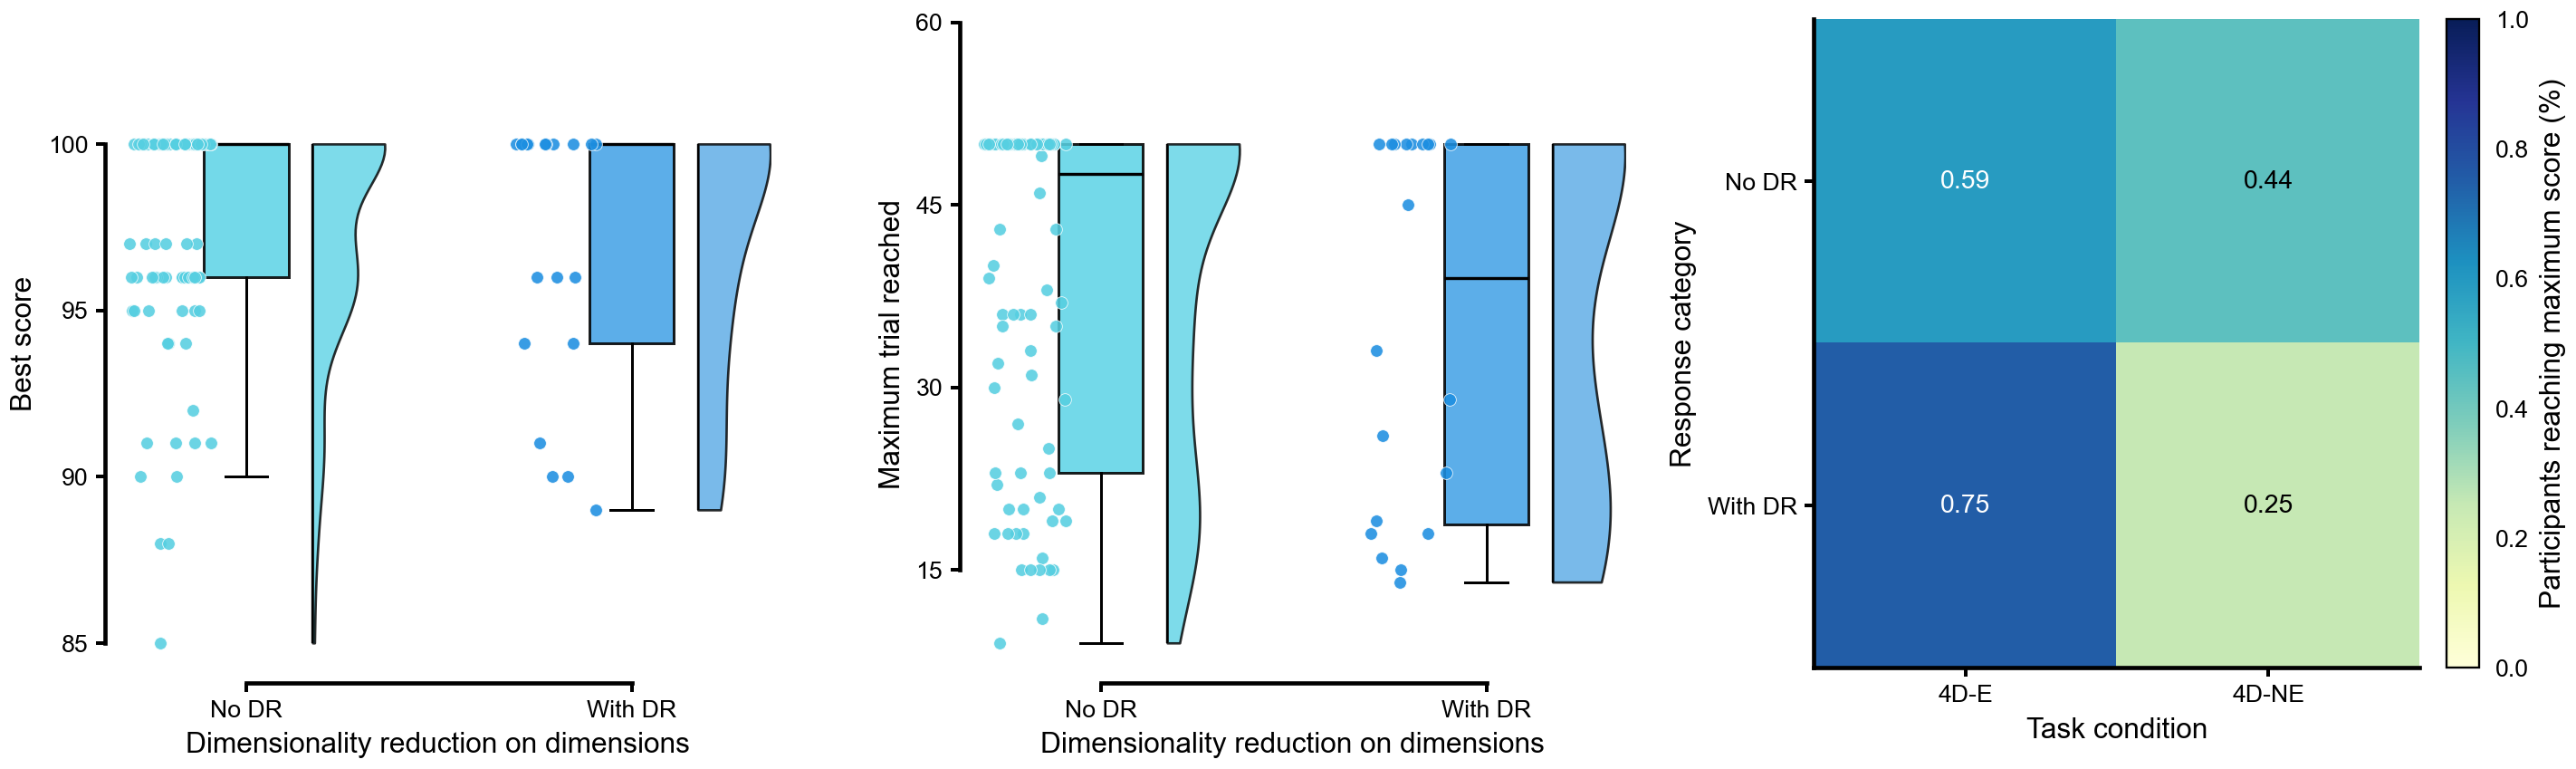


=== DR_on_dimensions | Trimmed Mann–Whitney U ===
Best score, 0 vs 1: p = 0.718
Max round,  0 vs 1: p = 0.5622


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_features_bestscore_maxround_fullscorerate.png


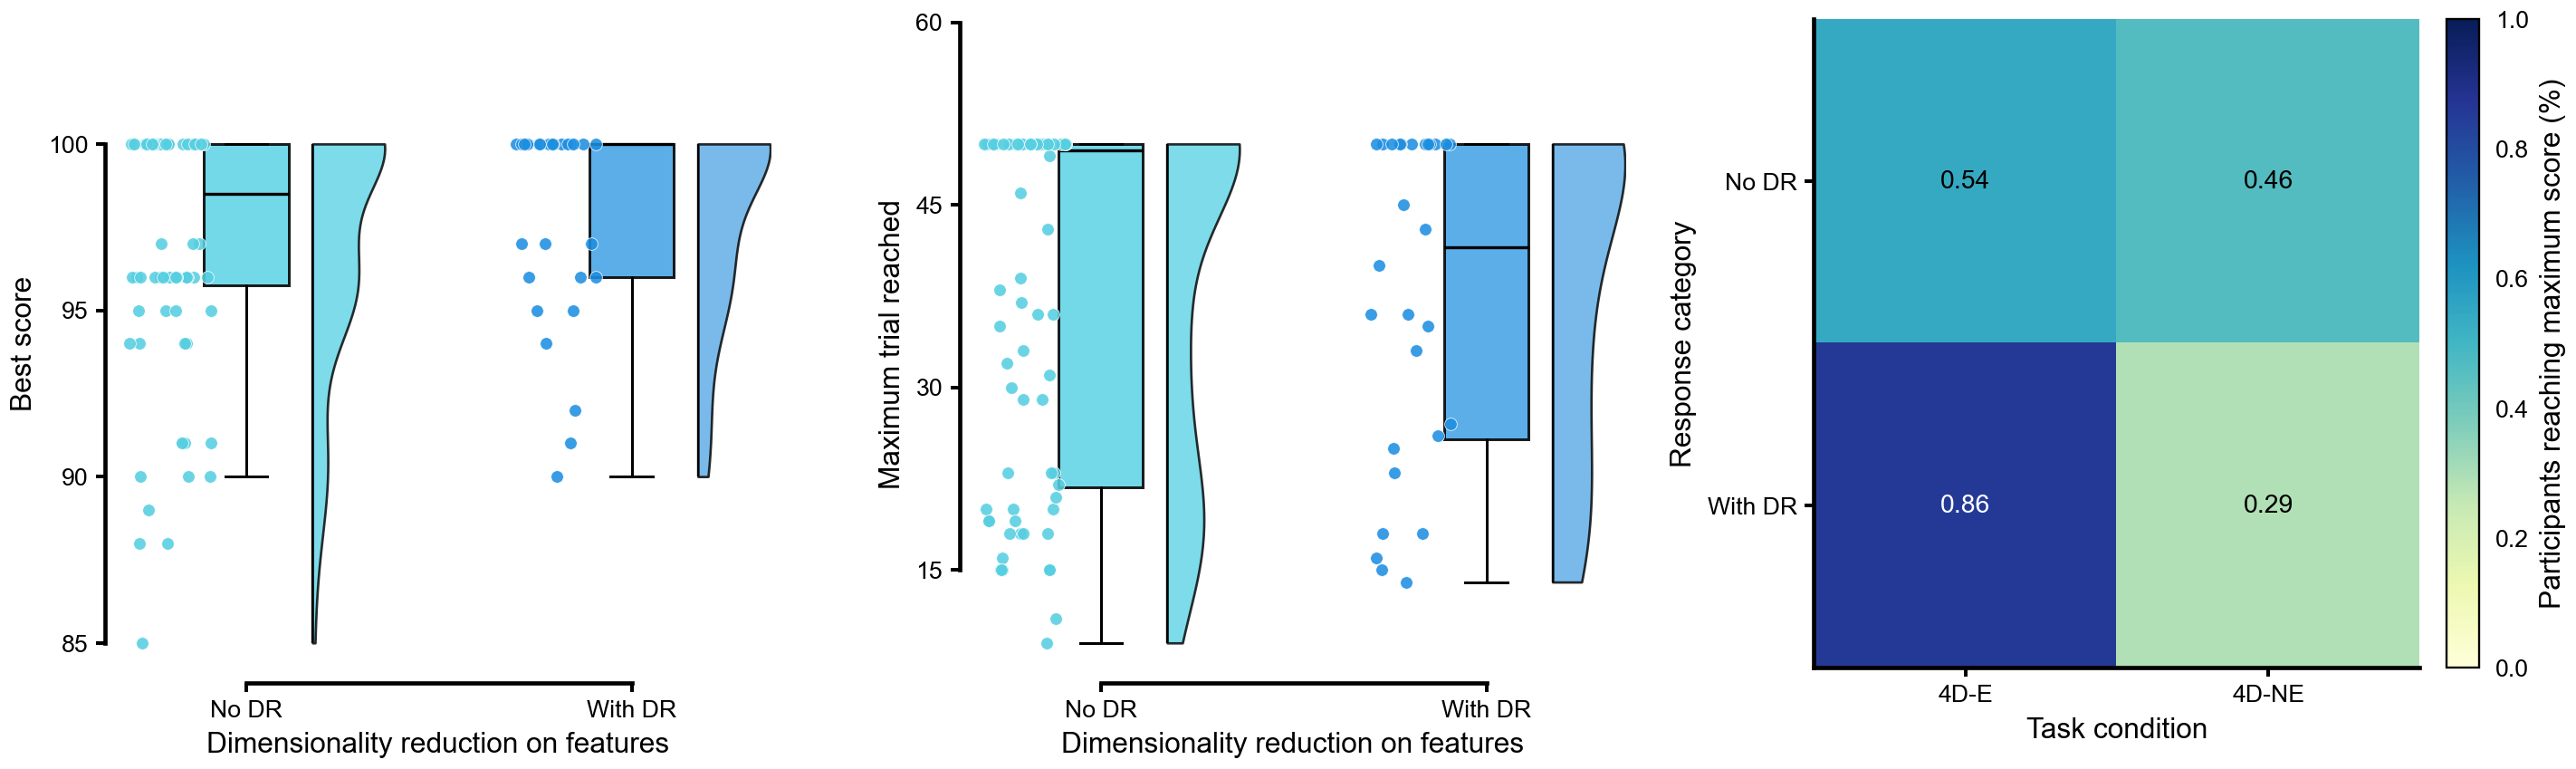


=== DR_on_features | Trimmed Mann–Whitney U ===
Best score, 0 vs 1: p = 0.2877
Max round,  0 vs 1: p = 0.9063


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FixedLocator, MaxNLocator
from pathlib import Path
from scipy.stats import mannwhitneyu, spearmanr

# =========================
# 0) 配置
# =========================
subject_col = "subject"
phase_col = "phase"
score_col = "score"
round_col = "round"

phases_keep = ["P2", "P2-only"]
phase_display_map = {
    "P2": "4D-E",
    "P2-only": "4D-NE",
}
phase_order = ["P2", "P2-only"]
phase_order_display = ["4D-E", "4D-NE"]

phase_colors = TASK1_COLORS.copy()
phase_display_colors = {
    "4D-E": phase_colors["P2"],
    "4D-NE": phase_colors["P2-only"]
}

# 这次关注的是 DR 相关 binary 指标
binary_text_metrics = [
    "DR_on_dimensions",
    "DR_on_features",
]

continuous_text_metrics = []

perfect_score = None

# =========================
# 标签
# =========================
metric_label_map = {
    "DR_on_dimensions": "Dimensionality reduction on dimensions",
    "DR_on_features": "Dimensionality reduction on features",
    "best_score": "Best score",
    "max_round": "Max round reached",
    "is_perfect": "Full score rate",
}

binary_level_label_map = {
    "DR_on_dimensions": {
        0: "No DR",
        1: "With DR",
    },
    "DR_on_features": {
        0: "No DR",
        1: "With DR",
    }
}

triple_level_label_map = {
    0: "None (0)",
    1: "Partial (0–1)",
    2: "Perfect (1)"
}

# =========================
# 全局风格
# =========================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["axes.grid"] = False

LABEL_FONTSIZE = 22
TICK_FONTSIZE = 19
TITLE_FONTSIZE = 22
SPINE_WIDTH = 2.4
TICK_WIDTH = 2.0
TICK_LENGTH = 7

# =========================
# 1) 数据准备
# =========================
df = merged_df.copy()
df = df[df[phase_col].isin(phases_keep)].copy()

df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
df[round_col] = pd.to_numeric(df[round_col], errors="coerce")

if perfect_score is None:
    perfect_score = df[score_col].max()

print(f"使用的满分值 perfect_score = {perfect_score}")

# =========================
# 2) subject × phase 汇总
# =========================
def summarize_subject_phase(group):
    g = group.copy().sort_values(by=[round_col], na_position="last")

    best_score = g[score_col].max()

    best_rows = g[g[score_col] == best_score].copy().sort_values(by=[round_col], na_position="last")
    best_round_first_hit = best_rows[round_col].iloc[0] if len(best_rows) > 0 else np.nan

    is_perfect = 1 if pd.notna(best_score) and best_score == perfect_score else 0
    max_round = g[round_col].max()

    return pd.Series({
        "best_score": best_score,
        "is_perfect": is_perfect,
        "best_round_first_hit": best_round_first_hit,
        "max_round": max_round,
        "n_trials_in_phase": len(g),
    })

behavior_summary = (
    df.groupby([subject_col, phase_col], dropna=False)
      .apply(summarize_subject_phase)
      .reset_index()
)

behavior_summary["phase_display"] = behavior_summary[phase_col].map(phase_display_map)

# =========================
# 3) subject-level 文本指标
# =========================
text_metric_cols = binary_text_metrics + continuous_text_metrics

def first_nonempty(series):
    for x in series:
        if pd.notna(x) and str(x).strip() != "":
            return x
    return np.nan

subject_text_summary = (
    merged_df.groupby(subject_col, dropna=False)
    .agg({col: first_nonempty for col in text_metric_cols if col in merged_df.columns})
    .reset_index()
)

for col in binary_text_metrics:
    if col in subject_text_summary.columns:
        subject_text_summary[col] = pd.to_numeric(subject_text_summary[col], errors="coerce")
        subject_text_summary[col] = subject_text_summary[col].apply(
            lambda x: np.nan if pd.isna(x) else (1 if x >= 1 else 0)
        )

for col in continuous_text_metrics:
    if col in subject_text_summary.columns:
        subject_text_summary[col] = pd.to_numeric(subject_text_summary[col], errors="coerce")

# =========================
# 4) 合并
# =========================
analysis_df = behavior_summary.merge(
    subject_text_summary,
    on=subject_col,
    how="left"
)

# =========================
# 5) 工具函数
# =========================
def lighten_color(color, amount=0.20):
    rgb = mcolors.to_rgb(color)
    return tuple((1 - amount) * c + amount for c in rgb)

def p_to_star(p):
    if pd.isna(p):
        return None
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return None

def trim_5_percent_each_tail(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) < 6:
        return x.values
    lo = x.quantile(0.05)
    hi = x.quantile(0.95)
    return x[(x >= lo) & (x <= hi)].values

def mannwhitney_between_groups_trimmed(plot_df, group_col, value_col, group_a, group_b):
    tmp = plot_df[[group_col, value_col]].dropna().copy()
    g1 = tmp.loc[tmp[group_col] == group_a, value_col].dropna()
    g2 = tmp.loc[tmp[group_col] == group_b, value_col].dropna()

    g1_trim = trim_5_percent_each_tail(g1)
    g2_trim = trim_5_percent_each_tail(g2)

    if len(g1_trim) == 0 or len(g2_trim) == 0:
        return np.nan

    try:
        _, p = mannwhitneyu(g1_trim, g2_trim, alternative="two-sided")
        return p
    except Exception:
        return np.nan

def pairwise_mwu_three_groups_trimmed(plot_df, group_col, value_col):
    pairs = [(0, 1), (0, 2), (1, 2)]
    results = {}
    for a, b in pairs:
        p = mannwhitney_between_groups_trimmed(plot_df, group_col, value_col, a, b)
        results[(a, b)] = p
    return results

def spearman_xy(df, x_col, y_col):
    tmp = df[[x_col, y_col]].dropna().copy()
    if len(tmp) < 3:
        return np.nan, np.nan
    try:
        rho, p = spearmanr(tmp[x_col], tmp[y_col])
        return rho, p
    except Exception:
        return np.nan, np.nan

def style_axis_like_example(ax, xlabel, ylabel, xtick_positions=None, xtick_labels=None,
                            y_ticks=None, y_lim=None, x_lim=None,
                            left_bound=None, bottom_bound=None):
    ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE)
    ax.set_title("")
    ax.grid(False)

    if xtick_positions is not None:
        ax.set_xticks(xtick_positions)
    if xtick_labels is not None:
        ax.set_xticklabels(xtick_labels, fontsize=TICK_FONTSIZE)

    if y_ticks is not None:
        ax.yaxis.set_major_locator(FixedLocator(y_ticks))
    else:
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    if y_lim is not None:
        ax.set_ylim(*y_lim)
    if x_lim is not None:
        ax.set_xlim(*x_lim)

    ax.yaxis.set_ticks_position('left')
    ax.tick_params(
        axis='y',
        labelsize=TICK_FONTSIZE,
        direction='out',
        left=True,
        right=False,
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        pad=5
    )

    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(
        axis='x',
        labelsize=TICK_FONTSIZE,
        direction='out',
        bottom=True,
        top=False,
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        pad=12
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(SPINE_WIDTH)
    ax.spines['bottom'].set_linewidth(SPINE_WIDTH)

    if left_bound is not None:
        ax.spines['left'].set_bounds(left_bound[0], left_bound[1])

    ax.spines['bottom'].set_position(('outward', 10))
    if bottom_bound is not None:
        ax.spines['bottom'].set_bounds(bottom_bound[0], bottom_bound[1])

def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.8, c='black', clip_on=False)
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom', fontsize=17)

def draw_grouped_scatter_box_halfviolin(ax, values_by_group, group_labels, group_colors,
                                        ylabel, xlabel, pairwise_pvals=None, y_ticks=None, y_lim=None, **kwargs):
    n_group = len(group_labels)

    group_centers = np.arange(n_group) * 1.28 + 1.0
    scatter_positions = group_centers - 0.25
    box_positions = group_centers
    violin_positions = group_centers + 0.22

    rng = np.random.default_rng(42)

    # ---------- scatter ----------
    for i, values in enumerate(values_by_group):
        if len(values) == 0:
            continue
        jitter = rng.uniform(-0.14, 0.14, size=len(values))
        ax.scatter(
            np.full(len(values), scatter_positions[i]) + jitter,
            values,
            s=68,
            alpha=0.88,
            c=group_colors[i],
            edgecolors='white',
            linewidths=0.5,
            zorder=4
        )

    # ---------- box ----------
    box = ax.boxplot(
        values_by_group,
        positions=box_positions,
        widths=0.28,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=2.0),
        whiskerprops=dict(color='black', linewidth=1.8),
        capprops=dict(color='black', linewidth=1.8),
        boxprops=dict(edgecolor='black', linewidth=1.8)
    )

    for patch, color in zip(box['boxes'], group_colors):
        patch.set_facecolor(lighten_color(color, amount=0.18))
        patch.set_alpha(0.80)

    # ---------- violin ----------
    violins = ax.violinplot(
        values_by_group,
        positions=violin_positions,
        widths=0.48,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    for i, body in enumerate(violins['bodies']):
        color = group_colors[i]
        body.set_facecolor(lighten_color(color, amount=0.28))
        body.set_edgecolor('black')
        body.set_linewidth(1.6)
        body.set_alpha(0.45)

        path = body.get_paths()[0]
        vertices = path.vertices
        center = violin_positions[i]
        vertices[:, 0] = np.maximum(vertices[:, 0], center)

    # center line
    for pos, values in zip(violin_positions, values_by_group):
        if len(values) > 0:
            ax.vlines(
                pos,
                np.min(values),
                np.max(values),
                color='black',
                linewidth=1.4,
                zorder=2
            )

    left_lim = scatter_positions[0] - 0.22
    right_lim = violin_positions[-1] + 0.24

    if y_lim is None:
        nonempty = [v for v in values_by_group if len(v) > 0]
        all_values = np.concatenate(nonempty) if len(nonempty) > 0 else np.array([0, 1])
        y_min = np.nanmin(all_values)
        y_max = np.nanmax(all_values)
        if y_min == y_max:
            pad = 1
        else:
            pad = (y_max - y_min) * 0.25
        y_lim = (y_min - pad * 0.20, y_max + pad)

    style_axis_like_example(
        ax=ax,
        xlabel=xlabel,
        ylabel=ylabel,
        xtick_positions=group_centers,
        xtick_labels=group_labels,
        y_ticks=y_ticks,
        y_lim=y_lim,
        x_lim=(left_lim, right_lim),
        left_bound=(y_lim[0], y_lim[1] * 0.96 if y_lim[1] > 0 else y_lim[1]),
        bottom_bound=(group_centers[0], group_centers[-1])
    )

    # ---------- significance bars ----------
    if pairwise_pvals is not None:
        valid_pairs = []
        for pair, p in pairwise_pvals.items():
            a, b = pair
            if a < n_group and b < n_group:
                valid_pairs.append((pair, p))

        sig_pairs = []
        for pair, p in valid_pairs:
            star = p_to_star(p)
            if star is not None:
                sig_pairs.append((pair, p, star))

        if len(sig_pairs) > 0:
            y0, y1 = ax.get_ylim()
            h = (y1 - y0) * 0.035
            base_y = y1 - (y1 - y0) * 0.13
            level_step = (y1 - y0) * 0.08

            for idx, (pair, p, star) in enumerate(sig_pairs):
                a, b = pair
                x1, x2 = box_positions[a], box_positions[b]
                y = base_y + idx * level_step
                add_sig_bar(ax, x1, x2, y, h, star)

def draw_professional_heatmap(ax, rate_matrix, x_labels, y_labels, colorbar_label):
    im = ax.imshow(rate_matrix, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")

    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels, fontsize=TICK_FONTSIZE)
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=TICK_FONTSIZE)

    ax.set_xlabel("Phase", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel("Response category", fontsize=LABEL_FONTSIZE)
    ax.set_title("", fontsize=TITLE_FONTSIZE)

    for i in range(rate_matrix.shape[0]):
        for j in range(rate_matrix.shape[1]):
            val = rate_matrix[i, j]
            if pd.notna(val):
                txt_color = "white" if val >= 0.55 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=17, color=txt_color)

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(SPINE_WIDTH)
    ax.spines['bottom'].set_linewidth(SPINE_WIDTH)

    ax.tick_params(
        axis='both',
        labelsize=TICK_FONTSIZE,
        direction='out',
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        pad=6
    )

    cbar = plt.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
    cbar.set_label(colorbar_label, fontsize=18)
    cbar.ax.tick_params(labelsize=16, width=1.6, length=5)
    cbar.outline.set_linewidth(1.4)

# =========================
# 6) 二分类指标：两个分布图 + heatmap
# =========================
def plot_binary_metric_full(data, metric_col, save_dir):
    plot_df = data.copy()
    plot_df = plot_df[plot_df["phase_display"].isin(phase_order_display)].copy()
    plot_df = plot_df[plot_df[metric_col].isin([0, 1])].copy()

    if len(plot_df) == 0:
        print(f"[跳过] {metric_col}: 没有有效 0/1 数据")
        return

    metric_levels = binary_level_label_map.get(metric_col, {0: "Group 0", 1: "Group 1"})
    group_labels = [metric_levels[0], metric_levels[1]]
    group_colors = SURVEY_COLORS_2.copy()

    best_values_by_group = [
        plot_df.loc[plot_df[metric_col] == 0, "best_score"].dropna().values,
        plot_df.loc[plot_df[metric_col] == 1, "best_score"].dropna().values,
    ]
    p_best = mannwhitney_between_groups_trimmed(plot_df, metric_col, "best_score", 0, 1)

    round_values_by_group = [
        plot_df.loc[plot_df[metric_col] == 0, "max_round"].dropna().values,
        plot_df.loc[plot_df[metric_col] == 1, "max_round"].dropna().values,
    ]
    p_round = mannwhitney_between_groups_trimmed(plot_df, metric_col, "max_round", 0, 1)

    rate_df = (
        plot_df.groupby([metric_col, "phase_display"], dropna=False)["is_perfect"]
        .mean()
        .reset_index()
    )

    heat_df = (
        rate_df.assign(response_category=lambda d: d[metric_col].map(metric_levels))
        .pivot(index="response_category", columns="phase_display", values="is_perfect")
        .reindex(index=[metric_levels[0], metric_levels[1]], columns=phase_order_display)
    )

    fig, axes = plt.subplots(1, 3, figsize=(24, 7.5))

    draw_grouped_scatter_box_halfviolin(
        ax=axes[0],
        values_by_group=best_values_by_group,
        group_labels=group_labels,
        group_colors=group_colors,
        ylabel="Best score",
        xlabel=metric_label_map[metric_col],
        pairwise_pvals={(0, 1): p_best}
    )

    draw_grouped_scatter_box_halfviolin(
        ax=axes[1],
        values_by_group=round_values_by_group,
        group_labels=group_labels,
        group_colors=group_colors,
        ylabel="Max round reached",
        xlabel=metric_label_map[metric_col],
        pairwise_pvals={(0, 1): p_round}
    )

    draw_professional_heatmap(
        ax=axes[2],
        rate_matrix=heat_df.values.astype(float),
        x_labels=phase_order_display,
        y_labels=list(heat_df.index),
        colorbar_label="Full score rate"
    )

    plt.tight_layout()

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    filename = f"{metric_col}_bestscore_maxround_fullscorerate.png"
    out = save_dir / filename
    style_figure(fig)
    save_figure(fig, out, dpi=300, bbox_inches='tight')
    print(f"Saved figure to: {out.resolve()}")

    style_figure(plt.gcf())
    plt.show()

    print(f"\n=== {metric_col} | Trimmed Mann–Whitney U ===")
    print(f"Best score, 0 vs 1: p = {p_best:.4g}" if pd.notna(p_best) else "Best score, 0 vs 1: p = NaN")
    print(f"Max round,  0 vs 1: p = {p_round:.4g}" if pd.notna(p_round) else "Max round,  0 vs 1: p = NaN")

# =========================
# 7) 执行绘图
# =========================
save_dir = "figures_saving_for_layout"

binary_metrics_to_plot = [
    "DR_on_dimensions",
    "DR_on_features",
]

for metric in binary_metrics_to_plot:
    if metric in analysis_df.columns:
        plot_binary_metric_full(analysis_df, metric, save_dir=save_dir)
    else:
        print(f"[缺少列] {metric}")

# 可选保存分析表
# analysis_df.to_csv("subject_phase_behavior_DR_analysis_refined_style.csv", index=False)

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_dimensions_by_DR_on_features_fullscorerate_heatmap.png


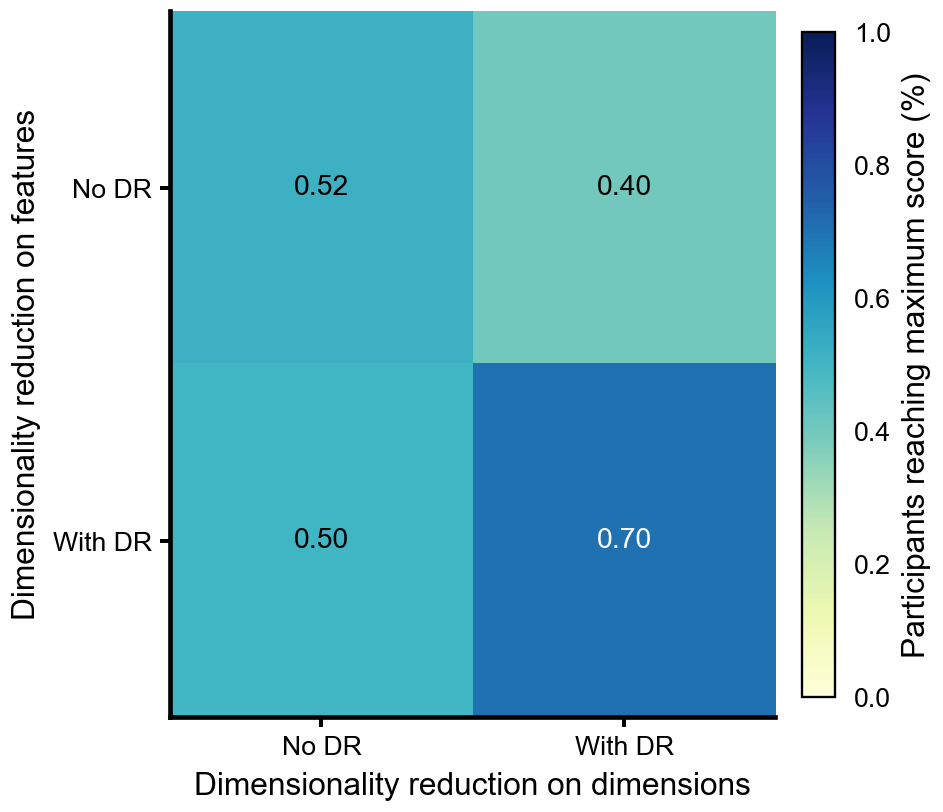


=== Dimension DR × Feature DR | Full score rate heatmap ===
DR_on_dimensions         0    1
DR_on_features                 
0                 0.515152  0.4
1                 0.500000  0.7


In [14]:
# =========================
# 额外图：Dimension DR × Feature DR 的满分率 heatmap
# =========================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

save_dir = "figures_saving_for_layout"

def plot_dr_cross_fullscore_heatmap(data, save_dir):
    plot_df = data.copy()

    needed_cols = ["DR_on_dimensions", "DR_on_features", "is_perfect"]
    missing_cols = [c for c in needed_cols if c not in plot_df.columns]
    if len(missing_cols) > 0:
        print(f"[缺少列] {missing_cols}")
        return

    plot_df = plot_df.dropna(subset=["DR_on_dimensions", "DR_on_features", "is_perfect"]).copy()
    plot_df = plot_df[
        plot_df["DR_on_dimensions"].isin([0, 1]) &
        plot_df["DR_on_features"].isin([0, 1])
    ].copy()

    if len(plot_df) == 0:
        print("[跳过] DR 交叉热图：没有有效 0/1 数据")
        return

    heat_df = (
        plot_df.groupby(["DR_on_features", "DR_on_dimensions"], dropna=False)["is_perfect"]
        .mean()
        .unstack("DR_on_dimensions")
        .reindex(index=[0, 1], columns=[0, 1])
    )

    rate_matrix = heat_df.values.astype(float)

    x_labels = ["No DR", "With DR"]
    y_labels = ["No DR", "With DR"]

    fig, ax = plt.subplots(1, 1, figsize=(8.2, 7.2))

    im = ax.imshow(rate_matrix, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")

    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels, fontsize=TICK_FONTSIZE)
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=TICK_FONTSIZE)

    ax.set_xlabel("Dimensionality reduction on dimensions", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel("Dimensionality reduction on features", fontsize=LABEL_FONTSIZE)
    ax.set_title("", fontsize=TITLE_FONTSIZE)

    for i in range(rate_matrix.shape[0]):
        for j in range(rate_matrix.shape[1]):
            val = rate_matrix[i, j]
            if pd.notna(val):
                txt_color = "white" if val >= 0.55 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=17, color=txt_color)
            else:
                ax.text(j, i, "NA", ha="center", va="center", fontsize=17, color="black")

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(SPINE_WIDTH)
    ax.spines['bottom'].set_linewidth(SPINE_WIDTH)

    ax.tick_params(
        axis='both',
        labelsize=TICK_FONTSIZE,
        direction='out',
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        pad=6
    )

    cbar = plt.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
    cbar.set_label("Full score rate", fontsize=18)
    cbar.ax.tick_params(labelsize=16, width=1.6, length=5)
    cbar.outline.set_linewidth(1.4)

    plt.tight_layout()

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    out = save_dir / "DR_on_dimensions_by_DR_on_features_fullscorerate_heatmap.png"
    style_figure(fig)
    save_figure(fig, out, dpi=300, bbox_inches="tight")
    print(f"Saved figure to: {out.resolve()}")

    style_figure(plt.gcf())
    plt.show()

    print("\n=== Dimension DR × Feature DR | Full score rate heatmap ===")
    print(heat_df)

plot_dr_cross_fullscore_heatmap(analysis_df, save_dir=save_dir)

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_dimensions_by_DR_on_features_subject_proportion_heatmap.png


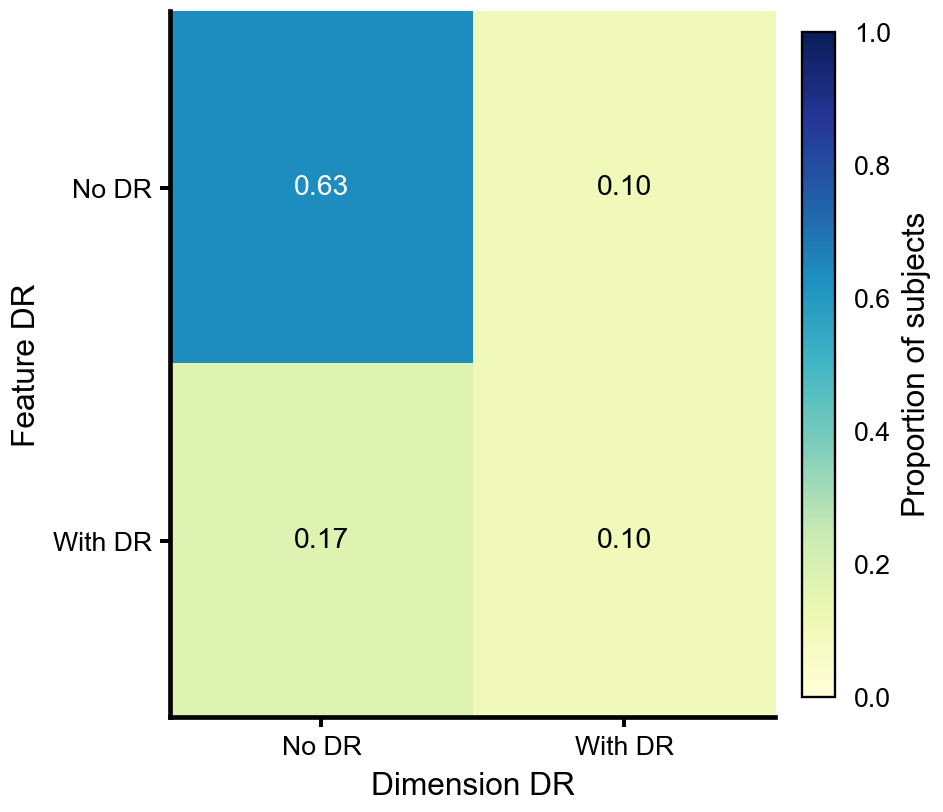


=== Dimension DR × Feature DR | Subject proportion heatmap ===
Counts:
DR_on_dimensions   0   1
DR_on_features          
0                 66  10
1                 18  10

Proportions:
DR_on_dimensions         0         1
DR_on_features                      
0                 0.634615  0.096154
1                 0.173077  0.096154


In [15]:
# =========================
# 额外图：Dimension DR × Feature DR 的被试总体占比 heatmap
# =========================
save_dir = "figures_saving_for_layout"

def plot_dr_cross_subject_proportion_heatmap(data, save_dir):
    plot_df = data.copy()

    needed_cols = ["DR_on_dimensions", "DR_on_features"]
    missing_cols = [c for c in needed_cols if c not in plot_df.columns]
    if len(missing_cols) > 0:
        print(f"[缺少列] {missing_cols}")
        return

    plot_df = plot_df.dropna(subset=["DR_on_dimensions", "DR_on_features"]).copy()
    plot_df = plot_df[
        plot_df["DR_on_dimensions"].isin([0, 1]) &
        plot_df["DR_on_features"].isin([0, 1])
    ].copy()

    if len(plot_df) == 0:
        print("[跳过] DR 交叉占比热图：没有有效 0/1 数据")
        return

    # 每个格子的人数
    count_df = (
        plot_df.groupby(["DR_on_features", "DR_on_dimensions"], dropna=False)
        .size()
        .unstack("DR_on_dimensions")
        .reindex(index=[0, 1], columns=[0, 1])
        .fillna(0)
    )

    total_n = count_df.values.sum()
    if total_n == 0:
        print("[跳过] DR 交叉占比热图：总人数为 0")
        return

    prop_df = count_df / total_n

    fig, ax = plt.subplots(1, 1, figsize=(8.2, 7.2))

    draw_professional_heatmap(
        ax=ax,
        rate_matrix=prop_df.values.astype(float),
        x_labels=["No DR", "With DR"],
        y_labels=["No DR", "With DR"],
        colorbar_label="Proportion of subjects"
    )

    ax.set_xlabel("Dimension DR", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel("Feature DR", fontsize=LABEL_FONTSIZE)

    plt.tight_layout()

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    out = save_dir / "DR_on_dimensions_by_DR_on_features_subject_proportion_heatmap.png"
    style_figure(fig)
    save_figure(fig, out, dpi=300, bbox_inches="tight")
    print(f"Saved figure to: {out.resolve()}")

    style_figure(plt.gcf())
    plt.show()

    print("\n=== Dimension DR × Feature DR | Subject proportion heatmap ===")
    print("Counts:")
    print(count_df)
    print("\nProportions:")
    print(prop_df)

plot_dr_cross_subject_proportion_heatmap(analysis_df, save_dir=save_dir)

## DIS metrics under different DR conditions

In [16]:
dr_subject_df = (
    analysis_df[[subject_col, "DR_on_dimensions", "DR_on_features"]]
    .drop_duplicates(subset=[subject_col])
    .copy()
)

analysis_fds_df = analysis_fds_df.merge(
    dr_subject_df,
    on=subject_col,
    how="left"
)

print("analysis_fds_df shape after merging DR:", analysis_fds_df.shape)
display(analysis_fds_df.head())

analysis_fds_df shape after merging DR: (105, 17)


,subject,phase,FDS_n,FDS_ratio,FDS_dimensions,FDS_counts_per_dms,FDS_patterns_per_dms,max_round,n_trials_in_phase,phase_display,4D_dimensions_recognized,4D_features_relevant_answer,4D_dimensions_relevant_answer_strict,4D_dimensions_relevant_answer_F1,4D_dimensions_relevant_answer_hit_minus_false,DR_on_dimensions,DR_on_features
0,2024101801,P2-only,12.0,0.480000,4.0,3.00,2.50,25.0,25.0,4D-NE,1.0,0.0,1,1.0,1.0,0.0,1.0
1,2024101803,P2-only,6.0,0.120000,3.0,2.00,1.00,50.0,50.0,4D-NE,1.0,0.0,0,0.8,0.5,0.0,0.0
2,2024102201,P2,13.0,0.722222,4.0,3.25,3.25,18.0,18.0,4D-E,1.0,1.0,1,1.0,1.0,1.0,0.0
3,2024102202,P2,20.0,0.465116,4.0,5.00,3.50,43.0,43.0,4D-E,1.0,1.0,1,1.0,1.0,0.0,1.0
4,2024102203,P2,8.0,0.727273,4.0,2.00,2.00,11.0,11.0,4D-E,1.0,1.0,0,0.4,0.0,0.0,0.0


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_dimensions_FDS_ratio_purple_white_narrow.png


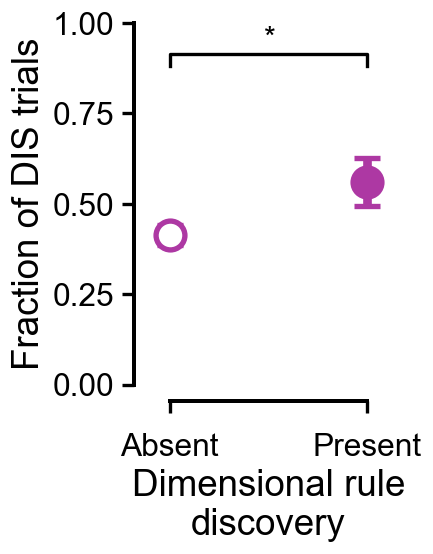

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_dimensions_FDS_dimensions_purple_white_narrow.png


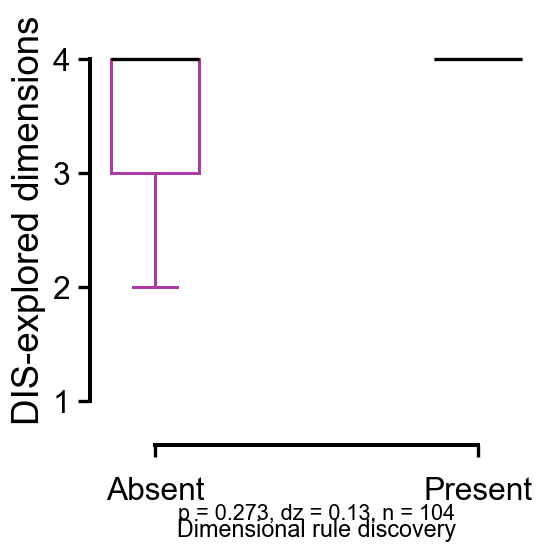

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_dimensions_FDS_counts_per_dms_purple_white_narrow.png


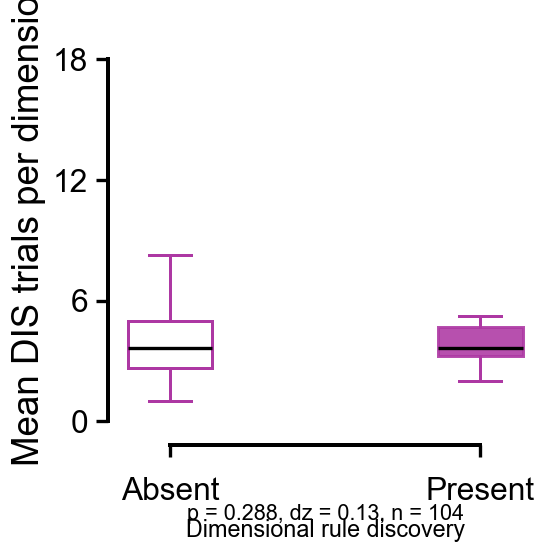

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_dimensions_FDS_patterns_per_dms_purple_white_narrow.png


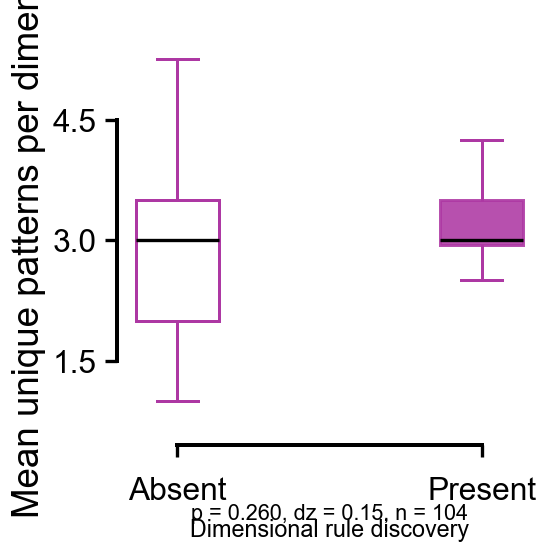

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_features_FDS_ratio_purple_white_narrow.png


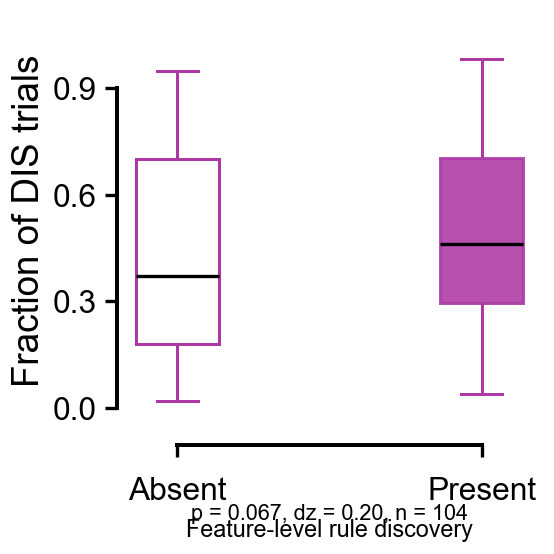

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_features_FDS_dimensions_purple_white_narrow.png


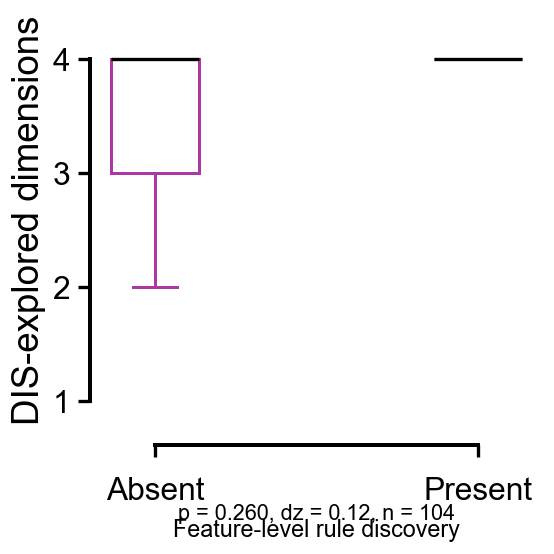

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_features_FDS_counts_per_dms_purple_white_narrow.png


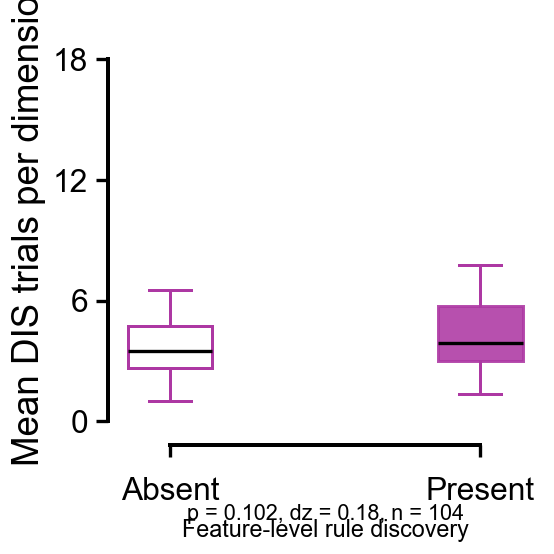

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_features_FDS_patterns_per_dms_purple_white_narrow.png


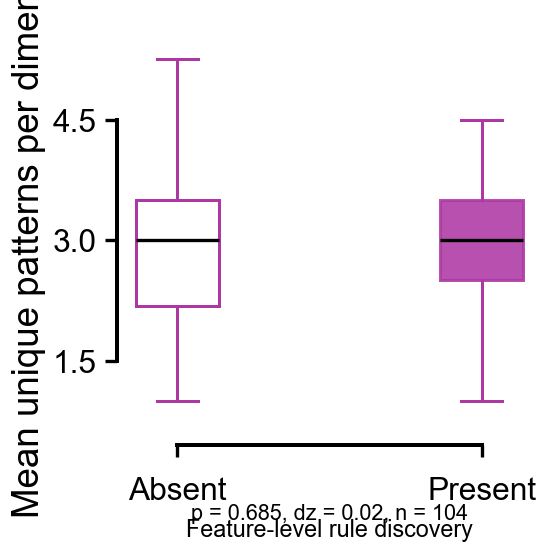

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# =========================
# effect size helpers
# =========================
def mannwhitney_effect_size_rbc(x, y):
    x = pd.Series(x).dropna().to_numpy()
    y = pd.Series(y).dropna().to_numpy()

    n1, n2 = len(x), len(y)
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan, n1, n2

    u_stat, _ = mannwhitneyu(x, y, alternative="two-sided")
    r_rb = 1 - (2 * u_stat) / (n1 * n2)
    return r_rb, u_stat, n1, n2


def interpret_rbc(r):
    if pd.isna(r):
        return "NaN"
    ar = abs(r)
    if ar < 0.10:
        return "negligible"
    elif ar < 0.30:
        return "small"
    elif ar < 0.50:
        return "medium"
    else:
        return "large"


PURPLE = "#AD38A3"
WHITE = "#FFFFFF"

# =========================
# DR metric labels
# =========================
dr_metric_label_map = {
    "DR_on_dimensions": "Dimensional rule discovery",
    "DR_on_features": "Feature-level rule discovery",
}

dr_binary_level_label_map = {
    "DR_on_dimensions": {0: "Absent", 1: "Present"},
    "DR_on_features": {0: "Absent", 1: "Present"},
}

# =========================
# DIS metric labels
# =========================
fds_metric_label_map = {
    "FDS_ratio": "Fraction of DIS trials",
    "FDS_dimensions": "DIS-explored dimensions",
    "FDS_counts_per_dms": "Mean DIS trials per dimension",
    "FDS_patterns_per_dms": "Mean unique patterns per dimension",
}

fds_metrics_to_plot = [
    "FDS_ratio",
    "FDS_dimensions",
    "FDS_counts_per_dms",
    "FDS_patterns_per_dms",
]


def p_to_stars_local(p):
    if pd.isna(p):
        return None
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return None


def add_sig_bar_local(ax, x1, x2, y, h, text, lw=2.0, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=lw, c='black', clip_on=False)
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom', fontsize=fs, color='black')


def draw_grouped_box_no_violin(ax, values_by_group, group_labels, group_colors,
                               ylabel, xlabel, pairwise_stats=None, y_ticks=None, y_lim=None):
    n_group = len(group_labels)
    group_centers = np.arange(n_group) * 1.10 + 1.0

    box = ax.boxplot(
        values_by_group,
        positions=group_centers,
        widths=0.30,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=2.0),
        whiskerprops=dict(color=PURPLE, linewidth=1.8),
        capprops=dict(color=PURPLE, linewidth=1.8),
        boxprops=dict(edgecolor=PURPLE, linewidth=1.8)
    )

    for i, patch in enumerate(box['boxes']):
        patch.set_facecolor(group_colors[i])
        patch.set_alpha(1.0 if group_colors[i] == WHITE else 0.88)
        if group_colors[i] == WHITE:
            patch.set_edgecolor(PURPLE)

    if y_lim is None:
        nonempty = [v for v in values_by_group if len(v) > 0]
        all_values = np.concatenate(nonempty) if len(nonempty) > 0 else np.array([0, 1])
        y_min = np.nanmin(all_values)
        y_max = np.nanmax(all_values)
        if y_min == y_max:
            pad_low, pad_high = 0.5, 0.8
        else:
            span = y_max - y_min
            pad_low, pad_high = span * 0.08, span * 0.14
        y_lim = (y_min - pad_low, y_max + pad_high)

    style_axis_like_example(
        ax=ax,
        xlabel=xlabel,
        ylabel=ylabel,
        xtick_positions=group_centers,
        xtick_labels=group_labels,
        y_ticks=y_ticks,
        y_lim=y_lim,
        x_lim=(group_centers[0] - 0.22, group_centers[-1] + 0.22),
        left_bound=None,
        bottom_bound=(group_centers[0], group_centers[-1])
    )
    ax.set_xlabel(xlabel, fontsize=14, labelpad=8)

    valid_y = [t for t in ax.get_yticks() if y_lim[0] <= t <= y_lim[1]]
    if len(valid_y) >= 2:
        ax.spines['left'].set_bounds(valid_y[0], valid_y[-1])

    if pairwise_stats is not None:
        sig_pairs = []
        for pair, stat in pairwise_stats.items():
            a, b = pair
            if a < n_group and b < n_group:
                p = stat["p"] if isinstance(stat, dict) else stat
                star = p_to_stars_local(p)
                if star is not None:
                    sig_pairs.append((pair, star))

        if len(sig_pairs) > 0:
            y0, y1 = ax.get_ylim()
            h = (y1 - y0) * 0.03
            base_y = y1 - (y1 - y0) * 0.11
            level_step = (y1 - y0) * 0.06

            for idx, (pair, star) in enumerate(sig_pairs):
                a, b = pair
                x1, x2 = group_centers[a], group_centers[b]
                y = base_y + idx * level_step
                add_sig_bar_local(ax, x1, x2, y, h, star, lw=2.0, fs=18)


def draw_grouped_mean_error_narrow(ax, values_by_group, group_labels, group_colors,
                                   ylabel, xlabel, pairwise_pval=None, y_ticks=None, y_lim=None):
    n_group = len(group_labels)
    group_centers = np.arange(n_group) * 0.78 + 1.0

    means = [float(np.mean(v)) if len(v) > 0 else np.nan for v in values_by_group]
    sems = [float(pd.Series(v).sem()) if len(v) > 1 else 0.0 for v in values_by_group]

    for x, mean, sem, color in zip(group_centers, means, sems, group_colors):
        ax.errorbar(
            x,
            mean,
            yerr=sem,
            fmt='o',
            markersize=17.3,
            color=PURPLE,
            markerfacecolor=color,
            markeredgecolor=PURPLE,
            markeredgewidth=3.2,
            elinewidth=5.2,
            capsize=8,
            capthick=5.2,
            zorder=3,
        )

    if y_lim is None:
        y_lim = (0.0, 1.0)
    if y_ticks is None:
        y_ticks = [0.0, 0.25, 0.50, 0.75, 1.00]

    style_axis_like_example(
        ax=ax,
        xlabel=xlabel,
        ylabel=ylabel,
        xtick_positions=group_centers,
        xtick_labels=group_labels,
        y_ticks=y_ticks,
        y_lim=y_lim,
        x_lim=(group_centers[0] - 0.14, group_centers[-1] + 0.14),
        left_bound=(y_ticks[0], y_ticks[-1]),
        bottom_bound=(group_centers[0], group_centers[-1])
    )
    if pairwise_pval is not None:
        star = p_to_stars_local(pairwise_pval)
        if star is not None:
            y0, y1 = y_lim
            span = y1 - y0
            h = span * 0.035
            y = y1 - span * 0.12
            add_sig_bar_local(ax, group_centers[0], group_centers[1], y, h, star, lw=2.0, fs=18)


# =========================
# binary DR metric x DIS metric
# =========================
def plot_binary_dr_with_fds(data, dr_metric_col, fds_metric_col, save_dir):
    plot_df = data.copy()

    needed_cols = [dr_metric_col, fds_metric_col]
    missing_cols = [c for c in needed_cols if c not in plot_df.columns]
    if len(missing_cols) > 0:
        print(f"[missing columns] {missing_cols}")
        return

    plot_df = plot_df[plot_df[dr_metric_col].isin([0, 1])].copy()
    plot_df = plot_df[pd.notna(plot_df[fds_metric_col])].copy()

    if len(plot_df) == 0:
        print(f"[skip] {dr_metric_col} x {fds_metric_col}: no valid data")
        return

    metric_levels = dr_binary_level_label_map.get(dr_metric_col, {0: "Absent", 1: "Present"})
    group_labels = [metric_levels[0], metric_levels[1]]
    group_colors = [WHITE, PURPLE]

    g0 = plot_df.loc[plot_df[dr_metric_col] == 0, fds_metric_col].dropna().values
    g1 = plot_df.loc[plot_df[dr_metric_col] == 1, fds_metric_col].dropna().values

    values_by_group = [g0, g1]

    p_val = mannwhitney_between_groups_trimmed(plot_df, dr_metric_col, fds_metric_col, 0, 1)
    r_rb, u_stat, n0, n1 = mannwhitney_effect_size_rbc(g0, g1)

    use_mean_error_narrow = (
        dr_metric_col == "DR_on_dimensions" and
        fds_metric_col == "FDS_ratio"
    )

    if use_mean_error_narrow:
        fig, ax = plt.subplots(1, 1, figsize=(3.8, 4.9))
        draw_grouped_mean_error_narrow(
            ax=ax,
            values_by_group=values_by_group,
            group_labels=group_labels,
            group_colors=group_colors,
            ylabel=fds_metric_label_map.get(fds_metric_col, fds_metric_col),
            xlabel="Dimensional rule\ndiscovery",
            pairwise_pval=p_val,
            y_ticks=[0.0, 0.25, 0.50, 0.75, 1.00],
            y_lim=(0.0, 1.0)
        )
    else:
        fig, ax = plt.subplots(1, 1, figsize=(4.9, 4.9))

        draw_grouped_box_no_violin(
            ax=ax,
            values_by_group=values_by_group,
            group_labels=group_labels,
            group_colors=group_colors,
            ylabel=fds_metric_label_map.get(fds_metric_col, fds_metric_col),
            xlabel=dr_metric_label_map.get(dr_metric_col, dr_metric_col),
            pairwise_stats={(0, 1): p_val}
        )

        if pd.notna(p_val) and p_val < 0.001:
            p_text = 'p < .001'
        elif pd.notna(p_val):
            p_text = f'p = {p_val:.3f}'
        else:
            p_text = 'p = NA'

        dz_text = f'{r_rb:.2f}' if pd.notna(r_rb) else 'NA'
        bottom_text = f"{p_text}, dz = {dz_text}, n = {n0 + n1}"
        ax.text(0.5, -0.18, bottom_text, transform=ax.transAxes, ha='center', va='top', fontsize=13, color='black')

    plt.tight_layout()

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    filename = f"{dr_metric_col}_{fds_metric_col}_purple_white_narrow.png"
    out = save_dir / filename
    fig.savefig(out, dpi=300, bbox_inches='tight')
    print(f"Saved figure to: {out.resolve()}")
    plt.show()


# =========================
# execute
# =========================
save_dir = "figures_saving_for_layout"

dr_metrics_to_plot = [
    "DR_on_dimensions",
    "DR_on_features",
]

for dr_metric in dr_metrics_to_plot:
    if dr_metric not in analysis_fds_df.columns:
        print(f"[missing column] {dr_metric}")
        continue

    for fds_metric in fds_metrics_to_plot:
        if fds_metric not in analysis_fds_df.columns:
            print(f"[missing column] {fds_metric}")
            continue

        plot_binary_dr_with_fds(
            analysis_fds_df,
            dr_metric_col=dr_metric,
            fds_metric_col=fds_metric,
            save_dir=save_dir
        )


Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_dimensions_FDS_ratio_purple_white_narrow.png


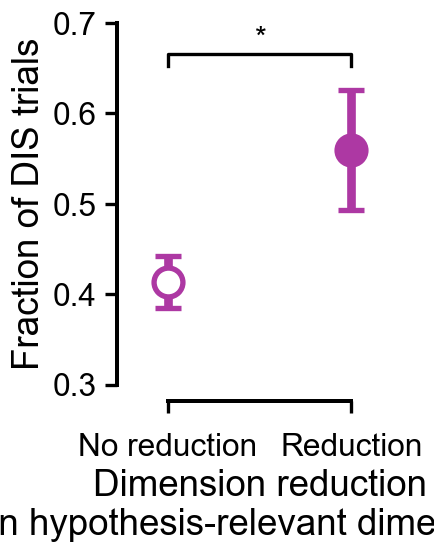

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_dimensions_FDS_dimensions_purple_white_narrow.png


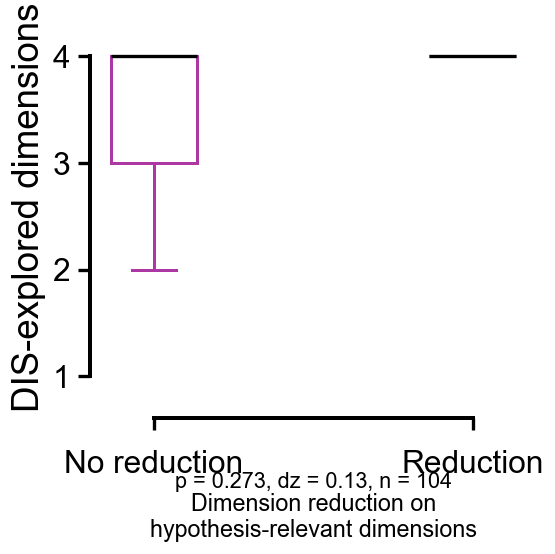

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_dimensions_FDS_counts_per_dms_purple_white_narrow.png


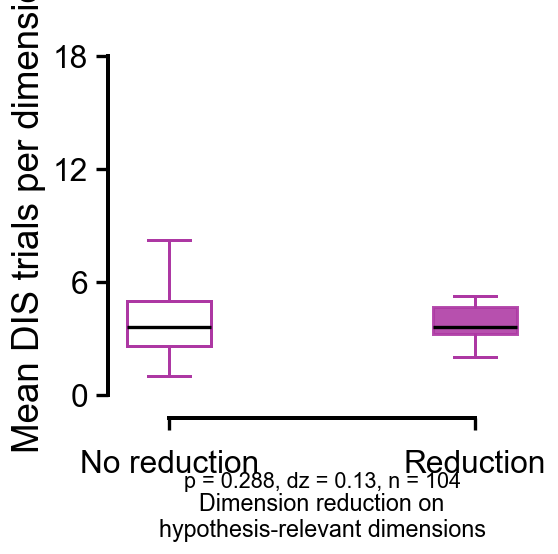

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_dimensions_FDS_patterns_per_dms_purple_white_narrow.png


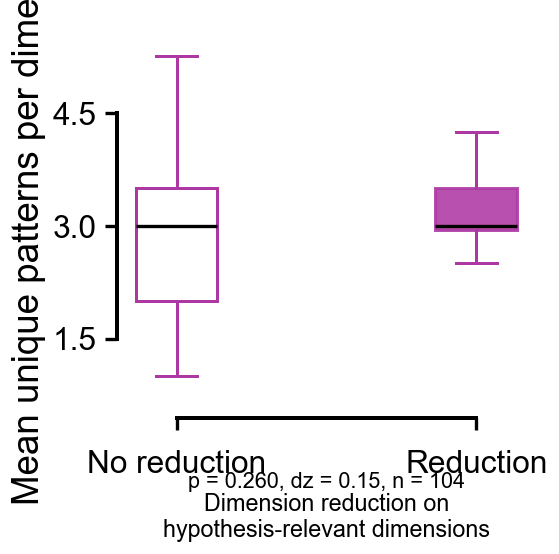

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_features_FDS_ratio_purple_white_narrow.png


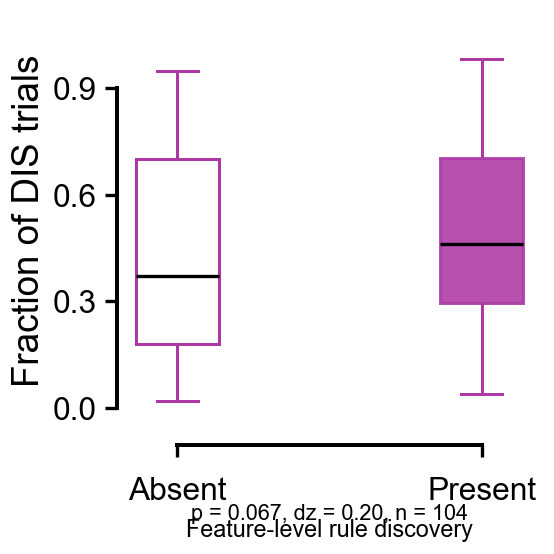

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_features_FDS_dimensions_purple_white_narrow.png


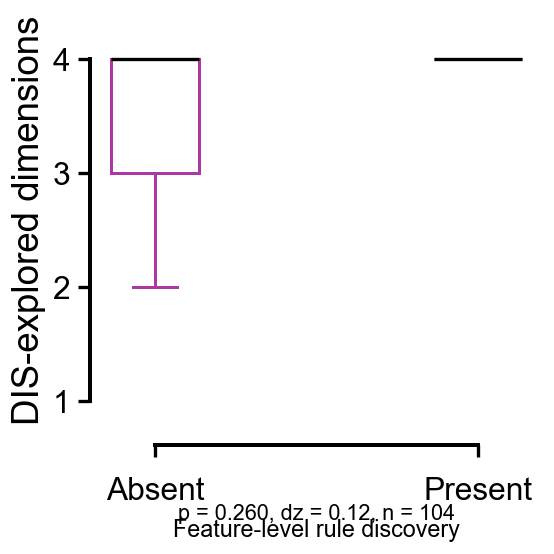

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_features_FDS_counts_per_dms_purple_white_narrow.png


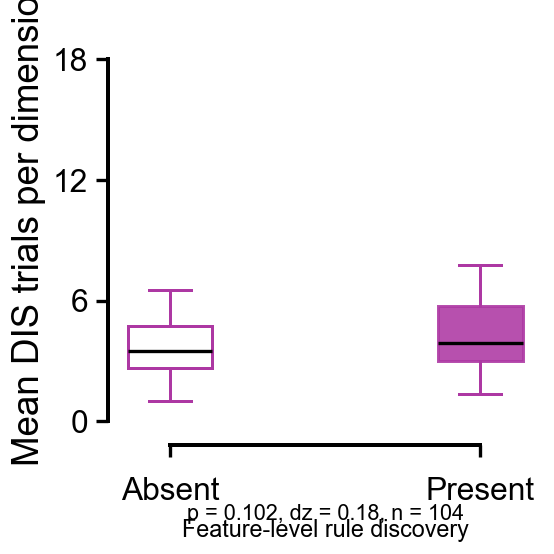

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\DR_on_features_FDS_patterns_per_dms_purple_white_narrow.png


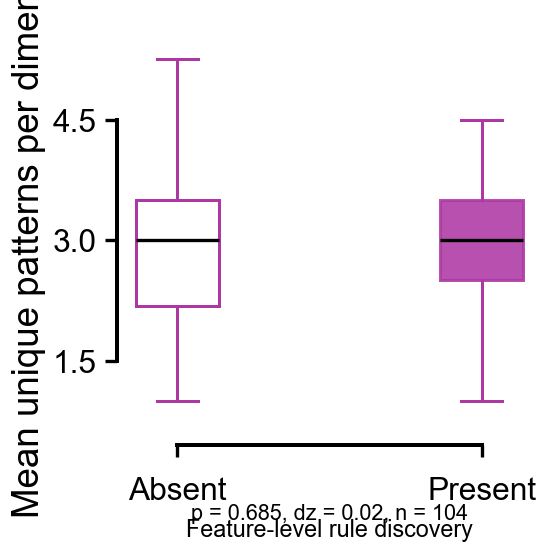

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# =========================
# effect size helpers
# =========================
def mannwhitney_effect_size_rbc(x, y):
    x = pd.Series(x).dropna().to_numpy()
    y = pd.Series(y).dropna().to_numpy()

    n1, n2 = len(x), len(y)
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan, n1, n2

    u_stat, _ = mannwhitneyu(x, y, alternative="two-sided")
    r_rb = 1 - (2 * u_stat) / (n1 * n2)
    return r_rb, u_stat, n1, n2


def interpret_rbc(r):
    if pd.isna(r):
        return "NaN"
    ar = abs(r)
    if ar < 0.10:
        return "negligible"
    elif ar < 0.30:
        return "small"
    elif ar < 0.50:
        return "medium"
    else:
        return "large"


PURPLE = "#AD38A3"
WHITE = "#FFFFFF"

# =========================
# DR metric labels
# =========================
dr_metric_label_map = {
    "DR_on_dimensions": "Dimension reduction on\nhypothesis-relevant dimensions",
    "DR_on_features": "Feature-level rule discovery",
}

dr_binary_level_label_map = {
    "DR_on_dimensions": {0: "No reduction", 1: "Reduction"},
    "DR_on_features": {0: "Absent", 1: "Present"},
}

# =========================
# DIS metric labels
# =========================
fds_metric_label_map = {
    "FDS_ratio": "Fraction of DIS trials",
    "FDS_dimensions": "DIS-explored dimensions",
    "FDS_counts_per_dms": "Mean DIS trials per dimension",
    "FDS_patterns_per_dms": "Mean unique patterns per dimension",
}

fds_metrics_to_plot = [
    "FDS_ratio",
    "FDS_dimensions",
    "FDS_counts_per_dms",
    "FDS_patterns_per_dms",
]


def p_to_stars_local(p):
    if pd.isna(p):
        return None
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return None


def add_sig_bar_local(ax, x1, x2, y, h, text, lw=2.0, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=lw, c='black', clip_on=False)
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom', fontsize=fs, color='black')


def draw_grouped_box_no_violin(ax, values_by_group, group_labels, group_colors,
                               ylabel, xlabel, pairwise_stats=None, y_ticks=None, y_lim=None):
    n_group = len(group_labels)
    group_centers = np.arange(n_group) * 1.10 + 1.0

    box = ax.boxplot(
        values_by_group,
        positions=group_centers,
        widths=0.30,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=2.0),
        whiskerprops=dict(color=PURPLE, linewidth=1.8),
        capprops=dict(color=PURPLE, linewidth=1.8),
        boxprops=dict(edgecolor=PURPLE, linewidth=1.8)
    )

    for i, patch in enumerate(box['boxes']):
        patch.set_facecolor(group_colors[i])
        patch.set_alpha(1.0 if group_colors[i] == WHITE else 0.88)
        if group_colors[i] == WHITE:
            patch.set_edgecolor(PURPLE)

    if y_lim is None:
        nonempty = [v for v in values_by_group if len(v) > 0]
        all_values = np.concatenate(nonempty) if len(nonempty) > 0 else np.array([0, 1])
        y_min = np.nanmin(all_values)
        y_max = np.nanmax(all_values)
        if y_min == y_max:
            pad_low, pad_high = 0.5, 0.8
        else:
            span = y_max - y_min
            pad_low, pad_high = span * 0.08, span * 0.14
        y_lim = (y_min - pad_low, y_max + pad_high)

    style_axis_like_example(
        ax=ax,
        xlabel=xlabel,
        ylabel=ylabel,
        xtick_positions=group_centers,
        xtick_labels=group_labels,
        y_ticks=y_ticks,
        y_lim=y_lim,
        x_lim=(group_centers[0] - 0.22, group_centers[-1] + 0.22),
        left_bound=None,
        bottom_bound=(group_centers[0], group_centers[-1])
    )
    ax.set_xlabel(xlabel, fontsize=14, labelpad=8)

    valid_y = [t for t in ax.get_yticks() if y_lim[0] <= t <= y_lim[1]]
    if len(valid_y) >= 2:
        ax.spines['left'].set_bounds(valid_y[0], valid_y[-1])

    if pairwise_stats is not None:
        sig_pairs = []
        for pair, stat in pairwise_stats.items():
            a, b = pair
            if a < n_group and b < n_group:
                p = stat["p"] if isinstance(stat, dict) else stat
                star = p_to_stars_local(p)
                if star is not None:
                    sig_pairs.append((pair, star))

        if len(sig_pairs) > 0:
            y0, y1 = ax.get_ylim()
            h = (y1 - y0) * 0.03
            base_y = y1 - (y1 - y0) * 0.11
            level_step = (y1 - y0) * 0.06

            for idx, (pair, star) in enumerate(sig_pairs):
                a, b = pair
                x1, x2 = group_centers[a], group_centers[b]
                y = base_y + idx * level_step
                add_sig_bar_local(ax, x1, x2, y, h, star, lw=2.0, fs=18)


def draw_grouped_mean_error_narrow(ax, values_by_group, group_labels, group_colors,
                                   ylabel, xlabel, pairwise_pval=None, y_ticks=None, y_lim=None):
    n_group = len(group_labels)
    group_centers = np.arange(n_group) * 0.5 + 1.0

    means = [float(np.mean(v)) if len(v) > 0 else np.nan for v in values_by_group]
    sems = [float(pd.Series(v).sem()) if len(v) > 1 else 0.0 for v in values_by_group]

    for x, mean, sem, color in zip(group_centers, means, sems, group_colors):
        ax.errorbar(
            x,
            mean,
            yerr=sem,
            fmt='o',
            markersize=17.3,
            color=PURPLE,
            markerfacecolor=color,
            markeredgecolor=PURPLE,
            markeredgewidth=3.2,
            elinewidth=5.2,
            capsize=8,
            capthick=5.2,
            zorder=3,
        )

    if y_lim is None:
        y_lim = (0.0, 1.0)
    if y_ticks is None:
        y_ticks = [0.0, 0.25, 0.50, 0.75, 1.00]

    style_axis_like_example(
        ax=ax,
        xlabel=xlabel,
        ylabel=ylabel,
        xtick_positions=group_centers,
        xtick_labels=group_labels,
        y_ticks=y_ticks,
        y_lim=y_lim,
        x_lim=(group_centers[0] - 0.14, group_centers[-1] + 0.14),
        left_bound=(y_ticks[0], y_ticks[-1]),
        bottom_bound=(group_centers[0], group_centers[-1])
    )
    if pairwise_pval is not None:
        star = p_to_stars_local(pairwise_pval)
        if star is not None:
            y0, y1 = y_lim
            span = y1 - y0
            h = span * 0.035
            y = y1 - span * 0.12
            add_sig_bar_local(ax, group_centers[0], group_centers[1], y, h, star, lw=2.0, fs=18)


# =========================
# binary DR metric x DIS metric
# =========================
def plot_binary_dr_with_fds(data, dr_metric_col, fds_metric_col, save_dir):
    plot_df = data.copy()

    needed_cols = [dr_metric_col, fds_metric_col]
    missing_cols = [c for c in needed_cols if c not in plot_df.columns]
    if len(missing_cols) > 0:
        print(f"[missing columns] {missing_cols}")
        return

    plot_df = plot_df[plot_df[dr_metric_col].isin([0, 1])].copy()
    plot_df = plot_df[pd.notna(plot_df[fds_metric_col])].copy()

    if len(plot_df) == 0:
        print(f"[skip] {dr_metric_col} x {fds_metric_col}: no valid data")
        return

    metric_levels = dr_binary_level_label_map.get(dr_metric_col, {0: "Absent", 1: "Present"})
    group_labels = [metric_levels[0], metric_levels[1]]
    group_colors = [WHITE, PURPLE]

    g0 = plot_df.loc[plot_df[dr_metric_col] == 0, fds_metric_col].dropna().values
    g1 = plot_df.loc[plot_df[dr_metric_col] == 1, fds_metric_col].dropna().values

    values_by_group = [g0, g1]

    p_val = mannwhitney_between_groups_trimmed(plot_df, dr_metric_col, fds_metric_col, 0, 1)
    r_rb, u_stat, n0, n1 = mannwhitney_effect_size_rbc(g0, g1)

    use_mean_error_narrow = (
        dr_metric_col == "DR_on_dimensions" and
        fds_metric_col == "FDS_ratio"
    )

    if use_mean_error_narrow:
        fig, ax = plt.subplots(1, 1, figsize=(3.8, 4.9))
        draw_grouped_mean_error_narrow(
            ax=ax,
            values_by_group=values_by_group,
            group_labels=group_labels,
            group_colors=group_colors,
            ylabel=fds_metric_label_map.get(fds_metric_col, fds_metric_col),
            xlabel="Dimension reduction\non hypothesis-relevant dimensions",
            pairwise_pval=p_val,
            y_ticks=[0.3, 0.4, 0.5, 0.6, 0.7],
            y_lim=(0.3, 0.7)
        )
    else:
        fig, ax = plt.subplots(1, 1, figsize=(4.9, 4.9))

        draw_grouped_box_no_violin(
            ax=ax,
            values_by_group=values_by_group,
            group_labels=group_labels,
            group_colors=group_colors,
            ylabel=fds_metric_label_map.get(fds_metric_col, fds_metric_col),
            xlabel=dr_metric_label_map.get(dr_metric_col, dr_metric_col),
            pairwise_stats={(0, 1): p_val}
        )

        if pd.notna(p_val) and p_val < 0.001:
            p_text = 'p < .001'
        elif pd.notna(p_val):
            p_text = f'p = {p_val:.3f}'
        else:
            p_text = 'p = NA'

        dz_text = f'{r_rb:.2f}' if pd.notna(r_rb) else 'NA'
        bottom_text = f"{p_text}, dz = {dz_text}, n = {n0 + n1}"
        ax.text(0.5, -0.18, bottom_text, transform=ax.transAxes, ha='center', va='top', fontsize=13, color='black')

    plt.tight_layout()

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    filename = f"{dr_metric_col}_{fds_metric_col}_purple_white_narrow.png"
    out = save_dir / filename
    fig.savefig(out, dpi=300, bbox_inches='tight')
    print(f"Saved figure to: {out.resolve()}")
    plt.show()


# =========================
# execute
# =========================
save_dir = "figures_saving_for_layout"

dr_metrics_to_plot = [
    "DR_on_dimensions",
    "DR_on_features",
]

for dr_metric in dr_metrics_to_plot:
    if dr_metric not in analysis_fds_df.columns:
        print(f"[missing column] {dr_metric}")
        continue

    for fds_metric in fds_metrics_to_plot:
        if fds_metric not in analysis_fds_df.columns:
            print(f"[missing column] {fds_metric}")
            continue

        plot_binary_dr_with_fds(
            analysis_fds_df,
            dr_metric_col=dr_metric,
            fds_metric_col=fds_metric,
            save_dir=save_dir
        )

# Initial Hypotheses -> Where DIS starts

In [19]:
print(merged_df.head(20))
print(merged_df.columns.tolist())
print(merged_df["phase"].unique())

    Unnamed: 0  score    phase     subject  round              block1  \
0            0     72  P2-only  2024101801      1  [2213, 1111, 1222]   
1            1     61  P2-only  2024101801      2  [3213, 1311, 1222]   
2            2     75  P2-only  2024101801      3  [2213, 2131, 1221]   
3            3     39  P2-only  2024101801      4  [2231, 2113, 1223]   
4            4     54  P2-only  2024101801      5  [1113, 3311, 2212]   
5            5     57  P2-only  2024101801      6  [3333, 2232, 1131]   
6            6     54  P2-only  2024101801      7  [1222, 3121, 2323]   
7            7     74  P2-only  2024101801      8  [1131, 2321, 3211]   
8            8     38  P2-only  2024101801      9  [3313, 1223, 2133]   
9            9     54  P2-only  2024101801     10  [2233, 1221, 3212]   
10          10     56  P2-only  2024101801     11  [2321, 3313, 1332]   
11          11     56  P2-only  2024101801     12  [2111, 3122, 1133]   
12          12     20  P2-only  2024101801     13  

Generated subject x phase DIS onset summary:


,subject,phase,initial_hypothesis,FDS_onset_round
0,2024101801,P2-only,0.0,5.0
1,2024101803,P2-only,0.0,16.0
2,2024102201,P2,1.0,1.0
3,2024102202,P2,1.0,8.0
4,2024102203,P2,0.0,1.0



Sample size before trimming: 75
                    count      mean  median       std  min   max
initial_hypothesis                                              
0.0                    41  4.731707     1.0  7.433116  1.0  34.0
1.0                    34  3.705882     1.0  7.399957  1.0  35.0

Trimming summary:
group 0 raw n = 41, trimmed n = 40
group 1 raw n = 34, trimmed n = 33

Saved figure to: C:\Users\DELL\Desktop\humans-combine-value-learning-and-hypothesis-testing-main\figures_saving_for_layout\initial_hypothesis_FDS_onset_round_k5_trimmed_purple_white_narrow.png


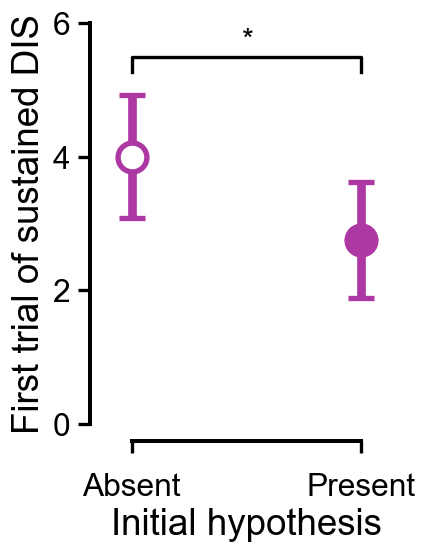


=== Group comparison: initial hypothesis vs DIS onset trial ===
k consecutive DIS criterion = 5
trim = within-group [2.5%, 97.5%]
group 0 (absent): n = 40, median = 1.000, mean = 4.000, min = 1.000, max = 27.000
group 1 (present): n = 33, median = 1.000, mean = 2.758, min = 1.000, max = 24.000
Mann-Whitney U = 836.5000, p = 0.01785
Rank-biserial correlation r = -0.2674 (small)


In [20]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import mannwhitneyu

# =========================================
# 0) Basic settings
# =========================================
subject_col = "subject"
phase_col = "phase"
round_col = "round"
pattern_col = "FDS_pattern"
hypo_col = "initial_hypothesis"

save_dir = "figures_saving_for_layout"
Path(save_dir).mkdir(parents=True, exist_ok=True)

PURPLE = "#AD38A3"
WHITE = "#FFFFFF"

# Consecutive DIS trials required to define onset
k_consecutive = 5

# Within-group trimming thresholds
trim_lower = 0.025
trim_upper = 0.975

# =========================================
# 1) helper functions
# =========================================
def mannwhitney_effect_size_rbc(x, y):
    x = pd.Series(x).dropna().to_numpy()
    y = pd.Series(y).dropna().to_numpy()

    n1, n2 = len(x), len(y)
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan, n1, n2

    u_stat, _ = mannwhitneyu(x, y, alternative="two-sided")
    r_rb = 1 - (2 * u_stat) / (n1 * n2)
    return r_rb, u_stat, n1, n2


def interpret_rbc(r):
    if pd.isna(r):
        return "NaN"
    ar = abs(r)
    if ar < 0.10:
        return "negligible"
    elif ar < 0.30:
        return "small"
    elif ar < 0.50:
        return "medium"
    else:
        return "large"


def first_fds_onset_round(rounds, patterns, k=1, target_value="FDS"):
    rounds = list(rounds)
    patterns = list(patterns)

    n = len(patterns)
    if n == 0 or k <= 0:
        return np.nan

    for i in range(n - k + 1):
        window = patterns[i:i+k]
        if all(p == target_value for p in window):
            return rounds[i]

    return np.nan


def trim_series_by_quantile(x, lower=0.05, upper=0.95):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return x

    ql = x.quantile(lower)
    qu = x.quantile(upper)
    return x[(x >= ql) & (x <= qu)]


def p_to_stars_local(p):
    if pd.isna(p):
        return None
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return None


def add_sig_bar_local(ax, x1, x2, y, h, text, lw=2.0, fs=16):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=lw, c='black', clip_on=False)
    ax.text((x1 + x2) / 2, y + h + 0.02, text, ha='center', va='bottom', fontsize=fs, color='black')




def draw_grouped_mean_error(ax, values_by_group, group_labels, group_colors, ylabel, xlabel, pairwise_pval=None):
    group_centers = np.arange(len(group_labels)) * 0.78 + 1.0

    means = [float(np.mean(v)) for v in values_by_group]
    sems = [float(pd.Series(v).sem()) for v in values_by_group]

    for x, mean, sem, color in zip(group_centers, means, sems, group_colors):
        ax.errorbar(
            x,
            mean,
            yerr=sem,
            fmt='o',
            markersize=17.3,
            color=PURPLE,
            markerfacecolor=color,
            markeredgecolor=PURPLE,
            markeredgewidth=3.2,
            elinewidth=5.2,
            capsize=8,
            capthick=5.2,
            zorder=3,
        )

    mean_plus_sem = max(m + s for m, s in zip(means, sems))
    bracket_h = 0.22
    bracket_y = mean_plus_sem + 0.35
    content_top = bracket_y + bracket_h + 0.28
    tick_step = 1 if content_top <= 4 else 2
    y_upper = max(tick_step * np.ceil(content_top / tick_step), 4)
    y_ticks = np.arange(0, y_upper + 0.001, tick_step)

    style_axis_like_example(
        ax=ax,
        xlabel=xlabel,
        ylabel=ylabel,
        xtick_positions=group_centers,
        xtick_labels=group_labels,
        y_ticks=y_ticks,
        y_lim=(0, y_upper),
        x_lim=(group_centers[0] - 0.14, group_centers[-1] + 0.14),
        left_bound=(y_ticks[0], y_ticks[-1]),
        bottom_bound=(group_centers[0], group_centers[-1]),
    )

    if pairwise_pval is not None:
        star = p_to_stars_local(pairwise_pval)
        if star is not None:
            add_sig_bar_local(ax, group_centers[0], group_centers[1], bracket_y, bracket_h, star, lw=2.0, fs=18)

# =========================================
# 2) exclude phase == P1
# =========================================
df = merged_df.copy()
df = df[df[phase_col] != "P1"].copy()

needed_cols = [subject_col, phase_col, round_col, pattern_col, hypo_col]
missing_cols = [c for c in needed_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"merged_df is missing these columns: {missing_cols}")

df[round_col] = pd.to_numeric(df[round_col], errors="coerce")
df[hypo_col] = pd.to_numeric(df[hypo_col], errors="coerce")
df = df[df[round_col].notna()].copy()

# =========================================
# 3) compute subject x phase DIS onset round
# =========================================
rows = []
for (subj, ph), g in df.groupby([subject_col, phase_col], dropna=False):
    g = g.sort_values(round_col).copy()

    onset_round = first_fds_onset_round(
        rounds=g[round_col].tolist(),
        patterns=g[pattern_col].tolist(),
        k=k_consecutive,
        target_value="FDS"
    )

    hypo_vals = g[hypo_col].dropna().unique()
    if len(hypo_vals) == 0:
        hypo_val = np.nan
    else:
        hypo_val = hypo_vals[0]

    rows.append({
        subject_col: subj,
        phase_col: ph,
        hypo_col: hypo_val,
        "FDS_onset_round": onset_round
    })

fds_onset_df = pd.DataFrame(rows)
print("Generated subject x phase DIS onset summary:")
display(fds_onset_df.head())

# =========================================
# 4) keep hypo = 0/1 and non-missing onset
# =========================================
plot_df = fds_onset_df.copy()
plot_df = plot_df[plot_df[hypo_col].isin([0, 1])].copy()
plot_df = plot_df[plot_df["FDS_onset_round"].notna()].copy()

print()
print(f"Sample size before trimming: {len(plot_df)}")
print(plot_df.groupby(hypo_col)["FDS_onset_round"].agg(["count", "mean", "median", "std", "min", "max"]))

# =========================================
# 5) groupwise trim
# =========================================
g0_raw = plot_df.loc[plot_df[hypo_col] == 0, "FDS_onset_round"]
g1_raw = plot_df.loc[plot_df[hypo_col] == 1, "FDS_onset_round"]

g0_trim = trim_series_by_quantile(g0_raw, lower=trim_lower, upper=trim_upper)
g1_trim = trim_series_by_quantile(g1_raw, lower=trim_lower, upper=trim_upper)

print()
print("Trimming summary:")
print(f"group 0 raw n = {len(g0_raw)}, trimmed n = {len(g0_trim)}")
print(f"group 1 raw n = {len(g1_raw)}, trimmed n = {len(g1_trim)}")

g0 = g0_trim.to_numpy()
g1 = g1_trim.to_numpy()

# =========================================
# 6) group comparison and figure
# =========================================
if len(g0) == 0 or len(g1) == 0:
    print()
    print("Unable to compare groups: at least one group is empty after trimming.")
else:
    u_stat, p_val = mannwhitneyu(g0, g1, alternative="two-sided")
    r_rb, _, n0, n1 = mannwhitney_effect_size_rbc(g0, g1)

    fig, ax = plt.subplots(1, 1, figsize=(3.8, 4.9))

    draw_grouped_mean_error(
        ax=ax,
        values_by_group=[g0, g1],
        group_labels=["Absent", "Present"],
        group_colors=[WHITE, PURPLE],
        ylabel="First trial of sustained DIS",
        xlabel="Initial hypothesis",
        pairwise_pval=p_val,
    )

    plt.tight_layout()

    out = Path(save_dir) / f"initial_hypothesis_FDS_onset_round_k{k_consecutive}_trimmed_purple_white_narrow.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print()
    print(f"Saved figure to: {out.resolve()}")
    plt.show()

    print()
    print("=== Group comparison: initial hypothesis vs DIS onset trial ===")
    print(f"k consecutive DIS criterion = {k_consecutive}")
    print(f"trim = within-group [{trim_lower:.1%}, {trim_upper:.1%}]")
    print(f"group 0 (absent): n = {n0}, median = {np.median(g0):.3f}, mean = {np.mean(g0):.3f}, min = {np.min(g0):.3f}, max = {np.max(g0):.3f}")
    print(f"group 1 (present): n = {n1}, median = {np.median(g1):.3f}, mean = {np.mean(g1):.3f}, min = {np.min(g1):.3f}, max = {np.max(g1):.3f}")
    print(f"Mann-Whitney U = {u_stat:.4f}, p = {p_val:.4g}")
    print(f"Rank-biserial correlation r = {r_rb:.4f} ({interpret_rbc(r_rb)})")


In [ ]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FixedLocator, FormatStrFormatter
from scipy.stats import mannwhitneyu

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["axes.grid"] = False

BEHAVIOR_FILE = "data/choice_category_uniform_105_with_FDS_pattern_within_dms.csv"
TASK_DIMENSION_FILES = [
    "data/p1p2-endsurvey-sumup.xlsx",
    "data/p2-only-endsurvey-sumup.xlsx",
    "data/p1p2-endsurvey-sumup_2025participants.xlsx",
    "data/p2-only-endsurvey-sumup_2025participants.xlsx",
]
OUTPUT_DIR = Path("figure2/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GROUP_LABELS = ["None (0)", "Partial (0-1)", "Perfect (1)"]
X_LABEL = "Task-dimension identification accuracy"
LABEL_SIZE = 13
TICK_SIZE = 12
SPINE_WIDTH = 1.8
TEXT_COLOR = "#222222"
SIG_COLOR = "#2A2A2A"
PURPLE = "#6F2C91"
PURPLE_FILL = "#8D53B3"
VIOLIN_ALPHA = 0.30
GROUP_CENTERS = np.array([1.00, 1.90, 2.80])
VIOLIN_OFFSET = 0.17
HALF_VIOLIN_WIDTH = 0.34
BOX_WIDTH = 0.22
MARKER_SIZE = 8.4
DPI = 400

FIGURE_SPECS = {
    "FDS_ratio": {
        "ylabel": "Fraction of DIS trials",
        "distribution_filename": "4D_dimensions_recognized_prop_FDS_ratio_three_group_nature_main_labels_v2.png",
        "mean_filename": "4D_dimensions_recognized_prop_FDS_ratio_three_group_mean_sem_samecolor_v3.png",
        "y_ticks": [0.0, 0.25, 0.50, 0.75, 1.00],
        "bounded_01": True,
        "ytick_formatter": "%.2f",
        "figsize": (4.85, 4.45),
    },
    "FDS_patterns_per_dms": {
        "ylabel": "Mean unique DIS patterns\nper explored dimension",
        "distribution_filename": "4D_dimensions_recognized_prop_FDS_patterns_per_dms_three_group_samecolor_v3.png",
        "mean_filename": None,
        "y_ticks": [1.5, 3.0, 4.5, 6.0],
        "bounded_01": False,
        "ytick_formatter": "%.1f",
        "figsize": (4.85, 4.45),
    },
}


def clean_subject(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text == "" or text.lower() == "nan":
        return np.nan
    if text.endswith(".0"):
        text = text[:-2]
    return text


def parse_task_dimension_prop(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text == "" or text.lower() == "nan":
        return np.nan
    frac_match = re.fullmatch(r"(\d+)\s*/\s*(\d+)", text)
    if frac_match:
        numerator = float(frac_match.group(1))
        denominator = float(frac_match.group(2))
        return numerator / denominator if denominator != 0 else np.nan
    try:
        return float(text)
    except ValueError:
        return np.nan


def first_valid_numeric(series):
    for value in series:
        if pd.notna(value):
            return float(value)
    return np.nan


def build_subject_phase_fds_summary():
    behavior_df = pd.read_csv(BEHAVIOR_FILE).copy()
    behavior_df["subject"] = behavior_df["subject"].apply(clean_subject)
    behavior_df = behavior_df[behavior_df["phase"].isin(["P2", "P2-only"])].copy()
    behavior_df["round"] = pd.to_numeric(behavior_df["round"], errors="coerce")
    behavior_df["FDS_dim"] = pd.to_numeric(behavior_df["FDS_dim"], errors="coerce")

    if "FDS_pattern" in behavior_df.columns:
        behavior_df["FDS_pattern"] = behavior_df["FDS_pattern"].astype("string")
    if "FDS_pattern_within_dms" in behavior_df.columns:
        behavior_df["FDS_pattern_within_dms"] = behavior_df["FDS_pattern_within_dms"].astype("string")

    rows = []
    for (subject, phase), group in behavior_df.groupby(["subject", "phase"], dropna=False):
        group = group.sort_values("round").copy()
        max_round = group["round"].max()

        fds_n = int((group["FDS_pattern"] == "FDS").sum())
        if pd.isna(max_round) or max_round <= 0:
            fds_ratio = np.nan
        else:
            fds_ratio = fds_n / max_round

        valid_fds = group[group["FDS_dim"].notna() & (group["FDS_dim"] != -1)].copy()
        fds_dimensions = int(valid_fds["FDS_dim"].nunique()) if len(valid_fds) > 0 else 0

        if fds_dimensions > 0 and "FDS_pattern_within_dms" in valid_fds.columns:
            pattern_tmp = valid_fds.dropna(subset=["FDS_pattern_within_dms"]).copy()
            pattern_count_by_dim = (
                pattern_tmp.groupby("FDS_dim")["FDS_pattern_within_dms"].nunique()
                if len(pattern_tmp) > 0 else pd.Series(dtype=float)
            )
            fds_patterns_per_dms = pattern_count_by_dim.mean() if len(pattern_count_by_dim) > 0 else np.nan
        else:
            fds_patterns_per_dms = np.nan

        rows.append({
            "subject": subject,
            "phase": phase,
            "FDS_ratio": fds_ratio,
            "FDS_patterns_per_dms": fds_patterns_per_dms,
        })

    return pd.DataFrame(rows)


def build_task_dimension_subject_summary():
    frames = []
    for file_path in TASK_DIMENSION_FILES:
        survey_df = pd.read_excel(file_path, engine="openpyxl").copy()
        survey_df["subject"] = survey_df["subject"].apply(clean_subject)
        survey_df["task_dimension_report_prop"] = survey_df["4D_dimensions_recognized"].apply(parse_task_dimension_prop)
        frames.append(survey_df[["subject", "task_dimension_report_prop"]])

    task_dimension_df = pd.concat(frames, ignore_index=True)
    task_dimension_df = task_dimension_df.dropna(subset=["subject"]).copy()
    task_dimension_df = (
        task_dimension_df.groupby("subject", dropna=False)["task_dimension_report_prop"]
        .agg(first_valid_numeric)
        .reset_index()
    )
    return task_dimension_df


def to_three_level(value):
    if pd.isna(value):
        return np.nan
    if np.isclose(value, 0.0):
        return 0
    if np.isclose(value, 1.0):
        return 2
    if 0.0 < value < 1.0:
        return 1
    return np.nan


def trim_each_tail(values, lower=0.05, upper=0.95):
    values = pd.Series(values).dropna().astype(float)
    if len(values) < 6:
        return values.to_numpy()
    lower_q = values.quantile(lower)
    upper_q = values.quantile(upper)
    return values[(values >= lower_q) & (values <= upper_q)].to_numpy()


def trimmed_mwu(plot_df, group_col, value_col, group_a, group_b):
    group_a_values = trim_each_tail(plot_df.loc[plot_df[group_col] == group_a, value_col])
    group_b_values = trim_each_tail(plot_df.loc[plot_df[group_col] == group_b, value_col])
    if len(group_a_values) == 0 or len(group_b_values) == 0:
        return np.nan
    _, p_value = mannwhitneyu(group_a_values, group_b_values, alternative="two-sided")
    return p_value


def rank_biserial(values_a, values_b):
    values_a = pd.Series(values_a).dropna().to_numpy(dtype=float)
    values_b = pd.Series(values_b).dropna().to_numpy(dtype=float)
    if len(values_a) == 0 or len(values_b) == 0:
        return np.nan, np.nan, len(values_a), len(values_b)
    u_stat, _ = mannwhitneyu(values_a, values_b, alternative="two-sided")
    r_rb = 1 - (2 * u_stat) / (len(values_a) * len(values_b))
    return r_rb, u_stat, len(values_a), len(values_b)


def interpret_rbc_local(r_value):
    if pd.isna(r_value):
        return "NaN"
    abs_r = abs(r_value)
    if abs_r < 0.10:
        return "negligible"
    if abs_r < 0.30:
        return "small"
    if abs_r < 0.50:
        return "medium"
    return "large"


def p_to_stars_local(p_value):
    if pd.isna(p_value):
        return None
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return None


def collect_sig_pairs(pairwise_pvals):
    sig_pairs = []
    for pair, p_value in pairwise_pvals.items():
        star = p_to_stars_local(p_value)
        if star is not None:
            sig_pairs.append((pair, star, pair[1] - pair[0]))
    sig_pairs.sort(key=lambda item: item[2])
    return sig_pairs


def set_axis_style(
    ax,
    group_centers,
    y_ticks,
    y_lim,
    ylabel,
    ytick_formatter,
    left_pad=0.20,
    right_pad=0.28,
):
    ax.set_facecolor("white")
    ax.set_xlabel(X_LABEL, fontsize=LABEL_SIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)
    ax.set_xticks(group_centers)
    ax.set_xticklabels(GROUP_LABELS, fontsize=TICK_SIZE)
    ax.yaxis.set_major_locator(FixedLocator(y_ticks))
    ax.yaxis.set_major_formatter(FormatStrFormatter(ytick_formatter))
    ax.set_ylim(*y_lim)
    ax.set_xlim(group_centers[0] - left_pad, group_centers[-1] + right_pad)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(SPINE_WIDTH)
    ax.spines["bottom"].set_linewidth(SPINE_WIDTH)
    ax.spines["left"].set_bounds(float(y_ticks[0]), float(y_ticks[-1]))
    ax.spines["bottom"].set_bounds(float(group_centers[0]), float(group_centers[-1]))
    ax.spines["bottom"].set_position(("outward", 7))

    ax.tick_params(axis="x", labelsize=TICK_SIZE, width=1.35, length=5, direction="out", pad=7)
    ax.tick_params(axis="y", labelsize=TICK_SIZE, width=1.35, length=5, direction="out", pad=5)


def base_y_limits(values_by_group, y_ticks, bounded_01):
    nonempty = [values for values in values_by_group if len(values) > 0]
    all_values = np.concatenate(nonempty) if nonempty else np.array([0.0, 1.0])
    value_min = float(np.nanmin(all_values))
    value_max = float(np.nanmax(all_values))
    if bounded_01:
        y_lim = (0.0, max(1.04, value_max + 0.06))
    else:
        span = value_max - value_min if value_max > value_min else 1.0
        y_lim = (
            max(0.95, value_min - span * 0.05),
            max(float(y_ticks[-1]) + 0.12, value_max + span * 0.16),
        )
    return value_min, value_max, y_lim


def compute_sig_geometry(anchor_y, y_lim, sig_pairs):
    if not sig_pairs:
        return None
    y_min, y_max = y_lim
    span = y_max - y_min
    base_y = anchor_y + span * 0.035
    step = span * 0.070
    height = span * 0.025
    top_needed = base_y + (len(sig_pairs) - 1) * step + height * 1.85
    if top_needed > y_max:
        y_max = top_needed + span * 0.030
        span = y_max - y_min
        base_y = anchor_y + span * 0.035
        step = span * 0.070
        height = span * 0.025
    return (y_min, y_max), base_y, step, height


def draw_sig_pairs(ax, group_centers, sig_pairs, base_y, step, height):
    for idx, (pair, star, _) in enumerate(sig_pairs):
        x1 = group_centers[pair[0]]
        x2 = group_centers[pair[1]]
        y = base_y + idx * step
        ax.plot([x1, x1, x2, x2], [y, y + height, y + height, y], lw=1.25, c=SIG_COLOR, clip_on=False)
        ax.text(
            (x1 + x2) / 2,
            y + height + height * 0.16,
            star,
            ha="center",
            va="bottom",
            fontsize=15,
            color=SIG_COLOR,
        )


def half_violin(ax, values_by_group, violin_positions):
    violins = ax.violinplot(
        values_by_group,
        positions=violin_positions,
        widths=HALF_VIOLIN_WIDTH,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for idx, body in enumerate(violins["bodies"]):
        body.set_facecolor(PURPLE_FILL)
        body.set_edgecolor(PURPLE)
        body.set_linewidth(1.2)
        body.set_alpha(VIOLIN_ALPHA)
        vertices = body.get_paths()[0].vertices
        vertices[:, 0] = np.maximum(vertices[:, 0], violin_positions[idx])

    for idx, values in enumerate(values_by_group):
        if len(values) > 0:
            ax.vlines(
                violin_positions[idx],
                float(np.min(values)),
                float(np.max(values)),
                color=PURPLE,
                linewidth=1.0,
                zorder=2,
            )


def draw_distribution(ax, values_by_group, pairwise_pvals, ylabel, y_ticks, bounded_01, ytick_formatter):
    group_centers = GROUP_CENTERS
    violin_positions = group_centers + VIOLIN_OFFSET
    _, value_max, y_lim = base_y_limits(values_by_group, y_ticks, bounded_01)
    sig_pairs = collect_sig_pairs(pairwise_pvals)
    sig_geometry = compute_sig_geometry(value_max, y_lim, sig_pairs)
    if sig_geometry is not None:
        y_lim, base_y, step, height = sig_geometry

    box = ax.boxplot(
        values_by_group,
        positions=group_centers,
        widths=BOX_WIDTH,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color=PURPLE, linewidth=1.9),
        whiskerprops=dict(color=PURPLE, linewidth=1.55),
        capprops=dict(color=PURPLE, linewidth=1.55),
        boxprops=dict(edgecolor=PURPLE, linewidth=1.6),
    )

    for patch in box["boxes"]:
        patch.set_facecolor("#FFFFFF")
        patch.set_edgecolor(PURPLE)
        patch.set_alpha(1.0)

    half_violin(ax, values_by_group, violin_positions)
    violin_right_extent = VIOLIN_OFFSET + HALF_VIOLIN_WIDTH / 2
    set_axis_style(
        ax,
        group_centers,
        y_ticks,
        y_lim,
        ylabel,
        ytick_formatter,
        left_pad=0.20,
        right_pad=violin_right_extent + 0.08,
    )

    if sig_geometry is not None:
        draw_sig_pairs(ax, group_centers, sig_pairs, base_y, step, height)


def draw_mean_sem(ax, values_by_group, pairwise_pvals, ylabel, y_ticks, bounded_01, ytick_formatter):
    group_centers = GROUP_CENTERS
    means = np.array([float(np.mean(values)) if len(values) > 0 else np.nan for values in values_by_group])
    sems = np.array([float(pd.Series(values).sem()) if len(values) > 1 else 0.0 for values in values_by_group])
    _, value_max, y_lim = base_y_limits(values_by_group, y_ticks, bounded_01)
    line_top = float(np.nanmax(means + sems)) if np.any(~np.isnan(means)) else value_max
    sig_pairs = collect_sig_pairs(pairwise_pvals)
    sig_geometry = compute_sig_geometry(line_top, y_lim, sig_pairs)
    if sig_geometry is not None:
        y_lim, base_y, step, height = sig_geometry

    ax.plot(group_centers, means, color=PURPLE, linewidth=1.65, zorder=2)
    for x_pos, mean_value, sem_value in zip(group_centers, means, sems):
        if np.isnan(mean_value):
            continue
        ax.errorbar(
            x_pos,
            mean_value,
            yerr=sem_value,
            fmt="o",
            markersize=MARKER_SIZE,
            color=PURPLE,
            markerfacecolor="#FFFFFF",
            markeredgecolor=PURPLE,
            markeredgewidth=1.45,
            elinewidth=1.45,
            capsize=4,
            capthick=1.45,
            zorder=3,
        )

    set_axis_style(ax, group_centers, y_ticks, y_lim, ylabel, ytick_formatter)

    if sig_geometry is not None:
        draw_sig_pairs(ax, group_centers, sig_pairs, base_y, step, height)


def apply_layout(fig):
    fig.subplots_adjust(left=0.21, right=0.98, bottom=0.29, top=0.95)


def main():
    base_fds_df = build_subject_phase_fds_summary()
    task_dimension_df = build_task_dimension_subject_summary()
    task_dimension_analysis_df = base_fds_df.merge(task_dimension_df, on="subject", how="left")
    task_dimension_analysis_df = task_dimension_analysis_df[
        pd.notna(task_dimension_analysis_df["task_dimension_report_prop"])
    ].copy()
    task_dimension_analysis_df["task_dimension_level"] = task_dimension_analysis_df[
        "task_dimension_report_prop"
    ].apply(to_three_level)
    task_dimension_analysis_df = task_dimension_analysis_df[
        pd.notna(task_dimension_analysis_df["task_dimension_level"])
    ].copy()
    task_dimension_analysis_df["task_dimension_level"] = task_dimension_analysis_df[
        "task_dimension_level"
    ].astype(int)

    print("Task-dimension recognition proportion values:")
    print(sorted(task_dimension_analysis_df["task_dimension_report_prop"].dropna().unique().tolist()))
    print("Level counts:")
    print(
        task_dimension_analysis_df["task_dimension_level"]
        .value_counts()
        .sort_index()
        .rename(index={0: GROUP_LABELS[0], 1: GROUP_LABELS[1], 2: GROUP_LABELS[2]})
        .to_string()
    )

    for metric_col, metric_spec in FIGURE_SPECS.items():
        metric_df = task_dimension_analysis_df[["subject", "task_dimension_level", metric_col]].copy()
        metric_df = metric_df[pd.notna(metric_df[metric_col])].copy()

        values_by_group = [
            metric_df.loc[metric_df["task_dimension_level"] == level, metric_col].dropna().to_numpy()
            for level in [0, 1, 2]
        ]
        pairwise_pvals = {
            (0, 1): trimmed_mwu(metric_df, "task_dimension_level", metric_col, 0, 1),
            (0, 2): trimmed_mwu(metric_df, "task_dimension_level", metric_col, 0, 2),
            (1, 2): trimmed_mwu(metric_df, "task_dimension_level", metric_col, 1, 2),
        }

        fig_dist, ax_dist = plt.subplots(1, 1, figsize=metric_spec["figsize"], dpi=DPI)
        draw_distribution(
            ax=ax_dist,
            values_by_group=values_by_group,
            pairwise_pvals=pairwise_pvals,
            ylabel=metric_spec["ylabel"],
            y_ticks=metric_spec["y_ticks"],
            bounded_01=metric_spec["bounded_01"],
            ytick_formatter=metric_spec["ytick_formatter"],
        )
        apply_layout(fig_dist)
        dist_path = OUTPUT_DIR / metric_spec["distribution_filename"]
        fig_dist.savefig(dist_path, dpi=DPI, bbox_inches="tight", pad_inches=0.06)
        print(f"Saved distribution figure to: {dist_path.resolve()}")
        plt.close(fig_dist)

        if metric_spec["mean_filename"] is not None:
            fig_mean, ax_mean = plt.subplots(1, 1, figsize=metric_spec["figsize"], dpi=DPI)
            draw_mean_sem(
                ax=ax_mean,
                values_by_group=values_by_group,
                pairwise_pvals=pairwise_pvals,
                ylabel=metric_spec["ylabel"],
                y_ticks=metric_spec["y_ticks"],
                bounded_01=metric_spec["bounded_01"],
                ytick_formatter=metric_spec["ytick_formatter"],
            )
            apply_layout(fig_mean)
            mean_path = OUTPUT_DIR / metric_spec["mean_filename"]
            fig_mean.savefig(mean_path, dpi=DPI, bbox_inches="tight", pad_inches=0.06)
            print(f"Saved mean-SEM figure to: {mean_path.resolve()}")
            plt.close(fig_mean)

        print(f"\n=== Task dimension report completeness x {metric_col} ===")
        print(
            metric_df.groupby("task_dimension_level")[metric_col]
            .agg(["count", "mean", "median", "min", "max"])
            .rename(index={0: GROUP_LABELS[0], 1: GROUP_LABELS[1], 2: GROUP_LABELS[2]})
            .to_string()
        )

        for pair in [(0, 1), (0, 2), (1, 2)]:
            r_rb, u_stat, n_a, n_b = rank_biserial(values_by_group[pair[0]], values_by_group[pair[1]])
            print(
                f"{GROUP_LABELS[pair[0]]} vs {GROUP_LABELS[pair[1]]}: "
                f"p = {pairwise_pvals[pair]:.4g}, rank-biserial r = {r_rb:.4f} "
                f"({interpret_rbc_local(r_rb)}), U = {u_stat:.4f}, n = {n_a} vs {n_b}"
            )


if __name__ == "__main__":
    main()


In [ ]:
# Formal relabeling + higher-contrast palette + mean-SEM line figures
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FORMAL_OUTPUT_DIR = Path("figures_saving_for_layout")
FORMAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FORMAL_GROUP_LABELS = ["0 (incorrect)", "0-1 (intermediate)", "1 (correct)"]
FORMAL_X_LABEL = "Task-dimension identification accuracy"
FORMAL_FILL_COLORS = ["#F2E9F8", "#C99FE3", "#8E4DB2"]
FORMAL_EDGE_COLORS = ["#B68DD2", "#8D5CB2", "#642A87"]
FORMAL_NEUTRAL = "#4A4A4A"
FORMAL_LABEL_SIZE = 13
FORMAL_TICK_SIZE = 11.5
FORMAL_SPINE_WIDTH = 1.7

FORMAL_FIGURE_SPECS = {
    "FDS_ratio": {
        "ylabel": "Fraction of DIS trials",
        "distribution_filename": "4D_dimensions_recognized_prop_FDS_ratio_three_group_formal_distribution_v2.png",
        "mean_filename": "4D_dimensions_recognized_prop_FDS_ratio_three_group_mean_sem_line_v2.png",
        "y_ticks": [0.0, 0.25, 0.50, 0.75, 1.00],
        "bounded_01": True,
    },
    "FDS_patterns_per_dms": {
        "ylabel": "Mean unique DIS patterns\nper explored dimension",
        "distribution_filename": "4D_dimensions_recognized_prop_FDS_patterns_per_dms_three_group_formal_distribution_v2.png",
        "mean_filename": "4D_dimensions_recognized_prop_FDS_patterns_per_dms_three_group_mean_sem_line_v2.png",
        "y_ticks": [1.0, 2.5, 4.0, 5.5],
        "bounded_01": False,
    },
}


if "task_dimension_analysis_df" not in globals():
    if "build_subject_phase_fds_summary" not in globals() or "build_task_dimension_subject_summary" not in globals():
        raise RuntimeError("Run the previous task-dimension DIS cell first.")
    task_dimension_analysis_df = build_subject_phase_fds_summary().merge(
        build_task_dimension_subject_summary(),
        on="subject",
        how="left",
    )
    task_dimension_analysis_df = task_dimension_analysis_df[
        pd.notna(task_dimension_analysis_df["task_dimension_report_prop"])
    ].copy()
    task_dimension_analysis_df["task_dimension_level"] = task_dimension_analysis_df[
        "task_dimension_report_prop"
    ].apply(to_three_level)
    task_dimension_analysis_df = task_dimension_analysis_df[
        pd.notna(task_dimension_analysis_df["task_dimension_level"])
    ].copy()
    task_dimension_analysis_df["task_dimension_level"] = task_dimension_analysis_df[
        "task_dimension_level"
    ].astype(int)


def set_formal_axis(ax, group_centers, y_ticks, y_lim, ylabel):
    ax.set_facecolor("white")
    ax.set_xlabel(FORMAL_X_LABEL, fontsize=FORMAL_LABEL_SIZE)
    ax.set_ylabel(ylabel, fontsize=FORMAL_LABEL_SIZE)
    ax.set_xticks(group_centers)
    ax.set_xticklabels(FORMAL_GROUP_LABELS, fontsize=FORMAL_TICK_SIZE)
    ax.set_yticks(y_ticks)
    ax.set_ylim(*y_lim)
    ax.set_xlim(group_centers[0] - 0.28, group_centers[-1] + 0.40)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(FORMAL_SPINE_WIDTH)
    ax.spines["bottom"].set_linewidth(FORMAL_SPINE_WIDTH)
    ax.spines["left"].set_bounds(float(y_ticks[0]), float(y_ticks[-1]))
    ax.spines["bottom"].set_bounds(float(group_centers[0]), float(group_centers[-1]))
    ax.spines["bottom"].set_position(("outward", 7))

    ax.tick_params(axis="x", labelsize=FORMAL_TICK_SIZE, width=1.35, length=5, direction="out", pad=7)
    ax.tick_params(axis="y", labelsize=FORMAL_TICK_SIZE, width=1.35, length=5, direction="out", pad=5)


def add_sig_bracket_formal(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.35, c=FORMAL_NEUTRAL, clip_on=False)
    ax.text((x1 + x2) / 2, y + h + h * 0.12, text, ha="center", va="bottom", fontsize=15, color=FORMAL_NEUTRAL)


def collect_sig_pairs(pairwise_pvals):
    sig_pairs = []
    for pair, p_value in pairwise_pvals.items():
        star = p_to_stars_local(p_value)
        if star is not None:
            sig_pairs.append((pair, star, pair[1] - pair[0]))
    sig_pairs.sort(key=lambda item: item[2])
    return sig_pairs


def add_sig_pairs_to_axis(ax, sig_pairs, group_centers, value_max, y_lim, y_ticks):
    if not sig_pairs:
        return
    y_span = y_lim[1] - y_lim[0]
    base_y = max(value_max + y_span * 0.05, float(y_ticks[-1]) + y_span * 0.02)
    step = y_span * 0.09
    height = y_span * 0.032
    for idx, (pair, star, _) in enumerate(sig_pairs):
        add_sig_bracket_formal(
            ax,
            group_centers[pair[0]],
            group_centers[pair[1]],
            base_y + idx * step,
            height,
            star,
        )


def get_y_limits(values_by_group, y_ticks, bounded_01):
    nonempty = [values for values in values_by_group if len(values) > 0]
    all_values = np.concatenate(nonempty) if nonempty else np.array([0.0, 1.0])
    value_min = float(np.nanmin(all_values))
    value_max = float(np.nanmax(all_values))
    if bounded_01:
        y_lim = (0.0, max(1.04, value_max + 0.10))
    else:
        span = value_max - value_min if value_max > value_min else 1.0
        y_lim = (max(0.90, value_min - span * 0.08), max(float(y_ticks[-1]) + 0.18, value_max + span * 0.24))
    return all_values, value_max, y_lim


def draw_formal_distribution(ax, values_by_group, pairwise_pvals, ylabel, y_ticks, bounded_01):
    group_centers = np.array([1.00, 2.18, 3.36])
    violin_positions = group_centers + 0.20
    all_values, value_max, y_lim = get_y_limits(values_by_group, y_ticks, bounded_01)

    box = ax.boxplot(
        values_by_group,
        positions=group_centers,
        widths=0.31,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="#222222", linewidth=2.0),
        whiskerprops=dict(color="#444444", linewidth=1.5),
        capprops=dict(color="#444444", linewidth=1.5),
        boxprops=dict(linewidth=1.45),
    )

    for idx, patch in enumerate(box["boxes"]):
        patch.set_facecolor(FORMAL_FILL_COLORS[idx])
        patch.set_edgecolor(FORMAL_EDGE_COLORS[idx])
        patch.set_alpha(0.95)

    violins = ax.violinplot(
        values_by_group,
        positions=violin_positions,
        widths=0.42,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for idx, body in enumerate(violins["bodies"]):
        body.set_facecolor(FORMAL_FILL_COLORS[idx])
        body.set_edgecolor(FORMAL_EDGE_COLORS[idx])
        body.set_linewidth(1.3)
        body.set_alpha(0.50)
        vertices = body.get_paths()[0].vertices
        vertices[:, 0] = np.maximum(vertices[:, 0], violin_positions[idx])

    for idx, values in enumerate(values_by_group):
        if len(values) > 0:
            ax.vlines(
                violin_positions[idx],
                float(np.min(values)),
                float(np.max(values)),
                color=FORMAL_EDGE_COLORS[idx],
                linewidth=1.0,
                zorder=2,
            )

    set_formal_axis(ax, group_centers, y_ticks, y_lim, ylabel)
    add_sig_pairs_to_axis(ax, collect_sig_pairs(pairwise_pvals), group_centers, value_max, y_lim, y_ticks)


def draw_mean_sem_line(ax, values_by_group, pairwise_pvals, ylabel, y_ticks, bounded_01):
    group_centers = np.array([1.00, 2.18, 3.36])
    means = np.array([float(np.mean(values)) if len(values) > 0 else np.nan for values in values_by_group])
    sems = np.array([float(pd.Series(values).sem()) if len(values) > 1 else 0.0 for values in values_by_group])
    all_values, value_max, y_lim = get_y_limits(values_by_group, y_ticks, bounded_01)
    line_top = float(np.nanmax(means + sems)) if np.any(~np.isnan(means)) else value_max
    y_lim = (y_lim[0], max(y_lim[1], line_top + (y_lim[1] - y_lim[0]) * 0.16))

    ax.plot(group_centers, means, color=FORMAL_NEUTRAL, linewidth=1.6, zorder=2)
    for idx, (x_pos, mean_value, sem_value) in enumerate(zip(group_centers, means, sems)):
        ax.errorbar(
            x_pos,
            mean_value,
            yerr=sem_value,
            fmt="o",
            markersize=8.8,
            color=FORMAL_NEUTRAL,
            markerfacecolor=FORMAL_FILL_COLORS[idx],
            markeredgecolor=FORMAL_EDGE_COLORS[idx],
            markeredgewidth=1.4,
            elinewidth=1.5,
            capsize=4,
            capthick=1.5,
            zorder=3,
        )

    set_formal_axis(ax, group_centers, y_ticks, y_lim, ylabel)
    add_sig_pairs_to_axis(ax, collect_sig_pairs(pairwise_pvals), group_centers, line_top, y_lim, y_ticks)


for metric_col, metric_spec in FORMAL_FIGURE_SPECS.items():
    metric_df = task_dimension_analysis_df[["task_dimension_level", metric_col]].copy()
    metric_df = metric_df[pd.notna(metric_df[metric_col])].copy()

    values_by_group = [
        metric_df.loc[metric_df["task_dimension_level"] == level, metric_col].dropna().to_numpy()
        for level in [0, 1, 2]
    ]

    pairwise_pvals = {
        (0, 1): trimmed_mwu(metric_df, "task_dimension_level", metric_col, 0, 1),
        (0, 2): trimmed_mwu(metric_df, "task_dimension_level", metric_col, 0, 2),
        (1, 2): trimmed_mwu(metric_df, "task_dimension_level", metric_col, 1, 2),
    }

    fig_dist, ax_dist = plt.subplots(1, 1, figsize=(5.2, 4.8), dpi=300)
    draw_formal_distribution(
        ax_dist,
        values_by_group,
        pairwise_pvals,
        metric_spec["ylabel"],
        metric_spec["y_ticks"],
        metric_spec["bounded_01"],
    )
    fig_dist.tight_layout()
    dist_path = FORMAL_OUTPUT_DIR / metric_spec["distribution_filename"]
    fig_dist.savefig(dist_path, dpi=300, bbox_inches="tight")
    print(f"Saved revised distribution figure to: {dist_path.resolve()}")
    plt.show()

    fig_mean, ax_mean = plt.subplots(1, 1, figsize=(5.2, 4.6), dpi=300)
    draw_mean_sem_line(
        ax_mean,
        values_by_group,
        pairwise_pvals,
        metric_spec["ylabel"],
        metric_spec["y_ticks"],
        metric_spec["bounded_01"],
    )
    fig_mean.tight_layout()
    mean_path = FORMAL_OUTPUT_DIR / metric_spec["mean_filename"]
    fig_mean.savefig(mean_path, dpi=300, bbox_inches="tight")
    print(f"Saved mean-SEM figure to: {mean_path.resolve()}")
    plt.show()


In [ ]:
# Box-only revision: white first group, lighter middle group, mean line only
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BOXLINE_OUTPUT_DIR = Path("figures_saving_for_layout")
BOXLINE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BOXLINE_GROUP_LABELS = ["0 (incorrect)", "0-1 (intermediate)", "1 (correct)"]
BOXLINE_X_LABEL = "Task-dimension identification accuracy"
BOXLINE_FILL_COLORS = ["#FFFFFF", "#E7D7F1", "#9560B5"]
BOXLINE_MARKER_COLORS = ["#FFFFFF", "#C7A6E0", "#9560B5"]
BOXLINE_EDGE_COLOR = "#404040"
BOXLINE_LABEL_SIZE = 13
BOXLINE_TICK_SIZE = 11.5
BOXLINE_SPINE_WIDTH = 1.7

BOXLINE_FIGURE_SPECS = {
    "FDS_ratio": {
        "ylabel": "Fraction of DIS trials",
        "filename": "4D_dimensions_recognized_prop_FDS_ratio_three_group_box_meanline_v4.png",
        "y_ticks": [0.0, 0.25, 0.50, 0.75, 1.00],
        "bounded_01": True,
        "figsize": (5.3, 4.8),
    },
    "FDS_patterns_per_dms": {
        "ylabel": "Mean unique DIS patterns\nper explored dimension",
        "filename": "4D_dimensions_recognized_prop_FDS_patterns_per_dms_three_group_box_meanline_v4.png",
        "y_ticks": [1.0, 2.5, 4.0, 5.5],
        "bounded_01": False,
        "figsize": (5.3, 4.8),
    },
}


if "task_dimension_analysis_df" not in globals():
    raise RuntimeError("Run the task-dimension analysis cell first.")


def boxline_set_axis(ax, group_centers, y_ticks, y_lim, ylabel):
    ax.set_facecolor("white")
    ax.set_xlabel(BOXLINE_X_LABEL, fontsize=BOXLINE_LABEL_SIZE)
    ax.set_ylabel(ylabel, fontsize=BOXLINE_LABEL_SIZE)
    ax.set_xticks(group_centers)
    ax.set_xticklabels(BOXLINE_GROUP_LABELS, fontsize=BOXLINE_TICK_SIZE)
    ax.set_yticks(y_ticks)
    ax.set_ylim(*y_lim)
    ax.set_xlim(group_centers[0] - 0.28, group_centers[-1] + 0.28)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(BOXLINE_SPINE_WIDTH)
    ax.spines["bottom"].set_linewidth(BOXLINE_SPINE_WIDTH)
    ax.spines["left"].set_bounds(float(y_ticks[0]), float(y_ticks[-1]))
    ax.spines["bottom"].set_bounds(float(group_centers[0]), float(group_centers[-1]))
    ax.spines["bottom"].set_position(("outward", 7))

    ax.tick_params(axis="x", labelsize=BOXLINE_TICK_SIZE, width=1.35, length=5, direction="out", pad=7)
    ax.tick_params(axis="y", labelsize=BOXLINE_TICK_SIZE, width=1.35, length=5, direction="out", pad=5)


def boxline_sig_bar(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.35, c=BOXLINE_EDGE_COLOR, clip_on=False)
    ax.text((x1 + x2) / 2, y + h + h * 0.12, text, ha="center", va="bottom", fontsize=15, color=BOXLINE_EDGE_COLOR)


def boxline_sig_pairs(pairwise_pvals):
    pairs = []
    for pair, p_value in pairwise_pvals.items():
        star = p_to_stars_local(p_value)
        if star is not None:
            pairs.append((pair, star, pair[1] - pair[0]))
    pairs.sort(key=lambda item: item[2])
    return pairs


def boxline_y_limits(values_by_group, y_ticks, bounded_01):
    nonempty = [values for values in values_by_group if len(values) > 0]
    all_values = np.concatenate(nonempty) if nonempty else np.array([0.0, 1.0])
    value_min = float(np.nanmin(all_values))
    value_max = float(np.nanmax(all_values))
    if bounded_01:
        y_lim = (0.0, max(1.05, value_max + 0.10))
    else:
        span = value_max - value_min if value_max > value_min else 1.0
        y_lim = (max(0.90, value_min - span * 0.08), max(float(y_ticks[-1]) + 0.18, value_max + span * 0.22))
    return all_values, value_max, y_lim


def draw_box_meanline(ax, values_by_group, pairwise_pvals, ylabel, y_ticks, bounded_01):
    group_centers = np.array([1.00, 2.18, 3.36])
    _, value_max, y_lim = boxline_y_limits(values_by_group, y_ticks, bounded_01)

    box = ax.boxplot(
        values_by_group,
        positions=group_centers,
        widths=0.34,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="#222222", linewidth=2.0),
        whiskerprops=dict(color=BOXLINE_EDGE_COLOR, linewidth=1.5),
        capprops=dict(color=BOXLINE_EDGE_COLOR, linewidth=1.5),
        boxprops=dict(edgecolor=BOXLINE_EDGE_COLOR, linewidth=1.5),
    )

    for idx, patch in enumerate(box["boxes"]):
        patch.set_facecolor(BOXLINE_FILL_COLORS[idx])
        patch.set_edgecolor(BOXLINE_EDGE_COLOR)
        patch.set_alpha(1.0 if idx == 0 else 0.96)

    means = np.array([float(np.mean(values)) if len(values) > 0 else np.nan for values in values_by_group])

    ax.plot(group_centers, means, color=BOXLINE_EDGE_COLOR, linewidth=1.6, zorder=3)
    for idx, (x_pos, mean_value) in enumerate(zip(group_centers, means)):
        if np.isnan(mean_value):
            continue
        ax.scatter(
            x_pos,
            mean_value,
            s=60,
            facecolor=BOXLINE_MARKER_COLORS[idx],
            edgecolor=BOXLINE_EDGE_COLOR,
            linewidth=1.3,
            zorder=4,
        )

    line_top = float(np.nanmax(means)) if np.any(~np.isnan(means)) else value_max
    y_lim = (y_lim[0], max(y_lim[1], line_top + (y_lim[1] - y_lim[0]) * 0.18))
    boxline_set_axis(ax, group_centers, y_ticks, y_lim, ylabel)

    sig_pairs = boxline_sig_pairs(pairwise_pvals)
    if sig_pairs:
        y_span = y_lim[1] - y_lim[0]
        base_y = max(line_top + y_span * 0.06, float(y_ticks[-1]) + y_span * 0.02)
        step = y_span * 0.09
        height = y_span * 0.032
        for idx, (pair, star, _) in enumerate(sig_pairs):
            boxline_sig_bar(ax, group_centers[pair[0]], group_centers[pair[1]], base_y + idx * step, height, star)


for metric_col, metric_spec in BOXLINE_FIGURE_SPECS.items():
    metric_df = task_dimension_analysis_df[["task_dimension_level", metric_col]].copy()
    metric_df = metric_df[pd.notna(metric_df[metric_col])].copy()
    values_by_group = [
        metric_df.loc[metric_df["task_dimension_level"] == level, metric_col].dropna().to_numpy()
        for level in [0, 1, 2]
    ]
    pairwise_pvals = {
        (0, 1): trimmed_mwu(metric_df, "task_dimension_level", metric_col, 0, 1),
        (0, 2): trimmed_mwu(metric_df, "task_dimension_level", metric_col, 0, 2),
        (1, 2): trimmed_mwu(metric_df, "task_dimension_level", metric_col, 1, 2),
    }

    fig, ax = plt.subplots(1, 1, figsize=metric_spec["figsize"], dpi=300)
    draw_box_meanline(
        ax,
        values_by_group,
        pairwise_pvals,
        metric_spec["ylabel"],
        metric_spec["y_ticks"],
        metric_spec["bounded_01"],
    )
    fig.tight_layout()
    output_path = BOXLINE_OUTPUT_DIR / metric_spec["filename"]
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved box+meanline figure to: {output_path.resolve()}")
    plt.show()


## Task 2 Companion: Task-Dimension Identification Accuracy x DIS Proportion

Add a Task 2 analogue of the Task 1 questionnaire figure `4D_dimensions_recognized_prop_FDS_ratio_three_group_nature_main_labels_v2.png`.
The Task 2 counterpart uses `final_true_dimension_hit_rate` from `analysis_dataset_questionnaire_DIS_task2.csv` and saves new files without overwriting the original Task 1 figure.


In [ ]:
from itertools import combinations
from IPython.display import Image, display

TASK2_QUESTIONNAIRE_ANALYSIS_FILE = Path("data/analysis_dataset_questionnaire_DIS_task2.csv")
TASK2_DIMENSION_SCORE_COL = "final_true_dimension_hit_rate"
TASK2_SINGLE_TASK_DIMENSION_FIG = "task2_task_dimension_identification_accuracy_DIS_ratio_three_group_nature_main_labels_v1.png"
TASK1_TASK2_TASK_DIMENSION_DUALPANEL_FIG = "task1_task2_task_dimension_identification_accuracy_DIS_ratio_three_group_nature_main_labels_dualpanel_v1.png"
DUALPANEL_TASK_DIMENSION_FIGSIZE = (8.3, 4.45)
TASK1_VISIBLE_LEVELS = [0, 1, 2]
TASK2_VISIBLE_LEVELS = [1, 2]
TASK1_PANEL_LABELS = [GROUP_LABELS[level] for level in TASK1_VISIBLE_LEVELS]
TASK2_PANEL_LABELS = [GROUP_LABELS[level] for level in TASK2_VISIBLE_LEVELS]
TASK1_PANEL_CENTERS = GROUP_CENTERS.copy()
TASK2_PANEL_CENTERS = GROUP_CENTERS[: len(TASK2_VISIBLE_LEVELS)].copy()
PANEL_LEFT_PAD = 0.20
PANEL_RIGHT_PAD = VIOLIN_OFFSET + HALF_VIOLIN_WIDTH / 2 + 0.08
TASK1_PANEL_SPAN = (TASK1_PANEL_CENTERS[-1] + PANEL_RIGHT_PAD) - (TASK1_PANEL_CENTERS[0] - PANEL_LEFT_PAD)
TASK2_PANEL_SPAN = (TASK2_PANEL_CENTERS[-1] + PANEL_RIGHT_PAD) - (TASK2_PANEL_CENTERS[0] - PANEL_LEFT_PAD)

PANEL_LABEL_SIZE = 14.6
PANEL_TICK_SIZE = 13.2
PANEL_TITLE_SIZE = 16.0
PANEL_SPINE_WIDTH = 2.35
PANEL_TICK_WIDTH = 1.85
PANEL_TICK_LENGTH = 6.4
PANEL_MEDIAN_WIDTH = 2.45
PANEL_BOX_LINE_WIDTH = 2.15
PANEL_WHISKER_WIDTH = 1.95
PANEL_VIOLIN_EDGE_WIDTH = 1.65
PANEL_VIOLIN_RANGE_WIDTH = 1.25
PANEL_SIG_LINE_WIDTH = 1.75
PANEL_SIG_FONT_SIZE = 21
PANEL_X_LABEL = "Task-dimension identification\naccuracy"
PANEL_SHARED_X_LABEL = "Accuracy of task-dimension identification"


if "build_subject_phase_fds_summary" not in globals() or "build_task_dimension_subject_summary" not in globals():
    raise RuntimeError("Run the earlier task-dimension DIS analysis cell first.")


def build_task1_task_dimension_metric_df():
    base_fds_df = build_subject_phase_fds_summary()
    task_dimension_df = build_task_dimension_subject_summary()
    metric_df = base_fds_df.merge(task_dimension_df, on="subject", how="left")
    metric_df = metric_df[pd.notna(metric_df["task_dimension_report_prop"])].copy()
    metric_df["task_dimension_level"] = metric_df["task_dimension_report_prop"].apply(to_three_level)
    metric_df = metric_df[pd.notna(metric_df["task_dimension_level"])].copy()
    metric_df["task_dimension_level"] = metric_df["task_dimension_level"].astype(int)
    return metric_df[["subject", "task_dimension_report_prop", "task_dimension_level", "FDS_ratio"]].copy()


def build_task2_task_dimension_metric_df(score_col=TASK2_DIMENSION_SCORE_COL):
    metric_df = pd.read_csv(TASK2_QUESTIONNAIRE_ANALYSIS_FILE).copy()
    metric_df["subject"] = metric_df["subject_id"].apply(clean_subject)
    metric_df["task_dimension_report_prop"] = pd.to_numeric(metric_df[score_col], errors="coerce")
    metric_df["task_dimension_level"] = metric_df["task_dimension_report_prop"].apply(to_three_level)
    metric_df["FDS_ratio"] = pd.to_numeric(metric_df["DIS_proportion"], errors="coerce")
    metric_df = metric_df[
        pd.notna(metric_df["subject"])
        & pd.notna(metric_df["task_dimension_report_prop"])
        & pd.notna(metric_df["task_dimension_level"])
        & pd.notna(metric_df["FDS_ratio"])
    ].copy()
    metric_df["task_dimension_level"] = metric_df["task_dimension_level"].astype(int)
    return metric_df[["subject", "task_dimension_report_prop", "task_dimension_level", "FDS_ratio"]].copy()


def build_group_values(metric_df, metric_col="FDS_ratio", levels=None):
    if levels is None:
        levels = TASK1_VISIBLE_LEVELS
    metric_df = metric_df[["task_dimension_level", metric_col]].copy()
    metric_df = metric_df[pd.notna(metric_df[metric_col])].copy()
    values_by_group = [
        metric_df.loc[metric_df["task_dimension_level"] == level, metric_col].dropna().to_numpy(dtype=float)
        for level in levels
    ]
    pairwise_pvals = {}
    for plot_idx_a, plot_idx_b in combinations(range(len(levels)), 2):
        level_a = levels[plot_idx_a]
        level_b = levels[plot_idx_b]
        pairwise_pvals[(plot_idx_a, plot_idx_b)] = trimmed_mwu(
            metric_df, "task_dimension_level", metric_col, level_a, level_b
        )
    return values_by_group, pairwise_pvals


def half_violin_sparse(ax, values_by_group, violin_positions):
    nonempty = [(idx, values) for idx, values in enumerate(values_by_group) if len(values) > 0]
    if not nonempty:
        return

    plot_positions = [float(violin_positions[idx]) for idx, _ in nonempty]
    plot_values = [values for _, values in nonempty]
    violins = ax.violinplot(
        plot_values,
        positions=plot_positions,
        widths=HALF_VIOLIN_WIDTH,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for body, (idx, values) in zip(violins["bodies"], nonempty):
        body.set_facecolor(PURPLE_FILL)
        body.set_edgecolor(PURPLE)
        body.set_linewidth(PANEL_VIOLIN_EDGE_WIDTH)
        body.set_alpha(VIOLIN_ALPHA)
        vertices = body.get_paths()[0].vertices
        vertices[:, 0] = np.maximum(vertices[:, 0], violin_positions[idx])

        ax.vlines(
            violin_positions[idx],
            float(np.min(values)),
            float(np.max(values)),
            color=PURPLE,
            linewidth=PANEL_VIOLIN_RANGE_WIDTH,
            zorder=2,
        )


def set_axis_style_sparse(
    ax,
    group_centers,
    group_labels,
    y_ticks,
    y_lim,
    ylabel,
    ytick_formatter,
    left_pad=0.20,
    right_pad=0.28,
    show_ylabel=True,
    show_xlabel=True,
):
    ax.set_facecolor("white")
    ax.set_xlabel(PANEL_X_LABEL if show_xlabel else "", fontsize=PANEL_LABEL_SIZE, fontweight="bold", labelpad=6)
    ax.set_ylabel(ylabel if show_ylabel else "", fontsize=PANEL_LABEL_SIZE, fontweight="bold", labelpad=6)
    ax.set_xticks(group_centers)
    ax.set_xticklabels(group_labels, fontsize=PANEL_TICK_SIZE)
    ax.yaxis.set_major_locator(FixedLocator(y_ticks))
    ax.yaxis.set_major_formatter(FormatStrFormatter(ytick_formatter))
    ax.set_ylim(*y_lim)
    ax.set_xlim(group_centers[0] - left_pad, group_centers[-1] + right_pad)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(PANEL_SPINE_WIDTH)
    ax.spines["bottom"].set_linewidth(PANEL_SPINE_WIDTH)
    ax.spines["left"].set_bounds(float(y_ticks[0]), float(y_ticks[-1]))
    ax.spines["bottom"].set_bounds(float(group_centers[0]), float(group_centers[-1]))
    ax.spines["bottom"].set_position(("outward", 7))

    ax.tick_params(axis="x", labelsize=PANEL_TICK_SIZE, width=PANEL_TICK_WIDTH, length=PANEL_TICK_LENGTH, direction="out", pad=7)
    ax.tick_params(axis="y", labelsize=PANEL_TICK_SIZE, width=PANEL_TICK_WIDTH, length=PANEL_TICK_LENGTH, direction="out", pad=5)


def draw_sig_pairs_sparse(ax, group_centers, sig_pairs, base_y, step, height):
    for idx, (pair, star, _) in enumerate(sig_pairs):
        x1 = group_centers[pair[0]]
        x2 = group_centers[pair[1]]
        y = base_y + idx * step
        ax.plot([x1, x1, x2, x2], [y, y + height, y + height, y], lw=PANEL_SIG_LINE_WIDTH, c=SIG_COLOR, clip_on=False)
        ax.text(
            (x1 + x2) / 2,
            y + height + height * 0.07,
            star,
            ha="center",
            va="bottom",
            fontsize=PANEL_SIG_FONT_SIZE,
            fontweight="bold",
            color=SIG_COLOR,
        )


def draw_distribution_sparse(
    ax,
    values_by_group,
    pairwise_pvals,
    ylabel,
    y_ticks,
    bounded_01,
    ytick_formatter,
    group_centers,
    group_labels,
    show_ylabel=True,
    show_xlabel=True,
):
    violin_positions = group_centers + VIOLIN_OFFSET
    nonempty_indices = [idx for idx, values in enumerate(values_by_group) if len(values) > 0]
    if not nonempty_indices:
        raise ValueError("At least one non-empty group is required for plotting.")

    plot_positions = [float(group_centers[idx]) for idx in nonempty_indices]
    plot_values = [values_by_group[idx] for idx in nonempty_indices]

    _, value_max, y_lim = base_y_limits(plot_values, y_ticks, bounded_01)
    sig_pairs = collect_sig_pairs(pairwise_pvals)
    sig_geometry = compute_sig_geometry(value_max, y_lim, sig_pairs)
    if sig_geometry is not None:
        y_lim, base_y, step, height = sig_geometry

    box = ax.boxplot(
        plot_values,
        positions=plot_positions,
        widths=BOX_WIDTH,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color=PURPLE, linewidth=PANEL_MEDIAN_WIDTH),
        whiskerprops=dict(color=PURPLE, linewidth=PANEL_WHISKER_WIDTH),
        capprops=dict(color=PURPLE, linewidth=PANEL_WHISKER_WIDTH),
        boxprops=dict(edgecolor=PURPLE, linewidth=PANEL_BOX_LINE_WIDTH),
    )

    for patch in box["boxes"]:
        patch.set_facecolor("#FFFFFF")
        patch.set_edgecolor(PURPLE)
        patch.set_alpha(1.0)

    half_violin_sparse(ax, values_by_group, violin_positions)
    set_axis_style_sparse(
        ax,
        group_centers,
        group_labels,
        y_ticks,
        y_lim,
        ylabel,
        ytick_formatter,
        left_pad=PANEL_LEFT_PAD,
        right_pad=PANEL_RIGHT_PAD,
        show_ylabel=show_ylabel,
        show_xlabel=show_xlabel,
    )

    if sig_geometry is not None:
        draw_sig_pairs_sparse(ax, group_centers, sig_pairs, base_y, step, height)


task1_task_dimension_metric_df = build_task1_task_dimension_metric_df()
task2_task_dimension_metric_df = build_task2_task_dimension_metric_df()
metric_spec = FIGURE_SPECS["FDS_ratio"]

task1_values_by_group, task1_pairwise_pvals = build_group_values(
    task1_task_dimension_metric_df,
    levels=TASK1_VISIBLE_LEVELS,
)
task1_plot_pairwise_pvals = {
    pair: p_value for pair, p_value in task1_pairwise_pvals.items() if pair != (0, 2)
}
task2_values_by_group, task2_pairwise_pvals = build_group_values(
    task2_task_dimension_metric_df,
    levels=TASK2_VISIBLE_LEVELS,
)

task2_level_counts = (
    task2_task_dimension_metric_df["task_dimension_level"]
    .value_counts()
    .reindex(TASK2_VISIBLE_LEVELS, fill_value=0)
    .rename(index={level: GROUP_LABELS[level] for level in TASK2_VISIBLE_LEVELS})
)
print("Task 2 task-dimension recognition proportion values:")
print(sorted(task2_task_dimension_metric_df["task_dimension_report_prop"].dropna().unique().tolist()))
print("Task 2 level counts:")
print(task2_level_counts.to_string())

fig_task2, ax_task2 = plt.subplots(1, 1, figsize=metric_spec["figsize"], dpi=DPI)
draw_distribution_sparse(
    ax=ax_task2,
    values_by_group=task2_values_by_group,
    pairwise_pvals=task2_pairwise_pvals,
    ylabel=metric_spec["ylabel"],
    y_ticks=metric_spec["y_ticks"],
    bounded_01=metric_spec["bounded_01"],
    ytick_formatter=metric_spec["ytick_formatter"],
    group_centers=TASK2_PANEL_CENTERS,
    group_labels=TASK2_PANEL_LABELS,
    show_ylabel=True,
    show_xlabel=True,
)
apply_layout(fig_task2)
task2_single_output_path = OUTPUT_DIR / TASK2_SINGLE_TASK_DIMENSION_FIG
fig_task2.savefig(task2_single_output_path, dpi=DPI, bbox_inches="tight", pad_inches=0.06)
plt.close(fig_task2)

fig_dual, axes_dual = plt.subplots(
    1,
    2,
    figsize=DUALPANEL_TASK_DIMENSION_FIGSIZE,
    dpi=DPI,
    sharey=False,
    gridspec_kw={"width_ratios": [TASK1_PANEL_SPAN, TASK2_PANEL_SPAN]},
)
draw_distribution_sparse(
    ax=axes_dual[0],
    values_by_group=task1_values_by_group,
    pairwise_pvals=task1_plot_pairwise_pvals,
    ylabel=metric_spec["ylabel"],
    y_ticks=metric_spec["y_ticks"],
    bounded_01=metric_spec["bounded_01"],
    ytick_formatter=metric_spec["ytick_formatter"],
    group_centers=TASK1_PANEL_CENTERS,
    group_labels=TASK1_PANEL_LABELS,
    show_ylabel=True,
    show_xlabel=False,
)
draw_distribution_sparse(
    ax=axes_dual[1],
    values_by_group=task2_values_by_group,
    pairwise_pvals=task2_pairwise_pvals,
    ylabel=metric_spec["ylabel"],
    y_ticks=metric_spec["y_ticks"],
    bounded_01=metric_spec["bounded_01"],
    ytick_formatter=metric_spec["ytick_formatter"],
    group_centers=TASK2_PANEL_CENTERS,
    group_labels=TASK2_PANEL_LABELS,
    show_ylabel=False,
    show_xlabel=False,
)

common_upper = max(axes_dual[0].get_ylim()[1], axes_dual[1].get_ylim()[1])
for ax in axes_dual:
    ax.set_ylim(0.0, common_upper)
axes_dual[1].tick_params(axis="y", labelleft=False)

fig_dual.subplots_adjust(left=0.095, right=0.99, bottom=0.28, top=0.86, wspace=0.17)
task1_bbox = axes_dual[0].get_position()
task2_bbox = axes_dual[1].get_position()
fig_dual.supxlabel(PANEL_SHARED_X_LABEL, fontsize=PANEL_LABEL_SIZE, fontweight="bold", y=0.06)
fig_dual.text(
    task1_bbox.x0 + task1_bbox.width / 2,
    0.975,
    "Task 1",
    ha="center",
    va="top",
    fontsize=PANEL_TITLE_SIZE,
    fontweight="bold",
    color=TEXT_COLOR,
)
fig_dual.text(
    task2_bbox.x0 + task2_bbox.width / 2,
    0.975,
    "Task 2",
    ha="center",
    va="top",
    fontsize=PANEL_TITLE_SIZE,
    fontweight="bold",
    color=TEXT_COLOR,
)

dualpanel_output_path = OUTPUT_DIR / TASK1_TASK2_TASK_DIMENSION_DUALPANEL_FIG
fig_dual.savefig(dualpanel_output_path, dpi=DPI, bbox_inches="tight", pad_inches=0.06)
plt.close(fig_dual)

print(f"Saved Task 2 task-dimension distribution figure to: {task2_single_output_path.resolve()}")
print(f"Saved Task 1/Task 2 dual-panel figure to: {dualpanel_output_path.resolve()}")

print("\nTask 1 grouped summary:")
print(
    task1_task_dimension_metric_df.groupby("task_dimension_level")["FDS_ratio"]
    .agg(["count", "mean", "median", "min", "max"])
    .rename(index={level: GROUP_LABELS[level] for level in TASK1_VISIBLE_LEVELS})
    .to_string()
)

print("\nTask 2 grouped summary:")
print(
    task2_task_dimension_metric_df.groupby("task_dimension_level")["FDS_ratio"]
    .agg(["count", "mean", "median", "min", "max"])
    .reindex(TASK2_VISIBLE_LEVELS)
    .rename(index={level: GROUP_LABELS[level] for level in TASK2_VISIBLE_LEVELS})
    .to_string()
)

for label, values_by_group, pairwise_pvals, panel_labels in [
    ("Task 1", task1_values_by_group, task1_pairwise_pvals, TASK1_PANEL_LABELS),
    ("Task 2", task2_values_by_group, task2_pairwise_pvals, TASK2_PANEL_LABELS),
]:
    print(f"\n{label} pairwise tests:")
    for pair in sorted(pairwise_pvals):
        r_rb, u_stat, n_a, n_b = rank_biserial(values_by_group[pair[0]], values_by_group[pair[1]])
        print(
            f"{panel_labels[pair[0]]} vs {panel_labels[pair[1]]}: "
            f"p = {pairwise_pvals[pair]:.4g}, rank-biserial r = {r_rb:.4f} "
            f"({interpret_rbc_local(r_rb)}), U = {u_stat:.4f}, n = {n_a} vs {n_b}"
        )

display(Image(filename=str(task2_single_output_path)))
display(Image(filename=str(dualpanel_output_path)))
